# AlphaZero · Final Notebook

This notebook is the complete, re-runnable pipeline for all three Datathon tasks.

* **Task 1**: for each of 5,014 planned deliveries, predict the handling time at the outlet (`pred_service_min`) and the
  probability of arriving after the outlet's delivery window closes (`pred_late_prob`).

* **Task 2A**: forecast the total and chilled order volume (m³) of every depot × brand for ISO weeks 14–23 of 2026
  (30 Mar – 7 Jun), so Waypoint can plan vehicles, drivers and refrigerated capacity ahead of Sinhala & Tamil New
  Year, Vesak and Poson.
* **Task 2B**: on the peak day S1 at Peliyagoda, mark every order *served* or *deferred*, assign every served order to
  a vehicle and trip within the booklet's seven feasibility rules, and explain the priorities.

*How to run:* `pip install -r requirements.txt`, keep the supplied `data/` folder next to `notebooks/`, then Restart & Run
All (about 35 minutes on a 16-core CPU: Part A takes about 20, mostly its configuration search; the Task 2A backtests
run in parallel on 6 processes, with results identical to a serial run). Everything is seeded and deterministic.

### How the workstreams were combined
Task 1 was a combined effort of 3 teammates. After each solution was run head to head
on the same five time folds we added the best one.
The other three of us built the Task 2 solutions separately. Rather than pick one, we put every approach through the **same rolling-origin backtest** and the **same official check plus common scorecard**, and kept the best part of each.

| Workstream | Approach | What we found | Used in the final solution |
|---|---|---|---|
| 1 · plan + as-of history + ETA replay (teammate, updated) | seed-averaged LightGBM; service = blend of log-target and squared-error models | service MAE 3.90 min vs 7.39 for the planning allowance; lateness log loss 0.143, AUC 0.979, calibrated | ✅ final Task 1 models |
| 1 · LightGBM on 38 plan features (earlier version) | one regressor and one classifier, no history | on the same five folds: MAE 4.14 vs 3.89, log loss 0.153 vs 0.142, worse on every fold | replaced |
| 2A · bottom-up hybrid | rebuild each expected order slot, predict its volume with a GLM + LightGBM | best on Fresh, Tech and chilled | ✅ Fresh, Tech, chilled |
| 2A · structural daily model | level × weekday × payday × festival ramp, summed over open days, plus growth | best on Style outside the recurring spike weeks; rigorous leakage-tested features | ✅ Style (ISO weeks 10 and 32 excepted) |
| 2A · recursive lag GBM | one gradient-boosting model per series on lagged weekly volume, recursive | 7% WAPE: no better than naive on this horizon; its own "holdout" was inside the training data | benchmark only |
| 2B · lexicographic MILP | exact optimiser, strict priority order | 77 of 85 orders, 318.5 m³ | ✅ final allocation |
| 2B · greedy priority score | rank orders by urgency, pack first-fit | 67 of 85 orders, 241.3 m³ (76 if reefers are reserved for chilled) | benchmark; its "serve yesterday's deferrals first" insight is our rule 1 |
| `check_allocation.py` | the organisers' feasibility checker | passes any feasible plan, good or bad | ✅ hard gate on every plan, never a quality measure |

**Results at a glance** (leak-free time-based validation; WAPE = Σ|error| / Σ actual, lower is better)

| Task | Final solution | Score | Reference points |
|---|---|---|---|
| 1 service time | 0.75 × log-target + 0.25 × squared-error LightGBM, 3 seeds; plan, as-of history and ETA-replay features | **MAE 3.90 min** (mean of 3 time folds); **3.88** on 2 folds no decision used | planning allowance 7.39 min |
| 1 lateness | LightGBM classifier, 3 seeds, same features + size-aware ETA | **log loss 0.143, AUC 0.979**, calibrated; **0.140 / 0.978** on the unseen folds | plan's own verdict: log loss 0.480; logistic regression 0.252 |
| 2A total volume | per-brand composite of two model families | **3.12% WAPE** (49 origins × 10 weeks × 6 series); 3.07% on the four named folds | seasonal naive 7.72%; best single teammate model 4.57%; our hybrid alone 3.30% |
| 2A chilled volume | the hybrid's own chilled order slots | **2.07% WAPE** | seasonal naive 6.65%; total × chilled share 2.40–3.44% |
| 2A by brand | Fresh hybrid · Style structural · Tech hybrid | Fresh **1.91%** · Style **5.44%** · Tech 27.4% (random "as needed" ordering) | with P10–P90 ranges, held-out coverage 78–80% |
| 2B peak-day allocation | lexicographic MILP, no repeat deferral | **77 of 85 orders, 318.5 m³; checker PASSED**; 19 of 26 chilled orders | greedy heuristic: 67 orders, 241.3 m³, 9 of 26 chilled (also passes the checker) |

**The full results, with charts, are in §24.**

**Contents**

1 Setup (shared)

*Part A · Task 1*: 2 Data, integrity checks and labels · 3 Exploratory analysis · 4 Validation design and baselines ·
5 Feature engineering · 6 Model development (ablations, search, ensembling, error analysis, feature gates, unseen
folds) · 7 Final training, submission and saved models

*Part B · Task 2A*: 8 Data inventory · 9 Data quality checks · 10 Target construction · 11 Exploratory analysis ·
12 Feature engineering · 13 Models · 14 Validation design · 15 Model comparison (4 folds) · 16 Ablation · 17 Hyper-parameter
check · **18 Benchmark of all approaches on 49 rolling origins** · 19 Error analysis · 20 Prediction intervals ·
21 Final model and forecast · 22 Save models and submission

*Part C · Task 2B*: 23 Peak-day allocation (inputs, optimisation model, priority policy, checker gate, comparison of
alternatives, deferral analysis, what-if)

*Part D*: 24 **Results** (scorecard and charts for all three tasks) · 25 Conclusions, decision log and limitations ·
26 **Inference from the saved models, Task 1 and Task 2A** (final cell)

## 1. Setup

In [1]:
import contextlib, importlib.util, inspect, io, json, os, pickle, platform, subprocess, sys, tempfile, warnings
from pathlib import Path
from types import SimpleNamespace

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import lightgbm as lgb
import sklearn
from scipy import sparse
from scipy.optimize import Bounds, LinearConstraint, milp
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import TweedieRegressor
from sklearn.preprocessing import OneHotEncoder
from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
np.random.seed(42)

# Paths: works whether the notebook runs from the project root or notebooks/.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data" / "General Data").exists())
DATA = ROOT / "data"
MODELS_DIR, SUBMISSIONS_DIR, FIG_DIR = ROOT / "models", ROOT / "submissions", ROOT / "docs" / "figures"
for d in (MODELS_DIR, SUBMISSIONS_DIR, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

# Constants shared by the library code below.
T0 = pd.Timestamp("2024-01-01")                 # time origin for the trend
FESTIVALS = ["new_year", "christmas", "deepavali", "vesak", "esala", "poson", "thai_pongal"]
POST_FEST_DAYS = 10                             # length of the post-festival dip
KEYS = ["depot", "brand", "iso_year", "iso_week"]
TARGETS = {"total": ("pred_total_volume_m3", "total_m3"),
           "chilled": ("pred_chilled_volume_m3", "chilled_m3")}
CAT_COLS = ["outlet_id", "brand", "depot", "temp_requirement", "ramp_festival", "post_festival_name"]
FORECAST_START, N_WEEKS = 202614, 10            # 2026 W14 .. W23
BACKTEST_ORIGINS = [202514, 202527, 202540, 202601]

print(f"python {platform.python_version()} | pandas {pd.__version__} | numpy {np.__version__} | "
      f"scikit-learn {sklearn.__version__} | lightgbm {lgb.__version__}")
print("project root:", ROOT)

python 3.11.9 | pandas 2.2.2 | numpy 2.4.6 | scikit-learn 1.9.0 | lightgbm 4.7.0
project root: D:\Documents\Project\rootcode\Datathon


In [2]:
# Chart style: validated categorical palette (slots in fixed order), solid hairline grid, thin marks.
INK, INK2, MUTED, GRID, AXIS, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
BLUE_LIGHT, BLUE_DARK = "#cde2fb", "#184f95"
DEPOT_COLORS = {"Peliyagoda": BLUE, "Kandy": ORANGE}
BRAND_COLORS = {"Fresh": BLUE, "Style": ORANGE, "Tech": AQUA}
SEQ_CMAP = mpl.colors.LinearSegmentedColormap.from_list(
    "blue_seq", ["#fcfcfb", "#cde2fb", "#86b6ef", "#3987e5", "#256abf", "#184f95", "#0d366b"])

STYLE = {
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.linewidth": 0.8, "axes.grid": True, "grid.color": GRID,
    "grid.linewidth": 0.6, "grid.linestyle": "-", "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.prop_cycle": mpl.cycler(color=[BLUE, ORANGE, AQUA, "#eda100", "#e87ba4", "#008300"]),
    "lines.linewidth": 2.0, "lines.markersize": 5, "font.family": "sans-serif",
    "font.sans-serif": ["Segoe UI", "DejaVu Sans", "Arial"], "font.size": 10,
    "text.color": INK, "axes.labelcolor": INK2, "axes.titlecolor": INK, "axes.titlesize": 11,
    "axes.titleweight": "bold", "axes.titlelocation": "left", "xtick.color": MUTED,
    "ytick.color": MUTED, "legend.frameon": False, "figure.dpi": 100, "savefig.dpi": 150,
    "savefig.bbox": "tight"}
mpl.rcParams.update(STYLE)


def save(fig, name):
    """Save a figure for the write-up and video."""
    fig.savefig(FIG_DIR / f"task2a_{name}.png")

# Part A · Task 1: service time and lateness for each planned delivery

For each of the 5,014 planned deliveries in `task1_test_inputs.csv` we predict `pred_service_min` (minutes handling the
delivery at the outlet, excluding any wait for the window to open) and `pred_late_prob` (probability that the vehicle
arrives after the outlet's window closes).

**Approach.**
* **Labels** are built from the training route records: service time excludes any wait for the window to open, and
  *late* means arriving strictly after the window closes (§2.6).
* **Features** use only what is known before departure, plus leakage-safe history computed from deliveries before each
  row's cutoff. The key addition is an **ETA replay**: every planned route is re-run stop by stop with expected travel
  time (traffic × road disruption × the district's historical travel ratio), expected handling time and waits for
  windows to open, giving a realistic arrival time and slack for every stop (§5).
* **Models** are LightGBM, validated on three six-week time folds that mirror the test period, tuned with a small
  random search, and averaged over three seeds. Service time is a blend of a log-target model and a squared-error
  model (§6). Two further folds that no decision used confirm the result (§6.11).

**Validation results** (final configuration exactly as submitted; status quo = what Waypoint uses today)

| Target | Status quo | Final model, mean of folds F1–F3 | Final model, two unseen folds |
|---|---|---|---|
| Lateness | plan's own verdict: log loss 0.480, AUC 0.52 | log loss **0.143**, AUC **0.979**, Brier 0.045 | log loss **0.140**, AUC **0.978** |
| Service time | planning allowance: MAE 7.39, RMSE 11.90 min | MAE **3.90**, RMSE **6.17** min | MAE **3.88**, RMSE **6.13** min |

*Why this pipeline.* An earlier 38-feature Task 1 pipeline (no history, no ETA replay; one LightGBM per target) was
run head to head with this one on the same five folds and the same training cut. This pipeline won on every fold and
every metric: service MAE 4.14 → 3.89 min, lateness log loss 0.153 → 0.142, AUC 0.975 → 0.979 (decision log, §25.1).

*Runtime.* Part A takes about 20 minutes, most of it the configuration search (§6.4). `RUN_TUNING_SEARCH = False`
(§2.1) skips the search and uses the two configurations it selected; the submission is identical either way.

## 2. Task 1 · data, integrity checks and label construction

### 2.1 Task 1 setup

In [3]:
import os, json, time, platform, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
import sklearn
from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import log_loss, roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, SplineTransformer, StandardScaler
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

SEED = 42
np.random.seed(SEED)
NOTEBOOK_START = time.time()
print(f"python {platform.python_version()} | numpy {np.__version__} | pandas {pd.__version__} | "
      f"scikit-learn {sklearn.__version__} | lightgbm {lgb.__version__}")

python 3.11.9 | numpy 2.4.6 | pandas 2.2.2 | scikit-learn 1.9.0 | lightgbm 4.7.0


In [4]:
# ---- Paths ---------------------------------------------------------------------------------
DATA_ROOT = DATA                                            # the project's data/ folder (set in §1)
OUT_DIR = ROOT / "outputs" / "task1"                        # experiment log, search tables, checks
MODEL_DIR = MODELS_DIR / "task1"                            # saved models + manifest.json
SUBMISSION_PATH = SUBMISSIONS_DIR / "submission_task1.csv"
for p in (OUT_DIR, MODEL_DIR, SUBMISSION_PATH.parent):
    p.mkdir(parents=True, exist_ok=True)

# ---- Run options ---------------------------------------------------------------------------
RUN_TUNING_SEARCH = True     # False: reuse the configurations selected by the search (§6.4)

FILES = {
    "deliv_train": "deliveries_train.csv",   "legs_train": "route_legs_train.csv",
    "deliv_test":  "task1_test_inputs.csv",  "legs_test":  "route_legs_test.csv",
    "outlets": "outlets.csv", "vehicles": "vehicles.csv", "calendar": "calendar.csv",
    "district_travel": "district_travel.csv", "allowance": "service_allowance.csv",
    "traffic": "traffic_speed.csv", "road": "road_conditions.csv",
    "submission": "submission_task1.csv",
}
# Columns that exist only in training route records: used for labels and history, never as features.
TRAIN_ONLY_COLS = ["actual_depart_time", "actual_travel_duration_min", "arrival_time", "leave_outlet_time"]
TIME_COLS = ["planned_depart_time", "planned_arrival_time", "actual_depart_time", "arrival_time",
             "leave_outlet_time", "window_open_time", "window_close_time"]
T1_ID_COLS = ["delivery_id", "route_id", "outlet_id", "vehicle_id", "leg_id", "to_outlet", "from_point"]

def find_file(name, root=DATA_ROOT):
    hits = sorted(p for p in Path(root).rglob(name) if not p.name.startswith("."))
    if not hits:
        raise FileNotFoundError(f"{name} not found under {Path(root).resolve()}")
    return hits[0]

# ---- Chart style (fixed categorical order; recessive grid) ----------------------------------
C_BLUE, C_ORANGE, C_AQUA = "#2a78d6", "#eb6834", "#1baf7a"
C_INK, C_MUTED, C_GRID = "#1a1a19", "#6b6b66", "#e4e4e0"
BRAND_COLORS = {"Fresh": C_BLUE, "Style": C_ORANGE, "Tech": C_AQUA}
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": C_MUTED,
    "axes.labelcolor": C_INK, "axes.titlesize": 11, "axes.titleweight": "bold", "axes.grid": True,
    "grid.color": C_GRID, "grid.linewidth": 0.8, "axes.axisbelow": True, "xtick.color": C_MUTED,
    "ytick.color": C_MUTED, "text.color": C_INK, "legend.frameon": False, "lines.linewidth": 2})

### 2.2 Data
Times are read as text and converted explicitly, so a malformed value fails a check instead of being silently coerced.

In [5]:
def read_competition_csv(key):
    return pd.read_csv(find_file(FILES[key]), dtype={c: str for c in T1_ID_COLS + TIME_COLS})

raw = {k: read_competition_csv(k) for k in FILES}
for k, df in raw.items():
    print(f"{FILES[k]:<26}{df.shape[0]:>8,} rows x {df.shape[1]:>2} cols")
dtr, ltr, dte, lte = raw["deliv_train"], raw["legs_train"], raw["deliv_test"], raw["legs_test"]
outlets, vehicles, cal = raw["outlets"], raw["vehicles"], raw["calendar"]
allowance, traffic, road = raw["allowance"], raw["traffic"], raw["road"]
REF = {"calendar": cal, "traffic": traffic, "road": road, "outlets": outlets, "vehicles": vehicles}

deliveries_train.csv        92,307 rows x 20 cols
route_legs_train.csv        91,894 rows x 22 cols
task1_test_inputs.csv        5,014 rows x 20 cols
route_legs_test.csv          5,014 rows x 18 cols
outlets.csv                    120 rows x  9 cols
vehicles.csv                    60 rows x  9 cols
calendar.csv                   910 rows x 12 cols
district_travel.csv             12 rows x  8 cols
service_allowance.csv            9 rows x  3 cols
traffic_speed.csv              576 rows x  4 cols
road_conditions.csv         10,920 rows x  3 cols
submission_task1.csv         5,014 rows x  3 cols


### 2.3 Data integrity
Every check is recorded as PASS/FAIL; nothing downstream is trusted until all pass. The full list is saved to `outputs/task1/integrity_checks.csv`.

In [6]:
T1_CHECKS = []
def t1_check(name, passed, detail=""):
    T1_CHECKS.append({"check": name, "result": "PASS" if bool(passed) else "FAIL", "detail": detail})
    if not passed:
        print(f"FAIL: {name}  {detail}")

def hhmm_to_min(s: pd.Series) -> pd.Series:
    """'HH:MM' -> minutes after midnight (float). Anything not matching HH:MM becomes NaN."""
    parts = s.astype("string").str.extract(r"^(\d{2}):(\d{2})$").astype(float)
    return parts[0] * 60 + parts[1]

# Keys and statuses
t1_check("delivery_id unique (train)", dtr.delivery_id.is_unique)
t1_check("delivery_id unique (test)", dte.delivery_id.is_unique)
t1_check("no delivery_id in both train and test", not (set(dtr.delivery_id) & set(dte.delivery_id)))
t1_check("leg_id unique (train and test)", ltr.leg_id.is_unique and lte.leg_id.is_unique)
t1_check("(route_id, seq) unique in legs", not ltr.duplicated(["route_id", "seq"]).any()
      and not lte.duplicated(["route_id", "seq"]).any())
leak = set(TRAIN_ONLY_COLS) & set(lte.columns)
t1_check("test legs contain no training-only columns", not leak, str(leak))
t1_check("submission ids = test ids, same order", raw["submission"].delivery_id.tolist() == dte.delivery_id.tolist())
print("dispatch_status (train):", dtr.dispatch_status.value_counts().to_dict())
print("dispatch_status (test): ", dte.dispatch_status.value_counts().to_dict())
nr = dtr.dispatch_status.eq("not_run")
t1_check("never-run orders have no route", dtr.loc[nr, "route_id"].isna().all())
t1_check("dispatched orders all have a route", dtr.loc[~nr, "route_id"].notna().all())
att = dtr[dtr.dispatch_status.eq("attempted")]
t1_check("'attempted' dispatched on order date", (att.dispatch_date == att.order_date).all())
dfr = dtr[dtr.dispatch_status.eq("deferred")]
t1_check("'deferred' dispatched after order date", (pd.to_datetime(dfr.dispatch_date) > pd.to_datetime(dfr.order_date)).all())

# Time format
for name, df in [("deliv_train", dtr), ("deliv_test", dte), ("legs_train", ltr), ("legs_test", lte)]:
    for c in TIME_COLS:
        if c in df.columns:
            bad = df[c].notna() & hhmm_to_min(df[c]).isna()
            t1_check(f"{name}.{c} is HH:MM", bad.sum() == 0, f"{bad.sum()} malformed")

# Referential integrity and consistency with reference tables
t1_check("all order outlets exist in outlets.csv", set(dtr.outlet_id) | set(dte.outlet_id) <= set(outlets.outlet_id))
t1_check("all route vehicles exist in vehicles.csv", set(ltr.vehicle_id) | set(lte.vehicle_id) <= set(vehicles.vehicle_id))
calm = cal.set_index("date")
for name, L in [("train", ltr), ("test", lte)]:
    t1_check(f"{name} legs: monsoon matches calendar", (L.monsoon.values == calm.loc[L.date, "monsoon"].values).all())
    t1_check(f"{name} legs: dow matches calendar", (L.dow.values == calm.loc[L.date, "dow"].values).all())
    t1_check(f"{name} legs: run on operating days", (calm.loc[L.date, "is_operating"].values == 1).all())
ow = outlets.set_index("outlet_id")
for name, D in [("train", dtr), ("test", dte)]:
    same = ((D.window_open_time.values == ow.loc[D.outlet_id, "window_open_time"].values)
            & (D.window_close_time.values == ow.loc[D.outlet_id, "window_close_time"].values))
    t1_check(f"{name}: order window equals outlet master window", same.all(), f"{(~same).sum()} differ")
mall = outlets[outlets.mall_window.notna()]
t1_check("mall outlets: outlet window equals mall window",
      (mall.mall_window == mall.window_open_time + "-" + mall.window_close_time).all())

dispatch_status (train): {'attempted': 90351, 'deferred': 1543, 'not_run': 413}
dispatch_status (test):  {'attempted': 4924, 'deferred': 90}


### 2.4 Join orders to route legs
Every dispatched order matches exactly one leg on `(route_id, seq_in_route) = (route_id, seq)`; `validate="one_to_one"` makes pandas raise otherwise. The same function builds the training and test tables, so both receive identical preprocessing.

In [7]:
SHARED = ["vehicle_id", "vehicle_type", "vehicle_temp", "brand", "district", "depot", "planned_arrival_time"]

def build_base(deliv, legs, name, outlets_df, allowance_df):
    d = deliv[deliv.route_id.notna()].copy()
    d["seq"] = d["seq_in_route"].astype(int)
    m = d.merge(legs, on=["route_id", "seq"], how="left", suffixes=("", "_leg"), validate="one_to_one", indicator=True)
    t1_check(f"{name}: every dispatched order has a leg", (m["_merge"] == "both").all())
    t1_check(f"{name}: every leg has an order", len(m) == len(legs), f"{len(m)} orders vs {len(legs)} legs")
    t1_check(f"{name}: leg outlet = order outlet", (m.to_outlet == m.outlet_id).all())
    t1_check(f"{name}: leg date = dispatch date", (m.date == m.dispatch_date).all())
    for c in SHARED:
        t1_check(f"{name}: {c} agrees (order vs leg)", (m[c] == m[c + "_leg"]).all())
    m = m.drop(columns=["_merge"] + [c + "_leg" for c in SHARED])
    for c in TIME_COLS:                                   # HH:MM -> minutes after midnight
        if c in m.columns:
            m[c.replace("_time", "_min")] = hhmm_to_min(m[c])
    for c in ["date", "order_date", "dispatch_date"]:
        m[c] = pd.to_datetime(m[c])
    m = m.merge(outlets_df[["outlet_id", "dock_type", "parking_constraint"]], on="outlet_id", how="left",
                validate="many_to_one")
    m = m.merge(allowance_df, on=["brand", "dock_type"], how="left", validate="many_to_one")
    t1_check(f"{name}: allowance found for every row", m.service_allowance_min.notna().all())
    m["n_stops"] = m.groupby("route_id").seq.transform("size")
    return m.sort_values(["date", "route_id", "seq"]).reset_index(drop=True)

base_train = build_base(dtr, ltr, "train", outlets, allowance)
base_test = build_base(dte, lte, "test", outlets, allowance)
print("train", base_train.shape, "| test", base_test.shape)

train (91894, 45) | test (5014, 38)


### 2.5 Route structure and timeline consistency
The planned schedule is a deterministic chain: each planned departure equals the previous planned arrival plus the planning allowance. The actual timeline is equally consistent. This structure is what the ETA replay features (§5) exploit.

In [8]:
def route_checks(b, name, has_actuals):
    b = b.sort_values(["route_id", "seq"])
    g = b.groupby("route_id")
    first = b.seq.eq(0)
    t1_check(f"{name}: routes complete (seq 0..n-1)",
          (g.seq.transform("min").eq(0) & g.seq.transform("max").eq(b.n_stops - 1)).all())
    for c in ["date", "vehicle_id", "brand", "district", "depot"]:
        t1_check(f"{name}: one {c} per route", g[c].transform("nunique").eq(1).all())
    t1_check(f"{name}: first leg starts at DEPOT", b.loc[first, "from_point"].eq("DEPOT").all())
    t1_check(f"{name}: from_point = previous to_outlet", (b.loc[~first, "from_point"] == g.to_outlet.shift()[~first]).all())
    share = (b.planned_depart_min + b.planned_travel_duration_min - b.planned_arrival_min).abs().le(1).mean()
    t1_check(f"{name}: planned arrival = planned depart + planned travel", share == 1, f"{share:.4f}")
    gap = b.planned_depart_min - g.planned_arrival_min.shift()
    share = (gap[~first] == g.service_allowance_min.shift()[~first]).mean()
    t1_check(f"{name}: planned depart(k) = planned arrival(k-1) + allowance(k-1)", share == 1, f"{share:.4f}")
    t1_check(f"{name}: no clock times cross midnight", (g.planned_arrival_min.diff().dropna() > 0).all())
    if has_actuals:
        cont = (b.loc[~first, "actual_depart_min"] == g.leave_outlet_min.shift()[~first]).mean()
        t1_check(f"{name}: actual depart(k) = leave(k-1)", cont == 1, f"{cont:.4f}")
        resid = b.arrival_min - (b.actual_depart_min + b.actual_travel_duration_min)
        t1_check(f"{name}: arrival = actual depart + actual travel (+-1 min rounding)", resid.abs().le(1).all(),
              f"exact {resid.eq(0).mean():.3f}")
        t1_check(f"{name}: leave >= arrival", (b.leave_outlet_min >= b.arrival_min).all())

route_checks(base_train, "train", True)
route_checks(base_test, "test", False)
vd = base_train.groupby(["date", "vehicle_id"]).route_id.nunique().value_counts().sort_index()
print("Routes per vehicle per day (train):", vd.to_dict())
same_outlet = base_train.from_point.eq(base_train.to_outlet)
print(f"Legs from an outlet to the same outlet (second order at one outlet): {same_outlet.sum():,}")

Routes per vehicle per day (train): {1: 12560, 2: 6319}
Legs from an outlet to the same outlet (second order at one outlet): 621


### 2.6 Label construction
Labels are not provided; they are built from the training route records using the booklet's definitions.

| Label | Definition | Reason |
|---|---|---|
| `wait_min` | `max(0, window_open − arrival)` | An early vehicle waits until the window opens |
| `service_min` | `leave − max(arrival, window_open)` | Handling time excludes that wait |
| `is_late` | `arrival > window_close` (strict) | Late means arriving *after* the window closes; late vehicles still deliver |

Each order is its own leg (a second order at the same outlet has its own leg), so the formulas apply unchanged to every row. The naive alternatives are computed to show what a wrong definition would cost.

In [9]:
def add_task1_labels(b):
    b = b.copy()
    start = np.maximum(b.arrival_min, b.window_open_min)
    b["wait_min"] = (b.window_open_min - b.arrival_min).clip(lower=0)
    b["time_at_outlet_min"] = b.leave_outlet_min - b.arrival_min          # naive: includes waiting
    b["service_min"] = b.leave_outlet_min - start
    b["is_late"] = (b.arrival_min > b.window_close_min).astype(int)
    return b

labeled = add_task1_labels(base_train)
t1_check("labels: service_min has no missing values", labeled.service_min.notna().all())
t1_check("labels: service_min > 0", (labeled.service_min > 0).all(), f"min {labeled.service_min.min()}")
t1_check("labels: no vehicle leaves before the window opens", (labeled.leave_outlet_min >= labeled.window_open_min).all())

early = labeled.wait_min > 0
pd.DataFrame({"value": {
    "labelled rows": len(labeled),
    "share of early arrivals (wait > 0)": early.mean(),
    "mean wait when early (min)": labeled.loc[early, "wait_min"].mean(),
    "service mean: chosen definition": labeled.service_min.mean(),
    "service mean: naive leave - arrival": labeled.time_at_outlet_min.mean(),
    "service median: chosen / naive": f"{labeled.service_min.median():.0f} / {labeled.time_at_outlet_min.median():.0f}",
    "late rate: arrival > close (chosen)": labeled.is_late.mean(),
    "late rate: arrival >= close": (labeled.arrival_min >= labeled.window_close_min).mean(),
    "late rate implied by the plan (planned arrival > close)": (labeled.planned_arrival_min > labeled.window_close_min).mean(),
}})

,value
labelled rows,91894
share of early arrivals (wait > 0),0.0438
mean wait when early (min),20.0358
service mean: chosen definition,19.0025
service mean: naive leave - arrival,19.8797
service median: chosen / naive,15 / 16
late rate: arrival > close (chosen),0.1958
late rate: arrival >= close,0.1988
late rate implied by the plan (planned arrival > close),0.0067


In [10]:
checks_df = pd.DataFrame(T1_CHECKS)
checks_df.to_csv(OUT_DIR / "integrity_checks.csv", index=False)
print(f"Integrity and label checks: {(checks_df.result == 'PASS').sum()} PASS / {(checks_df.result == 'FAIL').sum()} FAIL")
assert (checks_df.result == "PASS").all(), checks_df[checks_df.result == "FAIL"]

Integrity and label checks: 87 PASS / 0 FAIL


## 3. Task 1 · exploratory analysis
The analysis answers four questions that shape the model: how the service-time target is distributed, which signals carry forward in time, where lateness comes from, and whether the test period resembles the data we validate on. It works on a copy of the labelled table.

In [11]:
eda = labeled.copy()
eda["seq_c"] = eda.seq.clip(upper=8)
eda["planned_arrival_hour"] = (eda.planned_arrival_min // 60).astype(int)
eda["planned_slack_min"] = eda.window_close_min - eda.planned_arrival_min
eda["year_q"] = eda.date.dt.to_period("Q").astype(str)

### 3.1 Service time: a skewed target that the planning allowance describes poorly

count   91,894.0000
mean        19.0025
std         14.9148
min          2.0000
1%           5.0000
5%           7.0000
25%         11.0000
50%         15.0000
75%         22.0000
90%         32.0000
95%         44.0000
99%         80.0000
99.9%      149.0000
max        428.0000
skewness 4.63 | share > 60 min 0.0228 | share > 120 min 0.0026


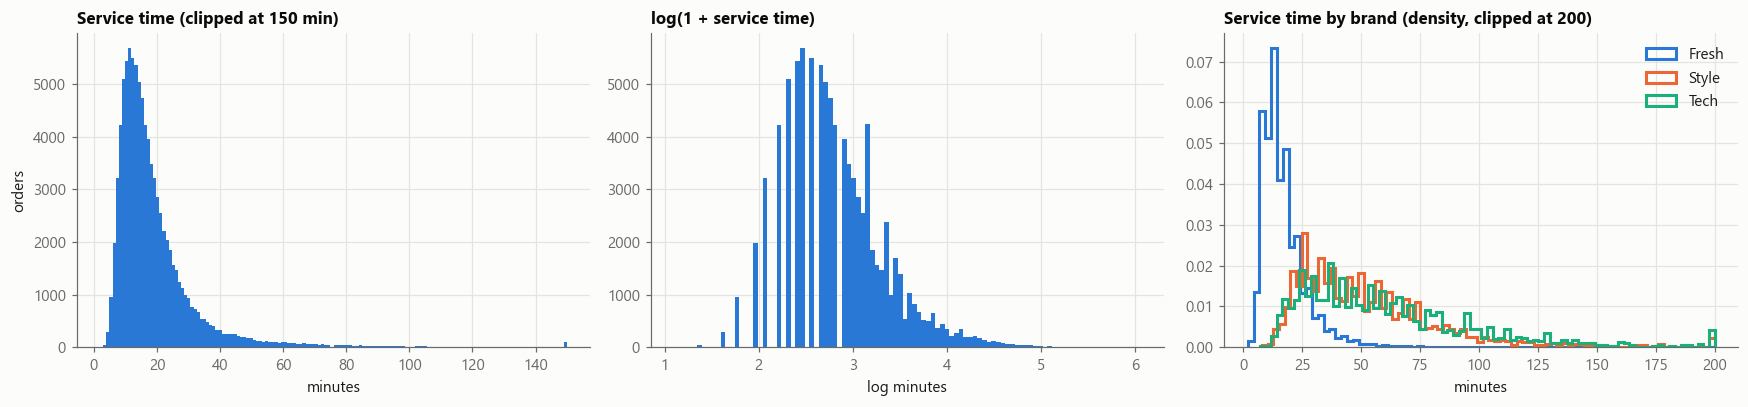

In [12]:
y = eda.service_min
print(y.describe(percentiles=[.01, .05, .25, .5, .75, .9, .95, .99, .999]).to_string())
print(f"skewness {stats.skew(y):.2f} | share > 60 min {(y > 60).mean():.4f} | share > 120 min {(y > 120).mean():.4f}")

fig, ax = plt.subplots(1, 3, figsize=(16, 3.8))
ax[0].hist(y.clip(upper=150), bins=150, color=C_BLUE)
ax[0].set(title="Service time (clipped at 150 min)", xlabel="minutes", ylabel="orders")
ax[1].hist(np.log1p(y), bins=100, color=C_BLUE)
ax[1].set(title="log(1 + service time)", xlabel="log minutes")
for brand, g in eda.groupby("brand"):
    ax[2].hist(g.service_min.clip(upper=200), bins=80, density=True, histtype="step", linewidth=2,
               color=BRAND_COLORS[brand], label=brand)
ax[2].legend(); ax[2].set(title="Service time by brand (density, clipped at 200)", xlabel="minutes")
plt.tight_layout(); plt.show()

In [13]:
svc = (eda.groupby(["brand", "dock_type"])
       .agg(n=("service_min", "size"), allowance=("service_allowance_min", "first"), mean=("service_min", "mean"),
            median=("service_min", "median"), p90=("service_min", lambda s: s.quantile(0.9)), std=("service_min", "std")))
svc["mean_over_allowance"] = svc["mean"] / svc["allowance"]
print("Observed service time against the dispatcher's planning allowance"); display(svc)
print("Service time by brand and monsoon")
display(eda.pivot_table(index="brand", columns="monsoon", values="service_min", aggfunc=["mean", "median"]))
print("Service time and lateness by quarter")
display(eda.groupby("year_q").agg(n=("service_min", "size"), service_mean=("service_min", "mean"),
                                  service_median=("service_min", "median"), late_rate=("is_late", "mean")))

Observed service time against the dispatcher's planning allowance


n  allowance    mean  median      p90     std  mean_over_allowance
brand dock_type                                                                        
Fresh rear_dock  60107         15 16.9164 15.0000  28.0000  9.2126               1.1278
      street     27350         16 17.6435 14.0000  31.0000 11.7323               1.1027
Style mall_bay     983         59 67.3449 61.0000 105.0000 32.8126               1.1414
      rear_dock    652         38 34.6641 30.0000  55.0000 18.9532               0.9122
      street      1098         46 49.9417 45.0000  82.3000 29.2553               1.0857
Tech  mall_bay     284         55 87.7958 74.0000 137.7000 49.8866               1.5963
      rear_dock    809         43 40.6354 35.0000  68.0000 22.2270               0.9450
      street       611         55 74.3502 67.0000 120.0000 36.8367               1.3518

Service time by brand and monsoon


mean          median        
monsoon       0       1       0       1
brand                                  
Fresh   15.5034 19.0258 13.0000 16.0000
Style   48.2012 57.5223 43.0000 50.0000
Tech    58.3469 63.1369 50.0000 55.0000

Service time and lateness by quarter


,n,service_mean,service_median,late_rate
year_q,,,,
2024Q1,10919,16.7319,14.0000,0.1681
2024Q2,10561,21.7043,17.0000,0.2809
2024Q3,11051,16.2806,13.0000,0.1269
2024Q4,10915,19.6720,15.0000,0.2167
2025Q1,10731,17.4828,14.0000,0.1694
2025Q2,10384,22.3633,18.0000,0.2838
2025Q3,11027,17.5183,14.0000,0.1262
2025Q4,10845,20.7773,16.0000,0.2340
2026Q1,5461,18.5559,15.0000,0.1331


### 3.2 Order size drives handling time, most strongly for Tech

size_measure,order_units,order_volume_m3,order_weight_kg
brand,,,
Fresh,0.4859,0.4758,0.4714
Style,0.4110,0.3929,0.3837
Tech,0.7361,0.7387,0.7347


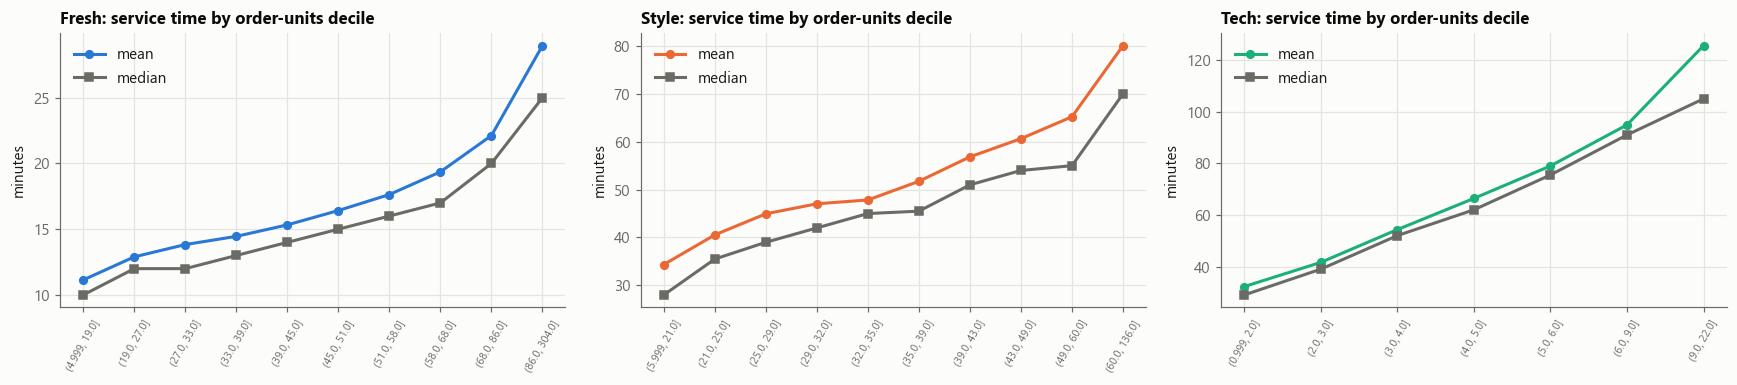

In [14]:
rows = []
for brand, g in eda.groupby("brand"):
    for c in ["order_units", "order_weight_kg", "order_volume_m3"]:
        rows.append({"brand": brand, "size_measure": c, "spearman_rho": stats.spearmanr(g[c], g.service_min)[0]})
display(pd.DataFrame(rows).pivot(index="brand", columns="size_measure", values="spearman_rho"))

fig, ax = plt.subplots(1, 3, figsize=(16, 3.6))
for i, (brand, g) in enumerate(eda.groupby("brand")):
    s = g.groupby(pd.qcut(g.order_units, q=10, duplicates="drop"), observed=True).service_min.agg(["mean", "median"])
    ax[i].plot(range(len(s)), s["mean"], marker="o", color=BRAND_COLORS[brand], label="mean")
    ax[i].plot(range(len(s)), s["median"], marker="s", color=C_MUTED, label="median")
    ax[i].set_xticks(range(len(s))); ax[i].set_xticklabels([str(x) for x in s.index], rotation=60, fontsize=7)
    ax[i].set(title=f"{brand}: service time by order-units decile", ylabel="minutes"); ax[i].legend()
plt.tight_layout(); plt.show()

### 3.3 Which groupings carry signal forward in time?
Group medians (service) and late rates are estimated on data **before 1 July 2025** and scored on data **from 1 July 2025**. In-sample group means always look good for high-cardinality keys such as outlet or vehicle; this out-of-time screen shows which ones actually transfer.

In [15]:
CUT = pd.Timestamp("2025-07-01")

def oot_signal(df, keys):
    fit_, ev = df[df.date < CUT], df[df.date >= CUT]
    g_med, g_rate = fit_.service_min.median(), fit_.is_late.mean()
    mae0, brier0 = (ev.service_min - g_med).abs().mean(), ((ev.is_late - g_rate) ** 2).mean()
    if not keys:
        return {"grouping": "(global)", "groups": 1, "service_MAE": mae0, "MAE_gain_%": 0.0,
                "late_Brier": brier0, "Brier_gain_%": 0.0}
    st = fit_.groupby(keys).agg(p_svc=("service_min", "median"), p_late=("is_late", "mean")).reset_index()
    e = ev.merge(st, on=keys, how="left")
    e["p_svc"] = e.p_svc.fillna(g_med); e["p_late"] = e.p_late.fillna(g_rate)
    mae, brier = (e.service_min - e.p_svc).abs().mean(), ((e.is_late - e.p_late) ** 2).mean()
    return {"grouping": " x ".join(keys), "groups": len(st), "service_MAE": mae, "MAE_gain_%": 100 * (1 - mae / mae0),
            "late_Brier": brier, "Brier_gain_%": 100 * (1 - brier / brier0)}

groupings = [[], ["brand"], ["brand", "dock_type"], ["brand", "dock_type", "monsoon"], ["outlet_id"],
             ["outlet_id", "monsoon"], ["vehicle_id"], ["district"], ["dow"], ["planned_arrival_hour"],
             ["seq_c"], ["seq_c", "monsoon"], ["brand", "seq_c", "monsoon"], ["n_stops"]]
pd.DataFrame([oot_signal(eda, k) for k in groupings]).sort_values("MAE_gain_%", ascending=False)

,grouping,groups,service_MAE,MAE_gain_%,late_Brier,Brier_gain_%
5,outlet_id x monsoon,240,5.6123,32.4995,0.1031,27.7545
4,outlet_id,120,5.6251,32.3450,0.1113,22.0126
2,brand x dock_type,8,7.2858,12.3718,0.1407,1.3422
3,brand x dock_type x monsoon,16,7.2964,12.2440,0.1348,5.4772
12,brand x seq_c x monsoon,33,7.4240,10.7091,0.1177,17.4866
1,brand,3,7.4830,9.9996,0.1419,0.5436
9,planned_arrival_hour,12,7.4990,9.8073,0.1015,28.8236
6,vehicle_id,43,7.8523,5.5582,0.1368,4.0766
7,district,12,7.9793,4.0306,0.1360,4.6469
13,n_stops,10,8.1307,2.2103,0.1407,1.3602


### 3.4 Lateness rises along the route and is concentrated where planned slack is small

Late rate overall: 0.1958


,n,late_rate
brand,,
Fresh,87457,0.2035
Style,2733,0.0549
Tech,1704,0.0246


Late rate by stop position (seq, capped at 8) and monsoon


mean          size       
monsoon      0      1      0      1
seq_c                              
0       0.0443 0.1040  13429  11769
1       0.0859 0.1904  11419   9952
2       0.0920 0.2417   8656   7566
3       0.1432 0.3384   6493   5627
4       0.1963 0.4709   4015   3449
5       0.3255 0.6613   2857   2439
6       0.4840 0.7585   1347   1180
7       0.5521 0.8146    576    534
8       0.9867 1.0000    300    286

Late rate by planned slack (window close - planned arrival, minutes)


,n,late_rate
slack_bin,,
"(-inf, 0.0]",653,0.9832
"(0.0, 30.0]",4821,0.8409
"(30.0, 60.0]",11146,0.5284
"(60.0, 90.0]",15092,0.2518
"(90.0, 120.0]",18854,0.1049
"(120.0, 150.0]",20832,0.0512
"(150.0, 180.0]",11575,0.0368
"(180.0, 240.0]",5091,0.0167
"(240.0, inf]",3830,0.0128


Late rate and service time by district


n  late_rate  service_mean
depot      district                                    
Kandy      Badulla        4614     0.4098       18.9447
           Kandy         14075     0.0767       15.8847
           Kegalle        4503     0.2021       25.3840
           Matale         6822     0.1473       20.0561
           Nuwara Eliya   5595     0.3664       16.4075
Peliyagoda Colombo       16048     0.1950       20.3810
           Galle          6927     0.2137       21.7739
           Gampaha       11535     0.1736       20.5045
           Kalutara       8036     0.2476       19.9083
           Kurunegala     5848     0.1536       15.6636
           Matara         4597     0.1571       19.0544
           Puttalam       3294     0.2532       11.7498

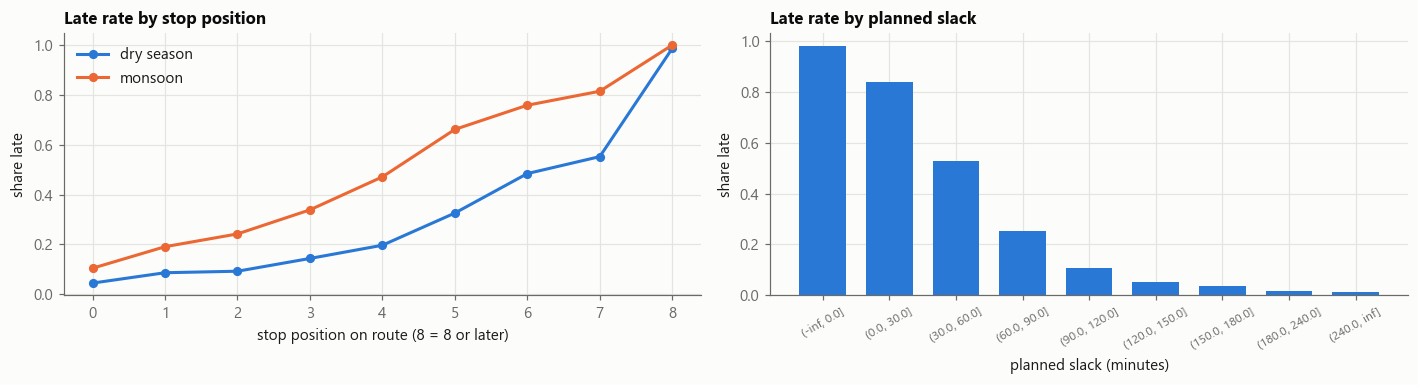

In [16]:
print(f"Late rate overall: {eda.is_late.mean():.4f}")
display(eda.groupby("brand").agg(n=("is_late", "size"), late_rate=("is_late", "mean")))
by_seq = eda.pivot_table(index="seq_c", columns="monsoon", values="is_late", aggfunc=["mean", "size"])
print("Late rate by stop position (seq, capped at 8) and monsoon"); display(by_seq)
eda["slack_bin"] = pd.cut(eda.planned_slack_min, [-np.inf, 0, 30, 60, 90, 120, 150, 180, 240, np.inf])
by_slack = eda.groupby("slack_bin", observed=True).agg(n=("is_late", "size"), late_rate=("is_late", "mean"))
print("Late rate by planned slack (window close - planned arrival, minutes)"); display(by_slack)
print("Late rate and service time by district")
display(eda.groupby(["depot", "district"]).agg(n=("is_late", "size"), late_rate=("is_late", "mean"),
                                               service_mean=("service_min", "mean")))

fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
for m, col, lab in [(0, C_BLUE, "dry season"), (1, C_ORANGE, "monsoon")]:
    ax[0].plot(by_seq.index, by_seq[("mean", m)], marker="o", color=col, label=lab)
ax[0].set(title="Late rate by stop position", xlabel="stop position on route (8 = 8 or later)", ylabel="share late")
ax[0].legend()
ax[1].bar(range(len(by_slack)), by_slack.late_rate, color=C_BLUE, width=0.7)
ax[1].set_xticks(range(len(by_slack))); ax[1].set_xticklabels([str(i) for i in by_slack.index], rotation=30, fontsize=8)
ax[1].set(title="Late rate by planned slack", xlabel="planned slack (minutes)", ylabel="share late")
plt.tight_layout(); plt.show()

### 3.5 Where the delay comes from (diagnostic only: uses actual times)
Because the planned schedule is a chain (§2.5), the arrival delay at stop *k* splits exactly into the depot departure delay, the sum of travel overruns on legs 0..k, and the sum of stop overruns (`wait + service − allowance`) at stops 0..k−1. None of these quantities is used as a feature.

decomposition identity holds within rounding: True
Mean arrival delay and its components by stop position (minutes)


,c_start,c_travel,c_stop_prev,arrival_delay,is_late
seq_c,,,,,
0,7.7189,33.8490,0.0000,41.5688,0.0722
1,7.7053,38.3557,3.7396,49.7972,0.1346
2,7.7075,35.6085,7.2717,50.5973,0.1618
3,7.7203,41.5355,10.7351,59.9990,0.2338
4,7.6568,47.2292,11.7188,66.6125,0.3232
5,7.6529,46.2279,15.3716,69.2528,0.4802
6,7.4954,55.4464,8.1148,71.0546,0.6122
7,7.3595,58.3946,-1.2730,64.5072,0.6784
8,7.4044,72.3601,15.8771,95.6775,0.9932


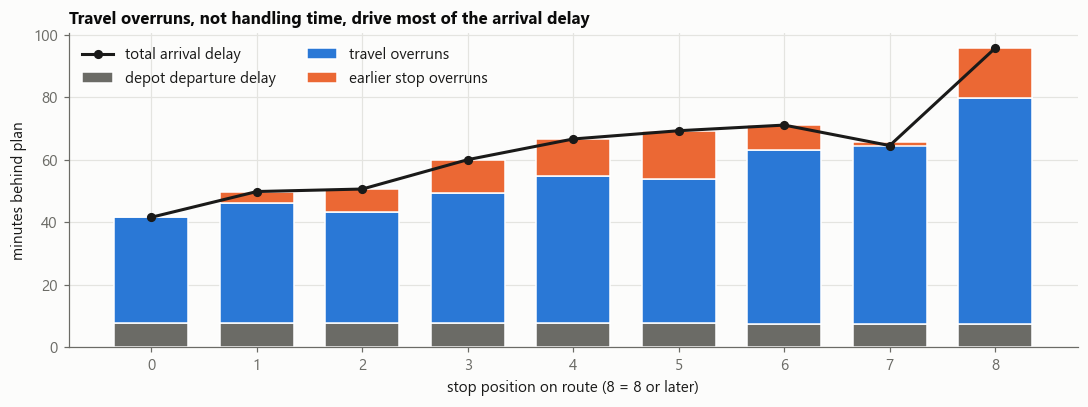

In [17]:
d = eda.sort_values(["route_id", "seq"]).copy()
g = d.groupby("route_id")
d["start_delay"] = np.where(d.seq.eq(0), d.actual_depart_min - d.planned_depart_min, 0.0)
d["travel_over"] = d.actual_travel_duration_min - d.planned_travel_duration_min
d["stop_over"] = d.wait_min + d.service_min - d.service_allowance_min
d["c_start"], d["c_travel"] = g.start_delay.cumsum(), g.travel_over.cumsum()
d["c_stop_prev"] = g.stop_over.cumsum() - d.stop_over
d["arrival_delay"] = d.arrival_min - d.planned_arrival_min
resid = d.arrival_delay - (d.c_start + d.c_travel + d.c_stop_prev)
print(f"decomposition identity holds within rounding: {bool(resid.abs().le(d.seq + 1).all())}")
comp = d.groupby("seq_c")[["c_start", "c_travel", "c_stop_prev", "arrival_delay", "is_late"]].mean()
print("Mean arrival delay and its components by stop position (minutes)"); display(comp)

fig, ax = plt.subplots(figsize=(10, 3.8))
x = np.arange(len(comp)); bottom = np.zeros(len(comp))
for col, colr, lab in [("c_start", C_MUTED, "depot departure delay"), ("c_travel", C_BLUE, "travel overruns"),
                       ("c_stop_prev", C_ORANGE, "earlier stop overruns")]:
    ax.bar(x, comp[col], bottom=bottom, color=colr, width=0.7, label=lab, edgecolor="white", linewidth=1)
    bottom += comp[col].to_numpy()
ax.plot(x, comp.arrival_delay, color=C_INK, marker="o", label="total arrival delay")
ax.set_xticks(x); ax.set_xticklabels(comp.index)
ax.set(title="Travel overruns, not handling time, drive most of the arrival delay",
       xlabel="stop position on route (8 = 8 or later)", ylabel="minutes behind plan"); ax.legend(ncol=2)
plt.tight_layout(); plt.show()

In [18]:
d["hour"] = (d.planned_depart_min // 60).astype(int)
d["date_str"] = d.date.dt.strftime("%Y-%m-%d")
d = d.merge(traffic, on=["district", "hour", "monsoon"], how="left")
d = d.merge(road.rename(columns={"date": "date_str"}), on=["district", "date_str"], how="left")
phys = d.planned_travel_duration_min * (100 / d.speed_index) * (100 / d.disruption_index)
r = lambda a: np.corrcoef(d.actual_travel_duration_min, a)[0, 1]
print("Correlation with actual travel minutes:")
print(f"  planned travel only                  r = {r(d.planned_travel_duration_min):.4f}")
print(f"  planned x traffic index              r = {r(d.planned_travel_duration_min * 100 / d.speed_index):.4f}")
print(f"  planned x traffic x road disruption  r = {r(phys):.4f}")
print(f"Share of leg-days with road disruption (index < 100): {(d.disruption_index < 100).mean():.3f}")
print(f"Service time vs road disruption, Spearman rho = {stats.spearmanr(d.service_min, d.disruption_index)[0]:.3f}")

Correlation with actual travel minutes:
  planned travel only                  r = 0.8915
  planned x traffic index              r = 0.9190
  planned x traffic x road disruption  r = 0.9476
Share of leg-days with road disruption (index < 100): 0.556
Service time vs road disruption, Spearman rho = -0.041


### 3.6 The test period matches the same season in earlier years
The test (16 Feb – 28 Mar 2026) is compared with all training data and with the same calendar window in 2024 and 2025, using prediction-time columns only.

In [19]:
def profile(df, label):
    t = df.copy(); slack = t.window_close_min - t.planned_arrival_min
    return pd.Series({"rows": len(t), "routes": t.route_id.nunique(), "date_from": t.date.min().date(),
        "date_to": t.date.max().date(), "share_Fresh": t.brand.eq("Fresh").mean(), "share_Style": t.brand.eq("Style").mean(),
        "share_Tech": t.brand.eq("Tech").mean(), "share_Kandy": t.depot.eq("Kandy").mean(),
        "share_monsoon_days": t.monsoon.mean(), "share_deferred": t.dispatch_status.eq("deferred").mean(),
        "mean_n_stops": t.n_stops.mean(), "share_seq_ge_5": t.seq.ge(5).mean(),
        "median_planned_slack": slack.median(), "share_planned_late": (slack < 0).mean(),
        "median_units": t.order_units.median(), "mean_distance_km": t.distance_km.mean()}, name=label)

def season_window(df, y):
    return df[(df.date >= f"{y}-02-16") & (df.date <= f"{y}-03-28")]

display(pd.concat([profile(labeled, "train_all"), profile(season_window(labeled, 2024), "same_window_2024"),
                   profile(season_window(labeled, 2025), "same_window_2025"), profile(base_test, "TEST")], axis=1))
ANALOGUE = pd.DataFrame({y: {"late_rate": season_window(labeled, y).is_late.mean(),
                             "service_mean": season_window(labeled, y).service_min.mean(),
                             "service_median": season_window(labeled, y).service_min.median()} for y in [2024, 2025]})
print("Labels in the same seasonal window of earlier years (expected profile of the test labels):"); display(ANALOGUE)

,train_all,same_window_2024,same_window_2025,TEST
rows,91894,5035,4851,5014
routes,25198,1354,1326,1381
date_from,2024-01-01,2024-02-16,2025-02-17,2026-02-16
date_to,2026-02-14,2024-03-28,2025-03-28,2026-03-28
share_Fresh,0.9517,0.9523,0.9532,0.9525
share_Style,0.0297,0.0296,0.0307,0.0299
share_Tech,0.0185,0.0181,0.0161,0.0176
share_Kandy,0.3875,0.3863,0.3896,0.3881
share_monsoon_days,0.4658,0.6683,0.6834,0.6651
share_deferred,0.0168,0.0135,0.0134,0.0179


Labels in the same seasonal window of earlier years (expected profile of the test labels):


,2024,2025
late_rate,0.2044,0.2136
service_mean,17.0010,17.8306
service_median,14.0000,15.0000


### 3.7 Findings that shape the model

| Finding | Evidence | Consequence |
|---|---|---|
| Service time is heavily skewed | Median 15 min, mean 19.0, 99th percentile 80, skew 4.6 | Track MAE and RMSE; model log(service) |
| The planning allowance is a weak predictor | Tech at mall bays averages 88 min against a 55-min allowance | Learn service time from history, not the allowance |
| Outlet history transfers forward in time | Outlet × monsoon medians cut out-of-time MAE by 32% | Leakage-safe outlet history features |
| Order size matters, most for Tech | Spearman ρ ≈ 0.74 (Tech), 0.48 (Fresh) | Size features; size-scaled history |
| Lateness is mostly accumulated travel delay | At the first stop vehicles are 42 min behind plan: 34 from travel, 8 from depot departure | Replay each route with expected travel times (ETA replay) |
| Travel time is predictable from reference data | Correlation with actual travel rises from 0.892 to 0.948 with traffic and road-disruption indices | Use both indices in the replay |
| Strong seasonality | Late rate 12.8% (dry) vs 27.4% (monsoon) | Time-based validation that includes season transitions |
| The test resembles its seasonal analogues | Brand mix, slack, route length and monsoon share (66.5% vs 66.8% / 68.3%) match | Validate on the same window of 2025 plus two other blocks |

## 4. Task 1 · validation design, metrics and baselines
**Folds.** Expanding-window time folds of six weeks (Mon–Sat), each trained only on data strictly before its start date. Whole date ranges are held out, so no route or day straddles a split.

| Fold | Validation window | Why |
|---|---|---|
| F1 | 17 Feb – 29 Mar 2025 | Same calendar window as the test: dry season turning to monsoon |
| F2 | 15 Sep – 25 Oct 2025 | The other dry-to-monsoon transition |
| F3 | 5 Jan – 14 Feb 2026 | The most recent six weeks, to catch drift |

Models are compared on the **mean across the three folds**, and a change is kept only if it does not get clearly worse on any single fold. F2 and F3 contain pre-festival days, which lengthen service time markedly; F1 and the test contain none, so every model is also scored on **festival-free days**.

**Metrics.** The booklet does not name the scoring metrics, so we track those that cover the plausible choices.

| Target | Metrics | Why |
|---|---|---|
| Service time | MAE, RMSE, bias | MAE rewards the median and RMSE the mean; on a skewed target they can disagree |
| Lateness | Log loss (primary), Brier, AUC, ECE | Log loss and Brier reward calibrated probabilities, AUC checks ranking, ECE checks calibration directly |

In [20]:
FOLDS = [
    {"fold": "F1_2025_FebMar", "start": "2025-02-17", "end": "2025-03-29"},
    {"fold": "F2_2025_SepOct", "start": "2025-09-15", "end": "2025-10-25"},
    {"fold": "F3_2026_JanFeb", "start": "2026-01-05", "end": "2026-02-14"},
]
FOLD_NAMES = [f["fold"] for f in FOLDS]
FOLD_START = {f["fold"]: pd.Timestamp(f["start"]) for f in FOLDS}

def iter_folds(df, date_col="date"):
    """Yield (fold, train_index, valid_index); training data is everything before the fold start."""
    for f in FOLDS:
        s, e = pd.Timestamp(f["start"]), pd.Timestamp(f["end"])
        yield f["fold"], df.index[df[date_col] < s], df.index[(df[date_col] >= s) & (df[date_col] <= e)]

def reg_metrics(y, p):
    e = np.asarray(p, float) - np.asarray(y, float)
    return {"MAE": np.abs(e).mean(), "RMSE": np.sqrt((e ** 2).mean()), "MedAE": np.median(np.abs(e)), "bias": e.mean()}

def ece(y, p, bins=10):
    y, p = np.asarray(y, float), np.asarray(p, float)
    idx = np.minimum((p * bins).astype(int), bins - 1)
    return sum((idx == b).mean() * abs(p[idx == b].mean() - y[idx == b].mean()) for b in range(bins) if (idx == b).any())

def clf_metrics(y, p):
    y = np.asarray(y, int); p = np.clip(np.asarray(p, float), 1e-6, 1 - 1e-6)
    return {"logloss": log_loss(y, p, labels=[0, 1]), "Brier": np.mean((p - y) ** 2),
            "AUC": roc_auc_score(y, p) if len(np.unique(y)) > 1 else np.nan, "ECE": ece(y, p),
            "mean_pred": p.mean(), "obs_rate": y.mean()}

def reliability_table(y, p, bins=10):
    t = pd.DataFrame({"y": np.asarray(y), "p": np.asarray(p)})
    t["bin"] = pd.cut(t.p, np.linspace(0, 1, bins + 1), include_lowest=True)
    return t.groupby("bin", observed=True).agg(n=("y", "size"), mean_pred=("p", "mean"), observed=("y", "mean"))

# Results registry: one row per (experiment, target, fold); targets "late", "service" and their "_nofest" views.
RESULTS = []
def log_result(experiment, target, fold, metrics, stage):
    global RESULTS
    RESULTS = [r for r in RESULTS if not (r["experiment"] == experiment and r["target"] == target and r["fold"] == fold)]
    RESULTS.append({"experiment": experiment, "target": target, "fold": fold, "stage": stage,
                    **{k: float(v) for k, v in metrics.items()}})

def leaderboard(target, metric_cols, sort_by, stages=None, experiments=None):
    log = pd.DataFrame(RESULTS); log = log[log.target == target]
    if stages is not None: log = log[log.stage.isin(stages)]
    if experiments is not None: log = log[log.experiment.isin(experiments)]
    per_fold = log.pivot_table(index="experiment", columns="fold", values=sort_by)
    per_fold.columns = [f"{sort_by}_{c[:2]}" for c in per_fold.columns]
    mean = log.groupby("experiment")[metric_cols].mean().add_prefix("mean_")
    return mean.join(per_fold).sort_values(f"mean_{sort_by}")

def add_basic_cols(df):
    d = df.copy()
    d["seq_c"] = d["seq"].clip(upper=8)
    d["n_stops_c"] = d["n_stops"].clip(upper=9)
    d["planned_slack_min"] = d["window_close_min"] - d["planned_arrival_min"]
    d["planned_late"] = (d["planned_slack_min"] < 0).astype(int)
    d["planned_arrival_hour"] = (d["planned_arrival_min"] // 60).astype(int)
    d["brand_dock"] = d["brand"] + "|" + d["dock_type"]
    return d

bl = add_basic_cols(labeled)
FEST_RAMP = pd.Series(cal.festival_ramp.to_numpy(), index=pd.to_datetime(cal.date))
def no_festival(df):
    return (df.date.map(FEST_RAMP) == 0).to_numpy()
rows = []
for name, tr, va in iter_folds(bl):
    v = bl.loc[va]
    rows.append({"fold": name, "train_rows": len(tr), "valid_rows": len(va), "valid_from": v.date.min().date(),
                 "valid_to": v.date.max().date(), "monsoon_share": v.monsoon.mean(), "late_rate": v.is_late.mean(),
                 "service_mean": v.service_min.mean(), "service_median": v.service_min.median()})
rows.append({"fold": "TEST", "train_rows": len(bl), "valid_rows": len(base_test), "valid_from": base_test.date.min().date(),
             "valid_to": base_test.date.max().date(), "monsoon_share": base_test.monsoon.mean()})
pd.DataFrame(rows).set_index("fold")

,train_rows,valid_rows,valid_from,valid_to,monsoon_share,late_rate,service_mean,service_median
fold,,,,,,,,
F1_2025_FebMar,49055,4986,2025-02-17,2025-03-29,0.6919,0.2152,17.8057,15.0000
F2_2025_SepOct,73662,4967,2025-09-15,2025-10-25,0.6122,0.2277,20.9162,16.0000
F3_2026_JanFeb,86859,5035,2026-01-05,2026-02-14,0.0000,0.1311,18.4008,15.0000
TEST,91894,5014,2026-02-16,2026-03-28,0.6651,NaN,NaN,NaN


### 4.1 Baselines
A ladder from trivial to a simple regularised model, fitted on each fold's training data only. Two rows represent what Waypoint uses today: **the planning allowance** for service time and **the plan's own verdict** (planned arrival after close) for lateness. Every later model must beat the best baseline on the same folds.

Group rates use empirical-Bayes smoothing toward the global rate (20 pseudo-rows); outlet medians fall back to brand × dock × monsoon when a group has fewer than 30 rows.

In [21]:
def group_stat(tr, va, keys, stat, min_n=30, fallback=None):
    g = tr.groupby(keys).service_min.agg([stat, "size"]).reset_index()
    m = va[keys].reset_index(drop=True).merge(g, on=keys, how="left")
    pred = m[stat].where(m["size"] >= min_n)
    fb = fallback if fallback is not None else np.full(len(va), getattr(tr.service_min, stat)())
    return pred.fillna(pd.Series(fb)).to_numpy()

def ridge_log(tr, va):
    num, cat = ["log_units", "log_kg", "log_m3"], ["outlet_id", "brand_dock", "monsoon"]
    def X(d):
        x = d[cat].astype(str).copy()
        x["log_units"], x["log_kg"], x["log_m3"] = np.log1p(d.order_units), np.log1p(d.order_weight_kg), np.log1p(d.order_volume_m3)
        return x
    model = make_pipeline(ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), cat),
                                             ("num", StandardScaler(), num)]), Ridge(alpha=1.0, random_state=SEED))
    ytr = np.log1p(tr.service_min)
    model.fit(X(tr), ytr)
    p_log = model.predict(X(va))
    smear = np.mean(np.expm1(ytr) / np.expm1(model.predict(X(tr))))     # smearing correction for the mean
    return np.expm1(p_log), np.expm1(p_log) * smear

for fold, tr_i, va_i in iter_folds(bl):
    tr, va = bl.loc[tr_i], bl.loc[va_i]
    s3_med = group_stat(tr, va, ["brand", "dock_type", "monsoon"], "median")
    s3_mean = group_stat(tr, va, ["brand", "dock_type", "monsoon"], "mean")
    preds = {
        "S0 global median": np.full(len(va), tr.service_min.median()),
        "S0 global mean": np.full(len(va), tr.service_min.mean()),
        "S1 planning allowance (status quo)": va.service_allowance_min.to_numpy(float),
        "S2 brand x dock median": group_stat(tr, va, ["brand", "dock_type"], "median"),
        "S3 brand x dock x monsoon median": s3_med,
        "S3 brand x dock x monsoon mean": s3_mean,
        "S4 outlet x monsoon median": group_stat(tr, va, ["outlet_id", "monsoon"], "median", fallback=s3_med),
        "S4 outlet x monsoon mean": group_stat(tr, va, ["outlet_id", "monsoon"], "mean", fallback=s3_mean),
    }
    preds["S5 ridge, log target (median)"], preds["S5 ridge, log target (mean)"] = ridge_log(tr, va)
    nf = no_festival(va)
    for name, p in preds.items():
        log_result(name, "service", fold, reg_metrics(va.service_min, p), stage="baseline")
        log_result(name, "service_nofest", fold, reg_metrics(va.service_min.to_numpy()[nf], p[nf]), stage="baseline")
print("Service-time baselines")
leaderboard("service", ["MAE", "RMSE", "bias"], "MAE", stages=["baseline"])

Service-time baselines


,mean_MAE,mean_RMSE,mean_bias,MAE_F1,MAE_F2,MAE_F3
experiment,,,,,,
"S5 ridge, log target (median)",4.6590,7.5505,-0.9024,4.0071,5.3326,4.6373
"S5 ridge, log target (mean)",4.7235,7.5168,-0.0354,4.1860,5.3384,4.6462
S4 outlet x monsoon median,5.4823,9.3564,-2.0379,4.6296,6.4805,5.3369
S4 outlet x monsoon mean,5.5558,9.0814,-0.4138,4.9972,6.3956,5.2746
S3 brand x dock x monsoon median,7.1976,11.7360,-2.9549,6.3583,8.2771,6.9573
S2 brand x dock median,7.2890,11.8550,-2.9542,6.3988,8.5255,6.9428
S1 planning allowance (status quo),7.3855,11.9022,-2.1136,6.4705,8.5911,7.0949
S3 brand x dock x monsoon mean,7.3944,11.3027,-0.4370,6.8968,8.2586,7.0279
S0 global median,8.2627,15.1198,-4.0409,7.2088,9.6348,7.9446


In [22]:
SLACK_BINS = [-np.inf, 0, 30, 60, 90, 120, 150, 180, 240, np.inf]

def group_rate(tr, va, keys, m=20):
    prior = tr.is_late.mean()
    g = tr.groupby(keys).is_late.agg(["sum", "size"]).reset_index()
    g["rate"] = (g["sum"] + m * prior) / (g["size"] + m)
    return va[keys].reset_index(drop=True).merge(g[keys + ["rate"]], on=keys, how="left").rate.fillna(prior).to_numpy()

def logistic_late(tr, va):
    cat = ["seq_c", "n_stops_c", "brand", "district", "planned_arrival_hour", "monsoon"]
    def X(d):
        x = d[cat].astype(str).copy()
        x["slack"] = d.planned_slack_min.clip(-60, 360)
        x["slack_x_monsoon"] = x.slack * d.monsoon
        return x
    model = make_pipeline(ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), cat),
                                             ("slack", SplineTransformer(n_knots=8, degree=3), ["slack"]),
                                             ("inter", StandardScaler(), ["slack_x_monsoon"])]),
                          LogisticRegression(C=1.0, max_iter=3000))
    model.fit(X(tr), tr.is_late)
    return model.predict_proba(X(va))[:, 1]

for fold, tr_i, va_i in iter_folds(bl):
    tr, va = bl.loc[tr_i].copy(), bl.loc[va_i].copy()
    for d_ in (tr, va):
        d_["slack_bin"] = pd.cut(d_.planned_slack_min, SLACK_BINS).astype(str)
    preds = {"L0 global late rate": np.full(len(va), tr.is_late.mean()),
             "L1 plan's own verdict (status quo)": group_rate(tr, va, ["planned_late"]),
             "L2 brand x stop x monsoon rate": group_rate(tr, va, ["brand", "seq_c", "monsoon"]),
             "L3 slack bin x monsoon rate": group_rate(tr, va, ["slack_bin", "monsoon"]),
             "L4 logistic regression": logistic_late(tr, va)}
    nf = no_festival(va)
    for name, p in preds.items():
        log_result(name, "late", fold, clf_metrics(va.is_late, p), stage="baseline")
        log_result(name, "late_nofest", fold, clf_metrics(va.is_late.to_numpy()[nf], p[nf]), stage="baseline")
print("Lateness baselines")
leaderboard("late", ["logloss", "Brier", "AUC", "ECE"], "logloss", stages=["baseline"])

Lateness baselines


,mean_logloss,mean_Brier,mean_AUC,mean_ECE,logloss_F1,logloss_F2,logloss_F3
experiment,,,,,,,
L4 logistic regression,0.2524,0.0782,0.9304,0.0162,0.2776,0.2748,0.2048
L3 slack bin x monsoon rate,0.3145,0.0954,0.8708,0.0109,0.3356,0.3488,0.2591
L2 brand x stop x monsoon rate,0.4038,0.1251,0.7542,0.0169,0.4298,0.4419,0.3396
L1 plan's own verdict (status quo),0.4804,0.1515,0.5151,0.0424,0.5122,0.5341,0.3948
L0 global late rate,0.4890,0.1550,0.5000,0.0417,0.5229,0.5393,0.4047


## 5. Task 1 · feature engineering
Every feature family is tied to a finding in §3.

| Family | Examples | Motivation |
|---|---|---|
| Order and outlet | units, kg, m³, per-unit size, dock type, mall, van-only, allowance, window | Size drives handling time (§3.2) |
| Plan and route position | stop number, stops left, planned slack and wait, cumulative planned travel, route load | Lateness rises along the route and with small slack (§3.4) |
| Traffic and road | traffic index at the leg's planned hour, date-specific road disruption, travel time implied by both | Explains actual travel time (§3.5) |
| History `h_*` | outlet service mean / median / std, outlet × monsoon, last 12 weeks, vehicle, district × stop × monsoon late rate, district travel ratio, depot departure delay | Outlet history transfers forward in time (§3.3) |
| Size-scaled history `h_*_pu/pk` | outlet and brand × dock median minutes per unit and per kg | Large Tech and Style orders were under-predicted (§6.7) |
| ETA replay `eta_*` | each planned route replayed stop by stop with expected travel and expected service, including waits for windows to open: expected arrival, delay and slack | Lateness is accumulated travel delay (§3.5) |
| Size-aware ETA `eta2_*` | the same replay with expected service scaled by order size | Large orders early in a route delay every later stop (§6.9) |

**Leakage protection.** History features are computed *as of a cutoff*, from labelled rows strictly before it. Training rows use the start of their six-week block (blocks are aligned so the test period is itself a block), validation rows use their fold start, and test rows use 16 Feb 2026. History is therefore 0–6 weeks old everywhere, exactly as for the test. Actual-time columns appear only inside history aggregates, and `feature_list()` refuses any forbidden column.

**Road disruption.** `road_conditions.csv` is one of the General Data reference tables, supplied for every date including the test period, and is not derived from the labels; operationally it corresponds to a road bulletin available on the delivery morning. We use it, and §6.3 reports a model without it.

In [23]:
TEST_START = pd.Timestamp("2026-02-16")
BLOCK_DAYS = 42
SMOOTH_M = 10          # pseudo-rows shrinking outlet means toward their brand x dock x monsoon prior
RECENT_DAYS = 84
SIZE_ETA_WEIGHT = 0.5  # size-aware ETA: weight on the size-scaled expectation (§6.9)

T1_CAT_COLS = ["brand", "dock_type", "district", "depot", "vehicle_type", "vehicle_temp",
            "parking_constraint", "temp_requirement"]
FORBIDDEN = {"actual_depart_time", "actual_travel_duration_min", "arrival_time", "leave_outlet_time",
             "actual_depart_min", "arrival_min", "leave_outlet_min", "service_min", "is_late", "wait_min",
             "time_at_outlet_min", "log_svc", "travel_ratio", "travel_ratio_nd", "start_delay",
             "svc_per_unit", "svc_per_kg"}
SIZE_FEATURES = ["h_out_pu", "h_out_pk", "h_bd_pu", "h_bd_pk", "h_size_exp_units", "h_size_exp_kg"]
ETA2_FEATURES = ["eta2_min", "eta2_delay_min", "eta2_slack_min", "eta2_wait_min", "eta2_slack_per_sd"]

def add_static_features(df, ref):
    """Prediction-time features: order record, planned route, reference tables, calendar."""
    d = df.copy()
    d["date_str"] = d["date"].dt.strftime("%Y-%m-%d")
    calendar = ref["calendar"][["date", "is_payday", "festival_ramp", "is_holiday"]].rename(columns={"date": "date_str"})
    d = d.merge(calendar, on="date_str", how="left", validate="many_to_one")
    d["month"] = d["date"].dt.month
    # traffic at the leg's planned departure hour, and date-specific road disruption
    d["leg_hour"] = (d["planned_depart_min"] // 60).astype(int)
    d = d.merge(ref["traffic"].rename(columns={"hour": "leg_hour"}), on=["district", "leg_hour", "monsoon"],
                how="left", validate="many_to_one")
    d = d.merge(ref["road"].rename(columns={"date": "date_str"}), on=["district", "date_str"], how="left", validate="many_to_one")
    d["phys_travel_nd"] = d["planned_travel_duration_min"] * 100.0 / d["speed_index"]
    d["phys_travel"] = d["phys_travel_nd"] * 100.0 / d["disruption_index"]
    # outlet / vehicle attributes
    o = ref["outlets"][["outlet_id", "mall_window"]].assign(is_mall=lambda x: x.mall_window.notna().astype(int))
    d = d.merge(o[["outlet_id", "is_mall"]], on="outlet_id", how="left", validate="many_to_one")
    d = d.merge(ref["vehicles"][["vehicle_id", "weight_cap_kg", "volume_cap_m3"]], on="vehicle_id", how="left",
                validate="many_to_one")
    # order size
    d["log_units"], d["log_kg"], d["log_m3"] = np.log1p(d["order_units"]), np.log1p(d["order_weight_kg"]), np.log1p(d["order_volume_m3"])
    d["kg_per_unit"] = d["order_weight_kg"] / d["order_units"].clip(lower=1)
    d["m3_per_unit"] = d["order_volume_m3"] / d["order_units"].clip(lower=1)
    d["is_chilled"] = d["temp_requirement"].eq("chilled").astype(int)
    d["is_van_only"] = d["parking_constraint"].eq("van_only").astype(int)
    d["is_deferred"] = d["dispatch_status"].eq("deferred").astype(int)
    d["same_outlet_leg"] = d["from_point"].eq(d["to_outlet"]).astype(int)
    # route structure (the whole planned route is known before departure)
    d = d.sort_values(["route_id", "seq"])
    g = d.groupby("route_id", sort=False)
    d["seq_frac"] = d["seq"] / (d["n_stops"] - 1).clip(lower=1)
    d["stops_remaining"] = d["n_stops"] - 1 - d["seq"]
    d["route_start_min"] = g["planned_depart_min"].transform("first")
    d["elapsed_planned_min"] = d["planned_arrival_min"] - d["route_start_min"]
    d["cum_distance_km"] = g["distance_km"].cumsum()
    d["route_distance_km"] = g["distance_km"].transform("sum")
    d["cum_planned_travel"] = g["planned_travel_duration_min"].cumsum()
    d["upstream_allowance"] = g["service_allowance_min"].cumsum() - d["service_allowance_min"]
    d["route_load_m3_frac"] = g["order_volume_m3"].transform("sum") / d["volume_cap_m3"]
    d["route_load_kg_frac"] = g["order_weight_kg"].transform("sum") / d["weight_cap_kg"]
    d["cum_phys_over"] = (d["phys_travel"] - d["planned_travel_duration_min"]).groupby(d["route_id"]).cumsum()
    d["cum_phys_over_nd"] = (d["phys_travel_nd"] - d["planned_travel_duration_min"]).groupby(d["route_id"]).cumsum()
    # window
    d["window_len"] = d["window_close_min"] - d["window_open_min"]
    d["planned_slack_min"] = d["window_close_min"] - d["planned_arrival_min"]
    d["planned_wait_min"] = (d["window_open_min"] - d["planned_arrival_min"]).clip(lower=0)
    d["planned_arrival_hour"] = (d["planned_arrival_min"] // 60).astype(int)
    d["seq_c"] = d["seq"].clip(upper=8)
    d["brand_dock"] = d["brand"] + "|" + d["dock_type"]
    return d.sort_index()

def add_label_side_columns(hist):
    """Columns derived from ACTUAL outcomes; used only inside history aggregates, never as features."""
    h = hist.copy()
    h["log_svc"] = np.log1p(h["service_min"])
    h["travel_ratio"] = h["actual_travel_duration_min"] / h["phys_travel"]
    h["travel_ratio_nd"] = h["actual_travel_duration_min"] / h["phys_travel_nd"]
    h["start_delay"] = np.where(h["seq"].eq(0), h["actual_depart_min"] - h["planned_depart_min"], np.nan)
    h["svc_per_unit"] = h["service_min"] / h["order_units"].clip(lower=1)
    h["svc_per_kg"] = h["service_min"] / h["order_weight_kg"].clip(lower=1)
    return h

In [24]:
def grid_cutoffs(dates, anchor=TEST_START, block_days=BLOCK_DAYS):
    """Start of the 6-week block containing each date; blocks are aligned so `anchor` starts a block."""
    k = np.floor((dates - anchor).dt.days / block_days)
    return anchor + pd.to_timedelta(k * block_days, unit="D")

def _asof(rows, hist, keys, cutoffs, aggs, prefix, window_days=None, filt=None):
    """Aggregate `hist` by `keys` using only rows dated strictly before each row's cutoff."""
    parts = []
    for c in np.sort(cutoffs.unique()):
        idx = cutoffs.index[cutoffs == c]
        h = hist[hist["date"] < c]
        if window_days:
            h = h[h["date"] >= c - pd.Timedelta(days=window_days)]
        if filt is not None:
            h = h[filt(h)]
        if len(h) == 0:
            continue
        g = h.groupby(keys, observed=True).agg(**aggs)
        parts.append(rows.loc[idx, keys].join(g, on=keys).drop(columns=keys))
    out = pd.concat(parts) if parts else pd.DataFrame(index=rows.index, columns=list(aggs))
    return out.reindex(rows.index).add_prefix(prefix)

def add_history_features(rows, hist, cutoffs):
    d = rows.copy()
    svc_aggs = dict(n=("service_min", "size"), svc_mean=("service_min", "mean"), svc_med=("service_min", "median"),
                    svc_lmean=("log_svc", "mean"), svc_std=("service_min", "std"), late=("is_late", "mean"))
    blocks = [
        _asof(d, hist, ["outlet_id"], cutoffs, svc_aggs, "h_out_"),
        _asof(d, hist, ["outlet_id", "monsoon"], cutoffs, dict(n=("service_min", "size"), svc_mean=("service_min", "mean"),
              svc_med=("service_min", "median"), late=("is_late", "mean")), "h_outm_"),
        _asof(d, hist, ["outlet_id"], cutoffs, dict(n=("service_min", "size"), svc_mean=("service_min", "mean")),
              "h_out_recent_", window_days=RECENT_DAYS),
        _asof(d, hist, ["brand_dock", "monsoon"], cutoffs, dict(svc_mean=("service_min", "mean"),
              svc_med=("service_min", "median")), "h_bdm_"),
        _asof(d, hist, ["vehicle_id"], cutoffs, dict(svc_mean=("service_min", "mean"), late=("is_late", "mean")), "h_veh_"),
        _asof(d, hist, ["district", "seq_c", "monsoon"], cutoffs, dict(n=("is_late", "size"), late=("is_late", "mean")), "h_dsm_"),
        _asof(d, hist, ["district", "monsoon"], cutoffs, dict(ratio=("travel_ratio", "mean"),
              ratio_nd=("travel_ratio_nd", "mean"), ratio_sd=("travel_ratio", "std")), "h_dist_"),
        _asof(d, hist, ["depot"], cutoffs, dict(start_delay=("start_delay", "mean")), "h_depot_",
              filt=lambda h: h["seq"].eq(0)),
    ]
    d = pd.concat([d] + blocks, axis=1)
    # shrink the outlet x monsoon mean toward its brand x dock x monsoon prior (empirical Bayes)
    prior = d["h_bdm_svc_mean"].fillna(d["service_allowance_min"])
    n = d["h_outm_n"].fillna(0)
    d["h_outm_svc_mean_sm"] = (n * d["h_outm_svc_mean"].fillna(0) + SMOOTH_M * prior) / (n + SMOOTH_M)
    d["h_out_vs_allowance"] = d["h_out_svc_mean"] / d["service_allowance_min"]
    d["h_cutoff_age_days"] = (d["date"] - cutoffs).dt.days
    # size-scaled history: outlet and brand x dock median minutes per unit and per kg
    size = pd.concat([
        _asof(d, hist, ["outlet_id"], cutoffs, dict(pu=("svc_per_unit", "median"), pk=("svc_per_kg", "median")), "h_out_"),
        _asof(d, hist, ["brand_dock"], cutoffs, dict(pu=("svc_per_unit", "median"), pk=("svc_per_kg", "median")), "h_bd_"),
    ], axis=1)
    d = pd.concat([d, size], axis=1)
    d["h_size_exp_units"] = d["h_out_pu"].fillna(d["h_bd_pu"]) * d["order_units"]
    d["h_size_exp_kg"] = d["h_out_pk"].fillna(d["h_bd_pk"]) * d["order_weight_kg"]
    return d

In [25]:
def add_eta_features(df, use_disruption=True, exp_svc=None, prefix="eta_"):
    """Replay each planned route stop by stop: expected departure delay at the depot, expected travel per leg
    (traffic x road disruption x the district's historical travel ratio), waits for windows to open, and expected
    service at each stop (default: the outlet x monsoon history mean). Output columns are named with `prefix`."""
    d = df.sort_values(["route_id", "seq"]).copy()
    if use_disruption:
        exp_travel = d["phys_travel"] * d["h_dist_ratio"].fillna(1.087)
    else:
        exp_travel = d["phys_travel_nd"] * d["h_dist_ratio_nd"].fillna(d["h_dist_ratio_nd"].median())
    exp_svc = (d["h_outm_svc_mean_sm"] if exp_svc is None else pd.Series(exp_svc, index=df.index).loc[d.index]).to_numpy()
    start_delay = d["h_depot_start_delay"].fillna(7.7).to_numpy()
    seq, rid = d["seq"].to_numpy(), d["route_id"].to_numpy()
    prev_leave = pd.Series(np.nan, index=pd.unique(rid))
    eta = np.empty(len(d))
    for k in range(int(seq.max()) + 1):
        m = seq == k
        dep = d["planned_depart_min"].to_numpy()[m] + start_delay[m] if k == 0 else prev_leave.loc[rid[m]].to_numpy()
        arr = dep + exp_travel.to_numpy()[m]
        start = np.maximum(arr, d["window_open_min"].to_numpy()[m])
        eta[m] = arr
        prev_leave.loc[rid[m]] = start + exp_svc[m]
    p = prefix
    d[p + "min"] = eta
    d[p + "delay_min"] = eta - d["planned_arrival_min"]
    d[p + "slack_min"] = d["window_close_min"] - eta
    d[p + "wait_min"] = np.maximum(0, d["window_open_min"] - eta)
    d[p + "slack_per_sd"] = d[p + "slack_min"] / (d["h_dist_ratio_sd"].fillna(0.26) * d["cum_planned_travel"]).clip(lower=5)
    return d.sort_index()

def t1_build_features(rows, hist, cutoffs, use_disruption=True):
    d = add_history_features(rows, hist, cutoffs)
    d = add_eta_features(d, use_disruption=use_disruption)
    # size-aware replay: expected service = weighted blend of the outlet mean and minutes-per-unit x order units
    o = d["h_outm_svc_mean_sm"]
    exp_size = SIZE_ETA_WEIGHT * d["h_size_exp_units"].fillna(o) + (1 - SIZE_ETA_WEIGHT) * o
    d = add_eta_features(d, use_disruption=use_disruption, exp_svc=exp_size, prefix="eta2_")
    if not use_disruption:
        d["phys_travel"], d["cum_phys_over"] = d["phys_travel_nd"], d["cum_phys_over_nd"]
        d = d.drop(columns=["disruption_index"])
    return d

STATIC_FEATURES = [
    "order_units", "order_weight_kg", "order_volume_m3", "log_units", "log_kg", "log_m3", "kg_per_unit",
    "m3_per_unit", "is_chilled", "is_van_only", "is_mall", "is_deferred", "same_outlet_leg",
    "service_allowance_min", "window_open_min", "window_close_min", "window_len",
    "monsoon", "dow", "month", "is_payday", "festival_ramp",
    "seq", "n_stops", "seq_frac", "stops_remaining", "route_start_min", "planned_depart_min",
    "planned_arrival_min", "planned_arrival_hour", "elapsed_planned_min", "planned_slack_min", "planned_wait_min",
    "distance_km", "planned_travel_duration_min", "cum_distance_km", "route_distance_km", "cum_planned_travel",
    "upstream_allowance", "route_load_m3_frac", "route_load_kg_frac", "weight_cap_kg", "volume_cap_m3",
    "speed_index", "disruption_index", "phys_travel", "cum_phys_over",
]

def feature_list(df, drop_groups=()):
    """Model features in a fixed order. Size-aware ETA (eta2_*) is added explicitly where it is used."""
    feats = [c for c in STATIC_FEATURES if c in df.columns] + T1_CAT_COLS
    feats += [c for c in df.columns if c.startswith("h_")]
    feats += [c for c in df.columns if c.startswith("eta_")]
    if "history" in drop_groups:
        feats = [f for f in feats if not f.startswith("h_") and not f.startswith("eta_")]
    if "eta" in drop_groups:
        feats = [f for f in feats if not f.startswith("eta_")]
    if "size" in drop_groups:
        feats = [f for f in feats if f not in SIZE_FEATURES]
    bad = set(feats) & FORBIDDEN
    assert not bad, f"leakage: {bad}"
    return list(dict.fromkeys(feats))

def to_model_frame(df, feats, categories):
    X = df[feats].copy()
    for c in T1_CAT_COLS:
        if c in X.columns:
            X[c] = pd.Categorical(X[c], categories=categories[c])
    return X

### 5.1 Build the feature tables
One training table (block cutoffs), one table per validation fold (fold-start cutoff) and the test table (16 Feb 2026 cutoff), each with and without road disruption.

In [26]:
t0 = time.time()
train_s = add_static_features(labeled, REF)
test_s = add_static_features(base_test, REF)
hist = add_label_side_columns(train_s)          # actual-outcome columns live only here
TRAIN_IDX = {fold: tr for fold, tr, _ in iter_folds(train_s)}
FEAT = {}
for variant, use_d in [("full", True), ("noDisruption", False)]:
    fr = {"grid": t1_build_features(train_s, hist, grid_cutoffs(train_s.date), use_disruption=use_d)}
    for fold, _, va_i in iter_folds(train_s):
        fr[fold] = t1_build_features(train_s.loc[va_i], hist, pd.Series(FOLD_START[fold], index=va_i), use_disruption=use_d)
    fr["test"] = t1_build_features(test_s, hist, pd.Series(TEST_START, index=test_s.index), use_disruption=use_d)
    FEAT[variant] = fr
T1_GRID, VALID, TEST = FEAT["full"]["grid"], {f: FEAT["full"][f] for f in FOLD_NAMES}, FEAT["full"]["test"]
NOFEST = {f: (VALID[f].festival_ramp == 0).to_numpy() for f in FOLD_NAMES}
CATS = {c: sorted(pd.concat([train_s[c], test_s[c]]).dropna().unique()) for c in T1_CAT_COLS}
FEATS_BASE = feature_list(T1_GRID, drop_groups=("size",))          # feature set used up to §6.7
print(f"feature tables built in {time.time() - t0:.0f}s | base feature set: {len(FEATS_BASE)} features")
print("festival-free share of each validation fold:", {f: round(float(m.mean()), 3) for f, m in NOFEST.items()})

feature tables built in 16s | base feature set: 85 features
festival-free share of each validation fold: {'F1_2025_FebMar': 1.0, 'F2_2025_SepOct': 0.777, 'F3_2026_JanFeb': 0.746}


### 5.2 Feature audit
Leakage guard, missingness, and whether the test's feature distribution matches the validation folds.

In [27]:
all_feats = feature_list(T1_GRID) + ETA2_FEATURES
groups = {"history h_*": [f for f in all_feats if f.startswith("h_")], "eta_* / eta2_*": [f for f in all_feats if f.startswith("eta")],
          "categorical": T1_CAT_COLS}
groups["static"] = [f for f in all_feats if f not in sum(groups.values(), [])]
print({k: len(v) for k, v in groups.items()}, "| total", len(all_feats))
print("forbidden columns among features:", set(all_feats) & FORBIDDEN or "none")
print("\nHighest missing shares in training features (the first block has no history yet):")
print(T1_GRID[all_feats].isna().mean().sort_values(ascending=False).head(6).round(4).to_string())
print("Missing values in TEST features:", int(TEST[all_feats].isna().sum().sum()))
key = ["planned_slack_min", "eta_slack_min", "eta_delay_min", "h_outm_svc_mean_sm", "h_cutoff_age_days"]
print("\nMedians of key features: validation folds vs test")
pd.DataFrame({name: frame[key].median() for name, frame in {**VALID, "TEST": TEST}.items()})

{'history h_*': 31, 'eta_* / eta2_*': 10, 'categorical': 8, 'static': 47} | total 96
forbidden columns among features: none

Highest missing shares in training features (the first block has no history yet):
h_outm_late       0.0323
h_outm_svc_med    0.0323
h_outm_svc_mean   0.0323
h_outm_n          0.0323
h_dsm_late        0.0321
h_dsm_n           0.0321
Missing values in TEST features: 0

Medians of key features: validation folds vs test


,F1_2025_FebMar,F2_2025_SepOct,F3_2026_JanFeb,TEST
planned_slack_min,115.0000,115.0000,114.0000,115.0000
eta_slack_min,61.2496,64.2426,81.6213,58.8801
eta_delay_min,50.6972,45.4080,28.2825,50.2847
h_outm_svc_mean_sm,16.6854,16.7981,14.5593,17.0494
h_cutoff_age_days,19.0000,19.0000,21.0000,21.0000


### 5.3 Single-feature evidence
Before any model: the ETA replay should rank late deliveries better than the plan's own slack, and outlet history should track service time better than the allowance.

In [28]:
rows = []
for fold in FOLD_NAMES:
    v, vn = FEAT["full"][fold], FEAT["noDisruption"][fold]
    rows.append({"fold": fold, "AUC planned_slack": roc_auc_score(v.is_late, -v.planned_slack_min),
                 "AUC eta_slack": roc_auc_score(v.is_late, -v.eta_slack_min),
                 "AUC eta_slack (no disruption)": roc_auc_score(vn.is_late, -vn.eta_slack_min),
                 "rho allowance vs service": stats.spearmanr(v.service_allowance_min, v.service_min)[0],
                 "rho outlet history vs service": stats.spearmanr(v.h_outm_svc_mean_sm, v.service_min)[0]})
pd.DataFrame(rows).set_index("fold")

,AUC planned_slack,AUC eta_slack,AUC eta_slack (no disruption),rho allowance vs service,rho outlet history vs service
fold,,,,,
F1_2025_FebMar,0.8630,0.9581,0.9211,0.1355,0.7405
F2_2025_SepOct,0.8475,0.9615,0.9267,0.1238,0.7129
F3_2026_JanFeb,0.8799,0.9536,0.9262,0.1411,0.6975


## 6. Task 1 · model development
### 6.1 Training protocol
LightGBM throughout, with the same protocol everywhere so results are comparable:
1. **Inner split:** the last 6 weeks of the fold's training data; early stopping (patience 200) on it.
2. **Refit** on all of the fold's training data for 1.1 × the best iteration count.
3. The fold's validation block is never used for fitting, early stopping or calibration.

Service time is modelled with three objectives: squared error (predicts the mean), absolute error (the median) and squared error on log(1 + service) (close to the median, robust to the long tail). Fitted folds are cached by (target, features, parameters, seed), so a configuration evaluated once is never refitted.

In [29]:
BASE_PARAMS = dict(learning_rate=0.05, num_leaves=63, min_data_in_leaf=50, feature_fraction=0.8, bagging_fraction=0.8,
                   bagging_freq=1, lambda_l2=1.0, verbose=-1, seed=SEED, deterministic=True, force_col_wise=True)
OBJECTIVES = {"late": dict(objective="binary"), "svc_l2": dict(objective="l2"),
              "svc_l1": dict(objective="l1"), "svc_l2log": dict(objective="l2")}
INNER_DAYS, REFIT_MULT, MAX_ROUNDS, PATIENCE = 42, 1.1, 10000, 200

def target_for(kind, d):
    if kind == "late": return d["is_late"].to_numpy()
    if kind == "svc_l2log": return np.log1p(d["service_min"].to_numpy(float))
    return d["service_min"].to_numpy(float)

def inverse(kind, p):
    return np.expm1(p) if kind == "svc_l2log" else p

def fit(kind, tr, feats, params=None, refit=True, eval_frames=(), keep_model=False):
    """Inner-split protocol. Returns predictions for eval_frames from the inner and the refitted model."""
    p = {**BASE_PARAMS, **OBJECTIVES[kind], **(params or {})}
    Xtr, ytr = to_model_frame(tr, feats, CATS), target_for(kind, tr)
    inner = (tr["date"] <= tr["date"].max() - pd.Timedelta(days=INNER_DAYS)).to_numpy()
    m_inner = lgb.train(p, lgb.Dataset(Xtr[inner], ytr[inner]), MAX_ROUNDS, valid_sets=[lgb.Dataset(Xtr[~inner], ytr[~inner])],
                        callbacks=[lgb.early_stopping(PATIENCE, verbose=False)])
    best = max(m_inner.best_iteration, 50)
    Xev = [to_model_frame(e, feats, CATS) for e in eval_frames]
    out = {"best_iter": best,
           "inner_holdout_pred": inverse(kind, m_inner.predict(Xtr[~inner], num_iteration=best)),
           "inner_holdout_y": tr.loc[~inner, "is_late" if kind == "late" else "service_min"].to_numpy(),
           "eval_inner": [inverse(kind, m_inner.predict(X, num_iteration=best)) for X in Xev]}
    if refit:
        m = lgb.train(p, lgb.Dataset(Xtr, ytr), int(best * REFIT_MULT))
        out["eval_final"] = [inverse(kind, m.predict(X)) for X in Xev]
        out["importance"] = pd.Series(m.feature_importance("gain"), index=feats)
        if keep_model:
            out["model"] = m
    return out

_CACHE = {}
def cv_fit(kind, feats, params, seed, fold, variant="full"):
    key = (kind, variant, tuple(feats), json.dumps(params, sort_keys=True, default=str), seed, fold)
    if key not in _CACHE:
        fr = FEAT[variant]
        _CACHE[key] = fit(kind, fr["grid"].loc[TRAIN_IDX[fold]], feats, params={**params, "seed": seed}, eval_frames=[fr[fold]])
    return _CACHE[key]

def evaluate(name, kind, preds, stage):
    """Log per-fold metrics on all validation days and on festival-free days."""
    tgt = "late" if kind == "late" else "service"
    for fold, p in preds.items():
        y = VALID[fold].is_late.to_numpy() if kind == "late" else VALID[fold].service_min.to_numpy(float)
        met = clf_metrics if kind == "late" else reg_metrics
        log_result(name, tgt, fold, met(y, p), stage)
        log_result(name, tgt + "_nofest", fold, met(y[NOFEST[fold]], p[NOFEST[fold]]), stage)

RUNS, PRED = {}, {}
def run_cv(name, kind, feats, params=None, seeds=(SEED,), variant="full", stage="lgbm"):
    t0 = time.time()
    RUNS[name] = {f: [cv_fit(kind, feats, params or {}, s, f, variant) for s in seeds] for f in FOLD_NAMES}
    PRED[name] = {f: np.mean([o["eval_final"][0] for o in RUNS[name][f]], axis=0) for f in FOLD_NAMES}
    evaluate(name, kind, PRED[name], stage)
    print(f"{name:<46}{time.time() - t0:6.0f}s   best iterations {[RUNS[name][f][0]['best_iter'] for f in FOLD_NAMES]}")
    return PRED[name]

def mean_importance(name, top=15):
    imp = pd.concat([o["importance"] for f in FOLD_NAMES for o in RUNS[name][f]], axis=1).mean(axis=1)
    return (imp / imp.sum()).sort_values(ascending=False).head(top)

### 6.2 First LightGBM models
Base parameters (learning rate 0.05, 63 leaves), no tuning yet, so feature decisions are not confounded with tuning.

In [30]:
run_cv("M1 LGBM late", "late", FEATS_BASE)
run_cv("M1 LGBM svc squared error", "svc_l2", FEATS_BASE)
run_cv("M1 LGBM svc absolute error", "svc_l1", FEATS_BASE)
run_cv("M1 LGBM svc log target", "svc_l2log", FEATS_BASE)

M1 LGBM late                                      14s   best iterations [101, 226, 161]


M1 LGBM svc squared error                         14s   best iterations [57, 184, 412]


M1 LGBM svc absolute error                        29s   best iterations [97, 435, 625]


M1 LGBM svc log target                            21s   best iterations [145, 325, 284]


{'F1_2025_FebMar': array([10.54091401,  6.41568342,  9.23344524, ..., 64.36150529,
        47.1740371 , 23.02821998], shape=(4986,)),
 'F2_2025_SepOct': array([ 10.70429472,   6.8388135 ,   9.60418603, ...,  42.97275379,
        114.93808685,  34.70868403], shape=(4967,)),
 'F3_2026_JanFeb': array([10.62241257,  7.56888223, 10.93883128, ..., 29.94959101,
        28.07276602, 29.30292659], shape=(5035,))}

### 6.3 Ablations: what each feature family is worth
Each family is removed in turn and the model retrained: road disruption everywhere (including inside the ETA replay), the ETA replay, and all history (`h_*` and `eta_*`).

In [31]:
FEATS_NO_DISRUPTION = feature_list(FEAT["noDisruption"]["grid"], drop_groups=("size",))
FEATS_NO_ETA = feature_list(T1_GRID, drop_groups=("size", "eta"))
FEATS_NO_HISTORY = feature_list(T1_GRID, drop_groups=("size", "history"))
for kind, tag in [("late", "late"), ("svc_l2log", "svc log")]:
    run_cv(f"A1 {tag} - no road disruption", kind, FEATS_NO_DISRUPTION, variant="noDisruption", stage="ablation")
    run_cv(f"A2 {tag} - no ETA replay", kind, FEATS_NO_ETA, stage="ablation")
    run_cv(f"A3 {tag} - no history", kind, FEATS_NO_HISTORY, stage="ablation")

A1 late - no road disruption                      11s   best iterations [96, 178, 122]


A2 late - no ETA replay                           19s   best iterations [146, 233, 179]


A3 late - no history                              15s   best iterations [167, 166, 195]


A1 svc log - no road disruption                   30s   best iterations [120, 429, 546]


A2 svc log - no ETA replay                        18s   best iterations [91, 333, 257]


A3 svc log - no history                           23s   best iterations [317, 644, 681]


In [32]:
print("LATENESS: first models and ablations vs baselines")
display(leaderboard("late", ["logloss", "Brier", "AUC", "ECE"], "logloss", stages=["baseline", "lgbm", "ablation"]))
print("SERVICE TIME: first models and ablations vs baselines")
display(leaderboard("service", ["MAE", "RMSE", "bias"], "MAE", stages=["baseline", "lgbm", "ablation"]))
print("Gain share of the top features (mean over folds)")
imp_tbl = pd.concat({"late": mean_importance("M1 LGBM late", 12).reset_index(),
                     "service (log target)": mean_importance("M1 LGBM svc log target", 12).reset_index()}, axis=1)
imp_tbl.columns = ["late_feature", "late_gain_share", "svc_feature", "svc_gain_share"]
imp_tbl

LATENESS: first models and ablations vs baselines


,mean_logloss,mean_Brier,mean_AUC,mean_ECE,logloss_F1,logloss_F2,logloss_F3
experiment,,,,,,,
M1 LGBM late,0.1468,0.0464,0.9776,0.0093,0.1609,0.1481,0.1313
A3 late - no history,0.1511,0.0474,0.9766,0.0113,0.1634,0.1546,0.1352
A2 late - no ETA replay,0.1517,0.0474,0.9763,0.0112,0.1664,0.1538,0.1347
A1 late - no road disruption,0.2166,0.0673,0.9489,0.0184,0.2448,0.2364,0.1687
L4 logistic regression,0.2524,0.0782,0.9304,0.0162,0.2776,0.2748,0.2048
L3 slack bin x monsoon rate,0.3145,0.0954,0.8708,0.0109,0.3356,0.3488,0.2591
L2 brand x stop x monsoon rate,0.4038,0.1251,0.7542,0.0169,0.4298,0.4419,0.3396
L1 plan's own verdict (status quo),0.4804,0.1515,0.5151,0.0424,0.5122,0.5341,0.3948
L0 global late rate,0.4890,0.1550,0.5000,0.0417,0.5229,0.5393,0.4047


SERVICE TIME: first models and ablations vs baselines


,mean_MAE,mean_RMSE,mean_bias,MAE_F1,MAE_F2,MAE_F3
experiment,,,,,,
M1 LGBM svc log target,3.9895,6.3385,-0.4618,3.7066,4.3557,3.9061
A2 svc log - no ETA replay,4.0069,6.3794,-0.5816,3.7853,4.3579,3.8775
A1 svc log - no road disruption,4.0197,6.3722,-0.4671,3.7449,4.3958,3.9183
M1 LGBM svc absolute error,4.0626,6.5540,-0.3709,3.7689,4.4106,4.0082
A3 svc log - no history,4.0862,6.6175,-1.2092,3.7890,4.5354,3.9341
M1 LGBM svc squared error,4.1027,6.3379,0.1890,3.8469,4.3696,4.0917
"S5 ridge, log target (median)",4.6590,7.5505,-0.9024,4.0071,5.3326,4.6373
"S5 ridge, log target (mean)",4.7235,7.5168,-0.0354,4.1860,5.3384,4.6462
S4 outlet x monsoon median,5.4823,9.3564,-2.0379,4.6296,6.4805,5.3369


Gain share of the top features (mean over folds)


,late_feature,late_gain_share,svc_feature,svc_gain_share
0,eta_slack_per_sd,0.5777,h_outm_svc_mean_sm,0.3334
1,eta_slack_min,0.1432,festival_ramp,0.1166
2,eta_min,0.0456,h_out_svc_med,0.1068
3,festival_ramp,0.0287,h_outm_svc_mean,0.0765
4,dow,0.0224,h_out_svc_lmean,0.0635
5,route_load_m3_frac,0.0083,h_outm_svc_med,0.0506
6,route_load_kg_frac,0.0072,dow,0.0395
7,district,0.0057,order_units,0.0266
8,is_payday,0.0056,is_payday,0.0220
9,h_veh_svc_mean,0.0055,h_out_svc_mean,0.0163


**Reading the results.** LightGBM beats every baseline on every fold. For lateness the replay-derived `eta_slack_per_sd` carries most of the model's gain, and removing road disruption is by far the most costly ablation; service time depends mainly on outlet history and barely on road disruption. The log-target objective gives the best service MAE and ties the squared-error objective on RMSE, so it is carried forward as the main service model.

### 6.4 Hyperparameter search
A fixed-seed random sample of 12 configurations from a small explicit grid, plus the base configuration, scored with a fast protocol: the inner model only (early stopping on the inner split), learning rate 0.05, evaluated on every validation fold. Lateness configurations are ranked by mean log loss. Service configurations are ranked by an equal-weight MAE/RMSE score relative to the base configuration, so the choice holds whichever metric is used.

In [33]:
SPACE = dict(num_leaves=[15, 31, 63, 127], min_data_in_leaf=[20, 50, 100, 300], feature_fraction=[0.5, 0.7, 0.9],
             bagging_fraction=[0.7, 0.9], lambda_l2=[0.0, 1.0, 10.0], min_gain_to_split=[0.0, 0.1])
N_SEARCH = 12
rng = np.random.default_rng(7)
configs = [dict(num_leaves=63, min_data_in_leaf=50, feature_fraction=0.8, bagging_fraction=0.8,
                lambda_l2=1.0, min_gain_to_split=0.0)]                      # config 0 = base configuration
seen = {json.dumps(configs[0], sort_keys=True)}
while len(configs) < 1 + N_SEARCH:
    c = {k: v[int(rng.integers(len(v)))] for k, v in SPACE.items()}
    if json.dumps(c, sort_keys=True) not in seen:
        seen.add(json.dumps(c, sort_keys=True)); configs.append(c)

# The two best configurations per target found by this search (used when RUN_TUNING_SEARCH = False).
FROZEN_TOP2 = {
    "late": [dict(num_leaves=31, min_data_in_leaf=20, feature_fraction=0.5, bagging_fraction=0.9, lambda_l2=10.0, min_gain_to_split=0.0),
             dict(num_leaves=63, min_data_in_leaf=100, feature_fraction=0.7, bagging_fraction=0.9, lambda_l2=10.0, min_gain_to_split=0.1)],
    "svc_l2log": [dict(num_leaves=15, min_data_in_leaf=20, feature_fraction=0.9, bagging_fraction=0.9, lambda_l2=10.0, min_gain_to_split=0.0),
                  dict(num_leaves=31, min_data_in_leaf=50, feature_fraction=0.7, bagging_fraction=0.7, lambda_l2=10.0, min_gain_to_split=0.0)],
}
assert all(c in configs for v in FROZEN_TOP2.values() for c in v)

def search(kind):
    rows = []
    for i, c in enumerate(configs):
        t0, preds, iters = time.time(), {}, []
        for fold in FOLD_NAMES:
            out = fit(kind, T1_GRID.loc[TRAIN_IDX[fold]], FEATS_BASE, params=c, refit=False, eval_frames=[VALID[fold]])
            preds[fold] = out["eval_inner"][0]; iters.append(out["best_iter"])
        row = {"config": i, **c, "iters": iters, "secs": round(time.time() - t0, 1)}
        for fold, p in preds.items():
            y, m = (VALID[fold].is_late.to_numpy(), NOFEST[fold]) if kind == "late" else (VALID[fold].service_min.to_numpy(float), NOFEST[fold])
            if kind == "late":
                row[f"logloss_{fold[:2]}"] = clf_metrics(y, p)["logloss"]
                row[f"nofest_{fold[:2]}"] = clf_metrics(y[m], p[m])["logloss"]
            else:
                r = reg_metrics(y, p)
                row[f"MAE_{fold[:2]}"], row[f"RMSE_{fold[:2]}"] = r["MAE"], r["RMSE"]
                row[f"nofestMAE_{fold[:2]}"] = reg_metrics(y[m], p[m])["MAE"]
        rows.append(row)
    df = pd.DataFrame(rows)
    if kind == "late":
        df["mean_logloss"] = df.filter(like="logloss_").mean(axis=1)
        df["mean_nofest"] = df.filter(like="nofest_").mean(axis=1)
        df["score"] = df["mean_logloss"]
    else:
        df["mean_MAE"] = df.filter(regex="^MAE_").mean(axis=1)
        df["mean_RMSE"] = df.filter(regex="^RMSE_").mean(axis=1)
        df["mean_nofestMAE"] = df.filter(like="nofestMAE_").mean(axis=1)
        df["score"] = 0.5 * df.mean_MAE / df.mean_MAE[0] + 0.5 * df.mean_RMSE / df.mean_RMSE[0]
    return df.sort_values("score")

def top_configs(df, n=2):
    return [{k: (df.iloc[r][k].item() if hasattr(df.iloc[r][k], "item") else df.iloc[r][k]) for k in SPACE} for r in range(n)]

if RUN_TUNING_SEARCH:
    t0 = time.time()
    search_late = search("late"); search_svc = search("svc_l2log")
    search_late.to_csv(OUT_DIR / "search_late.csv", index=False); search_svc.to_csv(OUT_DIR / "search_service.csv", index=False)
    TOP2 = {"late": top_configs(search_late), "svc_l2log": top_configs(search_svc)}
    print(f"search finished in {time.time() - t0:.0f}s | selected configurations equal the frozen ones: {TOP2 == FROZEN_TOP2}")
    print("LATENESS search (sorted by mean log loss)"); display(search_late)
    print("SERVICE search (sorted by MAE/RMSE score relative to config 0)"); display(search_svc)
else:
    TOP2 = FROZEN_TOP2
    print("search skipped; using the frozen top-2 configurations")

search finished in 290s | selected configurations equal the frozen ones: True
LATENESS search (sorted by mean log loss)


,config,num_leaves,min_data_in_leaf,feature_fraction,bagging_fraction,lambda_l2,min_gain_to_split,iters,secs,logloss_F1,nofest_F1,logloss_F2,nofest_F2,logloss_F3,nofest_F3,mean_logloss,mean_nofest,score
9,9,31,20,0.5000,0.9000,10.0000,0.0000,"[163, 312, 274]",8.8000,0.1594,0.1594,0.1471,0.1357,0.1300,0.1234,0.1455,0.1395,0.1455
6,6,63,100,0.7000,0.9000,10.0000,0.1000,"[127, 186, 186]",10.0000,0.1598,0.1598,0.1479,0.1349,0.1305,0.1233,0.1461,0.1393,0.1461
7,7,63,100,0.7000,0.9000,1.0000,0.0000,"[102, 159, 149]",9.6000,0.1610,0.1610,0.1478,0.1345,0.1310,0.1239,0.1466,0.1398,0.1466
0,0,63,50,0.8000,0.8000,1.0000,0.0000,"[101, 226, 161]",7.8000,0.1609,0.1609,0.1497,0.1366,0.1298,0.1224,0.1468,0.1400,0.1468
10,10,127,300,0.9000,0.9000,1.0000,0.1000,"[110, 152, 129]",12.7000,0.1607,0.1607,0.1492,0.1367,0.1304,0.1241,0.1468,0.1405,0.1468
11,11,31,50,0.7000,0.7000,10.0000,0.0000,"[131, 383, 202]",10.0000,0.1613,0.1613,0.1486,0.1357,0.1308,0.1231,0.1469,0.1400,0.1469
4,4,15,50,0.9000,0.7000,1.0000,0.0000,"[202, 286, 375]",7.2000,0.1609,0.1609,0.1489,0.1364,0.1317,0.1243,0.1472,0.1406,0.1472
1,1,127,100,0.9000,0.9000,1.0000,0.1000,"[100, 153, 117]",11.3000,0.1620,0.1620,0.1496,0.1359,0.1315,0.1254,0.1477,0.1411,0.1477
5,5,63,50,0.9000,0.7000,1.0000,0.1000,"[100, 167, 134]",10.0000,0.1624,0.1624,0.1500,0.1361,0.1314,0.1248,0.1479,0.1411,0.1479
12,12,15,20,0.9000,0.9000,10.0000,0.0000,"[129, 344, 354]",8.7000,0.1639,0.1639,0.1489,0.1354,0.1310,0.1240,0.1480,0.1411,0.1480


SERVICE search (sorted by MAE/RMSE score relative to config 0)


,config,num_leaves,min_data_in_leaf,feature_fraction,bagging_fraction,lambda_l2,min_gain_to_split,iters,secs,MAE_F1,RMSE_F1,nofestMAE_F1,MAE_F2,RMSE_F2,nofestMAE_F2,MAE_F3,RMSE_F3,nofestMAE_F3,mean_MAE,mean_RMSE,mean_nofestMAE,score
12,12,15,20,0.9000,0.9000,10.0000,0.0000,"[611, 1172, 1110]",16.6000,3.6794,5.6981,3.6794,4.3451,6.9504,3.7171,3.7775,6.2760,3.4353,3.9340,6.3081,3.6106,0.9950
11,11,31,50,0.7000,0.7000,10.0000,0.0000,"[306, 592, 471]",8.3000,3.6957,5.7603,3.6957,4.3179,6.9694,3.6999,3.7924,6.3290,3.4334,3.9354,6.3529,3.6097,0.9987
0,0,63,50,0.8000,0.8000,1.0000,0.0000,"[145, 325, 284]",11.9000,3.7130,5.8206,3.7130,4.3351,6.9236,3.6972,3.8141,6.2741,3.4373,3.9541,6.3394,3.6158,1.0000
7,7,63,100,0.7000,0.9000,1.0000,0.0000,"[124, 465, 305]",13.2000,3.7205,5.8467,3.7205,4.3414,6.9900,3.7004,3.7845,6.2102,3.4345,3.9488,6.3490,3.6185,1.0001
5,5,63,50,0.9000,0.7000,1.0000,0.1000,"[112, 291, 323]",8.8000,3.7538,5.9090,3.7538,4.3429,6.9463,3.7234,3.8230,6.2289,3.4564,3.9732,6.3614,3.6445,1.0042
6,6,63,100,0.7000,0.9000,10.0000,0.1000,"[120, 369, 613]",10.4000,3.7336,5.9112,3.7336,4.3465,6.9973,3.7052,3.8013,6.2413,3.4482,3.9605,6.3833,3.6290,1.0043
1,1,127,100,0.9000,0.9000,1.0000,0.1000,"[90, 587, 616]",11.0000,3.7621,5.9646,3.7621,4.3481,6.9673,3.7025,3.8231,6.2510,3.4424,3.9777,6.3943,3.6357,1.0073
4,4,15,50,0.9000,0.7000,1.0000,0.0000,"[163, 863, 1085]",12.0000,3.7819,5.9414,3.7819,4.3332,6.9274,3.7098,3.7950,6.3720,3.4503,3.9700,6.4136,3.6474,1.0079
2,2,127,20,0.5000,0.7000,0.0000,0.1000,"[98, 317, 327]",9.7000,3.7302,5.7608,3.7302,4.4032,7.1053,3.7307,3.8236,6.3370,3.4595,3.9857,6.4010,3.6401,1.0089
3,3,127,20,0.7000,0.9000,0.0000,0.1000,"[122, 347, 374]",10.8000,3.7245,5.8308,3.7245,4.3860,7.0860,3.7203,3.8221,6.3321,3.4392,3.9775,6.4163,3.6280,1.0090


### 6.5 Confirm the top two configurations with the full protocol (learning rate 0.03)

In [34]:
for r in range(2):
    run_cv(f"M2 late tuned #{r + 1}", "late", FEATS_BASE, {**TOP2["late"][r], "learning_rate": 0.03}, stage="tuning")
    run_cv(f"M2 svc log tuned #{r + 1}", "svc_l2log", FEATS_BASE, {**TOP2["svc_l2log"][r], "learning_rate": 0.03}, stage="tuning")

lb = leaderboard("late", ["logloss"], "logloss", experiments=["M2 late tuned #1", "M2 late tuned #2"])
BEST_LATE = lb.index[0]; LATE_CFG = TOP2["late"][int(BEST_LATE[-1]) - 1]
sb = leaderboard("service", ["MAE"], "MAE", experiments=["M2 svc log tuned #1", "M2 svc log tuned #2"])
BEST_SVC = sb.index[0]; SVC_CFG = TOP2["svc_l2log"][int(BEST_SVC[-1]) - 1]
print("selected lateness configuration:", BEST_LATE, LATE_CFG)
print("selected service configuration: ", BEST_SVC, SVC_CFG)

M2 late tuned #1                                  15s   best iterations [225, 488, 371]


M2 svc log tuned #1                               48s   best iterations [497, 1853, 2498]


M2 late tuned #2                                  20s   best iterations [204, 304, 255]


M2 svc log tuned #2                               32s   best iterations [345, 1251, 1108]
selected lateness configuration: M2 late tuned #1 {'num_leaves': 31, 'min_data_in_leaf': 20, 'feature_fraction': 0.5, 'bagging_fraction': 0.9, 'lambda_l2': 10.0, 'min_gain_to_split': 0.0}
selected service configuration:  M2 svc log tuned #1 {'num_leaves': 15, 'min_data_in_leaf': 20, 'feature_fraction': 0.9, 'bagging_fraction': 0.9, 'lambda_l2': 10.0, 'min_gain_to_split': 0.0}


### 6.6 Robustness checks and ensembling
* **Monotone constraints:** more slack (planned or expected) should never raise the probability of being late.
* **Seed averaging:** three seeds per model.
* **Service blend:** log-target model (strong on MAE) + squared-error model (strong on RMSE) with the same configuration; the weight minimises an equal-weight MAE/RMSE score.
* **Calibration:** isotonic and Platt scaling fitted on each fold's inner holdout only, applied to the inner model's validation predictions.

In [35]:
SEEDS = (42, 7, 2024)
LR = {"learning_rate": 0.03}

def monotone_vector(feats, spec):
    return [int(spec.get(f, 0)) for f in feats]
MONO = {"planned_slack_min": -1, "eta_slack_min": -1, "eta_slack_per_sd": -1}
run_cv("M3 late, monotone slack", "late", FEATS_BASE, {**LATE_CFG, **LR, "monotone_constraints": monotone_vector(FEATS_BASE, MONO),
       "monotone_constraints_method": "advanced"}, stage="robustness")
run_cv("M3 late tuned, 3 seeds", "late", FEATS_BASE, {**LATE_CFG, **LR}, seeds=SEEDS, stage="robustness")
run_cv("M3 svc log tuned, 3 seeds", "svc_l2log", FEATS_BASE, {**SVC_CFG, **LR}, seeds=SEEDS, stage="robustness")
run_cv("M3 svc squared error, tuned", "svc_l2", FEATS_BASE, {**SVC_CFG, **LR}, stage="robustness")

rows = []
for w in [0.0, 0.25, 0.5, 0.75, 1.0]:
    blend = {f: w * PRED["M3 svc log tuned, 3 seeds"][f] + (1 - w) * PRED["M3 svc squared error, tuned"][f] for f in FOLD_NAMES}
    r = pd.DataFrame([reg_metrics(VALID[f].service_min, blend[f]) for f in FOLD_NAMES]).mean()
    rn = pd.DataFrame([reg_metrics(VALID[f].service_min.to_numpy()[NOFEST[f]], blend[f][NOFEST[f]]) for f in FOLD_NAMES]).mean()
    rows.append({"weight_on_log_model": w, "MAE": r.MAE, "RMSE": r.RMSE, "bias": r.bias, "nofest_MAE": rn.MAE, "nofest_RMSE": rn.RMSE})
blend_tbl = pd.DataFrame(rows)
blend_tbl["score"] = 0.5 * blend_tbl.MAE / blend_tbl.MAE.min() + 0.5 * blend_tbl.RMSE / blend_tbl.RMSE.min()
W_LOG = float(blend_tbl.sort_values("score").iloc[0].weight_on_log_model)
PRED["M3 svc blend"] = {f: W_LOG * PRED["M3 svc log tuned, 3 seeds"][f] + (1 - W_LOG) * PRED["M3 svc squared error, tuned"][f]
                        for f in FOLD_NAMES}
evaluate("M3 svc blend", "svc_l2log", PRED["M3 svc blend"], stage="robustness")
print("selected weight on the log-target model:", W_LOG); display(blend_tbl)

class Calibrator:
    def __init__(self, method): self.method = method
    def fit(self, p, y):
        p = np.clip(np.asarray(p, float), 1e-6, 1 - 1e-6)
        self.m = (IsotonicRegression(out_of_bounds="clip", y_min=1e-4, y_max=1 - 1e-4).fit(p, y) if self.method == "isotonic"
                  else LogisticRegression(C=1e6, max_iter=1000).fit(np.log(p / (1 - p)).reshape(-1, 1), y))
        return self
    def predict(self, p):
        p = np.clip(np.asarray(p, float), 1e-6, 1 - 1e-6)
        return self.m.predict(p) if self.method == "isotonic" else self.m.predict_proba(np.log(p / (1 - p)).reshape(-1, 1))[:, 1]

rows = []
for fold in FOLD_NAMES:
    o, y = RUNS[BEST_LATE][fold][0], VALID[fold].is_late.to_numpy()
    raw_p = o["eval_inner"][0]
    row = {"fold": fold, "raw": clf_metrics(y, raw_p)["logloss"]}
    for method in ["isotonic", "platt"]:
        row[method] = clf_metrics(y, Calibrator(method).fit(o["inner_holdout_pred"], o["inner_holdout_y"]).predict(raw_p))["logloss"]
    rows.append(row)
cal_tbl = pd.DataFrame(rows).set_index("fold"); cal_tbl.loc["mean"] = cal_tbl.mean()
print("Lateness log loss before and after calibration"); display(cal_tbl)

M3 late, monotone slack                           33s   best iterations [237, 489, 362]


M3 late tuned, 3 seeds                            39s   best iterations [225, 488, 371]


M3 svc log tuned, 3 seeds                         95s   best iterations [497, 1853, 2498]


M3 svc squared error, tuned                       27s   best iterations [359, 1320, 1844]
selected weight on the log-target model: 0.75


,weight_on_log_model,MAE,RMSE,bias,nofest_MAE,nofest_RMSE,score
0,0.0000,4.0663,6.2550,0.1320,3.7130,5.5983,1.0175
1,0.2500,4.0184,6.2152,-0.0298,3.6746,5.5745,1.0083
2,0.5000,3.9846,6.2053,-0.1916,3.6480,5.5756,1.0032
3,0.7500,3.9645,6.2255,-0.3534,3.6321,5.6018,1.0023
4,1.0000,3.9592,6.2755,-0.5152,3.6290,5.6527,1.0057


Lateness log loss before and after calibration


,raw,isotonic,platt
fold,,,
F1_2025_FebMar,0.1602,0.1659,0.1626
F2_2025_SepOct,0.1468,0.1467,0.1465
F3_2026_JanFeb,0.1304,0.1297,0.1302
mean,0.1458,0.1474,0.1464


In [36]:
stages = ["lgbm", "tuning", "robustness"]
late_board = leaderboard("late", ["logloss", "Brier", "AUC", "ECE"], "logloss", stages=stages)
late_board = late_board.join(leaderboard("late_nofest", ["logloss"], "logloss", stages=stages)[["mean_logloss"]]
                             .rename(columns={"mean_logloss": "nofest_logloss"}), how="inner")
svc_board = leaderboard("service", ["MAE", "RMSE", "bias"], "MAE", stages=stages)
svc_board = svc_board.join(leaderboard("service_nofest", ["MAE", "RMSE"], "MAE", stages=stages)[["mean_MAE", "mean_RMSE"]]
                           .rename(columns=lambda c: "nofest_" + c[5:]), how="inner")
print("LATENESS"); display(late_board); print("SERVICE TIME"); display(svc_board)
SEL_LATE, SEL_SVC = late_board.index[0], "M3 svc blend"
print("carried into error analysis:", SEL_LATE, "|", SEL_SVC)

LATENESS


,mean_logloss,mean_Brier,mean_AUC,mean_ECE,logloss_F1,logloss_F2,logloss_F3,nofest_logloss
experiment,,,,,,,,
"M3 late tuned, 3 seeds",0.1457,0.0460,0.9780,0.0083,0.1604,0.1471,0.1295,0.1390
M2 late tuned #1,0.1460,0.0460,0.9779,0.0095,0.1606,0.1471,0.1302,0.1392
"M3 late, monotone slack",0.1462,0.0461,0.9779,0.0091,0.1610,0.1472,0.1306,0.1394
M2 late tuned #2,0.1464,0.0462,0.9778,0.0105,0.1606,0.1481,0.1305,0.1395
M1 LGBM late,0.1468,0.0464,0.9776,0.0093,0.1609,0.1481,0.1313,0.1403


SERVICE TIME


,mean_MAE,mean_RMSE,mean_bias,MAE_F1,MAE_F2,MAE_F3,nofest_MAE,nofest_RMSE
experiment,,,,,,,,
"M3 svc log tuned, 3 seeds",3.9592,6.2755,-0.5152,3.7125,4.3211,3.8438,3.6290,5.6527
M2 svc log tuned #1,3.9594,6.2869,-0.5086,3.7045,4.3268,3.8470,3.6279,5.6572
M2 svc log tuned #2,3.9602,6.3001,-0.5669,3.6861,4.3370,3.8575,3.6146,5.6480
M3 svc blend,3.9645,6.2255,-0.3534,3.7119,4.3117,3.8698,3.6321,5.6018
M1 LGBM svc log target,3.9895,6.3385,-0.4618,3.7066,4.3557,3.9061,3.6282,5.6643
M1 LGBM svc absolute error,4.0626,6.5540,-0.3709,3.7689,4.4106,4.0082,3.6978,5.7977
"M3 svc squared error, tuned",4.0663,6.2550,0.1320,3.7658,4.3755,4.0575,3.7130,5.5983
M1 LGBM svc squared error,4.1027,6.3379,0.1890,3.8469,4.3696,4.0917,3.7353,5.6750


carried into error analysis: M3 late tuned, 3 seeds | M3 svc blend


**Reading the results.** Tuning gives a small, consistent gain (all 13 configurations lie within 3% of each other), so the models are limited by their features, not their settings. The selected configurations are simpler and more regularised than the base one. Monotone constraints leave the score essentially unchanged and are not used. Seed averaging is kept. Calibration makes log loss worse on average, because the raw probabilities are already well calibrated, so no calibration is applied. The service blend trades a very small MAE increase for a clearly lower RMSE, a hedge while the official metric is unknown.

### 6.7 Error analysis
Out-of-fold predictions of the selected tuned models on all three validation blocks, broken down by the dimensions that matter operationally.

In [37]:
EA = pd.concat([VALID[f].assign(fold=f, p_late=PRED[SEL_LATE][f], p_svc=PRED[SEL_SVC][f]) for f in FOLD_NAMES])
EA["svc_err"] = EA.p_svc - EA.service_min
EA["abs_err"] = EA.svc_err.abs()
pl = np.clip(EA.p_late, 1e-6, 1 - 1e-6)
EA["ll"] = -(EA.is_late * np.log(pl) + (1 - EA.is_late) * np.log(1 - pl))
EA["festival"] = np.where(EA.festival_ramp > 0, "pre-festival", "none")
EA["disrupted"] = np.where(EA.disruption_index < 100, "disrupted", "clear")
EA["eta_slack_bin"] = pd.cut(EA.eta_slack_min, [-np.inf, -30, 0, 30, 60, 120, np.inf])
EA["size_quintile"] = EA.groupby("brand").order_units.transform(lambda s: pd.qcut(s, 5, labels=False, duplicates="drop"))

def late_by(df, col):
    return df.groupby(col, observed=True).agg(n=("is_late", "size"), observed=("is_late", "mean"),
                                              predicted=("p_late", "mean"), logloss=("ll", "mean"))
def svc_by(df, col):
    return df.groupby(col, observed=True).agg(n=("service_min", "size"), mean_actual=("service_min", "mean"), MAE=("abs_err", "mean"),
                                              bias=("svc_err", "mean"), share_err_gt_15=("abs_err", lambda s: (s > 15).mean()))
for col in ["brand", "seq_c", "monsoon", "festival", "disrupted", "eta_slack_bin"]:
    print(f"LATENESS by {col}"); display(late_by(EA, col))

LATENESS by brand

,n,observed,predicted,logloss
brand,,,,
Fresh,14268,0.1988,0.1942,0.1509
Style,449,0.0445,0.0512,0.0492
Tech,271,0.0258,0.0256,0.0301


LATENESS by seq_c


,n,observed,predicted,logloss
seq_c,,,,
0,4129,0.0748,0.0759,0.1010
1,3511,0.1364,0.1343,0.1331
2,2659,0.1519,0.1485,0.1345
3,1998,0.2237,0.2170,0.1762
4,1241,0.3167,0.3073,0.1986
5,846,0.4894,0.4664,0.2671
6,380,0.6289,0.6263,0.2001
7,154,0.7078,0.6854,0.2522
8,70,1.0000,0.9814,0.0196


LATENESS by monsoon


...

,n,observed,predicted,logloss
festival,,,,
none,12602,0.1806,0.1761,0.1411
pre-festival,2386,0.2464,0.2441,0.1697


LATENESS by disrupted


,n,observed,predicted,logloss
disrupted,,,,
clear,6764,0.1421,0.1374,0.1351
disrupted,8224,0.2314,0.2276,0.1543


LATENESS by eta_slack_bin


,n,observed,predicted,logloss
eta_slack_bin,,,,
"(-inf, -30.0]",1793,0.8968,0.8926,0.2370
"(-30.0, 0.0]",1129,0.5952,0.5737,0.5221
"(0.0, 30.0]",1711,0.2385,0.2199,0.3976
"(30.0, 60.0]",2102,0.0547,0.0537,0.1410
"(60.0, 120.0]",5057,0.0115,0.0113,0.0350
"(120.0, inf]",3196,0.0009,0.0021,0.0046


In [38]:
for col in ["brand_dock", "festival", "monsoon"]:
    print(f"SERVICE TIME by {col}"); display(svc_by(EA, col))
print("Worst 10 outlets by service MAE")
display(EA.groupby(["outlet_id", "brand", "dock_type"]).agg(n=("abs_err", "size"), MAE=("abs_err", "mean"), bias=("svc_err", "mean"),
        actual_mean=("service_min", "mean"), actual_std=("service_min", "std")).sort_values("MAE", ascending=False).head(10))
print("Service error by order-size quintile within brand (0 = smallest)")
display(EA.pivot_table(index="size_quintile", columns="brand", values=["abs_err", "svc_err"], aggfunc="mean"))

SERVICE TIME by brand_dock


,n,mean_actual,MAE,bias,share_err_gt_15
brand_dock,,,,,
Fresh|rear_dock,9806,16.9220,3.5588,-0.1873,0.0143
Fresh|street,4462,17.7212,3.5869,-0.4191,0.0190
Style|mall_bay,162,66.0926,13.2748,-2.2774,0.3210
Style|rear_dock,107,33.5421,7.2516,-0.6950,0.0841
Style|street,180,48.6833,10.4302,0.6078,0.2556
Tech|mall_bay,40,97.9500,22.3727,-7.8301,0.5250
Tech|rear_dock,132,42.0682,9.4109,-1.8285,0.1970
Tech|street,99,78.5758,15.8091,-6.4504,0.3232


SERVICE TIME by festival


,n,mean_actual,MAE,bias,share_err_gt_15
festival,,,,,
none,12602,17.5988,3.6404,-0.3975,0.0205
pre-festival,2386,26.6295,5.6714,-0.0937,0.0641


SERVICE TIME by monsoon


,n,mean_actual,MAE,bias,share_err_gt_15
monsoon,,,,,
0,8497,17.5436,3.6429,0.3023,0.0189
1,6491,20.9906,4.3837,-1.2020,0.0385


Worst 10 outlets by service MAE


,,,n,MAE,bias,actual_mean,actual_std
outlet_id,brand,dock_type,,,,,
OUT094,Tech,mall_bay,15,30.6664,-22.0353,125.4667,61.1238
OUT038,Tech,street,25,24.5783,-8.1228,103.1200,41.1282
OUT021,Tech,mall_bay,11,24.4139,7.7402,94.3636,33.6371
OUT115,Tech,street,16,21.7560,-10.8762,100.5000,47.2229
OUT089,Style,mall_bay,18,19.1360,-2.8253,78.7778,27.2452
OUT102,Style,street,18,16.9715,3.5755,76.9444,38.7351
OUT071,Style,street,18,16.4295,-6.8594,60.1111,18.1688
OUT035,Style,mall_bay,18,15.6516,-7.5780,85.0556,36.5714
OUT016,Style,mall_bay,18,15.6272,-0.9827,71.5556,29.5898


Service error by order-size quintile within brand (0 = smallest)


abs_err                 svc_err                 
brand           Fresh   Style    Tech   Fresh   Style     Tech
size_quintile                                                 
0              2.4660  7.1932  6.0469 -0.1802 -0.1729  -2.5737
1              3.0131  9.6597  9.0237 -0.1204  0.5198  -2.5792
2              3.2799 11.1698 13.5215 -0.1194 -1.8856  -2.2934
3              3.8665 11.0897 17.8561 -0.3290  0.2215  -4.2091
4              5.2547 14.6077 25.8510 -0.5570 -2.4990 -13.1773

**Reading the results.** Lateness predictions are close to calibrated in every slice (brand, stop position, season, festival, disruption). The remaining uncertainty sits where the expected slack is within about 30 minutes of the window close, which is genuinely close to a coin flip. Service errors concentrate in large Tech and Style orders, and the largest Tech orders are clearly under-predicted: outlet history ignores how big *this* order is. The next two sections test features that address this.

### 6.8 Gate: size-scaled history for service time
Same folds, configuration and seed (42) as the tuned single-seed models, so the only difference is the feature set. **Accept** if the blend improves mean MAE *and* mean RMSE and no fold's MAE worsens by more than 1%.

In [39]:
FEATS_SVC_SIZE = feature_list(T1_GRID)                     # base features + size-scaled history
cand = {}
for kind in ["svc_l2log", "svc_l2"]:
    cand[kind] = {f: cv_fit(kind, FEATS_SVC_SIZE, {**SVC_CFG, **LR}, SEED, f)["eval_final"][0] for f in FOLD_NAMES}
base = {f: W_LOG * PRED[BEST_SVC][f] + (1 - W_LOG) * PRED["M3 svc squared error, tuned"][f] for f in FOLD_NAMES}
PRED["M4 svc blend + size history (seed 42)"] = {f: W_LOG * cand["svc_l2log"][f] + (1 - W_LOG) * cand["svc_l2"][f] for f in FOLD_NAMES}
evaluate("M4 svc blend + size history (seed 42)", "svc_l2log", PRED["M4 svc blend + size history (seed 42)"], stage="gate")
rows = []
for f in FOLD_NAMES:
    y, m, c = VALID[f].service_min.to_numpy(float), NOFEST[f], PRED["M4 svc blend + size history (seed 42)"][f]
    rb, rc = reg_metrics(y, base[f]), reg_metrics(y, c)
    rows.append({"fold": f, "MAE_base": rb["MAE"], "MAE_size": rc["MAE"], "RMSE_base": rb["RMSE"], "RMSE_size": rc["RMSE"],
                 "nofest_MAE_base": reg_metrics(y[m], base[f][m])["MAE"], "nofest_MAE_size": reg_metrics(y[m], c[m])["MAE"]})
size_gate = pd.DataFrame(rows).set_index("fold"); size_gate.loc["mean"] = size_gate.mean()
worst = ((size_gate.MAE_size - size_gate.MAE_base) / size_gate.MAE_base).drop("mean").max()
USE_SIZE = bool(size_gate.loc["mean", "MAE_size"] < size_gate.loc["mean", "MAE_base"]
                and size_gate.loc["mean", "RMSE_size"] < size_gate.loc["mean", "RMSE_base"] and worst < 0.01)
FEATS_SVC = FEATS_SVC_SIZE if USE_SIZE else FEATS_BASE
print("ACCEPT size-scaled history for service time:", USE_SIZE, f"| worst fold MAE change {100 * worst:+.2f}%")
size_gate

ACCEPT size-scaled history for service time: True | worst fold MAE change -0.98%


,MAE_base,MAE_size,RMSE_base,RMSE_size,nofest_MAE_base,nofest_MAE_size
fold,,,,,,
F1_2025_FebMar,3.7053,3.6340,5.7413,5.6675,3.7053,3.6340
F2_2025_SepOct,4.3139,4.2716,6.9173,6.8197,3.6932,3.6374
F3_2026_JanFeb,3.8697,3.7990,6.0360,6.0902,3.4920,3.4331
mean,3.9629,3.9015,6.2315,6.1924,3.6302,3.5682


### 6.9 Gate: size-aware ETA for lateness
The ETA replay uses each outlet's historical mean service time, whatever the order size. The size-aware replay (`eta2_*`) uses ½ outlet mean + ½ (outlet minutes per unit × order units), so a large order early in a route pushes back every later stop. Same folds, configuration and seed as the tuned lateness model. **Accept** if mean log loss improves and no fold worsens by more than 0.5%.

In [40]:
FEATS_LATE_NEW = FEATS_BASE + SIZE_FEATURES + ETA2_FEATURES
PRED["M4 late + size history + size-aware ETA (seed 42)"] = {f: cv_fit("late", FEATS_LATE_NEW, {**LATE_CFG, **LR}, SEED, f)["eval_final"][0]
                                                             for f in FOLD_NAMES}
evaluate("M4 late + size history + size-aware ETA (seed 42)", "late", PRED["M4 late + size history + size-aware ETA (seed 42)"], stage="gate")
rows = []
for f in FOLD_NAMES:
    y, m = VALID[f].is_late.to_numpy(), NOFEST[f]
    pb, pc = PRED[BEST_LATE][f], PRED["M4 late + size history + size-aware ETA (seed 42)"][f]
    rb, rc = clf_metrics(y, pb), clf_metrics(y, pc)
    rows.append({"fold": f, "logloss_base": rb["logloss"], "logloss_new": rc["logloss"], "Brier_base": rb["Brier"], "Brier_new": rc["Brier"],
                 "AUC_base": rb["AUC"], "AUC_new": rc["AUC"], "nofest_logloss_base": clf_metrics(y[m], pb[m])["logloss"],
                 "nofest_logloss_new": clf_metrics(y[m], pc[m])["logloss"]})
late_gate = pd.DataFrame(rows).set_index("fold"); late_gate.loc["mean"] = late_gate.mean()
worst = ((late_gate.logloss_new - late_gate.logloss_base) / late_gate.logloss_base).drop("mean").max()
USE_ETA2 = bool(late_gate.loc["mean", "logloss_new"] < late_gate.loc["mean", "logloss_base"] and worst < 0.005)
FEATS_LATE = FEATS_LATE_NEW if USE_ETA2 else FEATS_BASE
print("ACCEPT size-aware ETA for lateness:", USE_ETA2, f"| worst fold log-loss change {100 * worst:+.2f}%",
      f"| mean change {100 * (late_gate.loc['mean', 'logloss_new'] / late_gate.loc['mean', 'logloss_base'] - 1):+.2f}%")
late_gate

ACCEPT size-aware ETA for lateness: True | worst fold log-loss change -1.00% | mean change -1.59%


,logloss_base,logloss_new,Brier_base,Brier_new,AUC_base,AUC_new,nofest_logloss_base,nofest_logloss_new
fold,,,,,,,,
F1_2025_FebMar,0.1606,0.1590,0.0509,0.0504,0.9766,0.9771,0.1606,0.1590
F2_2025_SepOct,0.1471,0.1441,0.0467,0.0457,0.9809,0.9817,0.1343,0.1320
F3_2026_JanFeb,0.1302,0.1279,0.0404,0.0400,0.9762,0.9770,0.1227,0.1211
mean,0.1460,0.1437,0.0460,0.0454,0.9779,0.9786,0.1392,0.1374


**Sensitivity of the size-aware ETA to its weight.** If the gain depended on the exact 50/50 weight it would be a lucky setting; each alternative weight is tested with the same protocol.

In [41]:
def with_size_eta(frame, w):
    o = frame["h_outm_svc_mean_sm"]
    return add_eta_features(frame, use_disruption=True, exp_svc=w * frame["h_size_exp_units"].fillna(o) + (1 - w) * o, prefix="eta2_")

t0 = time.time(); rows = []
for w in [0.25, 0.5, 0.75, 1.0]:
    if w == SIZE_ETA_WEIGHT:
        ll = {f: clf_metrics(VALID[f].is_late, PRED["M4 late + size history + size-aware ETA (seed 42)"][f])["logloss"] for f in FOLD_NAMES}
    else:
        g_alt = with_size_eta(T1_GRID, w); ll = {}
        for f in FOLD_NAMES:
            v_alt = with_size_eta(VALID[f], w)
            p = fit("late", g_alt.loc[TRAIN_IDX[f]], FEATS_LATE_NEW, params={**LATE_CFG, **LR, "seed": SEED}, eval_frames=[v_alt])["eval_final"][0]
            ll[f] = clf_metrics(v_alt.is_late, p)["logloss"]
        del g_alt
    rows.append({"weight_on_size_expectation": w, **{f[:2]: v for f, v in ll.items()}, "mean_logloss": np.mean(list(ll.values()))})
eta_sens = pd.DataFrame(rows)
eta_sens["change_vs_tuned_%"] = 100 * (eta_sens.mean_logloss / late_gate.loc["mean", "logloss_base"] - 1)
print(f"sensitivity check in {time.time() - t0:.0f}s"); eta_sens

sensitivity check in 41s


,weight_on_size_expectation,F1,F2,F3,mean_logloss,change_vs_tuned_%
0,0.2500,0.1602,0.1457,0.1284,0.1448,-0.8313
1,0.5000,0.1590,0.1441,0.1279,0.1437,-1.5927
2,0.7500,0.1602,0.1430,0.1288,0.1440,-1.3403
3,1.0000,0.1593,0.1435,0.1281,0.1436,-1.6145


### 6.10 Validation of the exact final configuration
The gates used one seed. The submitted models average three seeds, so the final configuration is validated exactly as submitted: lateness on the final feature set, and the service blend (log-target and squared-error models, three seeds each) on the final service features.

In [42]:
run_cv("FINAL late (3 seeds)", "late", FEATS_LATE, {**LATE_CFG, **LR}, seeds=SEEDS, stage="final")
run_cv("final component: svc log (3 seeds)", "svc_l2log", FEATS_SVC, {**SVC_CFG, **LR}, seeds=SEEDS, stage="final_component")
run_cv("final component: svc squared error (3 seeds)", "svc_l2", FEATS_SVC, {**SVC_CFG, **LR}, seeds=SEEDS, stage="final_component")
PRED["FINAL svc blend (3 seeds)"] = {f: W_LOG * PRED["final component: svc log (3 seeds)"][f]
                                     + (1 - W_LOG) * PRED["final component: svc squared error (3 seeds)"][f] for f in FOLD_NAMES}
evaluate("FINAL svc blend (3 seeds)", "svc_l2log", PRED["FINAL svc blend (3 seeds)"], stage="final")

cmp_late = ["M3 late tuned, 3 seeds", "M4 late + size history + size-aware ETA (seed 42)", "FINAL late (3 seeds)"]
cmp_svc = ["M3 svc blend", "M4 svc blend + size history (seed 42)", "FINAL svc blend (3 seeds)"]
print("LATENESS"); display(leaderboard("late", ["logloss", "Brier", "AUC", "ECE"], "logloss", experiments=cmp_late))
print("SERVICE TIME"); display(leaderboard("service", ["MAE", "RMSE", "bias"], "MAE", experiments=cmp_svc))

FINAL late (3 seeds)                              28s   best iterations [208, 477, 408]


final component: svc log (3 seeds)                39s   best iterations [259, 937, 725]


final component: svc squared error (3 seeds)      32s   best iterations [152, 576, 1182]
LATENESS


,mean_logloss,mean_Brier,mean_AUC,mean_ECE,logloss_F1,logloss_F2,logloss_F3
experiment,,,,,,,
FINAL late (3 seeds),0.1432,0.0452,0.9787,0.0089,0.1585,0.1437,0.1273
M4 late + size history + size-aware ETA (seed 42),0.1437,0.0454,0.9786,0.0095,0.1590,0.1441,0.1279
"M3 late tuned, 3 seeds",0.1457,0.0460,0.9780,0.0083,0.1604,0.1471,0.1295


SERVICE TIME


,mean_MAE,mean_RMSE,mean_bias,MAE_F1,MAE_F2,MAE_F3
experiment,,,,,,
FINAL svc blend (3 seeds),3.8950,6.1660,-0.4590,3.6255,4.2661,3.7935
M4 svc blend + size history (seed 42),3.9015,6.1924,-0.4645,3.6340,4.2716,3.7990
M3 svc blend,3.9645,6.2255,-0.3534,3.7119,4.3117,3.8698


Service error by brand: tuned blend (before) vs final model


,n,MAE_before,MAE_final,bias_before,bias_final,share_of_total_error_reduction
brand,,,,,,
Fresh,14268,3.5676,3.4994,-0.2598,-0.3818,0.9330
Style,449,10.6990,10.5514,-0.7437,-0.5443,0.0636
Tech,271,13.6614,13.6486,-4.4028,-4.1947,0.0034


Style and Tech service error by order-size quintile: tuned blend (before) vs final model


n  bias_before  bias_final  MAE_before  MAE_final
brand size_quintile                                                    
Style 0              92      -0.1729     -1.0027      7.1932     7.5199
      1              91       0.5198      0.9622      9.6597     9.5297
      2              89      -1.8856     -1.9100     11.1698    11.3090
      3              90       0.2215      1.1272     11.0897    10.6329
      4              87      -2.4990     -1.9672     14.6077    13.9664
Tech  0              56      -2.5737     -3.6047      6.0469     6.9136
      1              53      -2.5792     -2.8365      9.0237     8.7871
      2              81      -2.2934     -1.2989     13.5215    12.8310
      3              38      -4.2091     -3.9706     17.8561    17.8796
      4              43     -13.1773    -12.2901     25.8510    26.2127

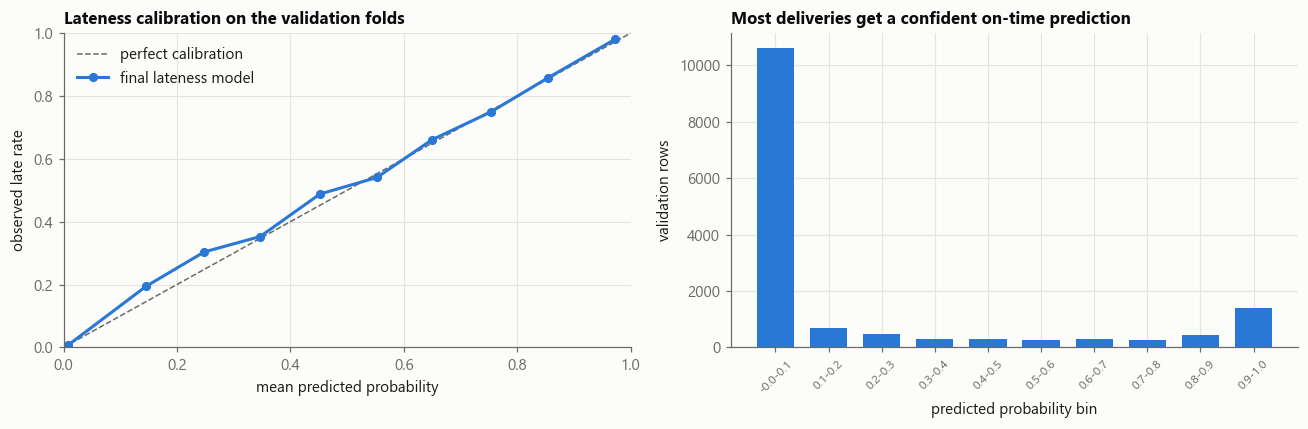

,n,mean_pred,observed
bin,,,
"(-0.001, 0.1]",10612,0.0081,0.0074
"(0.1, 0.2]",683,0.1459,0.1947
"(0.2, 0.3]",461,0.2480,0.3037
"(0.3, 0.4]",312,0.3466,0.3526
"(0.4, 0.5]",293,0.4522,0.4881
"(0.5, 0.6]",246,0.5526,0.5407
"(0.6, 0.7]",295,0.6501,0.6610
"(0.7, 0.8]",267,0.7535,0.7491
"(0.8, 0.9]",429,0.8544,0.8578


In [43]:
EAF = pd.concat([VALID[f].assign(p_late=PRED["FINAL late (3 seeds)"][f], p_svc=PRED["FINAL svc blend (3 seeds)"][f],
                                 p_svc_before=PRED["M3 svc blend"][f]) for f in FOLD_NAMES])
EAF["size_quintile"] = EAF.groupby("brand").order_units.transform(lambda s: pd.qcut(s, 5, labels=False, duplicates="drop"))
EAF["err_before"], EAF["err_final"] = EAF.p_svc_before - EAF.service_min, EAF.p_svc - EAF.service_min
EAF["abs_before"], EAF["abs_final"] = EAF.err_before.abs(), EAF.err_final.abs()
by_brand = EAF.groupby("brand").agg(n=("service_min", "size"), MAE_before=("abs_before", "mean"), MAE_final=("abs_final", "mean"),
                                    bias_before=("err_before", "mean"), bias_final=("err_final", "mean"))
reduction = (EAF.abs_before - EAF.abs_final).groupby(EAF.brand).sum()
by_brand["share_of_total_error_reduction"] = reduction / reduction.sum()
print("Service error by brand: tuned blend (before) vs final model"); display(by_brand)
big = EAF[EAF.brand.isin(["Style", "Tech"])].groupby(["brand", "size_quintile"]).agg(
    n=("service_min", "size"), bias_before=("err_before", "mean"), bias_final=("err_final", "mean"),
    MAE_before=("abs_before", "mean"), MAE_final=("abs_final", "mean"))
print("Style and Tech service error by order-size quintile: tuned blend (before) vs final model"); display(big)

rel = reliability_table(EAF.is_late, EAF.p_late)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot([0, 1], [0, 1], color=C_MUTED, linewidth=1, linestyle="--", label="perfect calibration")
ax[0].plot(rel.mean_pred, rel.observed, marker="o", color=C_BLUE, label="final lateness model")
ax[0].set(title="Lateness calibration on the validation folds", xlabel="mean predicted probability",
          ylabel="observed late rate", xlim=(0, 1), ylim=(0, 1)); ax[0].legend()
ax[1].bar(range(len(rel)), rel.n, color=C_BLUE, width=0.7)
ax[1].set_xticks(range(len(rel))); ax[1].set_xticklabels([f"{i.left:.1f}-{i.right:.1f}" for i in rel.index], rotation=45, fontsize=8)
ax[1].set(title="Most deliveries get a confident on-time prediction", xlabel="predicted probability bin", ylabel="validation rows")
plt.tight_layout(); plt.show()
display(rel)

**Reading the results.** The submitted configuration is the best of the three on every fold, for lateness log loss and for service MAE. Most of the service-time gain from size-scaled history comes from Fresh orders (93% of the total error reduction), because Fresh is 95% of all orders. For Style and Tech the change is mixed, and the largest Tech orders remain under-predicted by about 12 minutes. These are rare (43 validation orders in the top size quintile) with very variable handling times, and they are the main known weakness. Lateness probabilities lie close to the diagonal overall (ECE 0.009). Between 0.1 and 0.3 they run a few points low, but post-hoc recalibration did not improve log loss (§6.6), so none is applied.

### 6.11 Confirmation on two folds that no decision used
Every setting above (configuration search, feature gates, blend weight) was chosen on folds F1–F3, so their scores
could flatter the model slightly. Two further six-week folds in the 2025 monsoon, **U1 (9 Jun – 19 Jul)** and **U2
(21 Jul – 30 Aug)**, were never used for any choice. The final configuration is trained on everything before each fold
start, with the same protocol and three seeds, and scored on the fold next to the two status-quo rules.

In [44]:
UNSEEN_FOLDS = [("U1_2025_JunJul", "2025-06-09", "2025-07-19"), ("U2_2025_JulAug", "2025-07-21", "2025-08-30")]
UNSEEN_PRED, unseen_rows = {}, []
t0 = time.time()
for name, start, end in UNSEEN_FOLDS:
    s, e = pd.Timestamp(start), pd.Timestamp(end)
    tr_idx = train_s.index[train_s.date < s]
    va_idx = train_s.index[(train_s.date >= s) & (train_s.date <= e)]
    v = t1_build_features(train_s.loc[va_idx], hist, pd.Series(s, index=va_idx))
    p_l = np.mean([fit("late", T1_GRID.loc[tr_idx], FEATS_LATE, params={**LATE_CFG, **LR, "seed": sd}, eval_frames=[v])["eval_final"][0]
                   for sd in SEEDS], axis=0)
    p_lg = np.mean([fit("svc_l2log", T1_GRID.loc[tr_idx], FEATS_SVC, params={**SVC_CFG, **LR, "seed": sd}, eval_frames=[v])["eval_final"][0]
                    for sd in SEEDS], axis=0)
    p_l2 = np.mean([fit("svc_l2", T1_GRID.loc[tr_idx], FEATS_SVC, params={**SVC_CFG, **LR, "seed": sd}, eval_frames=[v])["eval_final"][0]
                    for sd in SEEDS], axis=0)
    p_s = np.clip(W_LOG * p_lg + (1 - W_LOG) * p_l2, 0.5, None)
    plan_verdict = group_rate(bl.loc[tr_idx], bl.loc[va_idx], ["planned_late"])
    UNSEEN_PRED[name] = v.assign(p_late=p_l, p_svc=p_s)
    y_s, y_l = v.service_min.to_numpy(float), v.is_late.to_numpy()
    rs, rl = reg_metrics(y_s, p_s), clf_metrics(y_l, p_l)
    unseen_rows.append({"fold": name, "rows": len(v), "service MAE": rs["MAE"], "allowance MAE": reg_metrics(y_s, v.service_allowance_min)["MAE"],
                        "service RMSE": rs["RMSE"], "late log loss": rl["logloss"],
                        "plan's verdict log loss": clf_metrics(y_l, plan_verdict)["logloss"], "late AUC": rl["AUC"],
                        "Brier": rl["Brier"], "ECE": rl["ECE"]})
UNSEEN_TBL = pd.DataFrame(unseen_rows).set_index("fold")
UNSEEN_TBL.loc["mean"] = UNSEEN_TBL.mean()
sel = leaderboard("service", ["MAE", "RMSE"], "MAE", experiments=["FINAL svc blend (3 seeds)"]).iloc[0]
sel_l = leaderboard("late", ["logloss", "AUC"], "logloss", experiments=["FINAL late (3 seeds)"]).iloc[0]
print(f"unseen folds scored in {time.time() - t0:.0f}s")
print(f"tuning folds F1-F3 (mean): service MAE {sel.mean_MAE:.3f}, RMSE {sel.mean_RMSE:.3f} | late log loss {sel_l.mean_logloss:.4f}, AUC {sel_l.mean_AUC:.4f}")
print(f"unseen folds U1-U2 (mean): service MAE {UNSEEN_TBL.loc['mean', 'service MAE']:.3f}, RMSE {UNSEEN_TBL.loc['mean', 'service RMSE']:.3f} | "
      f"late log loss {UNSEEN_TBL.loc['mean', 'late log loss']:.4f}, AUC {UNSEEN_TBL.loc['mean', 'late AUC']:.4f}")
UNSEEN_TBL

unseen folds scored in 78s
tuning folds F1-F3 (mean): service MAE 3.895, RMSE 6.166 | late log loss 0.1432, AUC 0.9787
unseen folds U1-U2 (mean): service MAE 3.884, RMSE 6.132 | late log loss 0.1395, AUC 0.9781


,rows,service MAE,allowance MAE,service RMSE,late log loss,plan's verdict log loss,late AUC,Brier,ECE
fold,,,,,,,,,
U1_2025_JunJul,"5,002.0000",3.8491,6.8465,5.9636,0.1488,0.5062,0.9790,0.0470,0.0087
U2_2025_JulAug,"5,042.0000",3.9184,7.5827,6.3005,0.1301,0.4050,0.9772,0.0404,0.0059
mean,"5,022.0000",3.8837,7.2146,6.1321,0.1395,0.4556,0.9781,0.0437,0.0073


**Reading the results.** On the two folds that no decision touched, the final model scores as well as on the tuning
folds, so the selection did not overfit them. It again roughly halves the error of the planning allowance, and its
lateness log loss is less than a third of the plan's own verdict.

### 6.12 Validation summary on all five folds

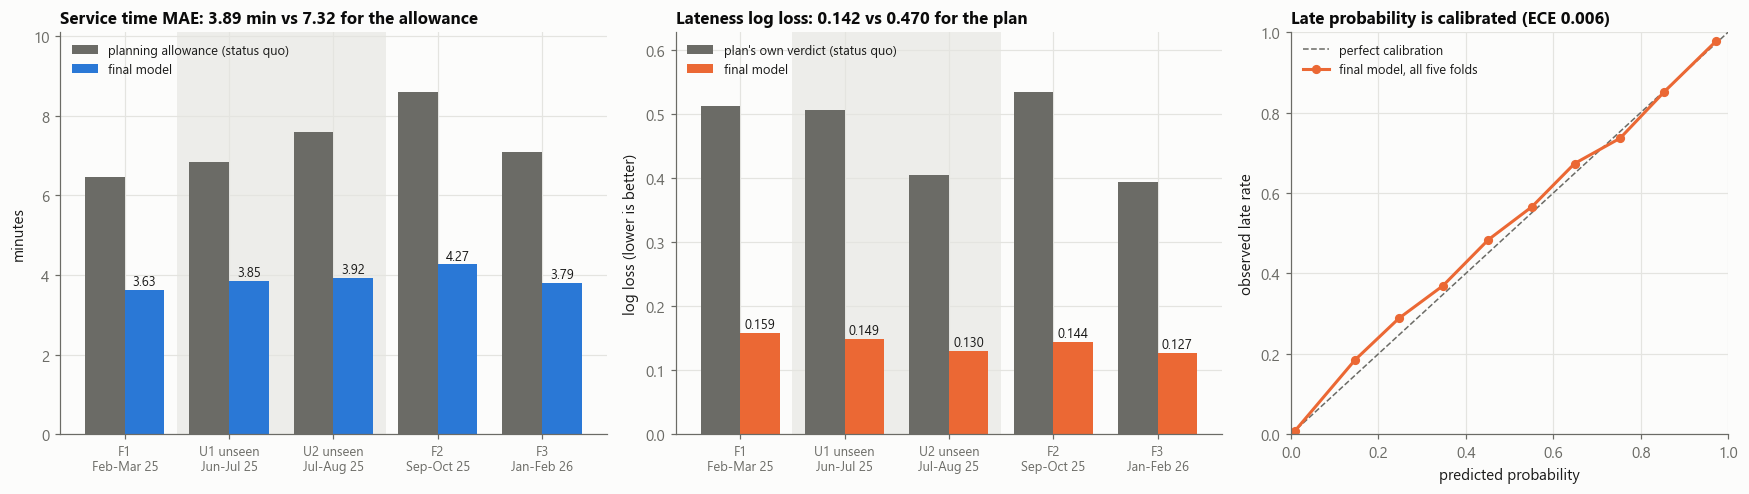

shaded: folds no decision used


,allow,mae,plan,ll
fold,,,,
F1_2025_FebMar,6.4705,3.6255,0.5122,0.1585
U1_2025_JunJul,6.8465,3.8491,0.5062,0.1488
U2_2025_JulAug,7.5827,3.9184,0.4050,0.1301
F2_2025_SepOct,8.5911,4.2661,0.5341,0.1437
F3_2026_JanFeb,7.0949,3.7935,0.3948,0.1273


In [45]:
def task1_results_figure(path):
    rows = []
    for f in FOLD_NAMES:
        y_s, y_l = VALID[f].service_min.to_numpy(float), VALID[f].is_late.to_numpy()
        log = pd.DataFrame(RESULTS)
        get = lambda exp, tgt, met: float(log[(log.experiment == exp) & (log.target == tgt) & (log.fold == f)][met].iloc[0])
        rows.append({"fold": f, "allow": get("S1 planning allowance (status quo)", "service", "MAE"),
                     "mae": reg_metrics(y_s, PRED["FINAL svc blend (3 seeds)"][f])["MAE"],
                     "plan": get("L1 plan's own verdict (status quo)", "late", "logloss"),
                     "ll": clf_metrics(y_l, PRED["FINAL late (3 seeds)"][f])["logloss"]})
    for name, _, _ in UNSEEN_FOLDS:
        r = UNSEEN_TBL.loc[name]
        rows.append({"fold": name, "allow": r["allowance MAE"], "mae": r["service MAE"], "plan": r["plan's verdict log loss"],
                     "ll": r["late log loss"]})
    t = pd.DataFrame(rows).set_index("fold").loc[["F1_2025_FebMar", "U1_2025_JunJul", "U2_2025_JulAug", "F2_2025_SepOct", "F3_2026_JanFeb"]]
    labels = ["F1\nFeb-Mar 25", "U1 unseen\nJun-Jul 25", "U2 unseen\nJul-Aug 25", "F2\nSep-Oct 25", "F3\nJan-Feb 26"]
    y_all = np.concatenate([VALID[f].is_late.to_numpy() for f in FOLD_NAMES] + [UNSEEN_PRED[n].is_late.to_numpy() for n, _, _ in UNSEEN_FOLDS])
    p_all = np.concatenate([PRED["FINAL late (3 seeds)"][f] for f in FOLD_NAMES] + [UNSEEN_PRED[n].p_late.to_numpy() for n, _, _ in UNSEEN_FOLDS])
    rel = reliability_table(y_all, p_all)
    fig, ax = plt.subplots(1, 3, figsize=(16, 4.6), gridspec_kw={"width_ratios": [1.25, 1.25, 1]})
    x, w = np.arange(len(t)), 0.38
    for a in ax[:2]:
        a.axvspan(0.5, 2.5, color=C_GRID, alpha=0.6, lw=0, zorder=0)
    ax[0].bar(x - w / 2, t.allow, w, color=C_MUTED, label="planning allowance (status quo)")
    ax[0].bar(x + w / 2, t.mae, w, color=C_BLUE, label="final model")
    for i, (a_, m_) in enumerate(zip(t.allow, t.mae)):
        ax[0].text(i + w / 2, m_ + 0.12, f"{m_:.2f}", ha="center", fontsize=8.5, color=C_INK)
    ax[0].set(title=f"Service time MAE: {t.mae.mean():.2f} min vs {t.allow.mean():.2f} for the allowance", ylabel="minutes")
    ax[1].bar(x - w / 2, t.plan, w, color=C_MUTED, label="plan's own verdict (status quo)")
    ax[1].bar(x + w / 2, t.ll, w, color=C_ORANGE, label="final model")
    for i, l_ in enumerate(t.ll):
        ax[1].text(i + w / 2, l_ + 0.008, f"{l_:.3f}", ha="center", fontsize=8.5, color=C_INK)
    ax[1].set(title=f"Lateness log loss: {t.ll.mean():.3f} vs {t.plan.mean():.3f} for the plan", ylabel="log loss (lower is better)")
    for a in ax[:2]:
        a.set_xticks(x); a.set_xticklabels(labels, fontsize=8.5); a.legend(fontsize=8.5, loc="upper left")
        a.set_ylim(0, a.get_ylim()[1] * 1.12)
    ax[2].plot([0, 1], [0, 1], color=C_MUTED, lw=1, ls="--", label="perfect calibration")
    ax[2].plot(rel.mean_pred, rel.observed, marker="o", color=C_ORANGE, label="final model, all five folds")
    ax[2].set(title=f"Late probability is calibrated (ECE {ece(y_all, p_all):.3f})", xlabel="predicted probability",
              ylabel="observed late rate", xlim=(0, 1), ylim=(0, 1))
    ax[2].legend(fontsize=8.5, loc="upper left")
    fig.tight_layout()
    fig.savefig(path, dpi=150, bbox_inches="tight")
    return fig, t

fig, FIVE_FOLDS = task1_results_figure(FIG_DIR / "task1_results.png")
plt.show()
print("shaded: folds no decision used")
FIVE_FOLDS.round(4)

## 7. Task 1 · final training, submission and saved models
The final specification, assembled from the decisions above:

In [46]:
FINAL_SPEC = pd.DataFrame([
    ("Lateness model", f"LightGBM binary, {LATE_CFG}, learning rate 0.03, seeds {SEEDS}, averaged; no calibration"),
    ("Lateness features", f"{len(FEATS_LATE)} features (size-scaled history and size-aware ETA: {USE_ETA2})"),
    ("Service model", f"{W_LOG:g} x log-target LightGBM + {1 - W_LOG:g} x squared-error LightGBM, {SVC_CFG}, learning rate 0.03, seeds {SEEDS}"),
    ("Service features", f"{len(FEATS_SVC)} features (size-scaled history: {USE_SIZE})"),
    ("Road disruption", "used (reference table supplied for every date)"),
    ("History cutoff for the test", str(TEST_START.date())),
], columns=["component", "specification"]).set_index("component")
with pd.option_context("display.max_colwidth", 200):
    display(FINAL_SPEC)

,specification
component,
Lateness model,"LightGBM binary, {'num_leaves': 31, 'min_data_in_leaf': 20, 'feature_fraction': 0.5, 'bagging_fraction': 0.9, 'lambda_l2': 10.0, 'min_gain_to_split': 0.0}, learning rate 0.03, seeds (42, 7, 2024),..."
Lateness features,96 features (size-scaled history and size-aware ETA: True)
Service model,"0.75 x log-target LightGBM + 0.25 x squared-error LightGBM, {'num_leaves': 15, 'min_data_in_leaf': 20, 'feature_fraction': 0.9, 'bagging_fraction': 0.9, 'lambda_l2': 10.0, 'min_gain_to_split': 0.0..."
Service features,91 features (size-scaled history: True)
Road disruption,used (reference table supplied for every date)
History cutoff for the test,2026-02-16


Training uses all labelled data with the validation protocol: early stopping on the last six weeks of training (5 Jan – 14 Feb 2026), then a refit on everything with 1.1 × the best iteration count, for each seed.

In [47]:
t0 = time.time()
MODELS = {"late": [], "svc_l2log": [], "svc_l2": []}
TEST_PRED = {"late": [], "svc_l2log": [], "svc_l2": []}
ITERS, IMPORTANCE = {}, {}
for kind, feats, cfg in [("late", FEATS_LATE, LATE_CFG), ("svc_l2log", FEATS_SVC, SVC_CFG), ("svc_l2", FEATS_SVC, SVC_CFG)]:
    for s in SEEDS:
        out = fit(kind, T1_GRID, feats, params={**cfg, **LR, "seed": s}, eval_frames=[TEST], keep_model=True)
        MODELS[kind].append(out["model"]); TEST_PRED[kind].append(out["eval_final"][0])
        ITERS.setdefault(kind, []).append(out["best_iter"]); IMPORTANCE.setdefault(kind, []).append(out["importance"])
print(f"final models trained in {time.time() - t0:.0f}s | best iterations {ITERS}")

p_late = np.clip(np.mean(TEST_PRED["late"], axis=0), 0, 1)
p_svc = np.clip(W_LOG * np.mean(TEST_PRED["svc_l2log"], axis=0) + (1 - W_LOG) * np.mean(TEST_PRED["svc_l2"], axis=0), 0.5, None)
PRED_TEST = pd.DataFrame({"delivery_id": TEST.delivery_id.to_numpy(), "pred_service_min": p_svc, "pred_late_prob": p_late},
                         index=TEST.index)

final models trained in 69s | best iterations {'late': [462, 582, 536], 'svc_l2log': [541, 664, 566], 'svc_l2': [752, 1124, 1042]}


### 7.1 Sanity checks
The test has no labels, so predictions are compared with the same calendar window of earlier years (§3.6).

In [48]:
assert PRED_TEST[["pred_service_min", "pred_late_prob"]].notna().all().all()
assert PRED_TEST.pred_late_prob.between(0, 1).all() and (PRED_TEST.pred_service_min > 0).all()
print(f"mean predicted late probability: {p_late.mean():.4f}   (same window: 2024 {ANALOGUE.loc['late_rate', 2024]:.3f}, "
      f"2025 {ANALOGUE.loc['late_rate', 2025]:.3f})")
print(f"mean predicted service time:     {p_svc.mean():.3f}  (same window mean: 2024 {ANALOGUE.loc['service_mean', 2024]:.1f}, "
      f"2025 {ANALOGUE.loc['service_mean', 2025]:.1f})")
print(f"mean disagreement between seeds on the late probability: {np.std(TEST_PRED['late'], axis=0).mean():.4f}")
chk = TEST.assign(p_late=p_late, p_svc=p_svc)
display(chk.groupby("brand").agg(n=("p_late", "size"), p_late=("p_late", "mean"), p_svc=("p_svc", "mean"),
                                 allowance=("service_allowance_min", "mean")))
display(chk.groupby("monsoon").agg(n=("p_late", "size"), p_late=("p_late", "mean"), p_svc=("p_svc", "mean")))
display(chk.groupby("seq_c").agg(n=("p_late", "size"), p_late=("p_late", "mean")))

mean predicted late probability: 0.2175   (same window: 2024 0.204, 2025 0.214)
mean predicted service time:     18.357  (same window mean: 2024 17.0, 2025 17.8)
mean disagreement between seeds on the late probability: 0.0037


,n,p_late,p_svc,allowance
brand,,,,
Fresh,4776,0.2260,16.5907,15.3124
Style,150,0.0559,50.2734,48.7600
Tech,88,0.0283,59.8242,50.0909


,n,p_late,p_svc
monsoon,,,
0,1679,0.1385,16.9936
1,3335,0.2572,19.0437


,n,p_late
seq_c,,
0,1381,0.0941
1,1173,0.1549
2,892,0.1767
3,674,0.2474
4,416,0.3559
5,294,0.5682
6,123,0.7117
7,44,0.7881
8,17,0.9978


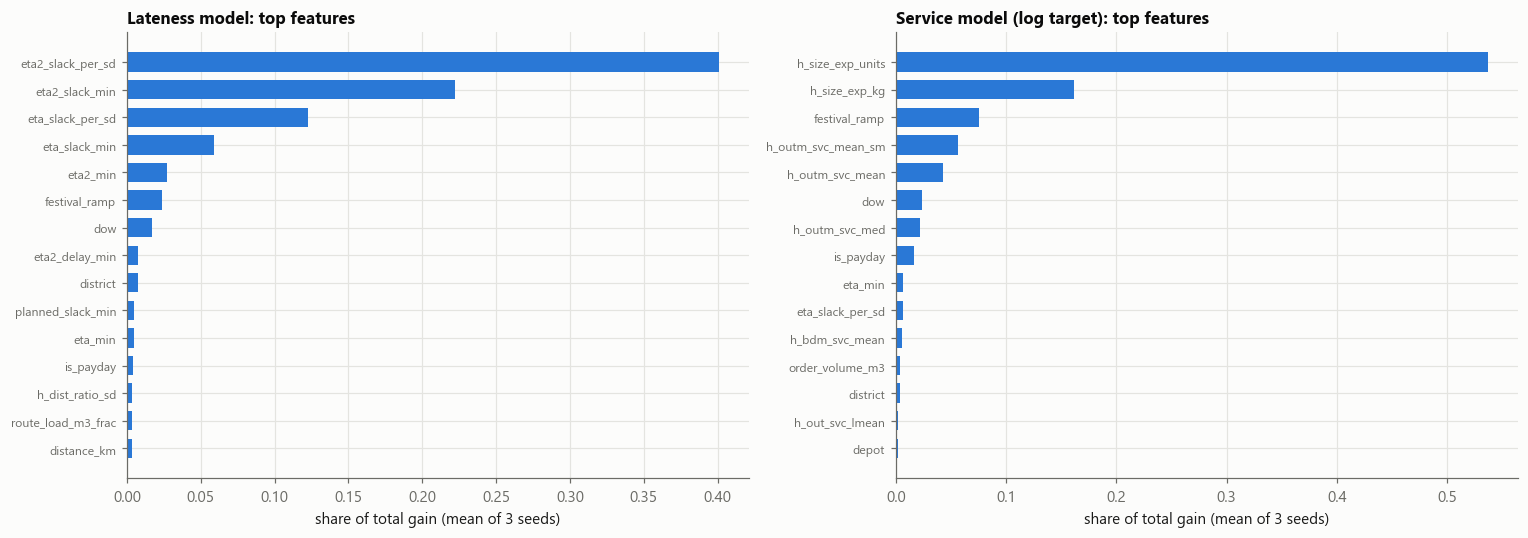

In [49]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for i, (kind, title) in enumerate([("late", "Lateness model: top features"), ("svc_l2log", "Service model (log target): top features")]):
    imp = pd.concat(IMPORTANCE[kind], axis=1).mean(axis=1)
    imp = (imp / imp.sum()).sort_values().tail(15)
    ax[i].barh(imp.index, imp.values, color=C_BLUE, height=0.7)
    ax[i].set(title=title, xlabel="share of total gain (mean of 3 seeds)")
    ax[i].tick_params(axis="y", labelsize=8)
plt.tight_layout(); plt.show()

### 7.2 Submission file
Rows follow the template order and identifiers are unchanged.

In [50]:
template = pd.read_csv(find_file(FILES["submission"]), dtype={"delivery_id": str})
sub = template[["delivery_id"]].merge(PRED_TEST, on="delivery_id", how="left", validate="one_to_one")
assert len(sub) == len(template) and sub.delivery_id.tolist() == template.delivery_id.tolist()
assert sub[["pred_service_min", "pred_late_prob"]].notna().all().all()
sub["pred_service_min"] = sub.pred_service_min.round(3)
sub["pred_late_prob"] = sub.pred_late_prob.round(5)
assert sub.pred_late_prob.between(0, 1, inclusive="neither").all()      # no probabilities of exactly 0 or 1
sub.to_csv(SUBMISSION_PATH, index=False)
print("wrote", SUBMISSION_PATH, sub.shape)
sub.head()

wrote D:\Documents\Project\rootcode\Datathon\submissions\submission_task1.csv (5014, 3)


,delivery_id,pred_service_min,pred_late_prob
0,ORD0092308,8.1480,0.0001
1,ORD0092309,7.4590,0.0002
2,ORD0092310,11.9950,0.0001
3,ORD0092311,11.1240,0.0007
4,ORD0092312,12.9490,0.0048


### 7.3 Saved models
Nine LightGBM model files (three seeds for each of the three models) and a manifest with everything needed to rebuild the features and predict.

In [51]:
def save_bundle(model_dir, models, manifest):
    model_dir = Path(model_dir); model_dir.mkdir(parents=True, exist_ok=True)
    files = {}
    for kind, boosters in models.items():
        files[kind] = []
        for i, b in enumerate(boosters):
            fname = f"{kind}_m{i}.txt"; b.save_model(str(model_dir / fname)); files[kind].append(fname)
    manifest = {**manifest, "files": files}
    (model_dir / "manifest.json").write_text(json.dumps(manifest, indent=1, default=str))
    return manifest

def load_bundle(model_dir):
    model_dir = Path(model_dir)
    manifest = json.loads((model_dir / "manifest.json").read_text())
    models = {k: [lgb.Booster(model_file=str(model_dir / f)) for f in fs] for k, fs in manifest["files"].items()}
    return manifest, models

manifest = save_bundle(MODEL_DIR, MODELS, {
    "task": "Task 1: service time and lateness", "created": time.strftime("%Y-%m-%d %H:%M:%S"),
    "lightgbm": lgb.__version__, "python": platform.python_version(), "pandas": pd.__version__,
    "use_disruption": True, "use_size_features": USE_SIZE, "use_size_eta_for_late": USE_ETA2,
    "size_eta_weight": SIZE_ETA_WEIGHT, "history_cutoff": str(TEST_START.date()), "seeds": list(SEEDS),
    "blend_weight_log_model": W_LOG, "late_params": LATE_CFG, "service_params": SVC_CFG, "best_iterations": ITERS,
    "features": {"late": FEATS_LATE, "service": FEATS_SVC}, "categories": {k: list(map(str, v)) for k, v in CATS.items()},
})
pd.DataFrame(RESULTS).to_csv(OUT_DIR / "experiment_log.csv", index=False)
print("saved", sum(len(v) for v in manifest["files"].values()), "model files and manifest.json to", MODEL_DIR)
print("saved experiment log to", OUT_DIR / "experiment_log.csv")

saved 9 model files and manifest.json to D:\Documents\Project\rootcode\Datathon\models\task1
saved experiment log to D:\Documents\Project\rootcode\Datathon\outputs\task1\experiment_log.csv


The same nine models are also saved as **one pickle file**, `models/task1_model.pkl`, in the same form as the Task 2A model file: a dictionary with the manifest and the LightGBM boosters. Either copy can be used; §26 loads the pickle and checks that it predicts exactly like the text files.

In [52]:
with open(MODELS_DIR / "task1_model.pkl", "wb") as fh:
    pickle.dump({"manifest": manifest, "models": MODELS}, fh)
with open(MODELS_DIR / "task1_model.pkl", "rb") as fh:
    _check = pickle.load(fh)
assert {k: len(v) for k, v in _check["models"].items()} == {k: len(v) for k, v in MODELS.items()}
print(f"saved {MODELS_DIR / 'task1_model.pkl'} ({(MODELS_DIR / 'task1_model.pkl').stat().st_size / 1e6:.1f} MB): "
      f"{sum(len(v) for v in MODELS.values())} LightGBM boosters + manifest")

saved D:\Documents\Project\rootcode\Datathon\models\task1_model.pkl (14.0 MB): 9 LightGBM boosters + manifest


### 7.4 Results summary
Mean over the three time-based validation folds. The first row of each table is what Waypoint uses today.

In [53]:
def ladder(target, rows, cols):
    lb = leaderboard(target, cols, cols[0], experiments=[e for _, e in rows])
    nf = leaderboard(target + "_nofest", cols[:1], cols[0], experiments=[e for _, e in rows])
    out = pd.DataFrame([{"model": label, **{c: lb.loc[e, f"mean_{c}"] for c in cols},
                         f"festival-free {cols[0]}": nf.loc[e, f"mean_{cols[0]}"] if e in nf.index else np.nan,
                         **{c_: lb.loc[e, c_] for c_ in lb.columns if c_.startswith(cols[0] + "_")}} for label, e in rows])
    return out.set_index("model")

LADDER_LATE = ladder("late", [
    ("Plan's own verdict (status quo)", "L1 plan's own verdict (status quo)"),
    ("Logistic regression on plan features", "L4 logistic regression"),
    ("LightGBM, base parameters", "M1 LGBM late"),
    ("LightGBM tuned, 3 seeds", "M3 late tuned, 3 seeds"),
    ("FINAL: + size history and size-aware ETA, 3 seeds", "FINAL late (3 seeds)")], ["logloss", "Brier", "AUC", "ECE"])
LADDER_SVC = ladder("service", [
    ("Planning allowance (status quo)", "S1 planning allowance (status quo)"),
    ("Outlet x monsoon median", "S4 outlet x monsoon median"),
    ("Ridge regression, log target", "S5 ridge, log target (median)"),
    ("LightGBM, base parameters, log target", "M1 LGBM svc log target"),
    ("LightGBM tuned blend, 3 seeds", "M3 svc blend"),
    ("FINAL: + size history, 3 seeds", "FINAL svc blend (3 seeds)")], ["MAE", "RMSE", "bias"])
print("LATENESS (lower log loss and Brier are better)"); display(LADDER_LATE)
print("SERVICE TIME (minutes)"); display(LADDER_SVC)
s_l, f_l = LADDER_LATE.iloc[0], LADDER_LATE.iloc[-1]
s_s, f_s = LADDER_SVC.iloc[0], LADDER_SVC.iloc[-1]
print(f"Lateness log loss {s_l.logloss:.4f} -> {f_l.logloss:.4f} ({100 * (f_l.logloss / s_l.logloss - 1):+.0f}%), "
      f"AUC {s_l.AUC:.3f} -> {f_l.AUC:.3f}")
print(f"Service MAE {s_s.MAE:.2f} -> {f_s.MAE:.2f} min ({100 * (f_s.MAE / s_s.MAE - 1):+.0f}%), "
      f"RMSE {s_s.RMSE:.2f} -> {f_s.RMSE:.2f} min ({100 * (f_s.RMSE / s_s.RMSE - 1):+.0f}%)")
print(f"\nNotebook runtime: {(time.time() - NOTEBOOK_START) / 60:.1f} min")

LATENESS (lower log loss and Brier are better)


,logloss,Brier,AUC,ECE,festival-free logloss,logloss_F1,logloss_F2,logloss_F3
model,,,,,,,,
Plan's own verdict (status quo),0.4804,0.1515,0.5151,0.0424,0.4589,0.5122,0.5341,0.3948
Logistic regression on plan features,0.2524,0.0782,0.9304,0.0162,0.2393,0.2776,0.2748,0.2048
"LightGBM, base parameters",0.1468,0.0464,0.9776,0.0093,0.1403,0.1609,0.1481,0.1313
"LightGBM tuned, 3 seeds",0.1457,0.0460,0.9780,0.0083,0.1390,0.1604,0.1471,0.1295
"FINAL: + size history and size-aware ETA, 3 seeds",0.1432,0.0452,0.9787,0.0089,0.1368,0.1585,0.1437,0.1273


SERVICE TIME (minutes)


,MAE,RMSE,bias,festival-free MAE,MAE_F1,MAE_F2,MAE_F3
model,,,,,,,
Planning allowance (status quo),7.3855,11.9022,-2.1136,6.4569,6.4705,8.5911,7.0949
Outlet x monsoon median,5.4823,9.3564,-2.0379,4.4899,4.6296,6.4805,5.3369
"Ridge regression, log target",4.6590,7.5505,-0.9024,3.9649,4.0071,5.3326,4.6373
"LightGBM, base parameters, log target",3.9895,6.3385,-0.4618,3.6282,3.7066,4.3557,3.9061
"LightGBM tuned blend, 3 seeds",3.9645,6.2255,-0.3534,3.6321,3.7119,4.3117,3.8698
"FINAL: + size history, 3 seeds",3.8950,6.1660,-0.4590,3.5658,3.6255,4.2661,3.7935


Lateness log loss 0.4804 -> 0.1432 (-70%), AUC 0.515 -> 0.979
Service MAE 7.39 -> 3.90 min (-47%), RMSE 11.90 -> 6.17 min (-48%)

Notebook runtime: 19.3 min


The saved models are reloaded, the test features rebuilt from the raw files and the predictions printed in the final cell of the notebook (§26).

In [54]:
# Part A used its own chart style and display options; restore the shared ones for Parts B-D.
mpl.rcParams.update(STYLE)
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

# Part B · Task 2A: weekly depot demand forecast

## 8. Data inventory

Task 2A forecasts **demand**: what stores order, not what was delivered. So only the order records and the calendar
carry signal.

| File | Rows | Used | Why |
|---|---|---|---|
| `Training Data/deliveries_train.csv` | 92,307 | ✅ | Order history, 1 Jan 2024 → 14 Feb 2026 |
| `Test Data/task1_test_inputs.csv` | 5,014 | ✅ | The most recent 6 weeks of orders (16 Feb → 28 Mar 2026). The brief asks us to use it, and it closes the gap to the forecast start |
| `General Data/calendar.csv` | 910 | ✅ | ISO weeks, operating days, paydays, festivals and festival ramp. It covers the forecast weeks, so these are *known-in-advance* features |
| `General Data/outlets.csv` | 120 | ✅ | Outlet → brand / depot master data (consistency check) |
| `Test Data/task2a_test_inputs.csv` | 60 | ✅ | The 60 rows to forecast |
| Route legs, vehicles, traffic speed, road conditions, district travel, service allowance | – | ❌ | Describe *delivery*, not ordering. Road disruption is checked in §11.6 and has no effect on demand |

From each order we need only `order_date`, `outlet_id`, `brand`, `depot`, `temp_requirement` and `order_volume_m3`.

In [55]:
def add_festival_features(cal):
    """Name of the festival a ramp is building towards, and days since the
    most recent festival (for the post-festival dip)."""
    cal = cal.sort_values("date").reset_index(drop=True)
    fest = cal.loc[cal.festival.notna(), ["date", "festival"]]

    nxt = pd.merge_asof(cal[["date"]], fest.rename(columns={"date": "fest_date"}),
                        left_on="date", right_on="fest_date", direction="forward")
    cal["ramp_festival"] = np.where(cal.festival_ramp > 0, nxt.festival, "none")

    prv = pd.merge_asof(cal[["date"]], fest.rename(columns={"date": "fest_date"}),
                        left_on="date", right_on="fest_date", direction="backward",
                        allow_exact_matches=False)
    since = (cal.date - prv.fest_date).dt.days
    cal["days_since_festival"] = since.fillna(999).astype(int)
    cal["post_festival"] = ((since >= 1) & (since <= POST_FEST_DAYS)
                            & (cal.festival_ramp == 0)).astype(int)
    cal["post_festival_name"] = np.where(cal.post_festival == 1, prv.festival, "none")

    # The payday lift carries over to the following days, not just the payday.
    pay = cal.loc[cal.is_payday == 1, ["date"]].rename(columns={"date": "pay_date"})
    lastpay = pd.merge_asof(cal[["date"]], pay, left_on="date", right_on="pay_date",
                            direction="backward")
    cal["days_since_payday"] = (cal.date - lastpay.pay_date).dt.days.fillna(99).astype(int)
    return cal


def load_calendar():
    cal = pd.read_csv(DATA / "General Data" / "calendar.csv", parse_dates=["date"])
    cal["yw"] = cal.iso_year * 100 + cal.iso_week
    return add_festival_features(cal)


def load_orders(cal=None):
    """All orders (train + Task 1 test inputs), one row per order.

    Every order is kept regardless of dispatch_status (attempted, deferred,
    not_run) because each one is demand. Orders are bucketed by order_date,
    the day the store requested, not by dispatch_date.
    """
    if cal is None:
        cal = load_calendar()
    tr = pd.read_csv(DATA / "Training Data" / "deliveries_train.csv")
    te = pd.read_csv(DATA / "Test Data" / "task1_test_inputs.csv")
    orders = pd.concat([tr.assign(source="train"), te.assign(source="task1_test")],
                       ignore_index=True)
    orders = orders.drop_duplicates("delivery_id")
    orders["date"] = pd.to_datetime(orders.order_date)
    return orders.merge(cal, on="date", how="left", validate="many_to_one")

In [56]:
cal = load_calendar()
raw_train = pd.read_csv(DATA / "Training Data" / "deliveries_train.csv")
raw_test1 = pd.read_csv(DATA / "Test Data" / "task1_test_inputs.csv")
outlets = pd.read_csv(DATA / "General Data" / "outlets.csv")
t2a_inputs = pd.read_csv(DATA / "Test Data" / "task2a_test_inputs.csv")
orders = load_orders(cal)

inventory = pd.DataFrame([
    ("deliveries_train.csv", len(raw_train), raw_train.order_date.min(), raw_train.order_date.max()),
    ("task1_test_inputs.csv", len(raw_test1), raw_test1.order_date.min(), raw_test1.order_date.max()),
    ("orders (combined)", len(orders), orders.date.min().date(), orders.date.max().date()),
    ("calendar.csv", len(cal), cal.date.min().date(), cal.date.max().date()),
    ("task2a_test_inputs.csv", len(t2a_inputs), "2026 W" + str(t2a_inputs.iso_week.min()),
     "2026 W" + str(t2a_inputs.iso_week.max()))], columns=["dataset", "rows", "from", "to"])
display(inventory)
display(orders[["delivery_id", "order_date", "outlet_id", "brand", "depot", "temp_requirement",
                "order_units", "order_volume_m3", "dispatch_status", "source"]].head())

,dataset,rows,from,to
0,deliveries_train.csv,92307,2024-01-01,2026-02-14
1,task1_test_inputs.csv,5014,2026-02-16,2026-03-28
2,orders (combined),97321,2024-01-01,2026-03-28
3,calendar.csv,910,2024-01-01,2026-06-28
4,task2a_test_inputs.csv,60,2026 W14,2026 W23


,delivery_id,order_date,outlet_id,brand,depot,temp_requirement,order_units,order_volume_m3,dispatch_status,source
0,ORD0000001,2024-01-01,OUT001,Fresh,Peliyagoda,ambient,8,0.402,attempted,train
1,ORD0000002,2024-01-01,OUT002,Fresh,Peliyagoda,ambient,15,0.564,attempted,train
2,ORD0000003,2024-01-01,OUT003,Fresh,Peliyagoda,ambient,15,0.552,attempted,train
3,ORD0000004,2024-01-01,OUT004,Fresh,Peliyagoda,ambient,35,1.206,attempted,train
4,ORD0000005,2024-01-01,OUT005,Fresh,Peliyagoda,ambient,54,2.028,attempted,train


## 9. Data quality checks

Before modelling, each assumption the pipeline relies on is verified explicitly.

In [57]:
o = orders
chk = []
def check(name, ok, detail=""):
    chk.append({"check": name, "result": "PASS" if ok else "FAIL", "detail": detail})

check("delivery_id unique within train", raw_train.delivery_id.is_unique)
check("delivery_id unique within task1 test", raw_test1.delivery_id.is_unique)
check("no delivery_id shared by train and test",
      len(set(raw_train.delivery_id) & set(raw_test1.delivery_id)) == 0)
check("one order per outlet x date x temperature",
      not o.duplicated(["outlet_id", "order_date", "temp_requirement"]).any())
check("no nulls in demand columns",
      o[["order_date", "outlet_id", "brand", "depot", "temp_requirement", "order_volume_m3"]].notna().all().all())
check("order volume strictly positive", (o.order_volume_m3 > 0).all(),
      f"min {o.order_volume_m3.min():.3f} m3")
check("every order_date is in the calendar", o.iso_week.notna().all())
check("orders only on operating days", (o.is_operating == 1).all())
om = o.merge(outlets, on="outlet_id", suffixes=("", "_master"))
check("brand / district / depot match outlets.csv",
      (om.brand == om.brand_master).all() and (om.district == om.district_master).all()
      and (om.depot == om.depot_master).all())
check("chilled orders only for Fresh", set(o.loc[o.temp_requirement == "chilled", "brand"]) == {"Fresh"})
gap = pd.date_range(raw_train.order_date.max(), raw_test1.order_date.min())[1:-1]
check("train and task1 test are contiguous", all(cal.set_index("date").loc[gap, "is_operating"] == 0),
      f"gap days: {[d.strftime('%a %d %b') for d in gap]}")
horizon = cal[(cal.yw >= 202614) & (cal.yw <= 202623)]
check("calendar covers the forecast weeks", horizon.yw.nunique() == 10, f"{horizon.date.min().date()} -> {horizon.date.max().date()}")
check("task2a inputs = 2 depots x 3 brands x 10 weeks",
      len(t2a_inputs) == 60 and not t2a_inputs.duplicated(["depot", "brand", "iso_year", "iso_week"]).any())
raw_all = pd.concat([raw_train, raw_test1], ignore_index=True)
never = raw_all.dispatch_status == "not_run"
disp, ordd = pd.to_datetime(raw_all.dispatch_date), pd.to_datetime(raw_all.order_date)
check("dispatch_date is blank only for never-dispatched (not_run) orders", raw_all.dispatch_date.isna().eq(never).all())
check("dispatch_date is never before order_date", (disp[~never] >= ordd[~never]).all())
check("order_units and order_weight_kg are positive", ((raw_all.order_units > 0) & (raw_all.order_weight_kg > 0)).all())
iso = cal.date.dt.isocalendar()
check("calendar ISO year / week agree with the ISO standard", ((iso.year == cal.iso_year) & (iso.week == cal.iso_week)).all())
check("calendar is daily and gap-free", (cal.date.sort_values().diff().dropna() == pd.Timedelta(days=1)).all())
check("Sundays are never operating days", (cal.loc[cal.dow == 6, "is_operating"] == 0).all())
check("task1 test inputs hold no never-dispatched orders (6 weeks of history are slightly short)",
      (raw_test1.dispatch_status != "not_run").all(), "restored by the order-slot reconstruction, §12.2")
display(pd.DataFrame(chk))
assert all(c["result"] == "PASS" for c in chk), "a data-quality check failed"

,check,result,detail
0,delivery_id unique within train,PASS,
1,delivery_id unique within task1 test,PASS,
2,no delivery_id shared by train and test,PASS,
3,one order per outlet x date x temperature,PASS,
4,no nulls in demand columns,PASS,
5,order volume strictly positive,PASS,min 0.180 m3
6,every order_date is in the calendar,PASS,
7,orders only on operating days,PASS,
8,brand / district / depot match outlets.csv,PASS,
9,chilled orders only for Fresh,PASS,


In [58]:
# Dispatch fields are blank only for never-dispatched orders; they are not needed for demand.
nulls = raw_train.isna().sum()
display(pd.DataFrame({"null_count": nulls[nulls > 0],
                      "rows with dispatch_status == not_run": (raw_train.dispatch_status == "not_run").sum()}))
display(pd.crosstab(orders.source, orders.dispatch_status, margins=True))

,null_count,rows with dispatch_status == not_run
dispatch_date,413,413
route_id,413,413
seq_in_route,413,413
vehicle_id,413,413
vehicle_type,413,413
vehicle_temp,413,413
planned_arrival_time,413,413


dispatch_status,attempted,deferred,not_run,All
source,,,,
task1_test,4924,90,0,5014
train,90351,1543,413,92307
All,95275,1633,413,97321


`task1_test_inputs.csv` holds only *dispatched* orders (no `not_run` rows), so the last 6 weeks of history are
missing the never-dispatched orders. §12.2 shows how the order-slot reconstruction restores them.

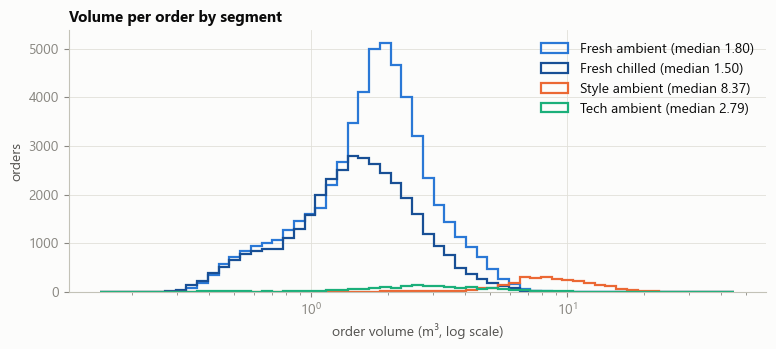

count  mean   std   min    1%   50%    99%    max
brand temp_requirement                                                       
Fresh ambient          55,600.000 1.941 1.029 0.231 0.426 1.803  5.333 10.830
      chilled          37,031.000 1.687 0.958 0.239 0.384 1.502  5.016  9.288
Style ambient           2,890.000 9.012 3.687 1.539 2.167 8.372 20.458 31.437
Tech  ambient           1,800.000 3.313 2.114 0.180 0.366 2.785 10.315 15.341

In [59]:
fig, ax = plt.subplots(figsize=(9, 3.4))
segs = [("Fresh", "ambient"), ("Fresh", "chilled"), ("Style", "ambient"), ("Tech", "ambient")]
bins = np.logspace(np.log10(0.15), np.log10(45), 60)
for (b, t), c in zip(segs, [BLUE, BLUE_DARK, ORANGE, AQUA]):
    v = orders.loc[(orders.brand == b) & (orders.temp_requirement == t), "order_volume_m3"]
    ax.hist(v, bins=bins, histtype="step", linewidth=1.6, color=c, label=f"{b} {t} (median {v.median():.2f})")
ax.set_xscale("log"); ax.set_xlabel("order volume (m³, log scale)"); ax.set_ylabel("orders")
ax.set_title("Volume per order by segment"); ax.legend(loc="upper right")
save(fig, "volume_distribution"); plt.show()
display(orders.groupby(["brand", "temp_requirement"]).order_volume_m3.describe(percentiles=[.01, .5, .99]))

Volumes are right-skewed but smooth, with no zeros, negatives or isolated spikes. The largest orders are about 3× the
99th percentile, consistent with festival peaks. **No rows are removed**: every order is real demand.

## 10. Target construction

The brief defines the target with four rules. Each one closes a trap:

1. **Count every order once**, including `deferred` and `not_run`. They are still demand.
2. **Bucket by `order_date`**, the week the store *requested*, not `dispatch_date`.
3. **Use `iso_year` / `iso_week` from `calendar.csv`** so periods match the forecast rows.
4. **Chilled = volume with `temp_requirement == "chilled"`**. Only Fresh has chilled demand; Style/Tech are 0.

In [60]:
def weekly_actuals(orders):
    """Weekly total and chilled m3 per depot x brand x ISO week."""
    o = orders.assign(chilled_m3=np.where(orders.temp_requirement == "chilled",
                                          orders.order_volume_m3, 0.0))
    return (o.groupby(["depot", "brand", "iso_year", "iso_week"], as_index=False)
             .agg(total_m3=("order_volume_m3", "sum"),
                  chilled_m3=("chilled_m3", "sum"),
                  n_orders=("delivery_id", "size")))

In [61]:
weekly = weekly_actuals(orders)
weekly["yw"] = weekly.iso_year * 100 + weekly.iso_week
print(f"{len(weekly)} rows = {weekly.yw.nunique()} ISO weeks x {weekly.groupby(['depot','brand']).ngroups} series "
      f"({weekly.yw.min()} -> {weekly.yw.max()})")
display(weekly.tail(6))

702 rows = 117 ISO weeks x 6 series (202401 -> 202613)


,depot,brand,iso_year,iso_week,total_m3,chilled_m3,n_orders,yw
696,Peliyagoda,Tech,2026,8,23.253,0.000,9,202608
697,Peliyagoda,Tech,2026,9,40.091,0.000,11,202609
698,Peliyagoda,Tech,2026,10,22.986,0.000,7,202610
699,Peliyagoda,Tech,2026,11,21.290,0.000,7,202611
700,Peliyagoda,Tech,2026,12,33.188,0.000,11,202612
701,Peliyagoda,Tech,2026,13,37.519,0.000,11,202613


### 10.1 How much the rules matter

In [62]:
def weekly_from(df, date_col):
    d = df.dropna(subset=[date_col]).copy()
    d["date"] = pd.to_datetime(d[date_col])
    d = d.drop(columns=["iso_year", "iso_week"]).merge(cal[["date", "iso_year", "iso_week"]], on="date")
    return d.groupby(["depot", "brand", "iso_year", "iso_week"]).order_volume_m3.sum()

correct = weekly.set_index(["depot", "brand", "iso_year", "iso_week"]).total_m3
variants = {
    "bucket by dispatch_date instead of order_date": weekly_from(orders, "dispatch_date"),
    "drop deferred + not_run orders": weekly_from(orders[orders.dispatch_status == "attempted"], "order_date"),
    "drop not_run orders only": weekly_from(orders[orders.dispatch_status != "not_run"], "order_date"),
}
rows = []
for name, v in variants.items():
    diff = v.reindex(correct.index).fillna(0) - correct
    rows.append({"if we ...": name, "weekly rows changed": int((diff.abs() > 1e-6).sum()),
                 "volume misplaced or lost (m³)": round(diff.abs().sum(), 1),
                 "worst single row (m³)": round(diff.abs().max(), 1)})
display(pd.DataFrame(rows))

,if we ...,weekly rows changed,volume misplaced or lost (m³),worst single row (m³)
0,bucket by dispatch_date instead of order_date,95,"1,337.200",49.100
1,drop deferred + not_run orders,138,"3,701.700",86.200
2,drop not_run orders only,66,834.600,41.200


Ignoring the rules would change up to 138 of the 702 weekly rows and misplace up to 3,700 m³. The damage is not
random. Deferred and never-dispatched orders are almost all **chilled** (table below), so dropping them would bias
exactly the chilled forecast that refrigerated-capacity planning depends on.

In [63]:
not_served = orders.dispatch_status != "attempted"
display(pd.DataFrame({
    "orders": orders.groupby(["brand", "temp_requirement"]).size(),
    "deferred or never dispatched": not_served.groupby([orders.brand, orders.temp_requirement]).sum(),
    "share": not_served.groupby([orders.brand, orders.temp_requirement]).mean().round(4)}))

orders  deferred or never dispatched  share
brand temp_requirement                                             
Fresh ambient            55600                            13  0.000
      chilled            37031                          2018  0.054
Style ambient             2890                             7  0.002
Tech  ambient             1800                             8  0.004

## 11. Exploratory data analysis

### 11.1 Weekly demand per depot × brand

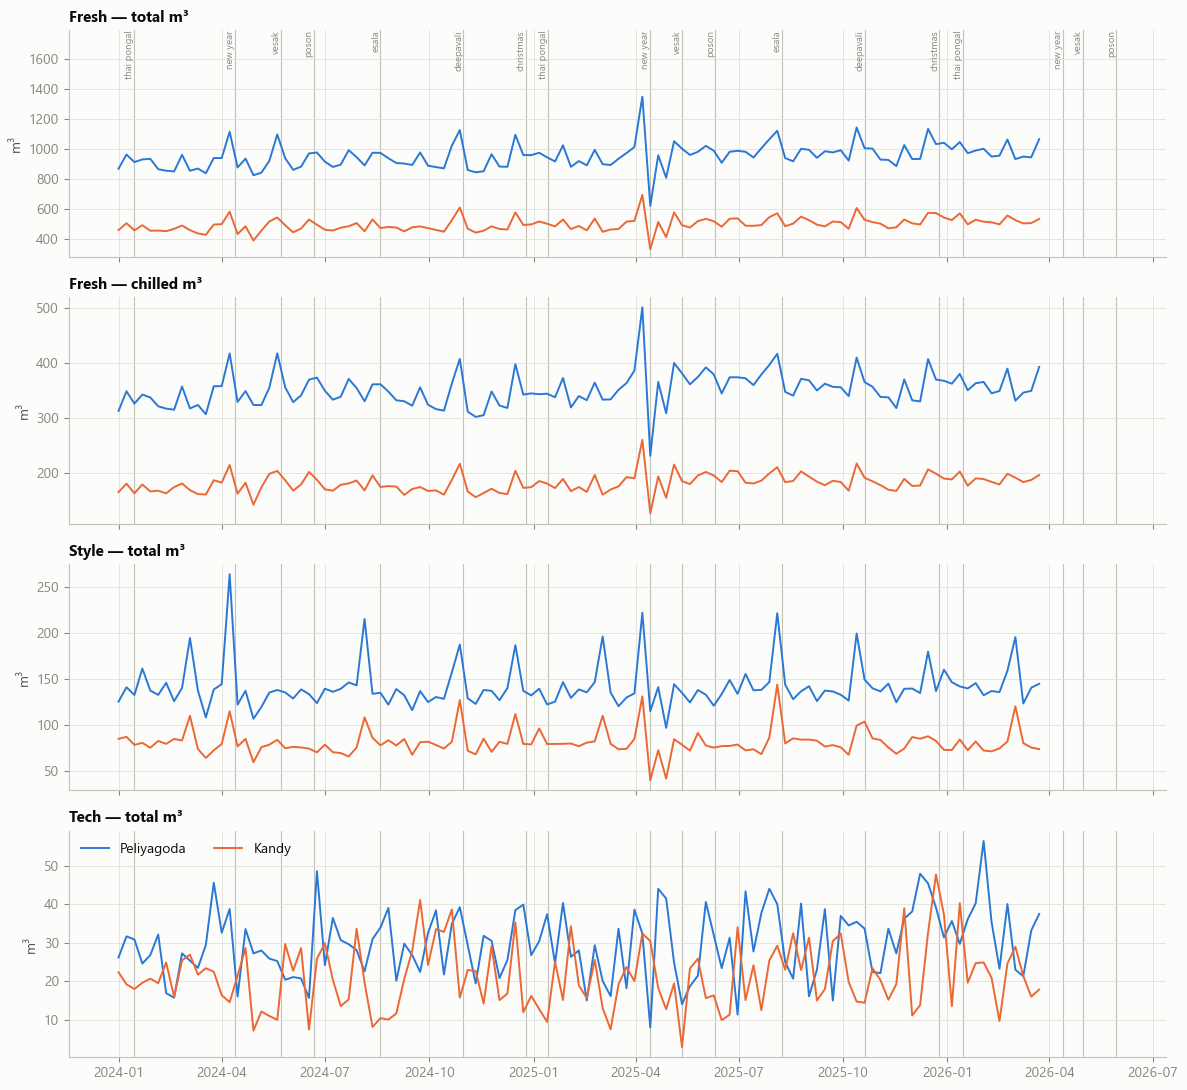

In [64]:
fest_days = cal[cal.festival.notna()][["date", "festival", "yw"]]
wk_start = cal.groupby("yw").date.min()
weekly["week_start"] = weekly.yw.map(wk_start)

fig, axes = plt.subplots(4, 1, figsize=(12, 11), sharex=True)
panels = [("Fresh", "total_m3", "Fresh — total m³"), ("Fresh", "chilled_m3", "Fresh — chilled m³"),
          ("Style", "total_m3", "Style — total m³"), ("Tech", "total_m3", "Tech — total m³")]
for ax, (b, col, title) in zip(axes, panels):
    for dep, c in DEPOT_COLORS.items():
        s = weekly[(weekly.brand == b) & (weekly.depot == dep)]
        ax.plot(s.week_start, s[col], color=c, linewidth=1.4, label=dep)
    for _, f in fest_days.iterrows():
        ax.axvline(f.date, color=AXIS, linewidth=0.8, zorder=0)
    ax.set_title(title); ax.set_ylabel("m³")
lo, hi = axes[0].get_ylim()
axes[0].set_ylim(lo, hi + (hi - lo) * 0.35)                 # headroom for the festival labels
for _, f in fest_days.iterrows():
    axes[0].text(f.date, axes[0].get_ylim()[1], f.festival.replace("_", " "), rotation=90,
                 fontsize=7, color=MUTED, va="top", ha="right")
axes[-1].legend(loc="upper left", ncol=2)
fig.tight_layout(); save(fig, "weekly_series"); plt.show()

* Fresh dominates (~1,500 m³/week across both depots) and grows steadily. Style is ~225 m³ and Tech ~55 m³.
* Spikes come in the week **before** a festival, then a dip when festival days close the depots.
* Style also peaks at fixed points in the year (ISO weeks 10, 32 and 51–52) that are not tied to a festival.

### 11.2 Festivals move between ISO weeks

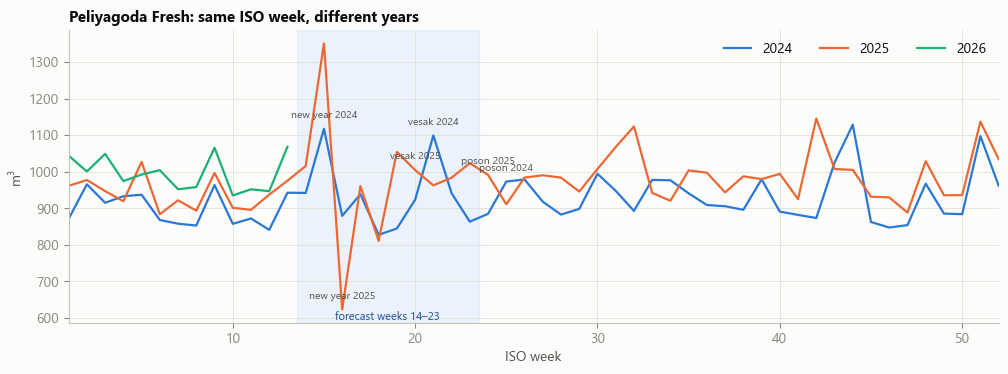

,date,festival,iso_week,weekday,operating
103,2024-04-13,new_year,15,Saturday,0
143,2024-05-23,vesak,21,Thursday,1
172,2024-06-21,poson,25,Friday,1
469,2025-04-14,new_year,16,Monday,0
497,2025-05-12,vesak,20,Monday,1
526,2025-06-10,poson,24,Tuesday,1
833,2026-04-13,new_year,16,Monday,0
851,2026-05-01,vesak,18,Friday,0
880,2026-05-30,poson,22,Saturday,1


In [65]:
fp = weekly[(weekly.brand == "Fresh") & (weekly.depot == "Peliyagoda")]
fig, ax = plt.subplots(figsize=(12, 3.8))
for yr, c in zip([2024, 2025, 2026], [BLUE, ORANGE, AQUA]):
    s = fp[fp.iso_year == yr]
    ax.plot(s.iso_week, s.total_m3, color=c, linewidth=1.6, label=str(yr))
    for _, f in fest_days[fest_days.date.dt.year == yr].iterrows():
        wk = cal.loc[cal.date == f.date, "iso_week"].iloc[0]
        if f.festival in ("new_year", "vesak", "poson"):
            ax.annotate(f"{f.festival.replace('_',' ')} {yr}", (wk, s.loc[s.iso_week == wk, "total_m3"].max()),
                        textcoords="offset points", xytext=(0, 8), fontsize=7.5, color=INK2, ha="center")
ax.axvspan(13.5, 23.5, color=BLUE_LIGHT, alpha=0.35, zorder=0)
ax.text(18.5, ax.get_ylim()[0], "forecast weeks 14–23", ha="center", va="bottom", fontsize=8, color=BLUE_DARK)
ax.set_xlabel("ISO week"); ax.set_ylabel("m³"); ax.set_xlim(1, 52)
ax.set_title("Peliyagoda Fresh: same ISO week, different years"); ax.legend(loc="upper right", ncol=3)
save(fig, "yoy_overlay"); plt.show()
display(fest_days.assign(iso_week=fest_days.date.map(cal.set_index("date").iso_week),
                         weekday=fest_days.date.dt.day_name(),
                         operating=fest_days.date.map(cal.set_index("date").is_operating))
        .query("festival in ['new_year','vesak','poson']").drop(columns="yw"))

Vesak fell in ISO week 21 (2024), 20 (2025) and **18 (2026)**. Poson moved from 25 to 24 to **22**. A "same week last
year" forecast therefore compares the wrong weeks. The model has to understand the calendar itself.

### 11.3 Weekly volume = number of orders × size of each order

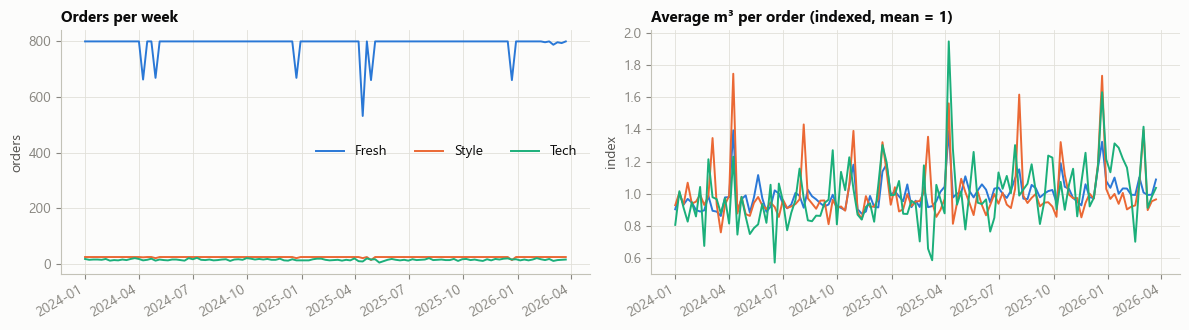

In [66]:
cnt = orders.groupby(["brand", "yw"]).agg(orders=("delivery_id", "size"), vol=("order_volume_m3", "sum")).reset_index()
cnt["avg_m3"] = cnt.vol / cnt.orders
cnt["week_start"] = cnt.yw.map(wk_start)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
for b, c in BRAND_COLORS.items():
    s = cnt[cnt.brand == b]
    axes[0].plot(s.week_start, s.orders, color=c, linewidth=1.4, label=b)
    axes[1].plot(s.week_start, s.avg_m3 / s.avg_m3.mean(), color=c, linewidth=1.4, label=b)
axes[0].set_title("Orders per week"); axes[0].set_ylabel("orders"); axes[0].legend(ncol=3)
axes[1].set_title("Average m³ per order (indexed, mean = 1)"); axes[1].set_ylabel("index")
fig.autofmt_xdate(); fig.tight_layout(); save(fig, "count_vs_size"); plt.show()

The order **count** is flat except in weeks with closed days (holiday weeks drop sharply). The **size** of each order
moves with festivals, paydays and the season. That suggests modelling the two parts separately.

### 11.4 Every outlet orders on a fixed weekly schedule

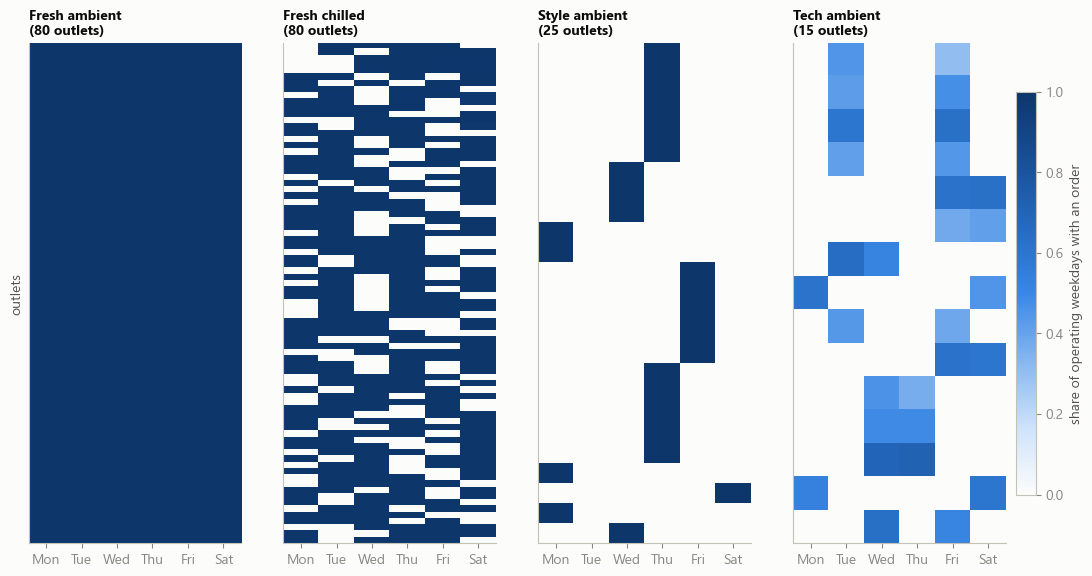

slots == 0  0 < p < 0.95  p >= 0.95
brand temp_requirement                                     
Fresh ambient                    0             0        480
      chilled                  160             0        320
Style ambient                  125             0         25
Tech  ambient                   60            30          0

In [67]:
n_op_days = cal[(cal.date <= orders.date.max()) & (cal.is_operating == 1)].groupby("dow").size()
freq = (orders.groupby(["brand", "temp_requirement", "outlet_id", "dow"]).size()
              .div(n_op_days, level="dow").unstack(fill_value=0))
day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat"]
fig, axes = plt.subplots(1, 4, figsize=(13, 6.5), gridspec_kw={"width_ratios": [1, 1, 1, 1]})
for ax, (b, t) in zip(axes, segs):
    m = freq.loc[(b, t)].reindex(columns=range(6), fill_value=0)
    im = ax.imshow(m.values, aspect="auto", cmap=SEQ_CMAP, vmin=0, vmax=1, interpolation="nearest")
    ax.set_xticks(range(6), day_names); ax.set_yticks([]); ax.grid(False)
    ax.set_title(f"{b} {t}\n({len(m)} outlets)", fontsize=10)
axes[0].set_ylabel("outlets")
fig.colorbar(im, ax=axes, fraction=0.02, pad=0.01, label="share of operating weekdays with an order")
save(fig, "order_schedules"); plt.show()
display(freq.stack().groupby(level=[0, 1]).apply(
    lambda s: pd.Series({"slots == 0": (s < .05).sum(), "0 < p < 0.95": ((s >= .05) & (s < .95)).sum(),
                         "p >= 0.95": (s >= .95).sum()})).unstack())

* **Fresh ambient**: every outlet, every operating day.
* **Fresh chilled**: each outlet has 4 fixed weekdays.
* **Style**: one fixed weekday per outlet.
* **Tech**: 2 eligible weekdays per outlet, used about half the time ("orders as needed").

The schedules are identical in 2024, 2025 and 2026 (checked below).

In [68]:
def schedule(df):
    return df.groupby(["outlet_id", "temp_requirement"]).dow.apply(lambda s: tuple(sorted(s.unique())))
same = {}
for b in ["Fresh", "Style", "Tech"]:
    s24, s26 = schedule(orders[(orders.brand == b) & (orders.iso_year == 2024)]).align(
        schedule(orders[(orders.brand == b) & (orders.iso_year == 2026)]), join="inner")
    same[b] = round((s24 == s26).mean(), 3)
print("share of outlets with an identical weekday schedule in 2024 and 2026:", same)

share of outlets with an identical weekday schedule in 2024 and 2026: {'Fresh': np.float64(1.0), 'Style': np.float64(1.0), 'Tech': np.float64(1.0)}


### 11.5 Holiday rule: an order on a closed day is skipped, not moved

In [69]:
style = orders[orders.brand == "Style"]
sched_day = style.groupby("outlet_id").dow.agg(lambda s: s.mode()[0])
rows = []
for out_id, dow in sched_day.items():
    days = cal[(cal.dow == dow) & (cal.date <= orders.date.max())]
    closed = days[days.is_operating == 0]
    have = set(style.loc[style.outlet_id == out_id, "date"])
    for d in closed.date:
        wk = cal.loc[cal.date == d, "yw"].iloc[0]
        rows.append({"outlet": out_id, "scheduled day": d.strftime("%a %d %b %Y"),
                     "order that day": d in have,
                     "any order that week": style[(style.outlet_id == out_id) & (style.yw == wk)].shape[0] > 0})
skips = pd.DataFrame(rows)
print(f"Style orders placed off-schedule: {(style.dow != style.outlet_id.map(sched_day)).sum()}")
display(skips.groupby(["scheduled day"]).agg(outlets=("outlet", "size"), ordered_that_day=("order that day", "sum"),
                                              ordered_elsewhere_that_week=("any order that week", "sum")))

Style orders placed off-schedule: 0


,outlets,ordered_that_day,ordered_elsewhere_that_week
scheduled day,,,
Mon 14 Apr 2025,4,0,0
Sat 13 Apr 2024,1,0,0
Thu 01 May 2025,11,0,0
Thu 25 Dec 2025,11,0,0
Wed 01 May 2024,4,0,0
Wed 25 Dec 2024,4,0,0


On every closed scheduled day the order simply disappears. It isn't moved to another day. This is why the New Year
week (2026 W16, Mon 13 and Tue 14 Apr closed) will have far fewer orders than a normal week.

### 11.6 What drives the size of an order

To isolate calendar effects, each order's volume is divided by its outlet × temperature average, giving a
*relative volume* where 1.0 means "a normal order for that outlet".

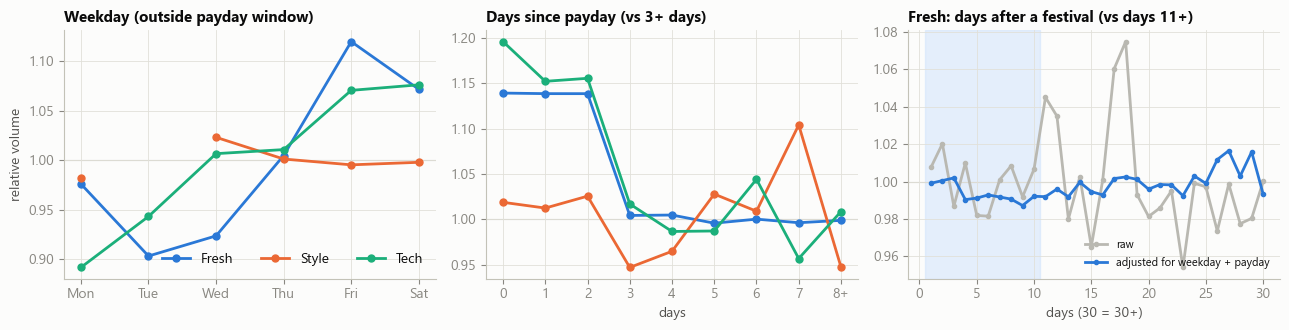

Fresh payday window (days 0-2) vs rest: 1.139x
Fresh days 1-10 after a festival vs days 11+: raw 1.000x, adjusted 0.994x


In [70]:
# Relative volume: each order / its outlet x temperature average (1.0 = a normal order for that outlet).
rel = orders.copy()
rel["rel"] = rel.order_volume_m3 / rel.groupby(["outlet_id", "temp_requirement"]).order_volume_m3.transform("mean")
rel["pay_win"] = rel.days_since_payday.clip(upper=3)          # 0, 1, 2 = payday window, 3 = rest
plain = (rel.festival_ramp == 0) & (rel.post_festival == 0)


def factor(col, value):
    """Mean of `value` per brand x `col` on non-festival days, normalised to mean 1 per brand."""
    f = rel[plain].groupby(["brand", col])[value].mean()
    f = f / f.groupby(level=0).transform("mean")
    return pd.Series(list(zip(rel.brand, rel[col])), index=rel.index).map(f)


# Weekday, payday window and year overlap (e.g. a Friday payday), so remove them jointly by backfitting.
rel["adj"] = rel.rel
for _ in range(3):
    for col in ["dow", "pay_win", "iso_year"]:
        rel["tmp"] = rel.adj * factor(col, "adj")
        rel["adj"] = rel.tmp / factor(col, "tmp")
rel["adj_no_pay"] = rel.rel / factor("dow", "rel") / factor("iso_year", "rel")

fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
for b, c in BRAND_COLORS.items():
    s_ = rel[plain & (rel.brand == b) & (rel.pay_win == 3)].groupby("dow").rel.mean().reindex(range(6))
    axes[0].plot(range(6), s_.values / np.nanmean(s_.values), marker="o", color=c, label=b)
axes[0].set_xticks(range(6), day_names); axes[0].set_title("Weekday (outside payday window)")
axes[0].set_ylabel("relative volume"); axes[0].legend(ncol=3, loc="lower right")
for b, c in BRAND_COLORS.items():
    s_ = rel[plain & (rel.brand == b)].groupby(rel.days_since_payday.clip(upper=8)).adj_no_pay.mean()
    axes[1].plot(s_.index, s_.values / s_.loc[3:].mean(), marker="o", color=c, label=b)
axes[1].set_xticks(range(9), [str(i) for i in range(8)] + ["8+"])
axes[1].set_title("Days since payday (vs 3+ days)"); axes[1].set_xlabel("days")
x = rel[(rel.brand == "Fresh") & (rel.festival_ramp == 0)]
g = x.groupby(x.days_since_festival.clip(upper=30))
raw, adj = g.rel.mean(), g.adj.mean()
axes[2].plot(raw.index, raw / raw.loc[11:].mean(), color="#b9b8b1", marker="o", markersize=3, label="raw")
axes[2].plot(adj.index, adj / adj.loc[11:].mean(), color=BLUE, marker="o", markersize=3,
             label="adjusted for weekday + payday")
axes[2].axvspan(0.5, POST_FEST_DAYS + 0.5, color=BLUE_LIGHT, alpha=0.5, zorder=0)
axes[2].set_title("Fresh: days after a festival (vs days 11+)"); axes[2].set_xlabel("days (30 = 30+)")
axes[2].legend(loc="lower right", fontsize=8)
for ax in axes:
    ax.axhline(1, color=AXIS, linewidth=0.8, zorder=0)
fig.tight_layout(); save(fig, "drivers_weekday_payday_post"); plt.show()

pw = rel[plain & (rel.brand == "Fresh")].groupby("pay_win").adj_no_pay.mean()
print(f"Fresh payday window (days 0-2) vs rest: {pw.loc[:2].mean() / pw.loc[3]:.3f}x")
print(f"Fresh days 1-10 after a festival vs days 11+: raw {raw.loc[1:10].mean() / raw.loc[11:].mean():.3f}x, "
      f"adjusted {adj.loc[1:10].mean() / adj.loc[11:].mean():.3f}x")

* **Weekday:** Fresh orders are larger on Fri/Sat and smaller on Tue/Wed. Style never orders on Tuesday.
* **Payday:** the lift (about +14% for Fresh) lasts **3 days**, the payday plus the next two, then drops at once. The
  calendar only flags the payday itself, so we engineer `days_since_payday`.
* **After a festival (a confounder caught):** our first look, against the all-days average, suggested a ~6% dip
  after festivals. But that average includes payday and festival-ramp days. Compared like-for-like with ordinary days
  (11+ days after a festival) and adjusted for weekday and payday, the post-festival period is within 1% of normal.
  We keep only a small optional term and let the ablation (§16) judge it.

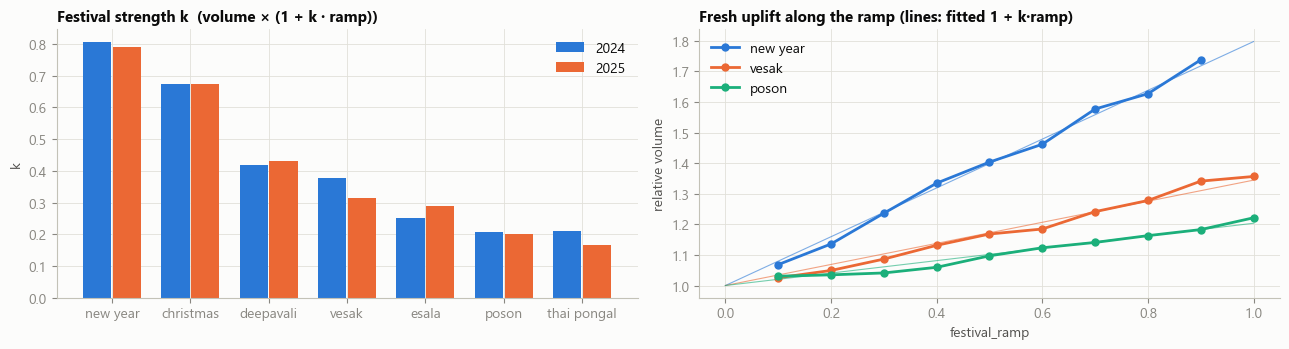

year,2024,2025,2026,mean
ramp_festival,,,,
new_year,0.806,0.790,NaN,0.798
christmas,0.675,0.672,NaN,0.674
deepavali,0.418,0.432,NaN,0.425
vesak,0.376,0.313,NaN,0.345
esala,0.251,0.290,NaN,0.271
poson,0.206,0.201,NaN,0.204
thai_pongal,0.212,0.165,0.201,0.193


In [71]:
f = rel[(rel.brand == "Fresh") & (rel.festival_ramp > 0)].copy()
base = rel[(rel.brand == "Fresh") & plain].adj.mean()
f["uplift"] = f.adj / base - 1                       # adjusted for weekday, payday window and year
f["year"] = f.date.dt.year
k = (f.groupby(["ramp_festival", "year"]).apply(lambda g: (g.uplift * g.festival_ramp).sum() / (g.festival_ramp ** 2).sum())
       .unstack().reindex(["new_year", "christmas", "deepavali", "vesak", "esala", "poson", "thai_pongal"]))

fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
xs = np.arange(len(k))
for i, (yr, c) in enumerate(zip([2024, 2025], [BLUE, ORANGE])):
    axes[0].bar(xs + (i - 0.5) * 0.38, k[yr], width=0.36, color=c, label=str(yr))
axes[0].set_xticks(xs, [n.replace("_", " ") for n in k.index]); axes[0].legend()
axes[0].set_title("Festival strength k  (volume × (1 + k · ramp))"); axes[0].set_ylabel("k")
for fest, c in [("new_year", BLUE), ("vesak", ORANGE), ("poson", AQUA)]:
    s = f[f.ramp_festival == fest].groupby("festival_ramp").uplift.mean()
    axes[1].plot(s.index, 1 + s.values, marker="o", color=c, label=fest.replace("_", " "))
    axes[1].plot([0, 1], [1, 1 + k.loc[fest].mean()], color=c, linewidth=0.8, alpha=0.6)
axes[1].set_title("Fresh uplift along the ramp (lines: fitted 1 + k·ramp)")
axes[1].set_xlabel("festival_ramp"); axes[1].set_ylabel("relative volume"); axes[1].legend()
fig.tight_layout(); save(fig, "festival_effects"); plt.show()
display(k.round(3).assign(mean=k.mean(axis=1).round(3)))

After adjusting for weekday, payday and year, the ramp lifts order size almost linearly, by an amount that depends on the
festival but **repeats from year to year**. At the peak of the ramp: New Year about +80%, Christmas +68%, Deepavali +42%,
Vesak +35%, Esala +27%, Poson +21%, Thai Pongal +19%. So the model needs one ramp curve **per
festival**, not a single shared curve (the ablation in §16 confirms this).

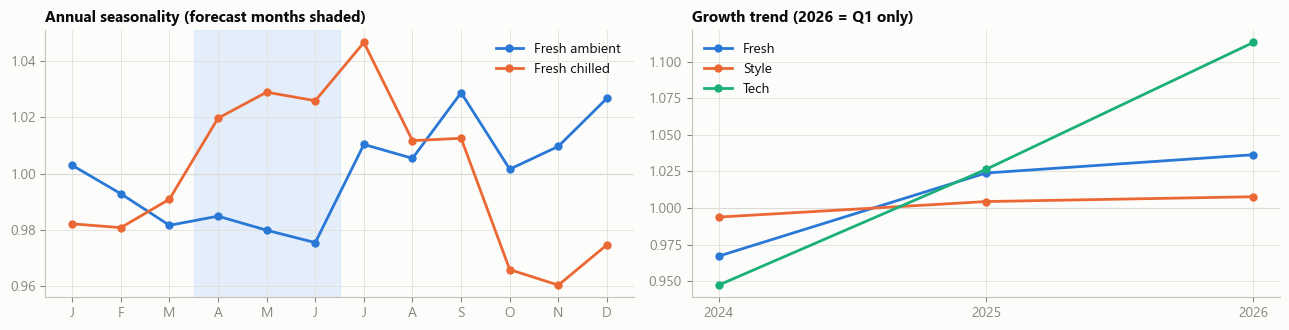

,factor,relative volume when present,relative volume when absent,correlation with relative volume
0,monsoon month,1.001,0.999,0.004
1,road disruption index (district-day),1.002,0.997,-0.004


In [72]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.4))
fr = rel[plain & (rel.brand == "Fresh")]
for t, c in [("ambient", BLUE), ("chilled", ORANGE)]:
    s = fr[fr.temp_requirement == t].groupby(fr.date.dt.month).adj.mean()
    axes[0].plot(s.index, s.values / s.mean(), marker="o", color=c, label=f"Fresh {t}")
axes[0].set_xticks(range(1, 13), ["J","F","M","A","M","J","J","A","S","O","N","D"])
axes[0].axvspan(3.5, 6.5, color=BLUE_LIGHT, alpha=0.5, zorder=0)
axes[0].set_title("Annual seasonality (forecast months shaded)"); axes[0].legend()
for b, c in BRAND_COLORS.items():
    s = rel[rel.brand == b].groupby("iso_year").rel.mean()
    axes[1].plot(s.index, s.values, marker="o", color=c, label=b)
axes[1].set_xticks([2024, 2025, 2026]); axes[1].set_title("Growth trend (2026 = Q1 only)"); axes[1].legend()
for ax in axes: ax.axhline(1, color=AXIS, linewidth=0.8, zorder=0)
fig.tight_layout(); save(fig, "season_trend"); plt.show()

rc = pd.read_csv(DATA / "General Data" / "road_conditions.csv", parse_dates=["date"])
x = rel.merge(rc, on=["district", "date"])
display(pd.DataFrame({
    "factor": ["monsoon month", "road disruption index (district-day)"],
    "relative volume when present": [rel[rel.monsoon == 1].rel.mean(), x[x.disruption_index < 80].rel.mean()],
    "relative volume when absent": [rel[rel.monsoon == 0].rel.mean(), x[x.disruption_index == 100].rel.mean()],
    "correlation with relative volume": [rel[["rel", "monsoon"]].corr().iloc[0, 1], x[["rel", "disruption_index"]].corr().iloc[0, 1]]}))

* **Season:** chilled demand is higher in Apr–Jun (our forecast window) and lower in Oct–Dec. Ambient is flatter.
  Annual seasonality is therefore modelled separately for chilled and ambient.
* **Trend:** order sizes grow every year. The fitted model (§21.2) puts it at about +6%/year for Fresh, +2% for Style
  and +9% for Tech. The 2026 bar is Q1 only, so it isn't a full-year comparison.
* **Monsoon and road disruption do not affect order volume.** They affect *travel*, which is Task 1, so they are
  left out here.

### 11.6b Style has two recurring spike weeks (ISO 10 and 32)
Style orders once a week per outlet, so its weekly volume is flat apart from festival ramps and two spikes that are
**not** tied to a festival. This matters for the model choice in §18: a model has to either learn these weeks from the
previous year or leave them out of its level.

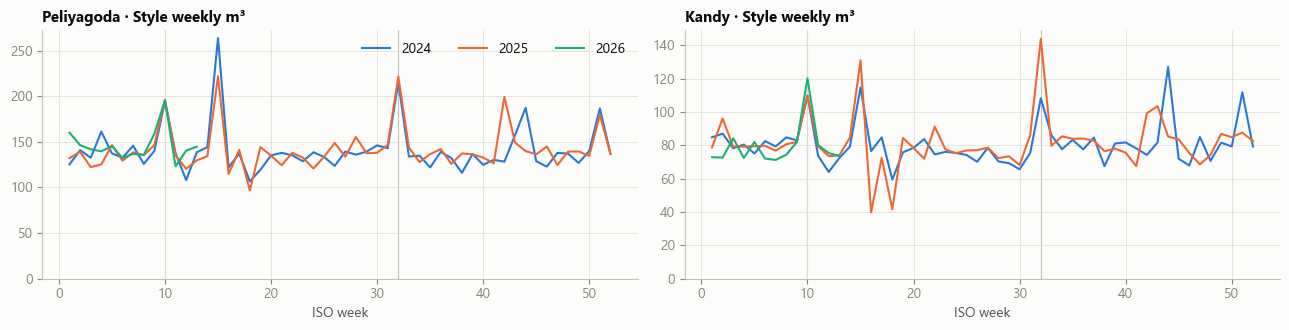

,depot,year,ISO week,spike week m³,median of 6 neighbouring weeks,ratio
0,Peliyagoda,2024,10,194.480,137.980,1.410
1,Peliyagoda,2024,32,215.180,137.080,1.570
2,Peliyagoda,2025,10,196.170,135.330,1.450
3,Peliyagoda,2025,32,221.400,137.850,1.610
4,Peliyagoda,2026,10,195.480,138.640,1.410
5,Kandy,2024,10,109.860,76.580,1.430
6,Kandy,2024,32,108.220,76.630,1.410
7,Kandy,2025,10,110.000,78.120,1.410
8,Kandy,2025,32,143.820,81.880,1.760
9,Kandy,2026,10,120.200,74.880,1.610


In [73]:
st = weekly[weekly.brand == "Style"].copy()
fig, axes = plt.subplots(1, 2, figsize=(13, 3.4))
for ax, dep in zip(axes, ["Peliyagoda", "Kandy"]):
    for yr, c in zip([2024, 2025, 2026], [BLUE, ORANGE, AQUA]):
        s_ = st[(st.depot == dep) & (st.iso_year == yr)]
        ax.plot(s_.iso_week, s_.total_m3, color=c, linewidth=1.5, label=str(yr))
    for w_ in (10, 32):
        ax.axvline(w_, color=AXIS, linewidth=0.8, zorder=0)
    ax.set_title(f"{dep} · Style weekly m³"); ax.set_xlabel("ISO week"); ax.set_ylim(0, None)
axes[0].legend(ncol=3)
fig.tight_layout(); save(fig, "style_spike_weeks"); plt.show()
rows = []
for dep in ["Peliyagoda", "Kandy"]:
    for yr in [2024, 2025, 2026]:
        s_ = st[(st.depot == dep) & (st.iso_year == yr)].set_index("iso_week").total_m3
        for w_ in (10, 32):
            if w_ in s_.index:
                nb = s_.reindex([w_ - 3, w_ - 2, w_ - 1, w_ + 1, w_ + 2, w_ + 3]).dropna()
                rows.append({"depot": dep, "year": yr, "ISO week": w_, "spike week m³": s_[w_],
                             "median of 6 neighbouring weeks": nb.median(), "ratio": s_[w_] / nb.median()})
display(pd.DataFrame(rows).round(2))

Both depots spike in week 10 and in week 32, in every year they are observed. The forecast window (weeks 14–23) contains
neither. The next paragraph of the benchmark (§18) therefore scores Style **outside** these weeks for the forecast, and
uses the model that has learned the spikes only for those weeks.

### 11.7 What the forecast weeks look like

In [74]:
h = cal[(cal.yw >= 202614) & (cal.yw <= 202623)].copy()
horizon_tbl = h.groupby("iso_week").agg(
    dates=("date", lambda d: f"{d.min():%d %b} – {d.max():%d %b}"),
    operating_days=("is_operating", "sum"),
    closed_weekdays=("date", lambda d: ", ".join(x.strftime("%a %d") for x in d if
                     cal.set_index("date").loc[x, "is_operating"] == 0 and x.dayofweek < 6) or "–"),
    paydays=("is_payday", "sum"),
    max_ramp=("festival_ramp", "max"),
    festival=("festival", lambda s: ", ".join(s.dropna()) or "–"),
    ramp_towards=("ramp_festival", lambda s: ", ".join(sorted(set(s) - {"none"})) or "–"),
    post_festival_days=("post_festival", "sum"))
display(horizon_tbl)

,dates,operating_days,closed_weekdays,paydays,max_ramp,festival,ramp_towards,post_festival_days
iso_week,,,,,,,,
14,30 Mar – 05 Apr,6,–,1,0.200,–,new_year,0
15,06 Apr – 12 Apr,6,–,0,0.900,–,new_year,0
16,13 Apr – 19 Apr,4,"Mon 13, Tue 14",0,1.000,new_year,new_year,6
17,20 Apr – 26 Apr,6,–,1,0.500,–,vesak,2
18,27 Apr – 03 May,5,Fri 01,1,1.000,vesak,vesak,2
19,04 May – 10 May,6,–,0,0.000,–,–,7
20,11 May – 17 May,6,–,0,0.000,–,–,1
21,18 May – 24 May,6,–,0,0.400,–,poson,0
22,25 May – 31 May,6,–,2,1.000,poson,poson,1


### 11.8 The portfolio: what, where and how big
Fresh is the business: most of the volume, and chilled orders are about 37% of it. Style and Tech are tiny but behave
very differently (one scheduled order per outlet per week; irregular single large items).

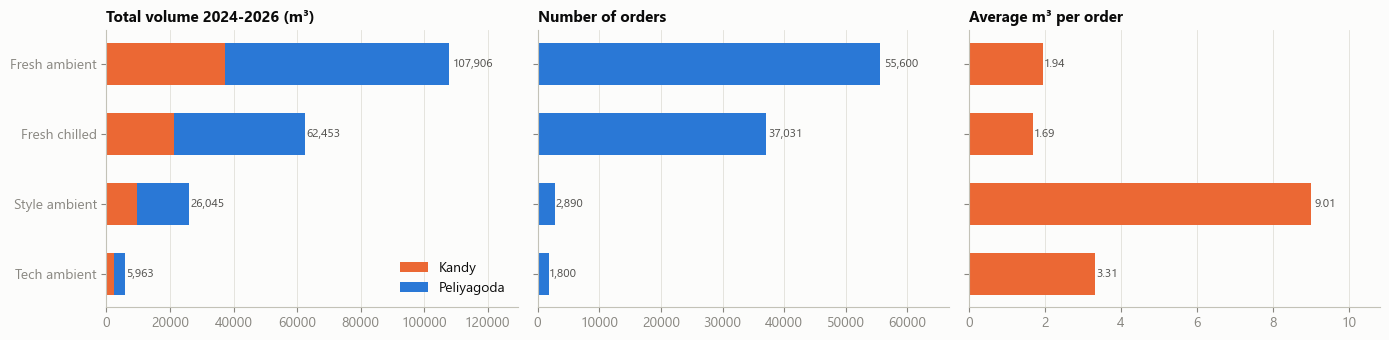

share of total volume (%): {'Fresh ambient': 53.3, 'Fresh chilled': 30.9, 'Style ambient': 12.9, 'Tech ambient': 2.9}


In [75]:
seg_order = ["Fresh ambient", "Fresh chilled", "Style ambient", "Tech ambient"]
o2 = orders.assign(segment=orders.brand + " " + orders.temp_requirement)
vol = o2.groupby(["segment", "depot"]).order_volume_m3.sum().unstack().reindex(seg_order)
cnt = o2.groupby("segment").size().reindex(seg_order)
avg = o2.groupby("segment").order_volume_m3.mean().reindex(seg_order)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
left = np.zeros(len(vol))
for dep in ["Kandy", "Peliyagoda"]:
    axes[0].barh(vol.index, vol[dep], left=left, color=DEPOT_COLORS[dep], height=0.6, label=dep)
    left += vol[dep].values
for y_, tot in enumerate(vol.sum(axis=1)):
    axes[0].text(tot * 1.01, y_, f"{tot:,.0f}", va="center", fontsize=8.5, color=INK2)
axes[0].set_xlim(0, vol.sum(axis=1).max() * 1.2); axes[0].invert_yaxis()
axes[0].set_title("Total volume 2024-2026 (m³)"); axes[0].legend(loc="lower right"); axes[0].grid(axis="y", visible=False)
axes[1].barh(cnt.index, cnt.values, color=BLUE, height=0.6)
for y_, v in enumerate(cnt.values):
    axes[1].text(v * 1.01, y_, f"{v:,}", va="center", fontsize=8.5, color=INK2)
axes[1].set_xlim(0, cnt.max() * 1.2); axes[1].invert_yaxis(); axes[1].set_yticklabels([])
axes[1].set_title("Number of orders"); axes[1].grid(axis="y", visible=False)
axes[2].barh(avg.index, avg.values, color=ORANGE, height=0.6)
for y_, v in enumerate(avg.values):
    axes[2].text(v * 1.01, y_, f"{v:.2f}", va="center", fontsize=8.5, color=INK2)
axes[2].set_xlim(0, avg.max() * 1.2); axes[2].invert_yaxis(); axes[2].set_yticklabels([])
axes[2].set_title("Average m³ per order"); axes[2].grid(axis="y", visible=False)
fig.tight_layout(); save(fig, "eda_portfolio_mix"); plt.show()
share = (vol.sum(axis=1) / vol.sum().sum() * 100).round(1)
print("share of total volume (%):", share.to_dict())

### 11.9 Deferrals and never-dispatched orders
Orders deferred or never dispatched are demand, not noise. They concentrate in **Fresh chilled**, the segment that needs a
refrigerated vehicle (2-10% of its orders in a typical month, almost none elsewhere), and deferred orders ship one or two
days later. This is the quantitative reason to keep them in the
target (§10.1).

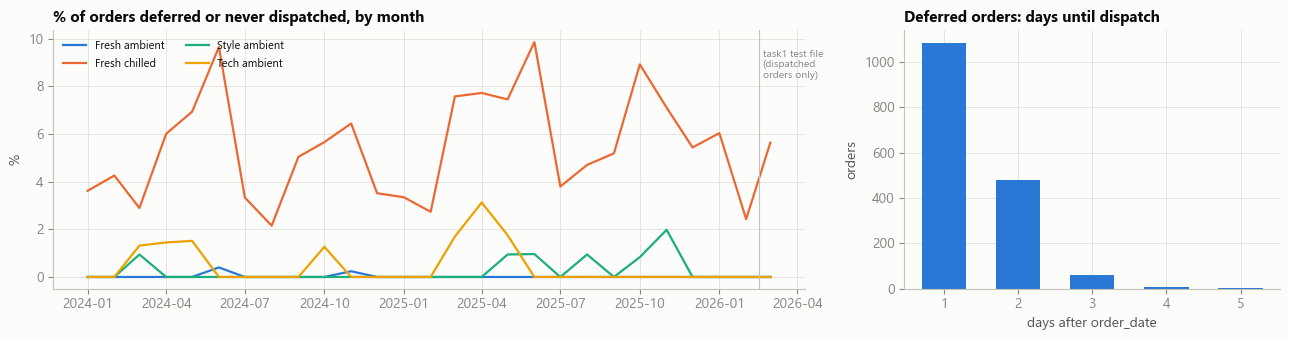

dispatch_status  attempted  deferred  not_run
segment                                      
Fresh ambient        1.000     0.000    0.000
Fresh chilled        0.946     0.044    0.011
Style ambient        0.998       NaN    0.002
Tech ambient         0.996       NaN    0.004


In [76]:
o2["month"] = o2.date.dt.to_period("M").dt.to_timestamp()
not_served = (o2.dispatch_status != "attempted")
m = not_served.groupby([o2.month, o2.segment]).mean().unstack().reindex(columns=seg_order) * 100
lag = (pd.to_datetime(o2.dispatch_date) - o2.date).dt.days
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5), gridspec_kw={"width_ratios": [2, 1]})
for s_, c in zip(seg_order, [BLUE, ORANGE, AQUA, "#eda100"]):
    axes[0].plot(m.index, m[s_], color=c, linewidth=1.6, label=s_)
axes[0].axvline(pd.Timestamp("2026-02-16"), color=AXIS, linewidth=0.8)
axes[0].text(pd.Timestamp("2026-02-20"), axes[0].get_ylim()[1] * 0.92, "task1 test file\n(dispatched\norders only)", fontsize=7.5, color=MUTED, va="top")
axes[0].set_title("% of orders deferred or never dispatched, by month"); axes[0].set_ylabel("%"); axes[0].legend(ncol=2, fontsize=8)
d = lag[o2.dispatch_status == "deferred"].value_counts().sort_index()
axes[1].bar(d.index, d.values, color=BLUE, width=0.6)
axes[1].set_title("Deferred orders: days until dispatch"); axes[1].set_xlabel("days after order_date"); axes[1].set_ylabel("orders")
fig.tight_layout(); save(fig, "eda_status_mix"); plt.show()
print(o2.groupby("segment").dispatch_status.value_counts(normalize=True).unstack().round(4).reindex(seg_order))

### 11.10 The whole history on one page
Each cell is one day of Peliyagoda Fresh. Bright bands are festival run-ups (orange circles mark the festival day),
blank cells are Sundays, crosses are closed weekdays (the orders of those days are lost, not moved). The weekly rhythm
(Thursday to Saturday are the brightest days, Wednesday the lightest) and the yearly festival rhythm are both visible,
and so is steady growth.

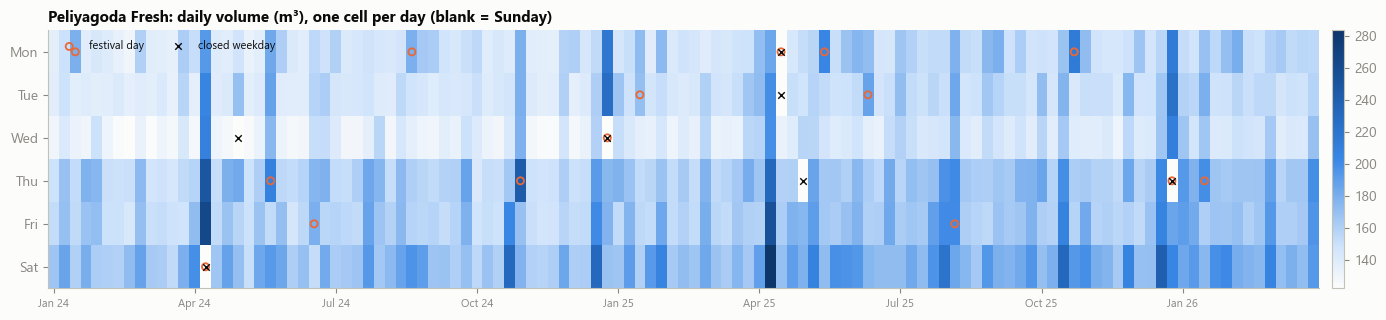

In [77]:
d = orders[(orders.depot == "Peliyagoda") & (orders.brand == "Fresh")].groupby("date").order_volume_m3.sum()
cald = cal[cal.date.between(d.index.min(), d.index.max())].copy()
cald["vol"] = cald.date.map(d)
cald["col"] = (cald.date - cald.date.min()).dt.days // 7
M_ = np.full((6, int(cald.col.max()) + 1), np.nan)
for r in cald[cald.dow < 6].itertuples():
    M_[r.dow, r.col] = r.vol
fig, ax = plt.subplots(figsize=(14, 3.3))
im = ax.imshow(M_, aspect="auto", cmap=SEQ_CMAP, interpolation="nearest")
ax.set_yticks(range(6), day_names); ax.grid(False)
yrs = pd.date_range(cald.date.min(), cald.date.max(), freq="QS")
ax.set_xticks([(t - cald.date.min()).days // 7 for t in yrs], [t.strftime("%b %y") for t in yrs], fontsize=8)
fs = cald[cald.festival.notna() & (cald.dow < 6)]
ax.scatter(fs.col, fs.dow, marker="o", s=26, facecolors="none", edgecolors=ORANGE, linewidths=1.3, label="festival day")
cl = cald[(cald.is_operating == 0) & (cald.dow < 6)]
ax.scatter(cl.col, cl.dow, marker="x", s=22, color=INK, linewidths=1.0, label="closed weekday")
fc_cols = [(t - cald.date.min()).days // 7 for t in [pd.Timestamp("2026-03-30")]]
ax.set_title("Peliyagoda Fresh: daily volume (m³), one cell per day (blank = Sunday)")
fig.colorbar(im, ax=ax, fraction=0.015, pad=0.01); ax.legend(loc="upper left", ncol=2, fontsize=8, framealpha=0.9)
fig.tight_layout(); save(fig, "eda_calendar_heatmap"); plt.show()

### 11.11 Weekday and month effects
Outside festival ramps and the payday window, Fresh orders are largest on Friday and Saturday and smallest on Tuesday and
Wednesday, and the pattern holds in every month. Ambient and chilled orders share the same shape.

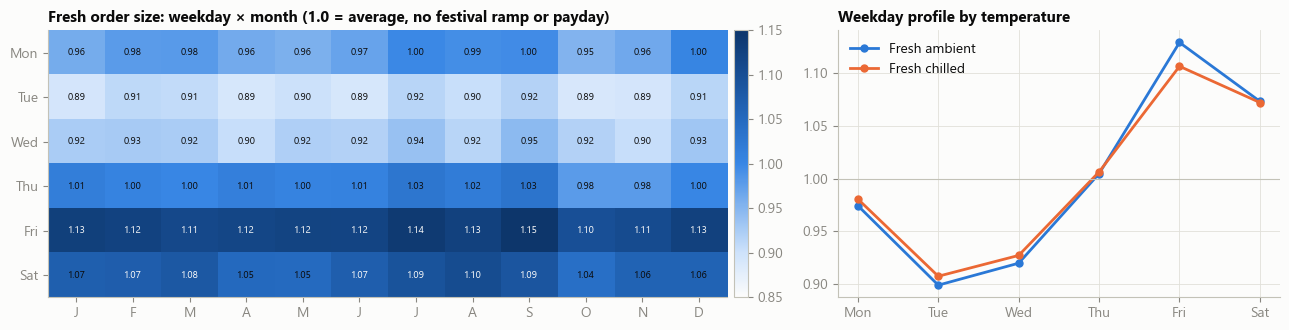

In [78]:
fr_rel = rel[(rel.brand == "Fresh") & (rel.festival_ramp == 0) & (rel.pay_win == 3)]      # no festival ramp, outside the payday window
hm = fr_rel.groupby([fr_rel.dow, fr_rel.date.dt.month]).rel.mean().unstack()
hm = hm / hm.stack().mean()
fig, axes = plt.subplots(1, 2, figsize=(13, 3.4), gridspec_kw={"width_ratios": [1.6, 1]})
im = axes[0].imshow(hm.values, aspect="auto", cmap=SEQ_CMAP, vmin=0.85, vmax=1.15)
axes[0].set_yticks(range(6), day_names); axes[0].set_xticks(range(12), ["J","F","M","A","M","J","J","A","S","O","N","D"]); axes[0].grid(False)
for i in range(hm.shape[0]):
    for j in range(hm.shape[1]):
        if not np.isnan(hm.values[i, j]):
            axes[0].text(j, i, f"{hm.values[i, j]:.2f}", ha="center", va="center", fontsize=7, color=INK if hm.values[i, j] < 1.07 else SURFACE)
axes[0].set_title("Fresh order size: weekday × month (1.0 = average, no festival ramp or payday)")
fig.colorbar(im, ax=axes[0], fraction=0.03, pad=0.01)
dm = fr_rel.groupby(["temp_requirement", fr_rel.dow]).rel.mean().unstack(0)
for t, c in [("ambient", BLUE), ("chilled", ORANGE)]:
    axes[1].plot(range(6), dm[t] / dm[t].mean(), marker="o", color=c, label=f"Fresh {t}")
axes[1].set_xticks(range(6), day_names); axes[1].set_title("Weekday profile by temperature"); axes[1].legend(); axes[1].axhline(1, color=AXIS, linewidth=0.8)
fig.tight_layout(); save(fig, "eda_weekday_month"); plt.show()

### 11.12 Concentration across outlets and districts
Volume is spread over many outlets (no single outlet dominates), so an outlet-level model is not driven by a few
accounts. Colombo and Gampaha carry the most volume at Peliyagoda; the distance-heavy districts (Matara, Puttalam,
Kurunegala) matter for Task 2B because far trips consume a refrigerated vehicle's whole pre-dawn window.

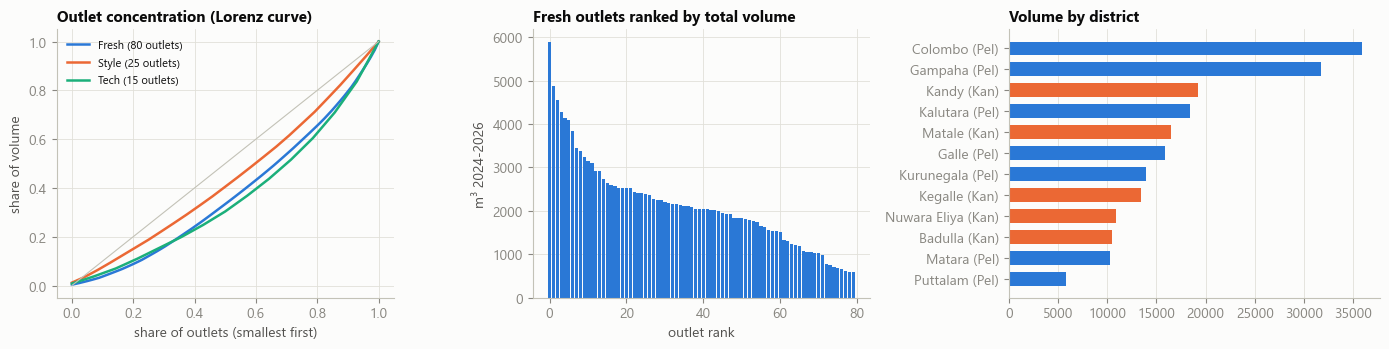

top 10 Fresh outlets = 24.5% of Fresh volume; largest district = Colombo (17.7%)


In [79]:
ov = orders.groupby(["brand", "outlet_id"]).order_volume_m3.sum()
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6), gridspec_kw={"width_ratios": [1, 1, 1.1]})
for b, c in BRAND_COLORS.items():
    v = np.sort(ov[b].values)
    axes[0].plot(np.insert(np.linspace(0, 1, len(v)), 0, 0)[1:], np.cumsum(v) / v.sum(), color=c, linewidth=1.8, label=f"{b} ({len(v)} outlets)")
axes[0].plot([0, 1], [0, 1], color=AXIS, linewidth=0.8)
axes[0].set_title("Outlet concentration (Lorenz curve)"); axes[0].set_xlabel("share of outlets (smallest first)"); axes[0].set_ylabel("share of volume"); axes[0].legend(fontsize=8)
top = ov["Fresh"].sort_values(ascending=False)
axes[1].bar(range(len(top)), top.values, color=BLUE, width=0.85)
axes[1].set_title("Fresh outlets ranked by total volume"); axes[1].set_xlabel("outlet rank"); axes[1].set_ylabel("m³ 2024-2026")
dist = orders.groupby(["depot", "district"]).order_volume_m3.sum().sort_values()
axes[2].barh([f"{d_} ({dep[:3]})" for dep, d_ in dist.index], dist.values, color=[DEPOT_COLORS[dep] for dep, _ in dist.index], height=0.65)
axes[2].set_title("Volume by district"); axes[2].grid(axis="y", visible=False)
fig.tight_layout(); save(fig, "eda_concentration"); plt.show()
print(f"top 10 Fresh outlets = {top.head(10).sum() / top.sum():.1%} of Fresh volume; largest district = {dist.index[-1][1]} ({dist.iloc[-1] / dist.sum():.1%})")

### 11.13 Is chilled just a fixed share of Fresh?
The chilled share is steady around 37% in every week and both depots, with a gentle seasonal rise in April–June (our
forecast window). A constant share is a decent baseline, but modelling chilled order slots directly is more accurate
(§18.3).

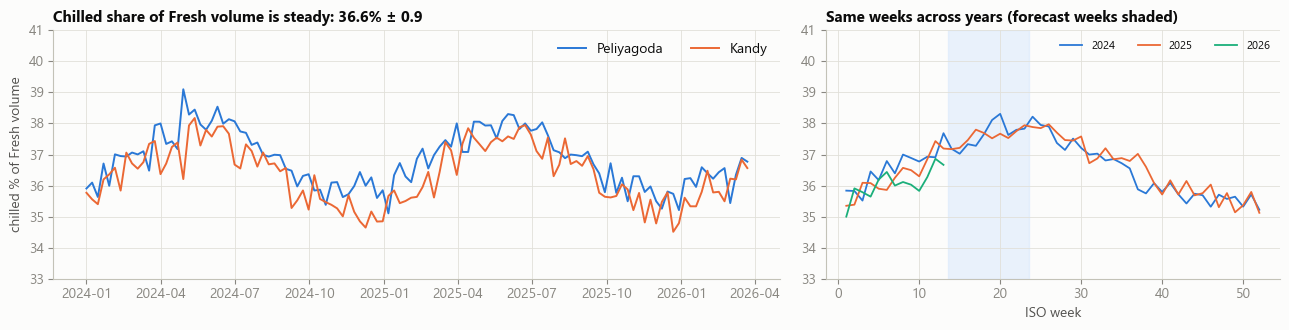

In [80]:
fr_w = weekly[weekly.brand == "Fresh"].assign(share=lambda d: 100 * d.chilled_m3 / d.total_m3)
fig, axes = plt.subplots(1, 2, figsize=(13, 3.4), gridspec_kw={"width_ratios": [1.6, 1]})
for dep, c in DEPOT_COLORS.items():
    s_ = fr_w[fr_w.depot == dep]
    axes[0].plot(s_.week_start, s_.share, color=c, linewidth=1.4, label=dep)
axes[0].set_ylim(33, 41); axes[0].set_ylabel("chilled % of Fresh volume"); axes[0].legend(ncol=2)
axes[0].set_title(f"Chilled share of Fresh volume is steady: {fr_w.share.mean():.1f}% ± {fr_w.share.std():.1f}")
for yr, c in zip([2024, 2025, 2026], [BLUE, ORANGE, AQUA]):
    s_ = fr_w[fr_w.iso_year == yr].groupby("iso_week").share.mean()
    axes[1].plot(s_.index, s_.values, color=c, linewidth=1.3, label=str(yr))
axes[1].axvspan(13.5, 23.5, color=BLUE_LIGHT, alpha=0.4, zorder=0); axes[1].set_ylim(33, 41)
axes[1].set_title("Same weeks across years (forecast weeks shaded)"); axes[1].set_xlabel("ISO week"); axes[1].legend(ncol=3, fontsize=8)
fig.tight_layout(); save(fig, "eda_chilled_share"); plt.show()

### 11.14 Which calendar drivers move weekly volume?
Per operating day, the **festival ramp is the strongest calendar driver** (correlation about 0.7 for Fresh and 0.5 for
Style), paydays are weaker (about 0.2), and Tech shows little structure. Closed days remove volume from the week, and
monsoon barely registers. (Holidays and operating days correlate at -0.7 by construction.)

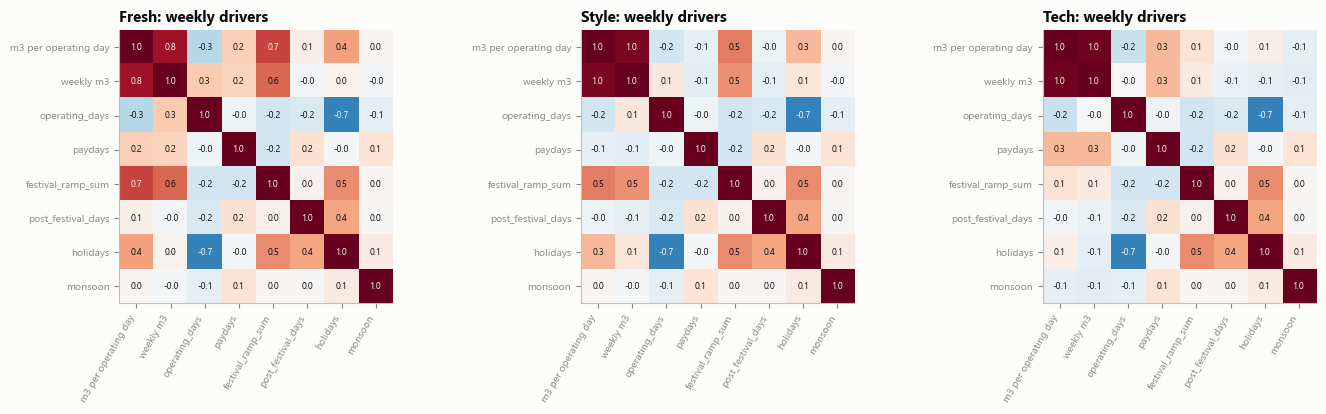

In [81]:
wc = cal.groupby("yw").agg(operating_days=("is_operating", "sum"), paydays=("is_payday", "sum"), festival_ramp_sum=("festival_ramp", "sum"),
                           holidays=("is_holiday", "sum"), post_festival_days=("post_festival", "sum"), monsoon=("monsoon", "max"))
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, b in zip(axes, ["Fresh", "Style", "Tech"]):
    w_ = weekly[weekly.brand == b].groupby("yw").agg(vol=("total_m3", "sum"))
    w_ = w_.join(wc)
    w_["m3 per operating day"] = w_.vol / w_.operating_days
    cols_ = ["m3 per operating day", "vol", "operating_days", "paydays", "festival_ramp_sum", "post_festival_days", "holidays", "monsoon"]
    cm = w_[cols_].rename(columns={"vol": "weekly m3"}).corr()
    im = ax.imshow(cm.values, cmap="RdBu_r", vmin=-1, vmax=1); ax.grid(False)
    ax.set_xticks(range(len(cm)), cm.columns, rotation=60, ha="right", fontsize=7.5); ax.set_yticks(range(len(cm)), cm.index, fontsize=7.5)
    for i in range(len(cm)):
        for j in range(len(cm)):
            ax.text(j, i, f"{cm.values[i, j]:.1f}", ha="center", va="center", fontsize=6.5, color=INK if abs(cm.values[i, j]) < 0.6 else SURFACE)
    ax.set_title(f"{b}: weekly drivers")
fig.tight_layout(); save(fig, "eda_driver_correlations"); plt.show()

### 11.15 Order size by weekday
Spread within a weekday is wide (orders differ in size), which is why the model works at order level and why a
perfect forecast still has a noise floor (§19.1).

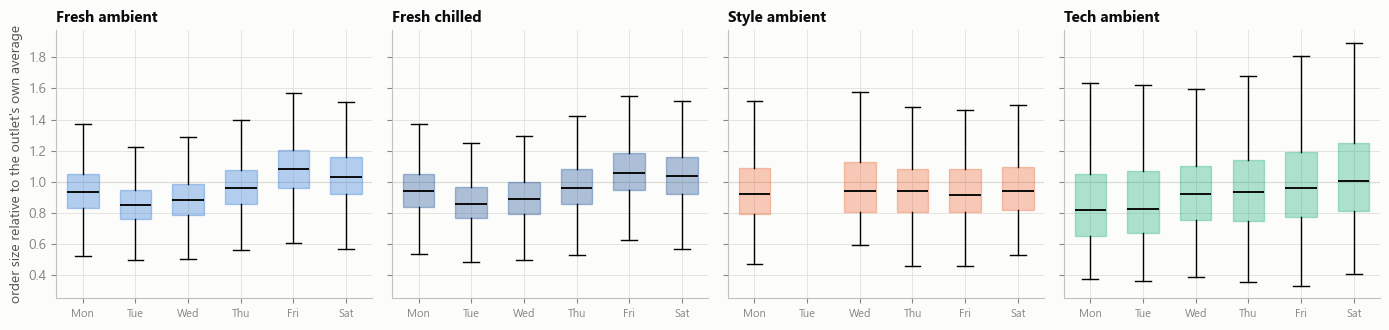

In [82]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.4), sharey=True)
for ax, (b, t), c in zip(axes, segs, [BLUE, BLUE_DARK, ORANGE, AQUA]):
    x = rel[plain & (rel.brand == b) & (rel.temp_requirement == t)]
    data = [x[x.dow == k].rel.values for k in range(6)]
    data = [v for v in data]
    bp = ax.boxplot(data, positions=range(6), showfliers=False, patch_artist=True, widths=0.6)
    for box_ in bp["boxes"]:
        box_.set(facecolor=c, alpha=0.35, edgecolor=c)
    for med in bp["medians"]:
        med.set(color=INK, linewidth=1.4)
    ax.set_xticks(range(6), day_names, fontsize=8); ax.set_title(f"{b} {t}"); ax.axhline(1, color=AXIS, linewidth=0.8, zorder=0)
axes[0].set_ylabel("order size relative to the outlet's own average")
fig.tight_layout(); save(fig, "eda_order_size_by_weekday"); plt.show()

**EDA takeaways → modelling decisions**

| Finding | Decision |
|---|---|
| Order *count* follows fixed outlet schedules, and closed days are skipped | Rebuild every expected order slot from the calendar (no need to forecast counts) |
| Order *size* = multiplicative calendar effects | Log-link model of volume per order |
| Festivals move between ISO weeks; festival strength is festival-specific | Festival-specific ramp curves, learned from the daily calendar rather than the week number |
| Payday lift lasts 3 days | Engineered `days_since_payday` |
| No real post-festival dip once compared like-for-like | Small optional term, judged by ablation |
| Chilled season peaks Apr–Jun | Annual Fourier terms per brand × temperature |
| Growth trend | Explicit trend term (tree models can't extrapolate one) |
| Monsoon / road disruption have no effect | Excluded |
| Deferred and never-dispatched orders concentrate in Fresh chilled (5.4% of chilled orders) | Keep them in the target |
| Chilled share is steady (about 37%) with a seasonal rise in Apr–Jun | Model chilled order slots directly, not a share of the total |
| Per operating day the festival ramp is the strongest calendar driver (r about 0.7 for Fresh); closed days remove volume | Model at order / day level and sum, instead of weekly totals |

## 12. Feature engineering

### 12.1 Calendar features (built in `add_festival_features`, §8)

| Feature | Meaning |
|---|---|
| `dow` | day of week (0 = Mon) |
| `days_since_payday` | calendar days since the most recent payday (0 = payday) → payday window |
| `festival_ramp`, `ramp_festival` | the calendar's ramp (0→1 over the 9 days before a festival) and *which* festival it leads to |
| `post_festival`, `days_since_festival` | inside the 10-day dip after a festival / days since the last one |
| `is_holiday`, `monsoon`, `month`, `iso_week` | calendar context (`iso_week` lets the model learn Style's seasonal peaks) |
| trend `t` | years since 1 Jan 2024 |
| Fourier terms | `sin/cos(2πk · day_of_year / 365.25)`, k = 1..3, per brand × temperature |
| `outlet_id × temperature` | the outlet's own baseline order size |

All of them are known in advance for any future date, so there is **no leakage**: nothing from the forecast weeks'
actual orders is used.

### 12.2 Order slots: which orders will be placed

`order_probabilities` learns P(order) for each outlet × temperature × weekday from history. Fresh and Style are
fixed schedules (snapped to exactly 0 or 1); Tech keeps its observed rate. `build_slots` then lists every slot on
every **operating** day of the forecast window.

In [83]:
def order_probabilities(orders, cal):
    """P(an order) for each outlet x temperature x weekday, learned from history.

    p = orders placed on that weekday / operating days with that weekday.
    Fresh ambient comes out at 1.0, Fresh chilled and Style at 1.0 or 0.0
    (fixed schedules), Tech in between (orders as needed).
    """
    lo, hi = orders.date.min(), orders.date.max()
    op = cal[(cal.date >= lo) & (cal.date <= hi) & (cal.is_operating == 1)]
    n_days = op.groupby("dow").size().rename("n_days")
    cnt = (orders.groupby(["outlet_id", "brand", "depot", "temp_requirement", "dow"])
                 .size().rename("n_orders").reset_index())

    # Full grid so weekdays an outlet never ordered on get p = 0.
    keys = orders[["outlet_id", "brand", "depot", "temp_requirement"]].drop_duplicates()
    grid = keys.merge(pd.DataFrame({"dow": range(6)}), how="cross")
    p = grid.merge(cnt, how="left").merge(n_days, left_on="dow", right_index=True)
    p["n_orders"] = p.n_orders.fillna(0)
    p["p_order"] = (p.n_orders / p.n_days).clip(upper=1.0)
    # Fixed schedules: snap near-certain slots to exactly 1 (or 0).
    fixed = p.brand.isin(["Fresh", "Style"])
    p.loc[fixed, "p_order"] = (p.loc[fixed, "p_order"] > 0.5).astype(float)
    return p[p.p_order > 0].drop(columns=["n_orders", "n_days"])


def build_slots(probs, cal, start, end):
    """One row per expected order slot on each operating day in [start, end]."""
    days = cal[(cal.date >= start) & (cal.date <= end) & (cal.is_operating == 1)]
    return days.merge(probs, on="dow", how="inner")

In [84]:
probs_all = order_probabilities(orders, cal)
slots_hist = build_slots(probs_all, cal, orders.date.min(), orders.date.max())
exp_cnt = slots_hist.groupby(["brand", "temp_requirement", "yw"]).p_order.sum()
act_cnt = orders.groupby(["brand", "temp_requirement", "yw"]).size()
rec = pd.concat([exp_cnt.rename("expected"), act_cnt.rename("actual")], axis=1).fillna(0)
rec["diff"] = rec.actual - rec.expected
summary = rec.groupby(level=[0, 1]).agg(weeks=("diff", "size"),
                                         weeks_exact=("diff", lambda d: (d.abs() < 0.5).sum()),
                                         mean_diff=("diff", "mean"), min_diff=("diff", "min"), max_diff=("diff", "max"))
display(summary)
mismatch = rec.loc[["Fresh", "Style"]]
mismatch = mismatch[mismatch["diff"].abs() > 0.5]
display(mismatch)

weeks  weeks_exact  mean_diff  min_diff  max_diff
brand temp_requirement                                                   
Fresh ambient             117          117      0.000     0.000     0.000
      chilled             117          113     -0.205   -12.000     0.000
Style ambient             117          117      0.000     0.000     0.000
Tech  ambient             117           20     -0.000   -10.517     6.483

expected  actual    diff
brand temp_requirement yw                              
Fresh chilled          202608   320.000     317  -3.000
                       202610   320.000     308 -12.000
                       202611   320.000     317  -3.000
                       202612   320.000     314  -6.000

The reconstruction reproduces **every historical week exactly** for Fresh ambient and Style (117/117 weeks). The
only Fresh chilled mismatches are in 2026 W08–W12. Those weeks come from `task1_test_inputs.csv`, which omits the
never-dispatched (`not_run`) chilled orders. Because the forecast is built from slots, these orders are counted, as
the brief requires ("count every order, including orders that were never dispatched"). Tech differs week to week
only through its random "as needed" ordering.

In [85]:
def make_features(df):
    """Model features; works on both order history and future slots."""
    X = pd.DataFrame(index=df.index)
    X["t_years"] = (df.date - T0).dt.days / 365.25
    X["dow"] = df.dow
    X["is_payday"] = df.is_payday
    X["days_since_payday"] = df.days_since_payday.clip(upper=10)
    X["festival_ramp"] = df.festival_ramp
    X["is_holiday"] = df.is_holiday
    X["post_festival"] = df.post_festival
    X["days_since_festival"] = df.days_since_festival.clip(upper=60)
    X["iso_week"] = df.iso_week
    X["month"] = df.date.dt.month
    X["monsoon"] = df.monsoon
    for c in CAT_COLS:
        X[c] = df[c].astype("category")
    return X


def aggregate_weekly(slots, pred_volume):
    """Expected weekly total / chilled m3 from slot-level predictions."""
    s = slots.assign(exp_m3=slots.p_order * pred_volume)
    s["exp_chilled_m3"] = np.where(s.temp_requirement == "chilled", s.exp_m3, 0.0)
    return (s.groupby(["depot", "brand", "iso_year", "iso_week"], as_index=False)
             .agg(pred_total_volume_m3=("exp_m3", "sum"),
                  pred_chilled_volume_m3=("exp_chilled_m3", "sum")))


def weekly_calendar(cal):
    """Calendar summarised per ISO week, for the top-down weekly model."""
    c = cal.copy()
    op = c.is_operating == 1
    c["op"] = op.astype(int)
    c["pay_win"] = (op & (c.days_since_payday <= 2)).astype(int)
    c["post"] = (op & (c.post_festival == 1)).astype(int)
    agg = {"op_days": ("op", "sum"), "payday_window_days": ("pay_win", "sum"),
           "post_festival_days": ("post", "sum"), "mid": ("date", "median")}
    for f in FESTIVALS:
        c[f"ramp_{f}"] = np.where(op & (c.ramp_festival == f), c.festival_ramp, 0.0)
        agg[f"ramp_{f}"] = (f"ramp_{f}", "sum")
    w = c.groupby(["iso_year", "iso_week"], as_index=False).agg(**agg)
    w["yw"] = w.iso_year * 100 + w.iso_week
    w["t_years"] = (w.mid - T0).dt.days / 365.25
    w["doy"] = w.mid.dt.dayofyear
    return w.drop(columns="mid")


def weeks_of(cal, yw_start, n_weeks):
    """The n ISO weeks starting at yw_start, as (iso_year, iso_week) rows."""
    w = cal[["iso_year", "iso_week", "yw"]].drop_duplicates().sort_values("yw")
    w = w[w.yw >= yw_start].head(n_weeks)
    return w


def week_bounds(cal, weeks):
    days = cal[cal.yw.isin(weeks.yw)]
    return days.date.min(), days.date.max()

In [86]:
wk = weeks_of(cal, FORECAST_START, N_WEEKS)
h_start, h_end = week_bounds(cal, wk)
horizon_slots = build_slots(probs_all, cal, h_start, h_end)
print(f"forecast window {h_start.date()} -> {h_end.date()} : {len(horizon_slots):,} order slots")
display(horizon_slots.groupby(["iso_week", "brand"]).p_order.sum().unstack().T.round(1))
display(make_features(horizon_slots).head())

forecast window 2026-03-30 -> 2026-06-07 : 8,131 order slots


iso_week,14,15,16,17,18,19,20,21,22,23
brand,,,,,,,,,,
Fresh,800.000,800.000,532.000,800.000,675.000,800.000,800.000,800.000,800.000,800.000
Style,25.000,25.000,21.000,25.000,20.000,25.000,25.000,25.000,25.000,25.000
Tech,15.500,15.500,11.400,15.500,11.200,15.500,15.500,15.500,15.500,15.500


,t_years,dow,is_payday,days_since_payday,festival_ramp,is_holiday,post_festival,days_since_festival,iso_week,month,monsoon,outlet_id,brand,depot,temp_requirement,ramp_festival,post_festival_name
0,2.242,0,0,5,0.000,0,0,60,14,3,1,OUT001,Fresh,Peliyagoda,ambient,none,none
1,2.242,0,0,5,0.000,0,0,60,14,3,1,OUT002,Fresh,Peliyagoda,ambient,none,none
2,2.242,0,0,5,0.000,0,0,60,14,3,1,OUT003,Fresh,Peliyagoda,ambient,none,none
3,2.242,0,0,5,0.000,0,0,60,14,3,1,OUT004,Fresh,Peliyagoda,ambient,none,none
4,2.242,0,0,5,0.000,0,0,60,14,3,1,OUT005,Fresh,Peliyagoda,ambient,none,none


### 12.3 Weekly and daily panels and horizon-safe features (for the structural daily model)
The second model family works on **series panels** instead of individual orders: a weekly and a daily table per
depot × brand, complete (a week with no orders is a 0, not a missing row), with the calendar features of every week,
including the 10 forecast weeks.

Its features are built at a **forecast origin** `o`: levels, growth, last year's analogue and chilled share are
computed only from weeks ≤ `o`, while the calendar of the next 10 weeks (known in advance) supplies the rest. The first
line of `origin_features` cuts all outcomes at `o`, and `leakage_test` proves it: it replaces every outcome after the
origin with random numbers and the features must come out *identical*.

* A **clean week** has 6 operating days, no festival ramp and no festival (Style: not ISO weeks 10 or 32). Levels are
  built from clean weeks only, as volume per operating day.
* `yoy8` = the last 8 clean weeks vs the same weeks a year earlier (growth). `share_ly_target` = last year's chilled
  share of the same week.
* Style has exactly one order per scheduled outlet per week, so the number of *scheduled operating days* is a known,
  exact driver of its order count (`n_style_scheduled`).

In [87]:
DEPOTS, BRANDS = ["Kandy", "Peliyagoda"], ["Fresh", "Style", "Tech"]

SERIES = [f"{d}-{b}" for d in DEPOTS for b in BRANDS]

KEYS = ["depot", "brand", "iso_year", "iso_week"]

HORIZON, MAX_FEST_DIST, FIRST_ORIGIN, MIN_TRAIN_ROWS, SEED = 10, 8, 12, 600, 42

STYLE_EVENT_WEEKS = {10, 32}

CAL_FEATS = ["n_operating_days", "n_closed_weekdays", "n_paydays_operating", "ramp_max", "ramp_sum_operating",
             "has_festival", "fest_day_closed", "weeks_to_next_festival", "weeks_since_last_festival",
             "fest_rel_week", "monsoon", "n_style_scheduled"]

LEVEL_FEATS = ["lvl4", "lvl8", "lvl13", "lvl_med8", "cv13", "trend26", "weeks_since_clean", "yoy8",
               "opd_orders8", "vpo8", "outlets4"]

SEASONAL_FEATS = ["ly_total", "ly_vpod", "ly_ratio_opd", "ly_n_op", "ly_ramp",
                  "fr_ratio", "fr_ratio_brand", "fr_ramp", "fest_strength", "ramp_x_strength", "dow_weight"]

SHARE_FEATS = ["share_recent6", "share_ly_recent6", "share_ly_target", "share_seasonal"]

ID_COLS = ["origin_idx", "h", "week_idx", "depot", "brand", "series", "iso_year", "iso_week", "row_id", "is_future",
           "near_festival"]

Y_COLS = ["y_total", "y_chilled", "y_share", "y_ratio_opd", "y_ratio_week"]

FEATURES = CAL_FEATS + LEVEL_FEATS + SEASONAL_FEATS + SHARE_FEATS

WK_OUTCOMES = ["total_vol", "chilled_vol", "n_orders", "n_outlets_ordering", "n_order_days",
               "chilled_share", "vol_per_order", "vol_per_op_day"]

DY_OUTCOMES = ["total_vol", "chilled_vol", "n_orders", "n_outlets_ordering"]

ML_FEATS = ["h", "is_fresh", "is_style", "is_kandy", "n_operating_days", "dow_weight", "n_closed_weekdays",
            "n_paydays_operating", "ramp_sum_operating", "ramp_max", "has_festival", "fest_day_closed",
            "fest_strength", "ramp_x_strength", "ly_ratio_opd", "cv13", "yoy8"]

LGB_PARAMS = dict(objective="l1", learning_rate=0.03, n_estimators=400, num_leaves=7, min_child_samples=40,
                  subsample=0.8, subsample_freq=1, colsample_bytree=0.8, reg_lambda=5.0, verbose=-1,
                  random_state=SEED)

def structural_calendar(cal):
    """Calendar summarised per ISO week, with distance to the nearest festival."""
    c = cal.copy()
    c["closed_weekday"] = ((c.is_operating == 0) & (c.dow != 6)).astype(int)
    c["payday_operating"] = c.is_payday * c.is_operating
    c["ramp_operating"] = c.festival_ramp * c.is_operating
    w = (c.groupby(["iso_year", "iso_week"])
          .agg(week_start=("date", "min"), n_days=("date", "size"),
               n_operating_days=("is_operating", "sum"), n_closed_weekdays=("closed_weekday", "sum"),
               n_holidays=("is_holiday", "sum"), n_paydays=("is_payday", "sum"),
               n_paydays_operating=("payday_operating", "sum"), monsoon=("monsoon", "max"),
               ramp_max=("festival_ramp", "max"), ramp_sum=("festival_ramp", "sum"),
               ramp_sum_operating=("ramp_operating", "sum"))
          .reset_index())
    assert (w.n_days == 7).all(), "every ISO week in the calendar must be complete"
    w["week_idx"] = np.arange(len(w))
    fest = (c.loc[c.festival != "", ["iso_year", "iso_week", "date", "festival", "is_operating"]]
             .rename(columns={"date": "festival_date", "festival": "festival_name",
                              "is_operating": "festival_day_operating"}))
    assert not fest.duplicated(["iso_year", "iso_week"]).any(), "two festivals in one week"
    w = w.merge(fest, on=["iso_year", "iso_week"], how="left")
    w["has_festival"] = w.festival_name.notna().astype(int)
    w["festival_name"] = w.festival_name.fillna("")
    fw = w.loc[w.has_festival == 1, ["week_idx", "festival_name"]].to_numpy()
    idx = w.week_idx.to_numpy()
    nxt = np.array([next((f for f in fw if f[0] >= i), None) for i in idx], dtype=object)
    prv = np.array([next((f for f in fw[::-1] if f[0] <= i), None) for i in idx], dtype=object)
    w["weeks_to_next_festival"] = [min(f[0] - i, MAX_FEST_DIST) if f is not None else MAX_FEST_DIST
                                   for f, i in zip(nxt, idx)]
    w["weeks_since_last_festival"] = [min(i - f[0], MAX_FEST_DIST) if f is not None else MAX_FEST_DIST
                                      for f, i in zip(prv, idx)]
    w["next_festival_name"] = [f[1] if f is not None and f[0] - i <= MAX_FEST_DIST else ""
                               for f, i in zip(nxt, idx)]
    w["fest_rel_week"] = np.where(w.weeks_to_next_festival <= w.weeks_since_last_festival,
                                  -w.weeks_to_next_festival, w.weeks_since_last_festival)
    w.loc[w.fest_rel_week.abs() >= MAX_FEST_DIST, "fest_rel_week"] = np.nan
    return w

def style_schedule(orders):
    """Each Style outlet orders once a week, always on the same weekday."""
    s = orders[orders.brand == "Style"]
    sched = (s.groupby(["outlet_id", "depot"])
              .agg(fixed_dow=("dow", lambda x: x.mode()[0]),
                   share_on_fixed_dow=("dow", lambda x: (x == x.mode()[0]).mean()),
                   n_orders=("delivery_id", "size")).reset_index())
    assert (sched.share_on_fixed_dow == 1).all()
    return sched

def style_scheduled(dates, sched):
    """Number of Style outlets per depot whose fixed weekday is an operating day on each date."""
    n = sched.groupby(["depot", "fixed_dow"]).size().rename("n_sched").reset_index()
    out = dates[["date", "dow", "is_operating"]].merge(n, left_on="dow", right_on="fixed_dow", how="left")
    out["n_style_scheduled"] = out.n_sched.fillna(0) * out.is_operating
    return out[["date", "depot", "n_style_scheduled"]]

def build_panels(orders, cal, t2a, origin=(2026, 13)):
    """Weekly and daily series panels from the combined order table and the calendar.

    `orders` needs: delivery_id, date, outlet_id, depot, brand, temp_requirement, order_volume_m3, dow.
    `t2a` is task2a_test_inputs (the 60 forecast rows). History ends with ISO week `origin`.
    """
    cal = cal[["date", "dow", "dow_name", "iso_year", "iso_week", "is_payday", "festival", "festival_ramp",
               "is_holiday", "monsoon", "is_operating"]].copy()
    cal["festival"] = cal.festival.fillna("")
    cal = cal.sort_values("date").reset_index(drop=True)
    o = orders.assign(order_date=orders.date, chilled_vol=np.where(orders.temp_requirement == "chilled",
                                                                   orders.order_volume_m3, 0.0))
    wcal = structural_calendar(cal)
    sched = style_schedule(o)
    day_sched = style_scheduled(cal, sched)
    week_sched = (day_sched.merge(cal[["date", "iso_year", "iso_week"]], on="date")
                  .groupby(["depot", "iso_year", "iso_week"])["n_style_scheduled"].sum().reset_index())
    origin_week_end = cal.loc[(cal.iso_year == origin[0]) & (cal.iso_week == origin[1]), "date"].max()

    hist_weeks = wcal[(wcal.week_start >= o.order_date.min()) & (wcal.week_start <= origin_week_end)]
    grid = pd.MultiIndex.from_product(
        [DEPOTS, BRANDS, list(map(tuple, hist_weeks[["iso_year", "iso_week"]].values))],
        names=["depot", "brand", "yw"]).to_frame(index=False)
    grid[["iso_year", "iso_week"]] = pd.DataFrame(grid.pop("yw").tolist(), index=grid.index)
    agg = (o.groupby(["depot", "brand", "iso_year", "iso_week"])
            .agg(total_vol=("order_volume_m3", "sum"), chilled_vol=("chilled_vol", "sum"),
                 n_orders=("delivery_id", "size"), n_outlets_ordering=("outlet_id", "nunique"),
                 n_order_days=("order_date", "nunique"), source=("source", "first")).reset_index())
    hist = grid.merge(agg, on=KEYS, how="left", validate="one_to_one")
    cc = ["total_vol", "chilled_vol", "n_orders", "n_outlets_ordering", "n_order_days"]
    hist[cc] = hist[cc].fillna(0)
    hist["source"] = hist.source.fillna("train")
    hist["is_future"], hist["row_id"] = 0, ""
    fut = t2a[["row_id", *KEYS]].assign(is_future=1, source="forecast")
    wk = pd.concat([hist, fut], ignore_index=True)
    wk = wk.merge(wcal, on=["iso_year", "iso_week"], how="left", validate="many_to_one")
    wk = wk.merge(week_sched, on=["depot", "iso_year", "iso_week"], how="left")
    wk.loc[wk.brand != "Style", "n_style_scheduled"] = np.nan
    wk["chilled_share"] = np.where(wk.brand == "Fresh", wk.chilled_vol / wk.total_vol, np.nan)
    wk["vol_per_order"] = wk.total_vol / wk.n_orders
    wk["vol_per_op_day"] = wk.total_vol / wk.n_operating_days
    wk["series"] = wk.depot + "-" + wk.brand
    wk = wk.sort_values(["series", "iso_year", "iso_week"]).reset_index(drop=True)
    # the sort above is by series; keep the calendar-order week index
    wk = wk.sort_values(["series", "week_idx"]).reset_index(drop=True)

    dgrid = pd.MultiIndex.from_product([DEPOTS, BRANDS, cal.date], names=["depot", "brand", "date"]).to_frame(index=False)
    d_agg = (o.groupby(["depot", "brand", "order_date"])
              .agg(total_vol=("order_volume_m3", "sum"), chilled_vol=("chilled_vol", "sum"),
                   n_orders=("delivery_id", "size"), n_outlets_ordering=("outlet_id", "nunique"))
              .reset_index().rename(columns={"order_date": "date"}))
    dy = dgrid.merge(d_agg, on=["depot", "brand", "date"], how="left", validate="one_to_one")
    dy = dy.merge(cal, on="date", how="left", validate="many_to_one")
    dy["is_future"] = (dy.date > origin_week_end).astype(int)
    dcols = DY_OUTCOMES
    dy.loc[dy.is_future == 0, dcols] = dy.loc[dy.is_future == 0, dcols].fillna(0)
    dy = dy.merge(day_sched, on=["date", "depot"], how="left")
    dy.loc[dy.brand != "Style", "n_style_scheduled"] = np.nan
    dy["series"] = dy.depot + "-" + dy.brand
    dy = dy.sort_values(["depot", "brand", "date"]).reset_index(drop=True)
    n_hist_days = (dy.is_future == 0).sum()
    dy = dy.merge(wk[["iso_year", "iso_week", "week_idx"]].drop_duplicates(), on=["iso_year", "iso_week"], how="inner")
    assert (dy.is_future == 0).sum() == n_hist_days

    # festival tagging used by the model
    origin_idx = int(wk.loc[(wk.iso_year == origin[0]) & (wk.iso_week == origin[1]), "week_idx"].iloc[0])
    fest_at = wk[wk.has_festival == 1].drop_duplicates("week_idx").set_index("week_idx").festival_name
    src_week = (wk.week_idx - wk.fest_rel_week.fillna(0)).astype(int)
    wk["near_festival"] = np.where(wk.fest_rel_week > 0, src_week.map(fest_at), wk.next_festival_name)
    wk["fest_day_closed"] = ((wk.has_festival == 1) & (wk.festival_day_operating == 0)).astype(int)
    wk["clean"] = clean_flag(wk)
    week_start = wk.drop_duplicates("week_idx").set_index("week_idx").week_start
    week_end = week_start + pd.Timedelta(days=6)
    fd = (wk[wk.has_festival == 1].drop_duplicates("week_idx")[["festival_date", "festival_name"]]
          .sort_values("festival_date").reset_index(drop=True))
    fdates = fd.festival_date.to_numpy()
    dyx = dy.merge(wk[["series", "week_idx", "clean"]], on=["series", "week_idx"])
    pos = np.minimum(np.searchsorted(fdates, dyx.date.to_numpy()), len(fdates) - 1)
    in_ramp = (dyx.festival_ramp > 0).to_numpy()
    dyx["ramp_fest"] = np.where(in_ramp, fd.festival_name.to_numpy()[pos], "")
    dyx["ramp_fest_date"] = pd.Series(np.where(in_ramp, fdates[pos], np.datetime64("NaT", "us")), index=dyx.index)
    return SimpleNamespace(wk=wk, dy=dy, dyx=dyx, wcal=wcal, sched=sched, origin=origin, origin_idx=origin_idx,
                           week_start=week_start, week_end=week_end, t2a=t2a)

def clean_flag(df):
    """A 'clean' week has 6 operating days, no festival ramp and no festival (Style: not ISO wk 10 / 32)."""
    c = (df.n_operating_days == 6) & (df.ramp_max == 0) & (df.has_festival == 0)
    return c & ~((df.brand == "Style") & df.iso_week.isin(STYLE_EVENT_WEEKS))

def past_clean_median(v, gap=3, n=6):
    """Median of the last n clean weeks that are at least `gap` weeks back, however far back they are."""
    m = v.shift(gap).dropna().rolling(n, min_periods=2).median()
    return m.reindex(v.index).ffill()

def origin_features(P, o):
    """Rows for origin week index `o`: calendar of the next 10 weeks plus outcome features from weeks <= o."""
    wk_all, dy_all = P.wk, P.dy
    hist = wk_all[wk_all.week_idx <= o].copy()           # <- the only line that lets outcomes in
    dh = dy_all[dy_all.week_idx <= o].copy()
    hist["clean"] = clean_flag(hist)
    hist["base"] = hist.vol_per_op_day.where(hist.clean).groupby(hist.series).transform(past_clean_median)
    hist["ratio_opd"] = hist.vol_per_op_day / hist.base

    rows = []
    for s, g in hist.groupby("series"):
        c = g[g.clean]
        v, idx = c.vol_per_op_day.to_numpy(), c.week_idx.to_numpy()
        f = {"series": s, "lvl4": v[-4:].mean(), "lvl8": v[-8:].mean(), "lvl13": v[-13:].mean(),
             "lvl_med8": np.median(v[-8:]), "cv13": v[-13:].std(ddof=1) / v[-13:].mean(),
             "weeks_since_clean": o - idx[-1],
             "opd_orders8": (c.n_orders / c.n_operating_days).to_numpy()[-8:].mean(),
             "vpo8": c.vol_per_order.to_numpy()[-8:].mean(),
             "outlets4": g.n_outlets_ordering.tail(4).max()}
        m = (idx > o - 26) & (v > 0)
        f["trend26"] = np.polyfit(idx[m], np.log(v[m]), 1)[0] if m.sum() >= 8 else np.nan
        ly = c.set_index("week_idx").vol_per_op_day.reindex(idx[-8:] - 52)
        ok = ly.notna().to_numpy()
        f["yoy8"] = v[-8:][ok].sum() / ly[ok].sum() if ok.sum() >= 4 else np.nan
        if g.brand.iloc[0] == "Fresh":
            r6 = g[g.week_idx > o - 6]
            l6 = g[(g.week_idx > o - 58) & (g.week_idx <= o - 52)]
            f["share_recent6"] = r6.chilled_vol.sum() / r6.total_vol.sum()
            f["share_ly_recent6"] = l6.chilled_vol.sum() / l6.total_vol.sum() if len(l6) == 6 else np.nan
        rows.append(f)
    lvl = pd.DataFrame(rows)

    tg = wk_all[(wk_all.week_idx > o) & (wk_all.week_idx <= o + HORIZON)]
    if o < P.origin_idx:
        tg = tg[tg.week_idx <= P.origin_idx]              # training origins need known labels
    t = tg[["week_idx", "depot", "brand", "series", "iso_year", "iso_week", "row_id", "is_future", "near_festival",
            *CAL_FEATS, "total_vol", "chilled_vol", "chilled_share", "vol_per_op_day"]].copy()
    t.insert(0, "origin_idx", o)
    t.insert(1, "h", t.week_idx - o)
    t = t.merge(lvl, on="series", how="left")

    ly = hist.set_index(["series", "week_idx"])
    key = pd.MultiIndex.from_arrays([t.series, t.week_idx - 52])
    for col, src in [("ly_total", "total_vol"), ("ly_vpod", "vol_per_op_day"), ("ly_ratio_opd", "ratio_opd"),
                     ("ly_n_op", "n_operating_days"), ("ly_ramp", "ramp_sum_operating"),
                     ("share_ly_target", "chilled_share")]:
        t[col] = ly[src].reindex(key).to_numpy()
    t.loc[t.brand != "Fresh", "share_ly_target"] = np.nan

    fr = (hist.dropna(subset=["ratio_opd"]).sort_values("week_idx")
              .groupby(["series", "near_festival", "fest_rel_week"])[["ratio_opd", "ramp_sum_operating"]].last()
              .rename(columns={"ratio_opd": "fr_ratio", "ramp_sum_operating": "fr_ramp"}).reset_index())
    t = t.merge(fr, on=["series", "near_festival", "fest_rel_week"], how="left")
    t["fr_ratio_brand"] = t.groupby(["week_idx", "brand"]).fr_ratio.transform("mean")

    pk = hist[hist.fest_rel_week.isin([-1, 0])].assign(occ=lambda d: d.week_idx - d.fest_rel_week)
    pk = pk.groupby(["series", "brand", "near_festival", "occ"]).agg(peak=("ratio_opd", "max"),
                                                                     n=("ratio_opd", "count"))
    pk = (pk[pk.n == 2].groupby(["brand", "near_festival", "occ"]).peak.mean().reset_index()
            .sort_values("occ").groupby(["brand", "near_festival"]).peak.last().rename("fest_strength").reset_index())
    t = t.merge(pk, on=["brand", "near_festival"], how="left")
    t["ramp_x_strength"] = t.ramp_sum_operating * (t.fest_strength - 1)

    dh = dh.merge(hist[["series", "week_idx", "clean"]], on=["series", "week_idx"])
    dh = dh[dh.clean & (dh.is_operating == 1)]
    fac = (dh.groupby(["series", "dow"]).total_vol.mean() / dh.groupby("series").total_vol.mean()).rename("fac")
    dc = dy_all[dy_all.week_idx.isin(t.week_idx.unique()) & (dy_all.is_operating == 1)][["series", "week_idx", "dow"]]
    dc = dc.join(fac, on=["series", "dow"])
    t = t.merge(dc.groupby(["series", "week_idx"]).fac.sum().rename("dow_weight").reset_index(),
                on=["series", "week_idx"], how="left")
    t["share_seasonal"] = t.share_ly_target + (t.share_recent6 - t.share_ly_recent6)

    t = t.rename(columns={"total_vol": "y_total", "chilled_vol": "y_chilled", "chilled_share": "y_share"})
    t["y_ratio_opd"] = t.pop("vol_per_op_day") / t.lvl_med8
    t["y_ratio_week"] = t.y_total / (6 * t.lvl_med8)
    return t[ID_COLS + CAL_FEATS + LEVEL_FEATS + SEASONAL_FEATS + SHARE_FEATS + Y_COLS]

def build_features(P, first_origin=FIRST_ORIGIN):
    feat = pd.concat([origin_features(P, o) for o in range(first_origin, P.origin_idx + 1)], ignore_index=True)
    feat["is_fresh"] = (feat.brand == "Fresh").astype(int)
    feat["is_style"] = (feat.brand == "Style").astype(int)
    feat["is_kandy"] = (feat.depot == "Kandy").astype(int)
    feat["base_ml"] = feat.lvl13 * feat.dow_weight
    feat["r_ml"] = feat.y_total / feat.base_ml
    return feat

def leakage_test(P, origins, seed=SEED):
    """Replace every outcome after each origin with random numbers: the features must not change at all."""
    rng = np.random.default_rng(seed)
    cols = ID_COLS + FEATURES
    for o in origins:
        bad = SimpleNamespace(**vars(P))
        bad.wk, bad.dy = P.wk.copy(), P.dy.copy()
        fw, fd = bad.wk.week_idx > o, bad.dy.week_idx > o
        bad.wk.loc[fw, WK_OUTCOMES] = rng.uniform(0, 5000, (fw.sum(), len(WK_OUTCOMES)))
        bad.dy.loc[fd, DY_OUTCOMES] = rng.uniform(0, 500, (fd.sum(), len(DY_OUTCOMES)))
        pd.testing.assert_frame_equal(origin_features(P, o)[cols], origin_features(bad, o)[cols])
    return True

def fit_structural(P, o, n_lvl=13, n_lvl_tech=26, fest_agg="mean"):
    """Learn weekday factors f, payday uplift p, levels L and festival slopes b from data up to origin o."""
    d = P.dyx[P.dyx.week_idx <= o]
    is_tech = lambda s: s.endswith("Tech")
    nwin = lambda s: n_lvl_tech if is_tech(s) else n_lvl

    cd = d[d.clean & (d.is_operating == 1)].copy()
    cd["q"] = cd.total_vol / cd.groupby(["series", "week_idx"]).total_vol.transform("mean")
    f = cd[cd.is_payday == 0].groupby(["series", "dow"]).q.mean()
    f = f / f.groupby(level="series").transform("mean")
    f[np.array([is_tech(s) for s in f.index.get_level_values("series")])] = 1.0    # Tech: flat weekdays

    def fac(df):
        return f.reindex(pd.MultiIndex.from_arrays([df.series, df.dow])).fillna(0).to_numpy()

    cd["f"] = fac(cd)
    cd = cd[cd.f > 0]
    cd["x"] = cd.q / cd.f
    pay = cd.groupby(["brand", "is_payday"]).x.mean().unstack()
    p = (pay[1] / pay[0] - 1).rename("p")

    def expected(df):
        return fac(df) * (1 + df.brand.map(p).to_numpy() * df.is_payday.to_numpy())

    cd["e"] = expected(cd)
    wkly = cd.groupby(["series", "week_idx"]).agg(v=("total_vol", "sum"), e=("e", "sum")).reset_index()
    lv = {s: (g.week_idx.to_numpy(), g.v.to_numpy(), g.e.to_numpy()) for s, g in wkly.groupby("series")}

    def level(s, before):
        idx, v, e = lv[s]
        m = idx < before
        return v[m][-nwin(s):].sum() / e[m][-nwin(s):].sum() if m.sum() >= 2 else np.nan

    L = {s: level(s, o + 1) for s in lv}

    rd = d[(d.festival_ramp > 0) & (d.is_operating == 1) & (d.ramp_fest_date <= P.week_end[o])].copy()
    rd["e"] = expected(rd)
    rd = rd[rd.e > 0]
    start = rd.groupby(["series", "ramp_fest_date"]).week_idx.transform("min")
    rd["L"] = [level(s, w) for s, w in zip(rd.series, start)]
    rd["dev"] = rd.total_vol / (rd.L * rd.e) - 1
    rd = rd.dropna(subset=["dev"])
    rd["num"], rd["den"] = rd.festival_ramp * rd.dev, rd.festival_ramp ** 2
    occ = (rd.groupby(["brand", "ramp_fest", "ramp_fest_date"]).agg(num=("num", "sum"), den=("den", "sum"))
             .reset_index().sort_values("ramp_fest_date"))
    occ["b"] = occ.num / occ.den                                  # least-squares slope through the origin
    bF = occ.groupby(["brand", "ramp_fest"]).b.agg(fest_agg)
    bP = occ.groupby("brand").b.mean()
    return dict(o=o, f=f, p=p, L=L, occ=occ, bF=bF, bP=bP, expected=expected)

def predict_structural(P, m):
    o = m["o"]
    last = o + HORIZON if o == P.origin_idx else min(o + HORIZON, P.origin_idx)
    td = P.dyx[(P.dyx.week_idx > o) & (P.dyx.week_idx <= last) & (P.dyx.is_operating == 1)].copy()
    b = m["bF"].reindex(pd.MultiIndex.from_arrays([td.brand, td.ramp_fest])).to_numpy()
    b = np.where(np.isnan(b) | (td.brand == "Tech").to_numpy(), td.brand.map(m["bP"]).to_numpy(), b)
    td["pred"] = td.series.map(m["L"]) * m["expected"](td) * (1 + np.nan_to_num(b) * td.festival_ramp)
    return td.groupby(["series", "week_idx"]).pred.sum().rename("STRUCT").reset_index().assign(origin_idx=o)

def fit_lgbm(feat, o):
    """Global LightGBM on the ratio week / (lvl13 * dow_weight); only labels known at origin o are used."""
    tr = feat[(feat.week_idx <= o) & (feat.is_future == 0)]
    if len(tr) < MIN_TRAIN_ROWS:
        return None
    return lgb.LGBMRegressor(**LGB_PARAMS).fit(tr[ML_FEATS], tr.r_ml, sample_weight=tr.base_ml)

def tech_flat(P, o):
    h = P.wk[(P.wk.week_idx <= o) & (P.wk.brand == "Tech") & P.wk.clean]
    return h.groupby("series").vol_per_op_day.apply(lambda s: s.tail(26).mean())

def forecast_origin(P, feat, o, struct_fit=None, lgbm_fit="fit"):
    """All structural-family forecasts for origin o: B1/B2 baselines, STRUCT, STRUCT_G, LGBM, TECH_FLAT."""
    X = feat[feat.origin_idx == o].copy()
    X["B1_SEASONAL"] = X.ly_total * X.yoy8
    X["B2_RECENT"] = X.lvl8 * X.n_operating_days
    sf = struct_fit or fit_structural(P, o)
    X = X.merge(predict_structural(P, sf)[["series", "week_idx", "STRUCT"]], on=["series", "week_idx"], how="left")
    X["STRUCT_G"] = X.STRUCT * np.where(X.brand == "Tech", 1.0, X.yoy8.fillna(1.0) ** ((X.h + 6.5) / 52))
    lg = fit_lgbm(feat, o) if isinstance(lgbm_fit, str) else lgbm_fit
    X["LGBM"] = np.nan if lg is None else X.base_ml * lg.predict(X[ML_FEATS])
    X["TECH_FLAT"] = np.nan
    t = X.brand == "Tech"
    X.loc[t, "TECH_FLAT"] = X.loc[t, "series"].map(tech_flat(P, o)) * X.loc[t, "n_operating_days"]
    share = X.share_ly_target.fillna(X.share_recent6)
    for c in ["B1_SEASONAL", "B2_RECENT", "STRUCT", "STRUCT_G", "LGBM", "TECH_FLAT"]:
        X[c] = X[c].clip(lower=0)
    X["share"] = share
    return X, sf, lg

def structural_to_dict(P, m, settings):
    f = m["f"]
    return {
        "model": "structural multiplicative daily model",
        "equation": "pred_day = L[series] * f[series][dow] * (1 + p[brand] * is_payday) * "
                    "(1 + b[brand][festival] * festival_ramp); week = sum over open days; "
                    "Fresh/Style then * yoy8 ** ((h + 6.5) / 52)",
        "origin": {"iso_year": P.origin[0], "iso_week": P.origin[1], "week_idx": P.origin_idx,
                   "week_end": str(P.week_end[P.origin_idx].date())},
        "settings": settings,
        "level_L": {s: float(v) for s, v in m["L"].items()},
        "dow_factor": {s: {str(int(d)): float(v) for d, v in f.xs(s, level="series").items()}
                       for s in f.index.get_level_values("series").unique()},
        "payday_uplift": {b: float(v) for b, v in m["p"].items()},
        "festival_slope": {b: {fz: float(v) for fz, v in g.droplevel("brand").items()}
                           for b, g in m["bF"].groupby(level="brand")},
        "festival_slope_pooled": {b: float(v) for b, v in m["bP"].items()},
        "pooled_slope_brands": ["Tech"],
        "growth": {"brands": ["Fresh", "Style"], "lag_weeks": 6.5, "feature": "yoy8"},
    }

In [88]:
P = build_panels(orders, cal, t2a_inputs)
h_, f_ = P.wk[P.wk.is_future == 0], P.wk[P.wk.is_future == 1]
panel_checks = {
    "history rows = 6 series x 117 weeks": len(h_) == 6 * 117,
    "forecast rows = 60 and row_ids match the test inputs": len(f_) == 60 and set(f_.row_id) == set(t2a_inputs.row_id),
    "no duplicate series-weeks": not P.wk.duplicated(KEYS).any(),
    "total volume preserved": np.isclose(h_.total_vol.sum(), orders.order_volume_m3.sum()),
    "chilled volume preserved": np.isclose(h_.chilled_vol.sum(), orders.loc[orders.temp_requirement == "chilled", "order_volume_m3"].sum()),
    "chilled = 0 for Style and Tech": (h_.loc[h_.brand != "Fresh", "chilled_vol"] == 0).all(),
    "Style orders per week = scheduled outlets": (h_.loc[h_.brand == "Style", "n_orders"] == h_.loc[h_.brand == "Style", "n_style_scheduled"]).all(),
    "no volume on closed days": (P.dy[(P.dy.is_future == 0) & (P.dy.is_operating == 0)].total_vol == 0).all(),
}
display(pd.DataFrame({"check": panel_checks.keys(), "result": ["PASS" if v else "FAIL" for v in panel_checks.values()]}))
assert all(panel_checks.values())

feat = build_features(P)
print(f"features: {len(feat):,} rows = {feat.origin_idx.nunique()} origins x 6 series x up to 10 target weeks; "
      f"{len(FEATURES)} features; the {int((feat.origin_idx == P.origin_idx).sum())} rows of the last origin are the submission rows")
leakage_test(P, [40, 64, 100, P.origin_idx])
print("leakage test passed: all features are identical when every outcome after the origin is replaced by random numbers")

,check,result
0,history rows = 6 series x 117 weeks,PASS
1,forecast rows = 60 and row_ids match the test ...,PASS
2,no duplicate series-weeks,PASS
3,total volume preserved,PASS
4,chilled volume preserved,PASS
5,chilled = 0 for Style and Tech,PASS
6,Style orders per week = scheduled outlets,PASS
7,no volume on closed days,PASS


features: 6,030 rows = 105 origins x 6 series x up to 10 target weeks; 38 features; the 60 rows of the last origin are the submission rows


leakage test passed: all features are identical when every outcome after the origin is replaced by random numbers


## 13. Models

Candidates from two independently designed families, from simple to structural. Each bottom-up or weekly model
implements `forecast(orders, weekly, cal, yw_start, n_weeks)` and only sees data before `yw_start`. The structural
family forecasts from an origin of its own panels (§12.3).

| # | Model | Level | Idea |
|---|---|---|---|
| 1 | Seasonal naive | weekly | same ISO week last year × recent year-over-year growth |
| 2 | Moving average | weekly | mean of the last 8 weeks, held flat |
| 3 | Top-down weekly GLM | weekly | Poisson regression on weekly totals with the calendar summarised per week |
| 4 | Bottom-up LightGBM | order | gradient boosting on volume per order, after removing the trend |
| 5 | **Bottom-up GLM** | order | structural multiplicative model of volume per order |
| 6 | **Hybrid GLM + LightGBM** | order | LightGBM starts from the GLM prediction and learns only its residual corrections |
| 7 | **Structural daily model** (+ growth) | day | level × weekday factor × payday uplift × festival ramp slope, summed over the week's open days; Fresh and Style then scaled by their own year-on-year growth |
| 8 | Global LightGBM on ratios | week | predicts the week relative to a "normal week with the same open days" from the horizon-safe origin features |
| 9 | Recursive lag GBM | week | one gradient-boosting model per series on lagged volumes, forecast recursively for 10 weeks |

**The structural daily model in one equation** (every term is learned from data up to the origin):

```
pred_day = L[series] · f[series][weekday] · (1 + p[brand] · payday) · (1 + b[brand][festival] · festival_ramp)
STRUCT   = sum of pred_day over the week's operating days          (a closed day adds nothing: its demand is lost)
STRUCT_G = STRUCT · yoy8^((h + 6.5) / 52)                          (Fresh and Style: growth since the level window)
```
`L` is the level of the last 13 clean weeks (Tech: 26), `f` the weekday factor (Tech: flat), `p` the payday uplift,
and `b` the festival slope fitted by least squares on each past festival's ramp days. Chilled volume is the total times
last year's chilled share (Fresh only).

**Why the recursive lag model is only a benchmark.** For a 10-week horizon, last week's volume is unknown, so every
step must feed on the previous *prediction* and errors compound. It also has to invent the future values of its other
lagged inputs. The version below drops those invented inputs and fixes its hyper-parameters, so it can be re-run at
every backtest origin like the others.

**Why a Poisson GLM with a log link?** The effects are multiplicative, so
`log E[volume] = Σ effects`. The trend term extrapolates growth, and every coefficient reads as a % effect. The
Poisson loss here is a *quasi-likelihood*, not a claim that volumes are counts. Its key property is that predicted
totals add up to actual totals within each group. That matters because we sum orders into weeks. (A Gamma loss
balances *ratios* instead, and under-forecast in testing; see §16.)

**Recency weighting.** Each training order is weighted `0.5 ^ (age_days / 365)`, so last year's orders count half as
much as the latest ones. This lets the model follow the current level without discarding the festival history it needs.
It improves 3 of 4 backtest folds and ties the fourth (§17).

**Why the hybrid?** The GLM captures the known structure and extrapolates the trend. LightGBM, initialised with the
GLM's log-prediction (`init_score`), adds small non-linear interactions such as weekday × festival or Style season
shapes. It is heavily regularised so it cannot override the structure.

In [89]:
class SeasonalNaive:
    """Same ISO week last year x year-over-year growth of the last 13 weeks."""
    name = "Seasonal naive"
    level = "weekly"

    def forecast(self, orders, weekly, cal, yw_start, n_weeks=10):
        w = weekly.assign(yw=weekly.iso_year * 100 + weekly.iso_week)
        hist = w[w.yw < yw_start]
        weeks = weeks_of(cal, yw_start, n_weeks)
        out = []
        for (dep, br), h in hist.groupby(["depot", "brand"]):
            recent = h.sort_values("yw").tail(13)
            prev = h[h.yw.isin(recent.yw - 100)]
            g_tot = recent.total_m3.sum() / prev.total_m3.sum() if len(prev) else 1.0
            g_chi = (recent.chilled_m3.sum() / prev.chilled_m3.sum()
                     if prev.chilled_m3.sum() > 0 else 1.0)
            for _, wk in weeks.iterrows():
                ly = h[(h.iso_year == wk.iso_year - 1) & (h.iso_week == wk.iso_week)]
                out.append(dict(depot=dep, brand=br, iso_year=wk.iso_year,
                                iso_week=wk.iso_week,
                                pred_total_volume_m3=ly.total_m3.sum() * g_tot,
                                pred_chilled_volume_m3=ly.chilled_m3.sum() * g_chi))
        return pd.DataFrame(out)


class MovingAverage:
    """Mean of the last 8 weeks, held flat."""
    name = "Moving average (8 wk)"
    level = "weekly"

    def __init__(self, window=8):
        self.window = window

    def forecast(self, orders, weekly, cal, yw_start, n_weeks=10):
        w = weekly.assign(yw=weekly.iso_year * 100 + weekly.iso_week)
        hist = w[w.yw < yw_start].sort_values("yw")
        avg = (hist.groupby(["depot", "brand"]).tail(self.window)
                   .groupby(["depot", "brand"])[["total_m3", "chilled_m3"]].mean()
                   .reset_index())
        weeks = weeks_of(cal, yw_start, n_weeks)[["iso_year", "iso_week"]]
        return avg.merge(weeks, how="cross").rename(
            columns={"total_m3": "pred_total_volume_m3", "chilled_m3": "pred_chilled_volume_m3"})

In [90]:
class WeeklyGLM:
    """Poisson GLM on the 6 weekly series, with the calendar summarised per
    week (operating days, payday-window days, festival ramp per festival,
    post-festival days, seasonality). Fits total and chilled separately."""
    name = "Top-down weekly GLM"
    level = "weekly"

    def __init__(self, alpha=1e-3, n_fourier=2):
        self.alpha = alpha
        self.n_fourier = n_fourier

    def _design(self, df, fit=False):
        cats = pd.DataFrame({"series": df.depot + "_" + df.brand,
                             "style_week": np.where(df.brand == "Style",
                                                    "w" + df.iso_week.astype(str), "none")})
        if fit:
            self.ohe = OneHotEncoder(handle_unknown="ignore").fit(cats)
        num = {"log_op_days": np.log(df.op_days.clip(lower=1))}
        for b in ["Fresh", "Style", "Tech"]:
            m = (df.brand == b).values
            num[f"t_{b}"] = df.t_years.values * m
            num[f"pay_{b}"] = df.payday_window_days.values / df.op_days.clip(lower=1) * m
            num[f"post_{b}"] = df.post_festival_days.values / df.op_days.clip(lower=1) * m
            for f in FESTIVALS:
                num[f"ramp_{f}_{b}"] = df[f"ramp_{f}"].values / df.op_days.clip(lower=1) * m
            for k in range(1, self.n_fourier + 1):
                num[f"sin{k}_{b}"] = np.sin(2 * np.pi * k * df.doy / 365.25) * m
                num[f"cos{k}_{b}"] = np.cos(2 * np.pi * k * df.doy / 365.25) * m
        return sparse.hstack([self.ohe.transform(cats),
                              sparse.csr_matrix(pd.DataFrame(num).values)]).tocsr()

    def forecast(self, orders, weekly, cal, yw_start, n_weeks=10):
        wc = weekly_calendar(cal)
        w = weekly.drop(columns=["yw"], errors="ignore").merge(wc, on=["iso_year", "iso_week"])
        train = w[w.yw < yw_start]
        weeks = weeks_of(cal, yw_start, n_weeks)
        fut = (train[["depot", "brand"]].drop_duplicates()
               .merge(weeks[["iso_year", "iso_week"]], how="cross")
               .merge(wc, on=["iso_year", "iso_week"]))
        out = fut[KEYS].copy()
        X = self._design(train, fit=True)
        Xf = self._design(fut)
        m = TweedieRegressor(power=1, link="log", alpha=self.alpha, max_iter=5000)
        out["pred_total_volume_m3"] = m.fit(X, train.total_m3).predict(Xf)
        fresh, ffut = (train.brand == "Fresh").values, (fut.brand == "Fresh").values
        mc = TweedieRegressor(power=1, link="log", alpha=self.alpha, max_iter=5000)
        mc.fit(X[fresh], train.chilled_m3[fresh])
        out["pred_chilled_volume_m3"] = 0.0
        out.loc[ffut, "pred_chilled_volume_m3"] = mc.predict(Xf[ffut])
        return out

In [91]:
class BottomUp:
    """Shared forecast logic: slots from each outlet's learned schedule x
    the expected volume of one order from `fit` / `predict`."""
    level = "order"

    def forecast(self, orders, weekly, cal, yw_start, n_weeks=10):
        train = orders[orders.yw < yw_start]
        self.fit(train, train.order_volume_m3.values)
        weeks = weeks_of(cal, yw_start, n_weeks)
        start, end = week_bounds(cal, weeks)
        slots = build_slots(order_probabilities(train, cal), cal, start, end)
        return aggregate_weekly(slots, self.predict(slots))


def recency_weights(df, halflife):
    """Weight that halves every `halflife` days back from the last order date
    (None = equal weights)."""
    if not halflife:
        return None
    age = (df.date.max() - df.date).dt.days.values
    return 0.5 ** (age / halflife)


class DemandGLM(BottomUp):
    """Structural multiplicative model of the volume of one order.

    log E[volume] = outlet x temperature level
                  + brand growth trend
                  + brand x weekday
                  + brand x days-since-payday (payday window)
                  + festival-specific ramp curve (ramp, ramp^2)
                  + brand x post-festival dip
                  + annual seasonality (Fourier terms per segment)
                  + Style seasonal week effects

    Training orders are recency-weighted (weight halves every `halflife`
    days) so the latest level counts more. The flags switch components off
    for the ablation study.
    """
    name = "Bottom-up GLM"

    def __init__(self, power=1, alpha=1e-4, n_fourier=3, payday_days=3,
                 festival_specific=True, post_festival=True, style_weeks=True,
                 trend=True, halflife=365):
        self.power, self.alpha, self.n_fourier = power, alpha, n_fourier
        self.halflife = halflife
        self.payday_days = payday_days
        self.festival_specific = festival_specific
        self.post_festival = post_festival
        self.style_weeks = style_weeks
        self.trend = trend

    def _design(self, df, fit=False):
        cats = {"outlet_temp": df.outlet_id + "_" + df.temp_requirement,
                "brand_dow": df.brand + "_" + df.dow.astype(str),
                "brand_pay": df.brand + "_" + df.days_since_payday.clip(
                    upper=self.payday_days).astype(str)}
        if self.post_festival:
            cats["brand_post"] = df.brand + "_" + df.post_festival.astype(str)
        if self.style_weeks:
            cats["style_week"] = np.where(df.brand == "Style",
                                          "w" + df.iso_week.astype(str), "none")
        cats = pd.DataFrame(cats)
        if fit:
            self.ohe = OneHotEncoder(handle_unknown="ignore").fit(cats)

        num = {}
        t = (df.date - T0).dt.days.values / 365.25
        if self.trend:
            for b in ["Fresh", "Style", "Tech"]:
                num[f"t_{b}"] = t * (df.brand.values == b)
        doy = 2 * np.pi * df.date.dt.dayofyear.values / 365.25
        seg = (df.brand + "_" + df.temp_requirement).values
        for s in ["Fresh_ambient", "Fresh_chilled", "Tech_ambient"]:
            m = seg == s
            for k in range(1, self.n_fourier + 1):
                num[f"sin{k}_{s}"] = np.sin(k * doy) * m
                num[f"cos{k}_{s}"] = np.cos(k * doy) * m
        r = df.festival_ramp.values
        grp = np.where(df.brand == "Fresh", "F", "ST")
        fests = FESTIVALS if self.festival_specific else ["any"]
        for g in ["F", "ST"]:
            for f in fests:
                m = (grp == g) & ((df.ramp_festival.values == f) if f != "any" else (r > 0))
                num[f"r_{g}_{f}"] = r * m
                num[f"r2_{g}_{f}"] = r ** 2 * m
        if fit:
            self.num_names = list(num)
        N = sparse.csr_matrix(pd.DataFrame(num).values) if num else None
        blocks = [self.ohe.transform(cats)] + ([N] if N is not None else [])
        return sparse.hstack(blocks).tocsr()

    def coefficients(self):
        """Fitted coefficients by name (log scale: exp(beta) is the multiplier)."""
        names = list(self.ohe.get_feature_names_out()) + self.num_names
        return pd.Series(self.model.coef_, index=names)

    def fit(self, df, y):
        self.model = TweedieRegressor(power=self.power, link="log", alpha=self.alpha,
                                      max_iter=3000, tol=1e-6)
        self.model.fit(self._design(df, fit=True), y,
                       sample_weight=recency_weights(df, self.halflife))
        return self

    def predict(self, df):
        return self.model.predict(self._design(df))

In [92]:
class DetrendedLGBM(BottomUp):
    """LightGBM on the volume of one order. Trees can't extrapolate a trend,
    so volume is divided by a per-brand exponential trend first and
    multiplied back after."""
    name = "Bottom-up LightGBM"

    def __init__(self, n_estimators=800, **params):
        self.n_estimators = n_estimators
        self.params = dict(objective="poisson", learning_rate=0.03, num_leaves=31,
                           min_child_samples=50, subsample=0.8, subsample_freq=1,
                           colsample_bytree=0.8, reg_lambda=1.0, verbose=-1,
                           random_state=42)
        self.params.update(params)

    def _trend(self, df):
        t = (df.date - T0).dt.days.values / 365.25
        return np.exp(df.brand.map(self.growth).values * t)

    def fit(self, df, y):
        lv = pd.Series(np.log(y), index=df.index)
        resid = lv - lv.groupby([df.outlet_id, df.temp_requirement]).transform("mean")
        t = (df.date - T0).dt.days / 365.25
        self.growth = {b: np.polyfit(t[df.brand == b], resid[df.brand == b], 1)[0]
                       for b in df.brand.unique()}
        X = make_features(df).drop(columns=["t_years"])
        self.cols = list(X.columns)
        self.model = lgb.LGBMRegressor(n_estimators=self.n_estimators, **self.params)
        self.model.fit(X, y / self._trend(df))
        return self

    def predict(self, df):
        return self.model.predict(make_features(df)[self.cols]) * self._trend(df)


class GLMBoost(BottomUp):
    """Hybrid: the GLM gives the structure (incl. trend), then LightGBM
    starts from the GLM prediction (init_score) and learns only the
    non-linear corrections it misses."""
    name = "Hybrid GLM + LightGBM"

    def __init__(self, n_estimators=300, halflife=365, **params):
        self.glm = DemandGLM(halflife=halflife)
        self.halflife = halflife
        self.n_estimators = n_estimators
        self.params = dict(objective="poisson", learning_rate=0.02, num_leaves=15,
                           min_child_samples=300, subsample=0.8, subsample_freq=1,
                           colsample_bytree=0.8, reg_lambda=5.0, verbose=-1,
                           random_state=42)
        self.params.update(params)

    def fit(self, df, y):
        self.glm.fit(df, y)
        X = make_features(df).drop(columns=["t_years"])
        self.cols = list(X.columns)
        self.model = lgb.LGBMRegressor(n_estimators=self.n_estimators, **self.params)
        self.model.fit(X, y, sample_weight=recency_weights(df, self.halflife),
                       init_score=np.log(self.glm.predict(df)))
        return self

    def predict(self, df):
        base = self.glm.predict(df)
        raw = self.model.predict(make_features(df)[self.cols], raw_score=True)
        return base * np.exp(raw)


class Blend:
    """Weighted average of several models' weekly forecasts."""
    level = "weekly"

    def __init__(self, models, weights, name="Blend"):
        self.models, self.weights, self.name = models, weights, name

    def forecast(self, orders, weekly, cal, yw_start, n_weeks=10):
        preds = [m.forecast(orders, weekly, cal, yw_start, n_weeks) for m in self.models]
        out = preds[0][KEYS].copy()
        for col, _ in TARGETS.values():
            out[col] = sum(w * out[KEYS].merge(p, on=KEYS)[col].values
                           for w, p in zip(self.weights, preds))
        return out

In [93]:
FESTS = ["christmas", "deepavali", "esala", "new_year", "poson", "thai_pongal", "vesak"]

KEYS = ["depot", "brand", "iso_year", "iso_week"]

def week_calendar(cal):
    c = cal.copy()
    c["fest"] = c.festival.fillna("")
    w = c.groupby(["iso_year", "iso_week"]).agg(
        has_payday=("is_payday", "max"), max_ramp=("festival_ramp", "max"), mean_ramp=("festival_ramp", "mean"),
        has_holiday=("is_holiday", "max"), monsoon=("monsoon", "max"), operating_days=("is_operating", "sum"),
        fest=("fest", lambda s: next((x for x in s if x), "none"))).reset_index()
    for f in FESTS:
        w[f"fest_{f}"] = (w.fest == f).astype(int)
    w["week_sin"] = np.sin(2 * np.pi * w.iso_week / 52)
    w["week_cos"] = np.cos(2 * np.pi * w.iso_week / 52)
    w["payday_x_festival"] = w.has_payday * w.max_ramp
    w["holiday_x_monsoon"] = w.has_holiday * w.monsoon
    return w.drop(columns="fest")

CAL_COLS = ["has_payday", "max_ramp", "mean_ramp", "has_holiday", "monsoon", "operating_days", "week_sin",
            "week_cos", "payday_x_festival", "holiday_x_monsoon"] + [f"fest_{f}" for f in FESTS]

def _lag_features(v, n):
    """Features from the history list `v` (volumes) and `n` (order counts) known at prediction time."""
    k = len(v)
    a = np.asarray(v, float)
    return {"lag1": a[-1], "lag2": a[-2], "lag3": a[-3], "lag4": a[-4],
            "roll4": a[-4:].mean(), "roll8": a[-8:].mean(), "roll12": a[-12:].mean(),
            "std4": a[-4:].std(ddof=1), "trend": a[-4:].mean() - a[-12:].mean(), "diff1": a[-1] - a[-2],
            "min4": a[-4:].min(), "max4": a[-4:].max(),
            "yoy": a[-52] if k >= 52 else np.nan,
            "cnt1": n[-1], "cnt_roll4": np.mean(n[-4:])}

class RecursiveLagGBM:
    name = "Recursive lag GBM"
    level = "weekly"

    def __init__(self, **gbr):
        self.params = dict(n_estimators=100, max_depth=3, learning_rate=0.03, min_samples_leaf=5, random_state=42)
        self.params.update(gbr)

    def _rows(self, vol, cnt, cal_rows, start):
        X = []
        for t in range(start, len(vol)):
            f = _lag_features(vol[:t], cnt[:t])
            f.update(cal_rows[t])
            X.append(f)
        return pd.DataFrame(X)

    def forecast(self, orders, weekly, cal, yw_start, n_weeks=10):
        wc = week_calendar(cal)
        wc["yw"] = wc.iso_year * 100 + wc.iso_week
        wc = wc.sort_values("yw").reset_index(drop=True)
        w = weekly.assign(yw=weekly.iso_year * 100 + weekly.iso_week)
        weeks = wc[wc.yw >= yw_start].head(n_weeks)
        out = []
        for (dep, br), g in w[w.yw < yw_start].groupby(["depot", "brand"]):
            g = g.merge(wc[["yw"]], on="yw").sort_values("yw")
            vol, chi, cnt = list(g.total_m3), list(g.chilled_m3), list(g.n_orders)
            hist_cal = wc.set_index("yw").loc[g.yw, CAL_COLS].to_dict("records")
            start = 12
            X = self._rows(vol, cnt, hist_cal, start)
            y_v, y_c = np.array(vol[start:]), np.array(chi[start:])
            if X.yoy.notna().sum() <= 10:                  # not enough history for a last-year feature
                X = X.drop(columns="yoy")
            else:                                          # keep the feature, train on rows that have it
                keep = X.yoy.notna().to_numpy()
                X, y_v, y_c = X[keep], y_v[keep], y_c[keep]
            m_v = GradientBoostingRegressor(**self.params).fit(X, y_v)
            m_c = GradientBoostingRegressor(**self.params).fit(X, y_c) if br == "Fresh" else None
            for _, wk in weeks.iterrows():
                f = _lag_features(vol, cnt)
                f.update(wk[CAL_COLS].to_dict())
                x = pd.DataFrame([f])[list(X.columns)]
                pv = max(0.0, float(m_v.predict(x)[0]))
                pc = min(pv, max(0.0, float(m_c.predict(x)[0]))) if m_c is not None else 0.0
                out.append(dict(depot=dep, brand=br, iso_year=int(wk.iso_year), iso_week=int(wk.iso_week),
                                pred_total_volume_m3=pv, pred_chilled_volume_m3=pc))
                vol.append(pv); chi.append(pc); cnt.append(np.mean(cnt[-4:]))
        return pd.DataFrame(out)

## 14. Validation design: rolling-origin backtest

Random splits or k-fold would leak the future into training, for example learning April 2025 while "forecasting"
March 2025. Instead we **stand at a past date, train only on what was known then, forecast the next 10 weeks, and
compare with what actually happened**, repeated from four origins:

| Fold | Train on | Forecast | Why this fold |
|---|---|---|---|
| 1 ★ | 2024 W01 → 2025 W13 | 2025 W14–W23 | **Same season as the real task**: New Year, Vesak, Poson |
| 2 | → 2025 W26 | 2025 W27–W36 | Esala and the Style W32 peak |
| 3 | → 2025 W39 | 2025 W40–W49 | Deepavali and the run-up to Christmas |
| 4 | → 2025 W52 | 2026 W01–W10 | The most recent behaviour |

* There are no folds in 2024: the model needs a full year of history to have seen each festival once.
* Order schedules, trends and all coefficients are re-learned inside each fold from its training data only.
* Calendar features of the forecast weeks are allowed, because festival dates and paydays are known in advance.
* Final model: retrained on **all** 117 weeks, then forecasts 2026 W14–W23.

**Metrics** (the official metric isn't published, so we report several):
* **WAPE** = Σ|error| / Σ actual. Scale-free and robust; our primary metric.
* **MAE** and **RMSE** in m³, and **MAPE** (inflated by the small, noisy Tech rows).
* **Bias** = Σ error / Σ actual, to catch systematic under- or over-forecasting.
* Chilled metrics use Fresh rows only, since Style and Tech chilled is 0 by rule.

**Two protocols.** The four folds above are the readable headline (and §15-§17 tune the bottom-up model on them).
Choosing *between model families* deserves more evidence, so §18 repeats the comparison from **49 consecutive
origins** (every week from 2025 W07 to 2026 W03, each forecasting the next 10 weeks, 2,940 series-weeks each). The
four folds are four of those 49 origins.

In [94]:
def score(pred, weekly):
    """Error metrics on the forecast rows (total and chilled)."""
    m = pred.merge(weekly, on=KEYS, how="left").fillna({"total_m3": 0, "chilled_m3": 0})
    out = {}
    for name, (p, a) in TARGETS.items():
        if name == "chilled":
            m = m[m.brand == "Fresh"]     # Style/Tech chilled is 0 by rule
        e = m[p] - m[a]
        out[f"{name}_WAPE%"] = 100 * e.abs().sum() / m[a].sum()
        out[f"{name}_MAE"] = e.abs().mean()
        out[f"{name}_RMSE"] = np.sqrt((e ** 2).mean())
        out[f"{name}_MAPE%"] = 100 * (e.abs() / m[a]).mean()
        out[f"{name}_bias%"] = 100 * e.sum() / m[a].sum()
    return out


def _forecast_one(model, orders, weekly, cal, yw, n_weeks):
    """One (model, origin) forecast; a separate copy of the model is fitted in each worker."""
    return model.forecast(orders, weekly, cal, yw, n_weeks)


def backtest(models, orders, weekly, cal, origins, n_weeks=10, n_jobs=6):
    """Rolling-origin backtest: for each origin, train only on data before it
    and forecast the next n_weeks. Returns (scores, forecasts).
    The (origin, model) forecasts are independent, so they run in parallel on n_jobs CPU processes."""
    from joblib import Parallel, delayed, parallel_config
    jobs = [(yw, key, model) for yw in origins for key, model in models.items()]
    with parallel_config(backend="loky", inner_max_num_threads=1):
        out = Parallel(n_jobs=n_jobs)(delayed(_forecast_one)(m, orders, weekly, cal, yw, n_weeks) for yw, _, m in jobs)
    scores, preds = [], []
    for (yw, key, _), p in zip(jobs, out):
        scores.append(dict(origin=yw, model=key, **score(p, weekly)))
        preds.append(p.assign(origin=yw, model=key))
    return pd.DataFrame(scores), pd.concat(preds, ignore_index=True)

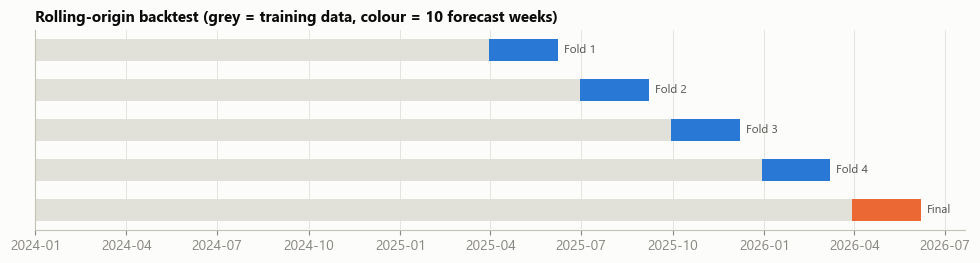

In [95]:
import matplotlib.dates as mdates
fig, ax = plt.subplots(figsize=(12, 2.6))
first = cal.date.min()
spans = [(f"Fold {i+1}", o) for i, o in enumerate(BACKTEST_ORIGINS)] + [("Final", FORECAST_START)]
for i, (lab, o) in enumerate(spans):
    start = wk_start[o]; end = wk_start[weeks_of(cal, o, N_WEEKS).yw.iloc[-1]] + pd.Timedelta(days=6)
    ax.barh(i, (start - first).days, left=mdates.date2num(first), color=GRID, height=0.55)
    ax.barh(i, (end - start).days, left=mdates.date2num(start), color=BLUE if lab != "Final" else ORANGE, height=0.55)
    ax.text(mdates.date2num(end + pd.Timedelta(days=6)), i, lab, va="center", fontsize=8.5, color=INK2)
ax.xaxis_date(); ax.set_yticks([]); ax.invert_yaxis(); ax.grid(axis="y", visible=False)
ax.set_title("Rolling-origin backtest (grey = training data, colour = 10 forecast weeks)")
save(fig, "backtest_design"); plt.show()

## 15. Model comparison

In [96]:
models = {
    "Seasonal naive": SeasonalNaive(),
    "Moving average (8 wk)": MovingAverage(),
    "Top-down weekly GLM": WeeklyGLM(),
    "Bottom-up LightGBM": DetrendedLGBM(),
    "Bottom-up GLM": DemandGLM(),
    "Hybrid GLM + LightGBM": GLMBoost(),
    "Blend 0.5 GLM + 0.5 Hybrid": Blend([DemandGLM(), GLMBoost()], [0.5, 0.5]),
    "Blend 0.7 GLM + 0.3 LightGBM": Blend([DemandGLM(), DetrendedLGBM()], [0.7, 0.3]),
}
bt_scores, bt_preds = backtest(models, orders, weekly, cal, BACKTEST_ORIGINS, N_WEEKS)
cols = ["total_WAPE%", "total_MAE", "total_RMSE", "total_MAPE%", "total_bias%",
        "chilled_WAPE%", "chilled_MAE", "chilled_RMSE", "chilled_bias%"]
comparison = bt_scores.groupby("model")[cols].mean().sort_values("total_WAPE%")
display(comparison.round(2))
display(bt_scores.pivot_table(index="model", columns="origin", values="total_WAPE%").loc[comparison.index].round(2))

,total_WAPE%,total_MAE,total_RMSE,total_MAPE%,total_bias%,chilled_WAPE%,chilled_MAE,chilled_RMSE,chilled_bias%
model,,,,,,,,,
Hybrid GLM + LightGBM,3.200,9.530,12.940,15.690,-0.530,2.070,5.730,7.660,-0.180
Blend 0.5 GLM + 0.5 Hybrid,3.210,9.560,13.020,15.710,-0.500,2.080,5.770,7.730,-0.160
Bottom-up GLM,3.220,9.600,13.120,15.730,-0.470,2.100,5.820,7.800,-0.130
Blend 0.7 GLM + 0.3 LightGBM,3.240,9.650,13.190,15.700,-0.620,2.230,6.190,8.130,-0.230
Bottom-up LightGBM,3.700,11.010,15.440,16.200,-0.960,2.840,7.870,10.240,-0.480
Top-down weekly GLM,3.930,11.700,16.060,16.210,-0.940,2.420,6.710,9.050,-0.660
Seasonal naive,8.270,24.550,44.770,20.090,-0.780,7.240,20.040,27.970,-0.520
Moving average (8 wk),8.420,24.940,43.900,20.800,-1.910,7.690,21.310,27.620,-1.490


origin,202514,202527,202540,202601
model,,,,
Hybrid GLM + LightGBM,3.390,3.590,2.930,2.880
Blend 0.5 GLM + 0.5 Hybrid,3.420,3.600,2.930,2.880
Bottom-up GLM,3.460,3.610,2.940,2.880
Blend 0.7 GLM + 0.3 LightGBM,3.710,3.510,2.870,2.880
Bottom-up LightGBM,4.400,4.070,3.190,3.140
Top-down weekly GLM,5.100,4.120,3.220,3.290
Seasonal naive,11.680,7.800,8.690,4.920
Moving average (8 wk),14.980,6.440,7.160,5.100


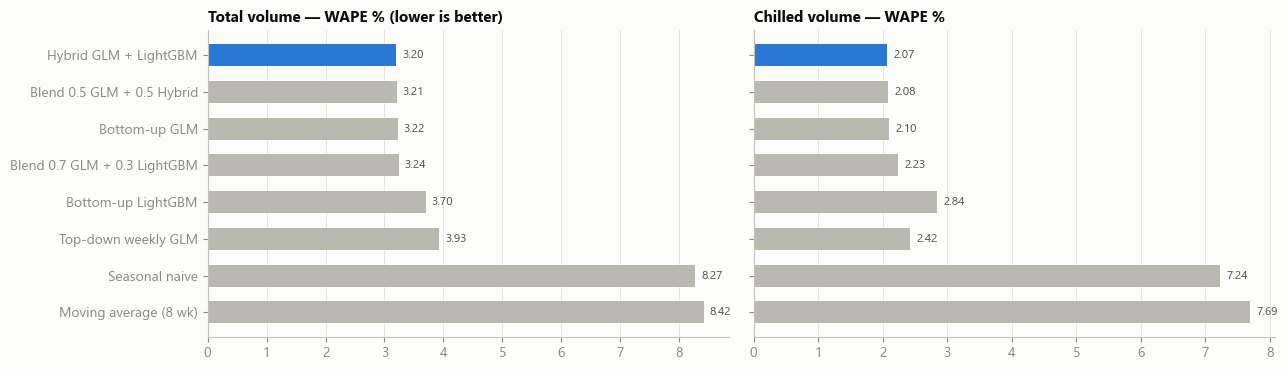

In [97]:
HYBRID = "Hybrid GLM + LightGBM"
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8), sharey=True)
for ax, metric, title in [(axes[0], "total_WAPE%", "Total volume — WAPE % (lower is better)"),
                          (axes[1], "chilled_WAPE%", "Chilled volume — WAPE %")]:
    s = comparison[metric][::-1]
    colors = [BLUE if m == HYBRID else "#b9b8b1" for m in s.index]
    ax.barh(s.index, s.values, color=colors, height=0.6)
    for y, v in enumerate(s.values):
        ax.text(v + 0.1, y, f"{v:.2f}", va="center", fontsize=8.5, color=INK2)
    ax.set_title(title); ax.grid(axis="y", visible=False)
fig.tight_layout(); save(fig, "model_comparison"); plt.show()

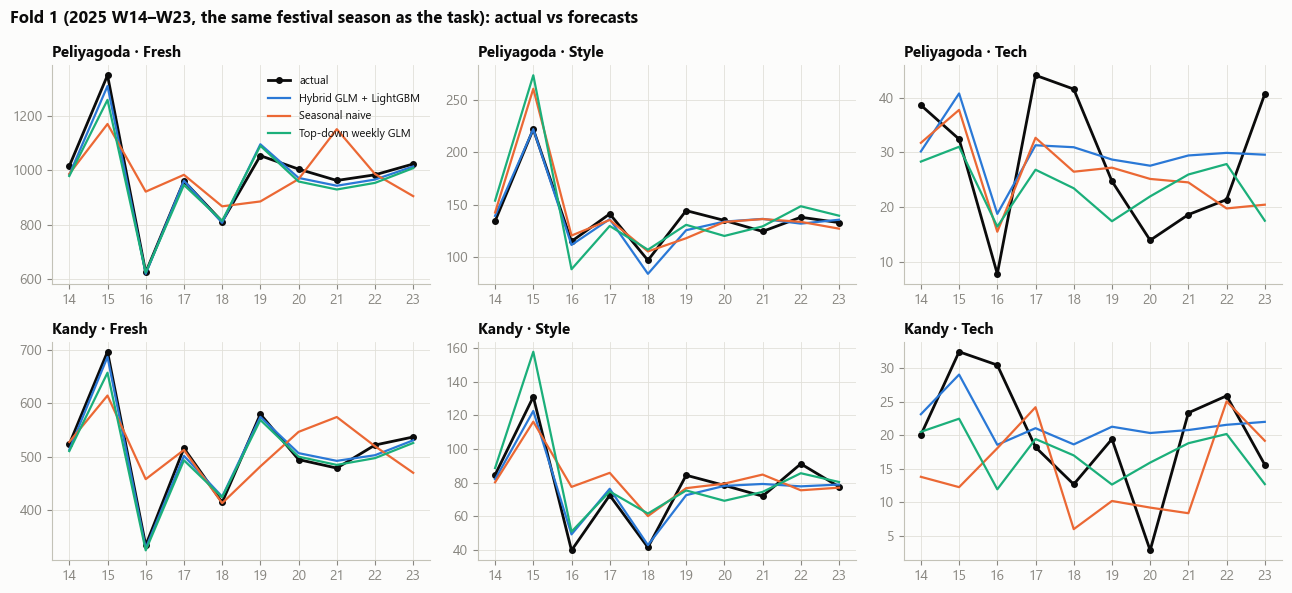

In [98]:
fold1 = bt_preds[(bt_preds.origin == 202514) & bt_preds.model.isin([HYBRID, "Seasonal naive", "Top-down weekly GLM"])]
fold1 = fold1.merge(weekly, on=KEYS)
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for ax, (dep, b) in zip(axes.ravel(), [(d, b) for d in ["Peliyagoda", "Kandy"] for b in ["Fresh", "Style", "Tech"]]):
    s = fold1[(fold1.depot == dep) & (fold1.brand == b)]
    a = s[s.model == HYBRID]
    ax.plot(a.iso_week, a.total_m3, color=INK, marker="o", markersize=4, label="actual")
    for m, c in [(HYBRID, BLUE), ("Seasonal naive", ORANGE), ("Top-down weekly GLM", AQUA)]:
        x = s[s.model == m]
        ax.plot(x.iso_week, x.pred_total_volume_m3, color=c, linewidth=1.6, label=m)
    ax.set_title(f"{dep} · {b}"); ax.set_xticks(range(14, 24))
axes[0, 0].legend(fontsize=8, loc="upper right")
fig.suptitle("Fold 1 (2025 W14–W23, the same festival season as the task): actual vs forecasts",
             x=0.01, ha="left", fontweight="bold")
fig.tight_layout(); save(fig, "fold1_forecasts"); plt.show()

**Reading the comparison**

* Both bottom-up structural models cut the error of the classic baselines by more than half. The baselines miss the
  shifted festival weeks badly (see the New Year week 15/16 in fold 1).
* The top-down weekly GLM is decent overall but weaker on the festival fold, where it has only two examples of
  each festival at weekly resolution.
* Pure LightGBM trails the GLM. Trees cannot extrapolate growth and need many rows to learn each festival curve.
* The **hybrid** has the lowest average error and is clearly best on fold 1, the festival season that matches the task
  (3.39% vs 3.46% for the plain GLM). On the other folds every structural variant is within about 0.1 pp. Blends add
  nothing on average, so we keep the hybrid on its own.
* Overall the hybrid cuts total-volume error by **61%** vs the seasonal-naive baseline (8.27% → 3.20% WAPE) and chilled
  error by **71%** (7.24% → 2.07%).

### 15.1 Accuracy-style view

Accuracy, recall and F1 are classification metrics, and Task 2A predicts a continuous volume, so WAPE / MAE / RMSE stay
the primary metrics. The same backtest can still be expressed in familiar terms:
* **Forecast accuracy** = 100 − WAPE (the usual supply-chain convention), and **R² within series**, the share of the
  week-to-week variation the forecast explains.
* **Hit rates**: share of weeks forecast within ±5% / ±10% of actual.
* **Peak / low week detection** (precision, recall, F1): did the forecast flag the weeks that ended up ≥15% above or
  below the series' normal level (median of the 13 weeks before the forecast start)? Tech is excluded here because
  its weekly volume is mostly random ordering, so ±15% swings happen by chance.

In [99]:
def accuracy_view(bt_preds, weekly, origins, band=0.15, brands_for_events=("Fresh", "Style")):
    """Translate forecast errors into familiar terms.

    * forecast accuracy = 100 - WAPE; R2 within series (week-to-week variation explained)
    * hit rates: share of weeks within +-5% / +-10% of actual
    * peak / low week detection: a week is 'peak' ('low') when it is >= band above
      (below) the series' normal level (median of the 13 weeks before the origin);
      precision / recall / F1 of the forecast flagging those weeks. Tech is left out of
      event detection because its weekly volume is mostly random ordering.
    """
    w = weekly.assign(yw=weekly.iso_year * 100 + weekly.iso_week)
    normal = pd.concat([
        w[w.yw < o].sort_values("yw").groupby(["depot", "brand"]).tail(13)
         .groupby(["depot", "brand"]).total_m3.median().rename("normal").reset_index().assign(origin=o)
        for o in origins])
    m = bt_preds.merge(w, on=KEYS).merge(normal, on=["depot", "brand", "origin"])

    def prf(y, p):
        tp, fp, fn = (y & p).sum(), (~y & p).sum(), (y & ~p).sum()
        pr = tp / (tp + fp) if tp + fp else np.nan
        rc = tp / (tp + fn) if tp + fn else np.nan
        return pr, rc, (2 * pr * rc / (pr + rc) if pr + rc else np.nan)

    rows = {}
    for model, g in m.groupby("model"):
        a, f = g.total_m3, g.pred_total_volume_m3
        e = f - a
        ape = e.abs() / a
        dev = a - g.groupby(["depot", "brand", "origin"]).total_m3.transform("mean")
        ev = g[g.brand.isin(brands_for_events)]
        ap, fp_ = ev.total_m3 >= (1 + band) * ev.normal, ev.pred_total_volume_m3 >= (1 + band) * ev.normal
        al, fl = ev.total_m3 <= (1 - band) * ev.normal, ev.pred_total_volume_m3 <= (1 - band) * ev.normal
        cls_a = np.select([ap, al], ["peak", "low"], "normal")
        cls_f = np.select([fp_, fl], ["peak", "low"], "normal")
        pk, lw = prf(ap, fp_), prf(al, fl)
        rows[model] = {
            "forecast accuracy % (100 - WAPE)": 100 - 100 * e.abs().sum() / a.sum(),
            "R2 within series": 1 - (e ** 2).sum() / (dev ** 2).sum(),
            "weeks within +-5%": ape.le(0.05).mean(),
            "weeks within +-10%": ape.le(0.10).mean(),
            "peak-week precision": pk[0], "peak-week recall": pk[1], "peak-week F1": pk[2],
            "low-week precision": lw[0], "low-week recall": lw[1], "low-week F1": lw[2],
            "week-type accuracy (peak/normal/low)": (cls_a == cls_f).mean(),
        }
    return pd.DataFrame(rows)

In [100]:
acc = accuracy_view(bt_preds[bt_preds.model.isin([HYBRID, "Bottom-up GLM", "Top-down weekly GLM", "Bottom-up LightGBM",
                                                  "Seasonal naive", "Moving average (8 wk)"])],
                    weekly, BACKTEST_ORIGINS)
display(acc[[HYBRID, "Bottom-up GLM", "Bottom-up LightGBM", "Top-down weekly GLM", "Seasonal naive",
             "Moving average (8 wk)"]].round(3))
fb = bt_preds[bt_preds.model == HYBRID].merge(weekly, on=KEYS)
ape = (fb.pred_total_volume_m3 - fb.total_m3).abs() / fb.total_m3
display(pd.DataFrame({"weeks within +-5%": ape.le(.05).groupby(fb.brand).mean(),
                      "weeks within +-10%": ape.le(.10).groupby(fb.brand).mean()}).round(3))

,Hybrid GLM + LightGBM,Bottom-up GLM,Bottom-up LightGBM,Top-down weekly GLM,Seasonal naive,Moving average (8 wk)
forecast accuracy % (100 - WAPE),96.802,96.778,96.305,96.074,91.760,91.629
R2 within series,0.927,0.925,0.893,0.884,0.031,-0.086
weeks within +-5%,0.479,0.483,0.488,0.458,0.342,0.325
weeks within +-10%,0.658,0.646,0.604,0.588,0.521,0.542
peak-week precision,0.933,0.933,0.857,0.769,0.533,NaN
peak-week recall,0.933,0.933,0.800,0.667,0.533,0.000
peak-week F1,0.933,0.933,0.828,0.714,0.533,NaN
low-week precision,1.000,1.000,1.000,1.000,0.750,NaN
low-week recall,0.750,0.750,0.750,0.750,0.375,0.000
low-week F1,0.857,0.857,0.857,0.857,0.500,NaN


,weeks within +-5%,weeks within +-10%
brand,,
Fresh,0.975,1.000
Style,0.425,0.762
Tech,0.038,0.212


**Reading the accuracy view.**
* The hybrid reaches **96.8% forecast accuracy** and explains **93% of the week-to-week variation** (R² 0.93). The
  baselines explain essentially none of it (R² 0.03 and −0.09): they get the level right but not the ups and downs.
* **Peak weeks** (Fresh + Style): precision 0.93, recall 0.93, **F1 0.93** (seasonal naive 0.53). **Low weeks**:
  precision 1.00, recall 0.75, **F1 0.86** (0.50). Overall the week type (peak / normal / low) is right **97.5%** of the
  time (87.5% for seasonal naive).
* Hit rates are driven by brand size: **Fresh is within ±5% in 97.5% of weeks and within ±10% in 100%**. Style is within
  ±10% in 76% of weeks. Tech's random ordering keeps it within ±10% only 21% of the time, which is why WAPE (dominated by
  the big Fresh volumes) is the fairer headline.

## 16. Ablation study: does every component earn its place?

Each row removes **one** component from the bottom-up GLM and re-runs the full 4-fold backtest.

,total_WAPE%,total_RMSE,chilled_WAPE%,Δ total WAPE (pp),Δ chilled WAPE (pp),fold-1 WAPE (festival season)
model,,,,,,
− growth trend,6.560,29.710,5.600,3.340,3.500,6.220
− festival-specific ramp (one shared curve),4.520,23.310,3.480,1.300,1.380,5.770
− payday window (payday day only),4.030,16.970,2.880,0.810,0.780,3.960
− annual seasonality,3.700,15.190,4.040,0.480,1.930,3.850
− Style seasonal weeks,3.400,14.540,2.100,0.180,0.000,3.380
Gamma loss instead of Poisson,3.360,13.690,2.190,0.130,0.090,3.620
− recency weighting (equal weights),3.250,13.230,2.140,0.030,0.040,3.510
Full GLM,3.220,13.120,2.100,0.000,0.000,3.460
− post-festival dip,3.220,13.080,2.090,-0.010,-0.010,3.500


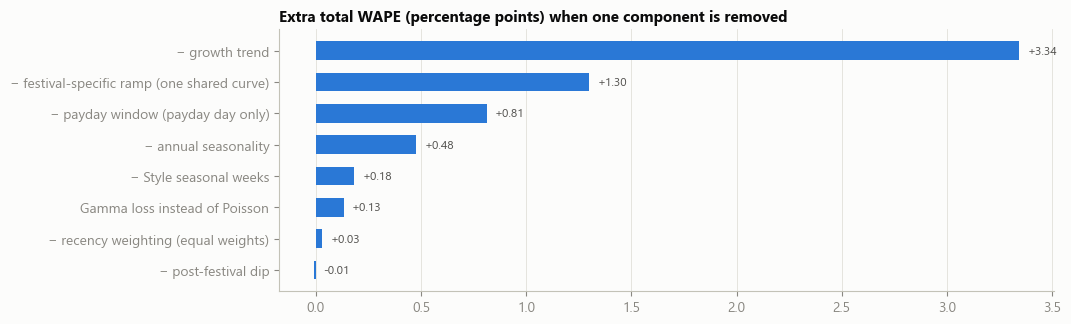

In [101]:
ablations = {
    "Full GLM": DemandGLM(),
    "− growth trend": DemandGLM(trend=False),
    "− festival-specific ramp (one shared curve)": DemandGLM(festival_specific=False),
    "− payday window (payday day only)": DemandGLM(payday_days=1),
    "− annual seasonality": DemandGLM(n_fourier=0),
    "− Style seasonal weeks": DemandGLM(style_weeks=False),
    "− post-festival dip": DemandGLM(post_festival=False),
    "Gamma loss instead of Poisson": DemandGLM(power=2),
    "− recency weighting (equal weights)": DemandGLM(halflife=None),
}
abl_scores, _ = backtest(ablations, orders, weekly, cal, BACKTEST_ORIGINS, N_WEEKS)
abl = abl_scores.groupby("model")[["total_WAPE%", "total_RMSE", "chilled_WAPE%"]].mean()
abl["Δ total WAPE (pp)"] = abl["total_WAPE%"] - abl.loc["Full GLM", "total_WAPE%"]
abl["Δ chilled WAPE (pp)"] = abl["chilled_WAPE%"] - abl.loc["Full GLM", "chilled_WAPE%"]
abl["fold-1 WAPE (festival season)"] = abl_scores[abl_scores.origin == 202514].set_index("model")["total_WAPE%"]
abl = abl.sort_values("Δ total WAPE (pp)", ascending=False)
display(abl.round(2))

s = abl.drop("Full GLM")["Δ total WAPE (pp)"][::-1]
fig, ax = plt.subplots(figsize=(10, 3.4))
ax.barh(s.index, s.values, color=BLUE, height=0.6)
for y, v in enumerate(s.values):
    ax.text(v + 0.04, y, f"+{v:.2f}" if v >= 0 else f"{v:.2f}", va="center", fontsize=8.5, color=INK2)
ax.set_title("Extra total WAPE (percentage points) when one component is removed"); ax.grid(axis="y", visible=False)
save(fig, "ablation"); plt.show()

Every engineered component reduces error, in this order: growth trend, festival-specific ramp, payday window, annual
seasonality, Style seasonal weeks, Poisson loss. Without seasonality, chilled error nearly doubles. The post-festival
term is neutral on average, as the adjusted EDA predicted (§11.6). It slightly helps the festival-season fold
(3.46% vs 3.50%), so it stays as a harmless refinement. Recency weighting adds a small, consistent gain (0.03 pp).

## 17. Hyper-parameter check for the hybrid

In [102]:
grid = {
    "half-life 365 d · 300 trees · 15 leaves (chosen)": GLMBoost(),
    "no recency weighting": GLMBoost(halflife=None),
    "half-life 180 d": GLMBoost(halflife=180),
    "half-life 540 d": GLMBoost(halflife=540),
    "600 trees": GLMBoost(n_estimators=600),
    "31 leaves · min_child 100": GLMBoost(num_leaves=31, min_child_samples=100),
}
grid_scores, _ = backtest(grid, orders, weekly, cal, BACKTEST_ORIGINS, N_WEEKS)
display(grid_scores.groupby("model")[["total_WAPE%", "total_RMSE", "chilled_WAPE%"]].mean()
        .sort_values("total_WAPE%").round(3))

,total_WAPE%,total_RMSE,chilled_WAPE%
model,,,
half-life 180 d,3.183,12.859,2.047
half-life 365 d · 300 trees · 15 leaves (chosen),3.199,12.938,2.070
600 trees,3.202,12.932,2.055
half-life 540 d,3.203,12.974,2.082
31 leaves · min_child 100,3.205,12.952,2.068
no recency weighting,3.215,13.038,2.102


All settings fall within about ±0.03 pp of each other, so the hybrid is not sensitive to its settings. Recency
weighting is the one change that helps consistently: every half-life beats equal weights. A 180-day half-life scores
0.02 pp better than one year, but that's inside fold-to-fold noise, so we keep the round **one-year half-life**. It keeps
more of the festival history at meaningful weight, and we avoid picking the grid's lucky winner on just four folds.

## 18. Benchmark of all approaches on 49 rolling origins

Two families were designed independently (§13), so this is the place to find out which one to trust, brand by brand.
Every model forecasts 10 weeks ahead from every one of 49 origins, using only data up to that origin, and all are scored
with the same function on the same 2,940 series-weeks. The recursive lag GBM from the third workstream is included.
`weekly` and `P` come from §10 and §12.3.

In [103]:
SPIKE_WEEKS = sorted(STYLE_EVENT_WEEKS)

KEYS = ["depot", "brand", "iso_year", "iso_week"]

BK = ["origin_idx"] + KEYS

COMPOSITE = "FINAL (per-brand composite)"

def week_ids(cal):
    """ISO weeks of the calendar in time order: position = the structural model's week_idx."""
    return list((cal.iso_year * 100 + cal.iso_week).drop_duplicates())

def teammate_final(df):
    """The structural family's own per-brand choice (Fresh/Style: structural + growth, Tech: global LightGBM)."""
    return np.where(df.brand == "Tech", df.LGBM, df.STRUCT_G)

def _benchmark_origin(o, start, orders, weekly, cal, P, feat, hybrid, lag_model):
    """All competing forecasts made at one origin (runs in its own worker process)."""
    out = []
    X, _, _ = forecast_origin(P, feat, o)            # structural family: baselines, structural, + growth, global LightGBM
    X["TEAM_FINAL"] = teammate_final(X)
    for m in ["B1_SEASONAL", "B2_RECENT", "STRUCT", "STRUCT_G", "LGBM", "TEAM_FINAL"]:
        sh = X.share_recent6 if m == "B2_RECENT" else X["share"]
        t = X[BK].copy()
        t["model"], t["pred_total"] = m, X[m].to_numpy()
        t["pred_chilled"] = np.where(t.brand == "Fresh", t.pred_total * sh.to_numpy(), 0.0)
        out.append(t.dropna(subset=["pred_total"]))
    for name, mdl in [("Hybrid", hybrid), ("Recursive lag GBM", lag_model)]:   # bottom-up hybrid and lag baseline
        if mdl is None:
            continue
        p = mdl.forecast(orders, weekly, cal, start, 10)
        p = p.rename(columns={"pred_total_volume_m3": "pred_total", "pred_chilled_volume_m3": "pred_chilled"})
        out.append(p.assign(origin_idx=o, model=name)[BK + ["model", "pred_total", "pred_chilled"]])
    return pd.concat(out, ignore_index=True)

def rolling_benchmark(orders, weekly, cal, P, feat, origins, hybrid, lag_model=None, verbose=True, n_jobs=6):
    """Forecast 10 weeks from every origin with all competing models. Long table, one row per
    origin x series-week x model, with actuals. `origins` are structural week indices (forecast starts the next week).
    Origins are independent, so they run in parallel on n_jobs CPU processes."""
    from joblib import Parallel, delayed, parallel_config
    yws = week_ids(cal)
    act = weekly.rename(columns={"total_m3": "y_total", "chilled_m3": "y_chilled"})[KEYS + ["y_total", "y_chilled"]]
    with parallel_config(backend="loky", inner_max_num_threads=1):
        out = Parallel(n_jobs=n_jobs, verbose=5 if verbose else 0)(
            delayed(_benchmark_origin)(o, yws[o + 1], orders, weekly, cal, P, feat, hybrid, lag_model) for o in origins)
    long = pd.concat(out, ignore_index=True)
    long[["iso_year", "iso_week"]] = long[["iso_year", "iso_week"]].astype(int)
    return long.merge(act, on=KEYS, how="left")

def compose(long, hybrid="Hybrid", struct="STRUCT_G"):
    """Apply the final per-brand rule to a benchmark table and return it as a new model, FINAL."""
    h = long[long.model == hybrid].set_index(BK)
    s = long[long.model == struct].set_index(BK).reindex(h.index)
    use_struct = ((h.index.get_level_values("brand") == "Style")
                  & ~h.index.get_level_values("iso_week").isin(SPIKE_WEEKS)) & s.pred_total.notna().to_numpy()
    out = h.copy()
    out.loc[use_struct, "pred_total"] = s.pred_total[use_struct]
    out["model"] = COMPOSITE
    return pd.concat([long, out.reset_index()], ignore_index=True)

def wape(y, p):
    return 100 * np.abs(np.asarray(y) - np.asarray(p)).sum() / np.sum(y) if np.sum(y) else np.nan

def metrics(g):
    """WAPE total / chilled (Fresh) / both, per brand, and bias, for the rows of one model."""
    fr = g[g.brand == "Fresh"]
    both = 100 * (np.abs(g.y_total - g.pred_total).sum() + np.abs(g.y_chilled - g.pred_chilled).sum()) / (
        g.y_total.sum() + g.y_chilled.sum())
    r = {"total WAPE %": wape(g.y_total, g.pred_total), "chilled WAPE %": wape(fr.y_chilled, fr.pred_chilled),
         "both WAPE %": both}
    for b in ["Fresh", "Style", "Tech"]:
        x = g[g.brand == b]
        r[f"{b} %"] = wape(x.y_total, x.pred_total)
    r["bias %"] = 100 * (g.pred_total - g.y_total).sum() / g.y_total.sum()
    return pd.Series(r)

def fit_structural_final(P, feat):
    """Fit the structural model on all history and return its JSON-serialisable description, including each
    series' year-on-year growth factor `yoy8` (so inference needs no order history)."""
    sf = fit_structural(P, P.origin_idx)
    sj = structural_to_dict(P, sf, {"n_lvl": 13, "n_lvl_tech": 26, "fest_agg": "mean",
                                      "tech_dow": "flat", "tech_festival_slope": "pooled"})
    last = feat[feat.origin_idx == P.origin_idx].drop_duplicates("series").set_index("series")
    sj["yoy8"] = {s: float(v) for s, v in last.yoy8.items()}
    return sj

def predict_structural_saved(sj, inputs, cal):
    """Structural + growth forecast (STRUCT_G) of every test row, from the saved JSON and the calendar only."""
    c = cal[["date", "dow", "iso_year", "iso_week", "is_payday", "festival", "festival_ramp",
             "is_operating"]].copy()
    c["festival"] = c.festival.fillna("")
    c = c.sort_values("date").reset_index(drop=True)
    yws = week_ids(cal)
    wk_idx = {w: i for i, w in enumerate(yws)}
    fest = c[c.festival != ""][["date", "festival"]].reset_index(drop=True)
    w = inputs[["iso_year", "iso_week"]].drop_duplicates()
    days = c.merge(w, on=["iso_year", "iso_week"])
    pos = np.minimum(np.searchsorted(fest.date.to_numpy(), days.date.to_numpy()), len(fest) - 1)
    days["ramp_fest"] = np.where(days.festival_ramp > 0, fest.festival.to_numpy()[pos], "")
    days = days[days.is_operating == 1]
    series = inputs[["depot", "brand"]].drop_duplicates().assign(series=lambda d: d.depot + "-" + d.brand)
    days = days.merge(series, how="cross")
    f = days.apply(lambda r: sj["dow_factor"][r.series].get(str(r.dow), 0.0), axis=1)
    p = days.brand.map(sj["payday_uplift"])
    b = [sj["festival_slope_pooled"][br] if (br in sj["pooled_slope_brands"]
                                             or fz not in sj["festival_slope"].get(br, {}))
         else sj["festival_slope"][br][fz] for br, fz in zip(days.brand, days.ramp_fest)]
    days["pred_day"] = (days.series.map(sj["level_L"]) * f * (1 + p * days.is_payday)
                        * (1 + np.array(b) * days.festival_ramp))
    wkly = days.groupby(["series", "iso_year", "iso_week"]).pred_day.sum().rename("STRUCT").reset_index()
    X = inputs.assign(series=inputs.depot + "-" + inputs.brand).merge(
        wkly, on=["series", "iso_year", "iso_week"], how="left")
    X["h"] = [wk_idx[y * 100 + k] - sj["origin"]["week_idx"] for y, k in zip(X.iso_year, X.iso_week)]
    g = sj["growth"]
    yoy = X.series.map(sj["yoy8"]).fillna(1.0)
    X["STRUCT_G"] = X.STRUCT * np.where(X.brand.isin(g["brands"]), yoy ** ((X.h + g["lag_weeks"]) / 52), 1.0)
    return X[["row_id", "STRUCT", "STRUCT_G", "h"]]

def final_forecast(bundle, sj, inputs, cal):
    """Final per-brand forecast with P10-P90 ranges, from the two saved models (hybrid bundle + structural JSON)."""
    weeks = inputs[["iso_year", "iso_week"]].drop_duplicates()
    weeks = weeks.assign(yw=weeks.iso_year * 100 + weeks.iso_week)
    start, end = week_bounds(cal, weeks)
    slots = build_slots(bundle["order_probs"], cal, start, end)
    pred = aggregate_weekly(slots, bundle["model"].predict(slots))
    out = inputs.merge(pred, on=KEYS, how="left", validate="one_to_one")
    out = out.merge(predict_structural_saved(sj, inputs, cal), on="row_id", how="left")
    out["source_model"] = np.where(out.brand == "Style", "structural daily", "hybrid")
    use_hybrid = (out.brand != "Style") | out.iso_week.isin(SPIKE_WEEKS)
    out.loc[use_hybrid, "source_model"] = "hybrid"
    out["pred_total_volume_m3"] = np.where(use_hybrid, out.pred_total_volume_m3, out.STRUCT_G)
    out.loc[out.brand != "Fresh", "pred_chilled_volume_m3"] = 0.0
    out = add_intervals(out.drop(columns=["STRUCT", "STRUCT_G", "h"]), bundle["interval_ratios"])
    return out

In [104]:
ORIGINS = list(range(58, P.origin_idx - N_WEEKS + 1))      # forecasts made at the end of 2025 W07 ... 2026 W03
FOLDS = {"F1 (2025 W14-23)": 64, "F3 (2025 W27-36)": 77, "F4 (2025 W40-49)": 90, "F5 (2026 W01-10)": 103}
assert [week_ids(cal)[o] for o in FOLDS.values()] == [202513, 202526, 202539, 202552]    # the folds of §14

bench = rolling_benchmark(orders, weekly, cal, P, feat, ORIGINS, hybrid=GLMBoost(), lag_model=RecursiveLagGBM())
bench = compose(bench)
LABEL = {"B1_SEASONAL": "Seasonal naive (clean-week growth)", "B2_RECENT": "Recent-mean naive (clean weeks)", "Recursive lag GBM": "Recursive lag GBM",
         "STRUCT": "Structural daily", "STRUCT_G": "Structural daily + growth", "LGBM": "Global LightGBM (ratio)",
         "TEAM_FINAL": "Structural family, own per-brand pick", "Hybrid": "Bottom-up hybrid", COMPOSITE: COMPOSITE}
print(f"{len(bench):,} forecast rows: {bench.model.nunique()} models x {len(ORIGINS)} origins")

[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.


[Parallel(n_jobs=6)]: Done   6 tasks      | elapsed:    9.8s


[Parallel(n_jobs=6)]: Done  49 out of  49 | elapsed:  1.2min finished


26,460 forecast rows: 9 models x 49 origins


### 18.1 All 49 origins

In [105]:
full = bench[bench.origin_idx.isin(ORIGINS)]
assert (full.groupby("model").size() == 60 * len(ORIGINS)).all(), "every model must cover every origin"
all_tab = full.groupby("model").apply(metrics).rename(index=LABEL).sort_values("both WAPE %")
display(all_tab.round(2))

,total WAPE %,chilled WAPE %,both WAPE %,Fresh %,Style %,Tech %,bias %
model,,,,,,,
FINAL (per-brand composite),3.120,2.070,2.870,1.910,5.440,27.390,-0.480
Bottom-up hybrid,3.300,2.070,3.010,1.910,6.890,27.390,-0.580
"Structural family, own per-brand pick",4.570,3.440,4.300,3.340,6.860,29.670,-0.580
Structural daily + growth,4.630,3.440,4.350,3.340,6.860,31.710,-0.740
Structural daily,4.730,3.610,4.470,3.450,6.900,31.710,-1.900
Global LightGBM (ratio),5.420,4.130,5.120,3.960,9.460,29.670,-0.320
Recursive lag GBM,7.280,6.180,7.020,5.690,12.010,32.280,-1.930
Recent-mean naive (clean weeks),7.640,6.830,7.450,6.400,10.170,32.040,-4.940
Seasonal naive (clean-week growth),7.720,6.650,7.470,6.400,9.730,36.560,0.010


,F1 (2025 W14-23),F3 (2025 W27-36),F4 (2025 W40-49),F5 (2026 W01-10),4-fold mean
FINAL (per-brand composite),3.280,3.480,2.610,2.920,3.070
Bottom-up hybrid,3.390,3.590,2.930,2.880,3.200
"Structural family, own per-brand pick",3.710,5.330,5.010,4.710,4.690
Structural daily + growth,3.810,5.290,4.960,4.810,4.720
Structural daily,4.290,5.790,4.390,4.800,4.820
Global LightGBM (ratio),8.640,4.870,5.240,5.080,5.960
Recursive lag GBM,13.890,7.190,5.250,4.370,7.670
Recent-mean naive (clean weeks),11.280,7.800,6.750,6.130,7.990
Seasonal naive (clean-week growth),11.790,7.750,8.610,5.040,8.300


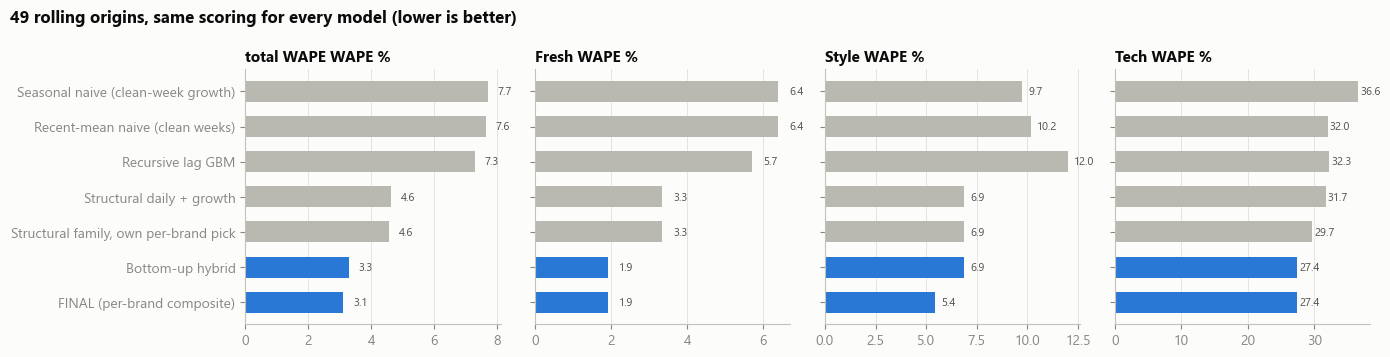

In [106]:
fold_tab = pd.DataFrame({LABEL[m]: {f: metrics(bench[(bench.model == m) & (bench.origin_idx == o)])["total WAPE %"]
                                    for f, o in FOLDS.items()} for m in bench.model.unique()}).T
fold_tab["4-fold mean"] = fold_tab.mean(axis=1)
display(fold_tab.sort_values("4-fold mean").round(2))

top = ["Seasonal naive (clean-week growth)", "Recent-mean naive (clean weeks)", "Recursive lag GBM", "Structural daily + growth",
       "Structural family, own per-brand pick", "Bottom-up hybrid", COMPOSITE]
fig, axes = plt.subplots(1, 4, figsize=(14, 3.6), sharey=True)
for ax, col in zip(axes, ["total WAPE %", "Fresh %", "Style %", "Tech %"]):
    v = all_tab.loc[top, col][::-1]
    ax.barh(v.index, v.values, color=[BLUE if m in (COMPOSITE, "Bottom-up hybrid") else "#b9b8b1" for m in v.index], height=0.6)
    for y_, x_ in enumerate(v.values):
        ax.text(x_ + 0.3, y_, f"{x_:.1f}", va="center", fontsize=8, color=INK2)
    ax.set_title(col.replace(" %", "") + " WAPE %"); ax.grid(axis="y", visible=False)
fig.suptitle("49 rolling origins, same scoring for every model (lower is better)", x=0.01, ha="left", fontweight="bold")
fig.tight_layout(); save(fig, "benchmark_49_origins"); plt.show()

**Reading the benchmark**

* **Fresh** (about 85% of the volume): the bottom-up hybrid is far ahead of everything else. Modelling each order slot
  by outlet, trend, weekday, payday window and festival ramp beats modelling the weekly series, however carefully the
  latter is built.
* **The recursive lag GBM** lands with the naive baselines. For a 10-week horizon it never sees its own target's recent
  past, only its own earlier forecasts.
* **Style** and **Tech** are close between the two serious families. The next tables look at them separately.

### 18.2 Style: the right test excludes the recurring spike weeks

In [107]:
sty = bench[(bench.brand == "Style") & bench.model.isin(["Hybrid", "STRUCT_G"])].pivot_table(
    index=BK, columns="model", values=["pred_total", "y_total"]).dropna()
sty.columns = ["_".join(c) for c in sty.columns]
sty = sty.reset_index()
sty["spike"] = sty.iso_week.isin(SPIKE_WEEKS)
tests = {"all target weeks": sty.index == sty.index,
         "outside spike weeks (ISO 10, 32)": ~sty.spike,
         "spike weeks only": sty.spike,
         "2025 W14-23 (fold F1 window)": (sty.origin_idx == 64),
         "ISO weeks 14-23, all years": sty.iso_week.between(14, 23) & ~sty.spike}
rows = {}
for w_ in np.round(np.arange(0, 1.01, 0.2), 1):                 # weight on the structural model
    z = w_ * sty.pred_total_STRUCT_G + (1 - w_) * sty.pred_total_Hybrid
    rows[f"{w_:.1f} structural + {1 - w_:.1f} hybrid"] = {k: wape(sty.y_total_Hybrid[m], z[m]) for k, m in tests.items()}
display(pd.DataFrame(rows).T.round(2))
for d_ in ["Kandy", "Peliyagoda"]:
    g = sty[(sty.depot == d_) & ~sty.spike]
    print(f"{d_:<11} Style outside spike weeks: hybrid {wape(g.y_total_Hybrid, g.pred_total_Hybrid):.2f}%  "
          f"structural + growth {wape(g.y_total_Hybrid, g.pred_total_STRUCT_G):.2f}%")
print(f"origins in which the structural model beats the hybrid on Style outside spike weeks: "
      f"{int((sty[~sty.spike].groupby('origin_idx').apply(lambda g: np.abs(g.y_total_Hybrid - g.pred_total_STRUCT_G).sum() < np.abs(g.y_total_Hybrid - g.pred_total_Hybrid).sum())).sum())} of {sty.origin_idx.nunique()}")

,all target weeks,"outside spike weeks (ISO 10, 32)",spike weeks only,2025 W14-23 (fold F1 window),"ISO weeks 14-23, all years"
0.0 structural + 1.0 hybrid,6.890,6.960,5.580,5.870,6.270
0.2 structural + 0.8 hybrid,6.460,6.480,6.110,5.580,5.990
0.4 structural + 0.6 hybrid,6.390,6.040,12.500,5.310,5.720
0.6 structural + 0.4 hybrid,6.420,5.710,19.050,5.170,5.530
0.8 structural + 0.2 hybrid,6.580,5.510,25.610,5.050,5.390
1.0 structural + 0.0 hybrid,6.860,5.430,32.170,4.960,5.280


Kandy       Style outside spike weeks: hybrid 8.10%  structural + growth 7.11%
Peliyagoda  Style outside spike weeks: hybrid 6.32%  structural + growth 4.49%
origins in which the structural model beats the hybrid on Style outside spike weeks: 44 of 49


**Decision for Style.** Outside the two spike weeks, which is the whole forecast window, the structural daily model
beats the hybrid at every blend weight tested, in both depots, and on the 2025 festival-season fold. Its design fits
Style's mechanics (one order per scheduled outlet per week, an exactly known number of scheduled open days). The hybrid
wins only in the spike weeks, because it has learned them from the previous year's same ISO week. So the final rule is:
**Style uses the structural daily model, except in ISO weeks 10 and 32, where it uses the hybrid.** Those two weeks are
not in this forecast window; the rule keeps the model correct if it is re-run for other weeks.

### 18.3 Fresh and Tech: nothing to borrow

In [108]:
ctx = feat[BK + ["h", "ramp_sum_operating", "n_operating_days", "yoy8", "share_ly_target", "share_recent6"]].drop_duplicates(BK)
hy = full[full.model == "Hybrid"].merge(ctx, on=BK, how="left")
sg = full[full.model == "STRUCT_G"].merge(ctx, on=BK, how="left")
# (a) blend weights, Fresh and Tech
rows = {}
mm = hy.merge(sg[BK + ["pred_total"]], on=BK, suffixes=("", "_s"))
for w_ in np.round(np.arange(0, 1.01, 0.25), 2):
    z = w_ * mm.pred_total_s + (1 - w_) * mm.pred_total
    rows[f"{w_:.2f} structural + {1 - w_:.2f} hybrid"] = {b: wape(g.y_total, z[g.index]) for b, g in mm.groupby("brand")}
print("WAPE % by brand when blending the two families (all target weeks):")
display(pd.DataFrame(rows).T.round(2))
# (b) chilled: own chilled orders vs total x last year's share
fr = hy[hy.brand == "Fresh"]
chil = pd.Series({
    "hybrid: its own chilled order slots": wape(fr.y_chilled, fr.pred_chilled),
    "hybrid total x last year's chilled share": wape(fr.y_chilled, fr.pred_total * fr.share_ly_target.fillna(fr.share_recent6)),
    "hybrid total x recent 6-week chilled share": wape(fr.y_chilled, fr.pred_total * fr.share_recent6)}, name="chilled WAPE %")
display(chil.to_frame().round(2))
# (c) does the structural family's growth correction help the hybrid?
g_ = np.where(hy.brand == "Tech", 1.0, hy.yoy8.fillna(1.0) ** ((hy.h + 6.5) / 52))
display(pd.DataFrame({"growth exponent": [0, 0.5, 1.0],
                      "hybrid total WAPE %": [wape(hy.y_total, hy.pred_total * g_ ** k) for k in (0, 0.5, 1.0)]}).round(3))
# (d) Tech by depot
tech = full[(full.brand == "Tech") & full.model.isin(["Hybrid", "LGBM", "STRUCT_G", "B2_RECENT"])]
display(tech.groupby(["depot", "model"]).apply(lambda g: pd.Series({
    "WAPE %": wape(g.y_total, g.pred_total), "bias %": 100 * (g.pred_total - g.y_total).sum() / g.y_total.sum()})).round(1).unstack(0))
# (e) by week type
wt = full[full.model.isin(["Hybrid", "STRUCT_G", COMPOSITE])].merge(ctx, on=BK, how="left")
wt["week type"] = np.select([wt.ramp_sum_operating > 0, wt.n_operating_days < 6], ["festival run-up", "short week"], "normal week")
display(wt.groupby(["model", "week type"]).apply(lambda g: wape(g.y_total, g.pred_total)).unstack().rename(index=LABEL).round(2))

WAPE % by brand when blending the two families (all target weeks):


,Fresh,Style,Tech
0.00 structural + 1.00 hybrid,1.910,6.890,27.390
0.25 structural + 0.75 hybrid,2.030,6.440,28.010
0.50 structural + 0.50 hybrid,2.370,6.380,28.990
0.75 structural + 0.25 hybrid,2.800,6.540,30.300
1.00 structural + 0.00 hybrid,3.340,6.860,31.710


,chilled WAPE %
hybrid: its own chilled order slots,2.070
hybrid total x last year's chilled share,2.400
hybrid total x recent 6-week chilled share,2.550


,growth exponent,hybrid total WAPE %
0,0.000,3.297
1,0.500,3.263
2,1.000,3.371


WAPE %            bias %           
depot      Kandy Peliyagoda  Kandy Peliyagoda
model                                        
B2_RECENT 35.200     29.800 -7.000    -13.900
Hybrid    30.500     25.200  0.500     -2.300
LGBM      33.800     26.800  0.500     -8.400
STRUCT_G  34.000     30.100 -4.700    -13.700

week type,festival run-up,normal week,short week
model,,,
FINAL (per-brand composite),3.180,3.060,4.500
Bottom-up hybrid,3.340,3.260,4.280
Structural daily + growth,4.960,4.470,4.380


* **Blending does not help Fresh or Tech.** The error rises as soon as weight moves to the structural model.
* **Chilled:** the hybrid's own chilled order slots beat total × share. Chilled orders follow their own fixed weekday
  schedules, which a share of the total can't see.
* **The growth correction is not needed by the hybrid**: it already carries a trend and recency weights.
* **Tech** is dominated by random "as needed" ordering (see the noise floor in §19). The hybrid is also the least
  biased on both depots, so it keeps Tech.
* **By week type**: the composite is best in normal weeks and festival run-ups, which carry most of the volume. In short
  weeks (closed days) every model is less accurate, and the composite (4.50%) is slightly behind the hybrid alone
  (4.28%) because Style's structural forecast gives up a little there. Short weeks are few, and the gain elsewhere
  outweighs it.

### 18.4 Hyper-parameters of the structural model

The structural model has three real choices: how many clean weeks form the level, whether a festival's slope is the mean
or the latest of its past occurrences, and whether the year-on-year growth correction is applied. Each is tested on the
same 49 origins. Style outside its spike weeks is the metric that matters, since that is where the model is used.

In [109]:
def structural_variant(growth=True, **kw):
    rows = []
    for o in ORIGINS:
        pr = predict_structural(P, fit_structural(P, o, **kw))
        d = feat[feat.origin_idx == o][BK + ["series", "week_idx", "h", "yoy8", "y_total"]].merge(
            pr[["series", "week_idx", "STRUCT"]], on=["series", "week_idx"])
        d["pred"] = d.STRUCT * (np.where(d.brand == "Tech", 1.0, d.yoy8.fillna(1.0) ** ((d.h + 6.5) / 52)) if growth else 1.0)
        rows.append(d)
    d = pd.concat(rows)
    st = d[(d.brand == "Style") & ~d.iso_week.isin(SPIKE_WEEKS)]
    f1 = st[st.origin_idx == 64]
    return {"Style, outside spike weeks": wape(st.y_total, st.pred), "Style, fold F1": wape(f1.y_total, f1.pred),
            "Fresh": wape(d[d.brand == "Fresh"].y_total, d[d.brand == "Fresh"].pred)}

settings = {"13-week level, mean slope, growth (chosen)": dict(n_lvl=13, fest_agg="mean"),
            "8-week level": dict(n_lvl=8, fest_agg="mean"),
            "26-week level": dict(n_lvl=26, fest_agg="mean"),
            "latest festival slope instead of the mean": dict(n_lvl=13, fest_agg="last"),
            "no growth correction": dict(n_lvl=13, fest_agg="mean", growth=False)}
set_tab = pd.DataFrame({k: structural_variant(**v) for k, v in settings.items()}).T
display(set_tab.round(2))

,"Style, outside spike weeks","Style, fold F1",Fresh
"13-week level, mean slope, growth (chosen)",5.430,4.960,3.340
8-week level,5.680,5.110,3.340
26-week level,5.400,5.100,3.570
latest festival slope instead of the mean,5.430,4.960,3.340
no growth correction,5.460,4.950,3.450


In [110]:
best = set_tab["Style, outside spike weeks"].idxmin()
chosen = set_tab.index[0]
print(f"best setting for Style outside the spike weeks: {best} ({set_tab.loc[best, 'Style, outside spike weeks']:.2f}%)")
print(f"chosen setting: {chosen} ({set_tab.loc[chosen, 'Style, outside spike weeks']:.2f}%); "
      f"spread across the five settings: {set_tab['Style, outside spike weeks'].max() - set_tab['Style, outside spike weeks'].min():.2f} pp")

best setting for Style outside the spike weeks: 26-week level (5.40%)
chosen setting: 13-week level, mean slope, growth (chosen) (5.43%); spread across the five settings: 0.28 pp


The chosen setting (first row) is the one used for Style in the final solution; the others show how sensitive the Style
forecast is to each choice. Fresh is not served by this model in the final solution, so its column is for reference.

### 18.5 The final per-brand rule and its score

In [111]:
rule = pd.DataFrame([
    ("Fresh", "bottom-up hybrid", "far ahead of every other model (above)"),
    ("Tech", "bottom-up hybrid", "lowest error and bias on both depots"),
    ("Style, ISO weeks 14-23 and all weeks except 10 and 32", "structural daily + growth", "wins at every blend weight outside the spike weeks"),
    ("Style, ISO weeks 10 and 32", "bottom-up hybrid", "learns the recurring spikes from last year"),
    ("chilled volume (Fresh)", "hybrid's own chilled order slots", "beats total x chilled share"),
    ("chilled volume (Style, Tech)", "0", "the brief: only Fresh has chilled demand")], columns=["series", "model", "why"])
display(rule)
summary = pd.DataFrame({m: metrics(full[full.model == m]) for m in ["Hybrid", "TEAM_FINAL", COMPOSITE]}).T.rename(index=LABEL)
display(summary.round(2))
fin_four = {f: metrics(bench[(bench.model == COMPOSITE) & (bench.origin_idx == o)]) for f, o in FOLDS.items()}
four_pool = metrics(bench[(bench.model == COMPOSITE) & bench.origin_idx.isin(FOLDS.values())])
print(f"composite on the four folds of §14: total WAPE {four_pool['total WAPE %']:.2f}%, chilled WAPE {four_pool['chilled WAPE %']:.2f}%")
base_ = metrics(bench[(bench.model == "B1_SEASONAL") & bench.origin_idx.isin(ORIGINS)])
comp_ = summary.loc[COMPOSITE]
print(f"vs seasonal naive on 49 origins: total WAPE {base_['total WAPE %']:.2f}% -> {comp_['total WAPE %']:.2f}% "
      f"({100 * (1 - comp_['total WAPE %'] / base_['total WAPE %']):.0f}% lower), chilled {base_['chilled WAPE %']:.2f}% -> "
      f"{comp_['chilled WAPE %']:.2f}% ({100 * (1 - comp_['chilled WAPE %'] / base_['chilled WAPE %']):.0f}% lower)")

,series,model,why
0,Fresh,bottom-up hybrid,far ahead of every other model (above)
1,Tech,bottom-up hybrid,lowest error and bias on both depots
2,"Style, ISO weeks 14-23 and all weeks except 10...",structural daily + growth,wins at every blend weight outside the spike w...
3,"Style, ISO weeks 10 and 32",bottom-up hybrid,learns the recurring spikes from last year
4,chilled volume (Fresh),hybrid's own chilled order slots,beats total x chilled share
5,"chilled volume (Style, Tech)",0,the brief: only Fresh has chilled demand


,total WAPE %,chilled WAPE %,both WAPE %,Fresh %,Style %,Tech %,bias %
Bottom-up hybrid,3.300,2.070,3.010,1.910,6.890,27.390,-0.580
"Structural family, own per-brand pick",4.570,3.440,4.300,3.340,6.860,29.670,-0.580
FINAL (per-brand composite),3.120,2.070,2.870,1.910,5.440,27.390,-0.480


composite on the four folds of §14: total WAPE 3.07%, chilled WAPE 2.07%
vs seasonal naive on 49 origins: total WAPE 7.72% -> 3.12% (60% lower), chilled 6.65% -> 2.07% (69% lower)


The per-brand rule has only two candidates per brand and was chosen on one consistent protocol, so it carries little
selection risk. We report it on the same 49 origins as every other model.

## 19. Error analysis

### 19.1 How close are we to the best achievable?
Even a perfect model can't predict the random part of each order. We simulate that **noise floor** by drawing every
order of a forecast window from the fitted model (Gamma noise around the predicted mean, plus Tech's random
ordering) and measuring the MAE a perfect model would still have.

In [112]:
fin_bt = bt_preds[bt_preds.model == HYBRID].merge(weekly, on=KEYS)
fin_bt["err"] = fin_bt.pred_total_volume_m3 - fin_bt.total_m3

ref = DemandGLM().fit(orders, orders.order_volume_m3.values)
cv = (orders.order_volume_m3 / ref.predict(orders)).groupby(orders.brand).std()
s_lo, s_hi = week_bounds(cal, weeks_of(cal, 202514, N_WEEKS))
sim_slots = build_slots(probs_all, cal, s_lo, s_hi)
sim_slots["mu"] = ref.predict(sim_slots)
rng = np.random.default_rng(42)
shape = 1 / cv[sim_slots.brand].values ** 2
sims = []
for _ in range(400):
    vol = rng.gamma(shape, sim_slots.mu.values / shape) * (rng.random(len(sim_slots)) < sim_slots.p_order.values)
    sims.append(sim_slots.assign(v=vol).groupby(["depot", "brand", "yw"]).v.sum())
S = pd.concat(sims, axis=1)
floor = S.sub(S.mean(axis=1), axis=0).abs().mean(axis=1).groupby(level=[0, 1]).mean()

ea = fin_bt.groupby(["brand", "depot"]).agg(avg_weekly_m3=("total_m3", "mean"),
                                            MAE=("err", lambda e: e.abs().mean()),
                                            bias=("err", "mean"))
ea["noise_floor_MAE"] = [floor.loc[(d, b)] for b, d in ea.index]
ea["MAE / floor"] = ea.MAE / ea.noise_floor_MAE
print("per-order noise (CV) around the model:", cv.round(3).to_dict())
display(ea.round(2))

per-order noise (CV) around the model: {'Fresh': 0.152, 'Style': 0.215, 'Tech': 0.307}


avg_weekly_m3    MAE   bias  noise_floor_MAE  MAE / floor
brand depot                                                                
Fresh Kandy             518.890  9.090 -3.700            3.950        2.300
      Peliyagoda        988.570 19.730 -3.600            6.050        3.260
Style Kandy              81.340  6.370  0.870            4.770        1.340
      Peliyagoda        144.780  7.770 -2.020            6.280        1.240
Tech  Kandy              22.610  6.330 -0.170            6.100        1.040
      Peliyagoda         31.560  7.890 -0.790            5.990        1.320

Style and Tech are close to their noise floor: Tech's "as needed" ordering is essentially unpredictable week to week.
Fresh sits above the order-level floor because of short **multi-day demand episodes** (±5% for 3–5 days). We checked:
these are not shared across depots or districts, and they don't line up with paydays, festivals, monsoon or road
disruption, so they can't be forecast 10 weeks ahead.

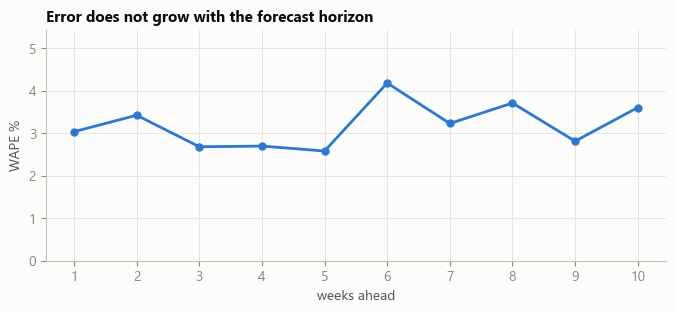

,WAPE %,bias %
origin,,
202514,3.390,-0.920
202527,3.590,-1.180
202540,2.930,-0.580
202601,2.880,0.560


In [113]:
fin_bt = fin_bt.sort_values(["origin", "depot", "brand", "iso_year", "iso_week"])
fin_bt["h"] = fin_bt.groupby(["origin", "depot", "brand"]).cumcount() + 1
by_h = fin_bt.groupby("h").apply(lambda g: 100 * g.err.abs().sum() / g.total_m3.sum())
by_origin = fin_bt.groupby("origin").apply(lambda g: pd.Series({
    "WAPE %": 100 * g.err.abs().sum() / g.total_m3.sum(), "bias %": 100 * g.err.sum() / g.total_m3.sum()}))
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(by_h.index, by_h.values, marker="o", color=BLUE)
ax.set_xticks(range(1, 11)); ax.set_xlabel("weeks ahead"); ax.set_ylabel("WAPE %")
ax.set_ylim(0, by_h.max() * 1.3); ax.set_title("Error does not grow with the forecast horizon")
save(fig, "error_by_horizon"); plt.show()
display(by_origin.round(2))

Error is flat across the 10-week horizon. The forecast depends on the calendar, not on recent values, so it
doesn't decay. Bias changes sign between folds (≤ ±1%), so there is no systematic drift to correct.

## 20. Prediction intervals

Planners need a range, not just one number: refrigerated capacity should cover a busy week, not just an average one.
We build **empirical P10–P90 intervals** from the final (composite) model's backtest: the forecast is multiplied by the
10th and 90th percentiles of *actual ÷ forecast* seen over the 49 origins, per brand and target. Calibration is checked
on each of the four named folds by setting the quantiles only from origins whose forecast windows do not overlap it.

In [114]:
def interval_ratios(bt_preds, weekly, model):
    """actual / forecast ratios from the backtest, per brand and target."""
    m = bt_preds[bt_preds.model == model].merge(weekly, on=KEYS)
    rows = []
    for name, (p, a) in TARGETS.items():
        x = m if name == "total" else m[m.brand == "Fresh"]
        rows.append(pd.DataFrame({"brand": x.brand, "origin": x.origin, "target": name,
                                  "ratio": x[a] / x[p]}))
    return pd.concat(rows, ignore_index=True)


def add_intervals(pred, ratios, lo=0.1, hi=0.9):
    """P10 / P90 bands = forecast x empirical quantiles of actual/forecast."""
    out = pred.copy()
    for name, (p, _) in TARGETS.items():
        q = ratios[ratios.target == name].groupby("brand").ratio.quantile([lo, hi]).unstack()
        out[f"{p}_p10"] = out[p] * out.brand.map(q[lo]).fillna(1.0)
        out[f"{p}_p90"] = out[p] * out.brand.map(q[hi]).fillna(1.0)
        if name == "chilled":
            out.loc[out.brand != "Fresh", [f"{p}_p10", f"{p}_p90"]] = 0.0
    return out

In [115]:
comp_bt = (bench[bench.model == COMPOSITE]
           .rename(columns={"pred_total": "pred_total_volume_m3", "pred_chilled": "pred_chilled_volume_m3",
                            "origin_idx": "origin"})[["origin", "depot", "brand", "iso_year", "iso_week",
                                                      "pred_total_volume_m3", "pred_chilled_volume_m3", "model"]])
ratios = interval_ratios(comp_bt, weekly, COMPOSITE)      # actual / forecast of the final model, 49 origins
cov = []
for name_, o in FOLDS.items():
    # quantiles from origins whose 10-week windows do not overlap the held-out one, coverage on the held-out one
    tr, te = ratios[(ratios.origin - o).abs() >= N_WEEKS], ratios[ratios.origin == o]
    for tgt in ["total", "chilled"]:
        q = tr[tr.target == tgt].groupby("brand").ratio.quantile([.1, .9]).unstack()
        x = te[te.target == tgt]
        cov.append({"held-out fold": name_, "target": tgt,
                    "coverage": ((x.ratio >= x.brand.map(q[.1])) & (x.ratio <= x.brand.map(q[.9]))).mean()})
cov = pd.DataFrame(cov).pivot(index="held-out fold", columns="target", values="coverage")
cov.loc["mean"] = cov.mean()
display(cov.round(3))
display(ratios.groupby(["target", "brand"]).ratio.quantile([.1, .5, .9]).unstack()
        .rename(columns={.1: "P10 ratio", .5: "median", .9: "P90 ratio"}).round(3))

target,chilled,total
held-out fold,,
F1 (2025 W14-23),0.800,0.783
F3 (2025 W27-36),0.650,0.700
F4 (2025 W40-49),0.850,0.850
F5 (2026 W01-10),0.900,0.783
mean,0.800,0.779


P10 ratio  median  P90 ratio
target  brand                              
chilled Fresh      0.970   1.006      1.038
total   Fresh      0.971   1.006      1.036
        Style      0.904   0.998      1.100
        Tech       0.528   0.981      1.449

Held-out coverage should sit near the 80% target if the intervals are honest. They are tight for Fresh, wider for
Style, and wide for Tech, which reflects its random ordering.

## 21. Final model

### 21.1 Train both models on all history (2024 W01 → 2026 W13)
The final forecast combines the two model families by brand (§18.4): the bottom-up hybrid is refit on all 97,321
orders, and the structural daily model on all weeks up to 2026 W13. Each is saved to disk in §22.

In [116]:
final_model = GLMBoost().fit(orders, orders.order_volume_m3.values)            # hybrid: Fresh, Tech, chilled, Style spike weeks
final_probs = order_probabilities(orders, cal)
struct_json = fit_structural_final(P, feat)                                   # structural daily model: Style
bundle = {"model": final_model, "order_probs": final_probs, "interval_ratios": ratios,
          "meta": {"model": COMPOSITE, "trained_on": f"{orders.date.min().date()} -> {orders.date.max().date()}",
                   "n_orders": len(orders),
                   "rule": "Fresh, Tech: hybrid; Style: structural daily + growth except ISO weeks 10 and 32 (hybrid)",
                   "backtest_49_origins_total_WAPE%": round(float(comp_["total WAPE %"]), 3),
                   "backtest_49_origins_chilled_WAPE%": round(float(comp_["chilled WAPE %"]), 3)}}
forecast = final_forecast(bundle, struct_json, t2a_inputs, cal)
display(forecast[["row_id", "depot", "brand", "iso_week", "source_model", "pred_total_volume_m3",
                  "pred_total_volume_m3_p10", "pred_total_volume_m3_p90", "pred_chilled_volume_m3"]].head(12))
print("rows by source model:", forecast.source_model.value_counts().to_dict())

,row_id,depot,brand,iso_week,source_model,pred_total_volume_m3,pred_total_volume_m3_p10,pred_total_volume_m3_p90,pred_chilled_volume_m3
0,W0000,Kandy,Fresh,14,hybrid,550.964,534.980,570.835,204.031
1,W0001,Kandy,Style,14,structural daily,77.533,70.111,85.289,0.000
2,W0002,Kandy,Tech,14,hybrid,24.001,12.672,34.773,0.000
3,W0003,Peliyagoda,Fresh,14,hybrid,"1,053.653","1,023.086","1,091.653",395.911
4,W0004,Peliyagoda,Style,14,structural daily,141.120,127.611,155.237,0.000
5,W0005,Peliyagoda,Tech,14,hybrid,31.941,16.864,46.275,0.000
6,W0006,Kandy,Fresh,15,hybrid,742.127,720.598,768.892,275.946
7,W0007,Kandy,Style,15,structural daily,120.181,108.676,132.203,0.000
8,W0008,Kandy,Tech,15,hybrid,30.643,16.179,44.396,0.000
9,W0009,Peliyagoda,Fresh,15,hybrid,"1,414.777","1,373.733","1,465.801",531.169


rows by source model: {'hybrid': 40, 'structural daily': 20}


`final_forecast` (§18) builds the forecast from the two saved models only: the hybrid's order schedules and fitted
volume model, and the structural model's parameters (including each series' growth factor). It needs the calendar and
the test inputs, and nothing from the order history. The final cell of this notebook (§26) calls it again after
reloading both files from disk.

### 21.2 What the hybrid model learned
The GLM's coefficients are multiplicative effects, `exp(β)`, which keeps the model fully explainable.

In [117]:
coef = final_model.glm.coefficients()
eff = lambda names: np.exp(coef.reindex(names))   # NaN = brand never orders on that day

growth = pd.Series({b: np.exp(coef[f"t_{b}"]) - 1 for b in ["Fresh", "Style", "Tech"]}, name="growth per year")
wd = pd.DataFrame({b: eff([f"brand_dow_{b}_{d}" for d in range(6)]).values for b in ["Fresh", "Style", "Tech"]},
                  index=day_names)
wd = wd / wd.mean()
pay = pd.DataFrame({b: eff([f"brand_pay_{b}_{d}" for d in range(4)]).values for b in ["Fresh", "Style", "Tech"]},
                   index=["payday", "+1 day", "+2 days", "3+ days"])
pay = pay / pay.loc["3+ days"]
post = pd.Series({b: np.exp(coef[f"brand_post_{b}_1"] - coef[f"brand_post_{b}_0"]) for b in ["Fresh", "Style", "Tech"]},
                 name="post-festival multiplier")
ramp_mult = lambda g, f, r: np.exp(coef[f"r_{g}_{f}"] * r + coef[f"r2_{g}_{f}"] * r ** 2)
fest = pd.DataFrame({"Fresh: ramp 0.5": {f: ramp_mult("F", f, 0.5) for f in FESTIVALS},
                     "Fresh: ramp 0.9 (last day before)": {f: ramp_mult("F", f, 0.9) for f in FESTIVALS},
                     "Style/Tech: ramp 0.9": {f: ramp_mult("ST", f, 0.9) for f in FESTIVALS}})

display(growth.to_frame().style.format("{:+.1%}"))
display(wd.T.style.format("{:.3f}").set_caption("Weekday multiplier (mean = 1); blank = brand never orders that day"))
display(pay.T.style.format("{:.3f}").set_caption("Payday window multiplier (vs 3+ days after payday)"))
display(post.to_frame().style.format("{:.3f}"))
display(fest.sort_values(fest.columns[1], ascending=False).style.format("{:.3f}")
        .set_caption("Festival ramp multiplier (ramp = 1 is the festival day itself, often closed)"))

,growth per year
Fresh,+6.0%
Style,+2.1%
Tech,+9.3%


,Mon,Tue,Wed,Thu,Fri,Sat
Fresh,0.976,0.900,0.919,1.005,1.127,1.074
Style,1.105,nan,1.021,0.853,1.034,0.987
Tech,0.995,0.896,0.941,0.968,1.057,1.143


,payday,+1 day,+2 days,3+ days
Fresh,1.142,1.142,1.142,1.000
Style,1.102,1.087,1.115,1.000
Tech,1.197,1.188,1.159,1.000


,post-festival multiplier
Fresh,0.997
Style,0.976
Tech,1.003


,Fresh: ramp 0.5,Fresh: ramp 0.9 (last day before),Style/Tech: ramp 0.9
new_year,1.383,1.777,1.851
christmas,1.313,1.543,2.086
deepavali,1.210,1.402,1.632
vesak,1.140,1.303,1.111
esala,1.111,1.212,1.093
thai_pongal,1.098,1.189,1.153
poson,1.079,1.179,1.000


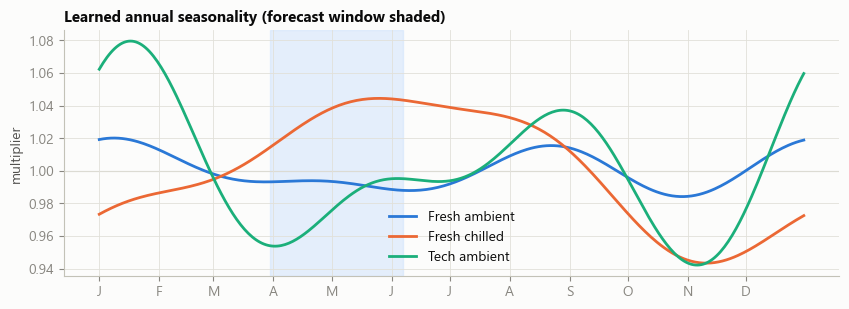

,share of LightGBM correction gain
outlet_id,0.657
days_since_festival,0.094
iso_week,0.070
ramp_festival,0.037
post_festival_name,0.036
days_since_payday,0.033
month,0.023
brand,0.013


In [118]:
doy = np.arange(1, 366)
fig, ax = plt.subplots(figsize=(10, 3.2))
for seg_name, c in [("Fresh_ambient", BLUE), ("Fresh_chilled", ORANGE), ("Tech_ambient", AQUA)]:
    z = sum(coef[f"sin{k}_{seg_name}"] * np.sin(2 * np.pi * k * doy / 365.25) +
            coef[f"cos{k}_{seg_name}"] * np.cos(2 * np.pi * k * doy / 365.25) for k in range(1, 4))
    ax.plot(doy, np.exp(z - z.mean()), color=c, label=seg_name.replace("_", " "))
ax.axvspan(pd.Timestamp("2026-03-30").dayofyear, pd.Timestamp("2026-06-07").dayofyear, color=BLUE_LIGHT, alpha=0.5, zorder=0)
ax.axhline(1, color=AXIS, linewidth=0.8, zorder=0)
ax.set_xticks([1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335], ["J","F","M","A","M","J","J","A","S","O","N","D"])
ax.set_title("Learned annual seasonality (forecast window shaded)"); ax.set_ylabel("multiplier"); ax.legend()
save(fig, "learned_seasonality"); plt.show()

imp = pd.Series(final_model.model.booster_.feature_importance("gain"), index=final_model.cols)
display((imp / imp.sum()).sort_values(ascending=False).head(8).rename("share of LightGBM correction gain").to_frame().round(3))

### 21.2b What the structural model learned (used for Style)
Every parameter is a plain number, saved in `models/task2a_structural.json`.

In [119]:
sj = struct_json
print("Level L (m³ per average operating day):", {k: round(v, 1) for k, v in sj["level_L"].items()})
print("Year-on-year growth factor yoy8:", {k: round(v, 3) for k, v in sj["yoy8"].items()})
print("Payday uplift p:", {k: round(v, 3) for k, v in sj["payday_uplift"].items()})
dow = pd.DataFrame({s_: {int(d): v for d, v in f.items()} for s_, f in sj["dow_factor"].items()}).rename(index=dict(enumerate(day_names)))
display(dow.round(3).style.set_caption("Weekday factor f (mean = 1; blank = the series never orders that day)"))
slopes = pd.DataFrame(sj["festival_slope"]).reindex(FESTIVALS)
display(slopes.round(3).style.set_caption("Festival slope b: uplift of a day at ramp 1.0 vs a normal day"))

Level L (m³ per average operating day): {'Kandy-Fresh': 86.2, 'Kandy-Style': 12.8, 'Kandy-Tech': 3.8, 'Peliyagoda-Fresh': 162.8, 'Peliyagoda-Style': 23.4, 'Peliyagoda-Tech': 5.2}
Year-on-year growth factor yoy8: {'Kandy-Fresh': 1.08, 'Kandy-Style': 0.976, 'Kandy-Tech': 1.041, 'Peliyagoda-Fresh': 1.064, 'Peliyagoda-Style': 1.033, 'Peliyagoda-Tech': 1.448}
Payday uplift p: {'Fresh': 0.068, 'Style': 0.058, 'Tech': 0.133}


,Kandy-Fresh,Kandy-Style,Kandy-Tech,Peliyagoda-Fresh,Peliyagoda-Style,Peliyagoda-Tech
Mon,0.932000,1.923000,1.000000,0.962000,0.671000,1.000000
Tue,0.889000,0.000000,1.000000,0.947000,0.000000,1.000000
Wed,0.964000,0.903000,1.000000,0.891000,1.119000,1.000000
Thu,0.997000,2.468000,1.000000,1.045000,2.210000,1.000000
Fri,1.099000,0.000000,1.000000,1.039000,2.000000,1.000000
Sat,1.119000,0.706000,1.000000,1.117000,0.000000,1.000000


,Fresh,Style,Tech
new_year,0.790000,1.115000,0.797000
christmas,0.621000,1.057000,1.279000
deepavali,0.381000,0.771000,-0.043000
vesak,0.332000,0.087000,-0.455000
esala,0.239000,0.496000,0.248000
poson,0.204000,-0.013000,-0.268000
thai_pongal,0.224000,0.113000,0.081000


### 21.3 The 2026 W14–W23 forecast

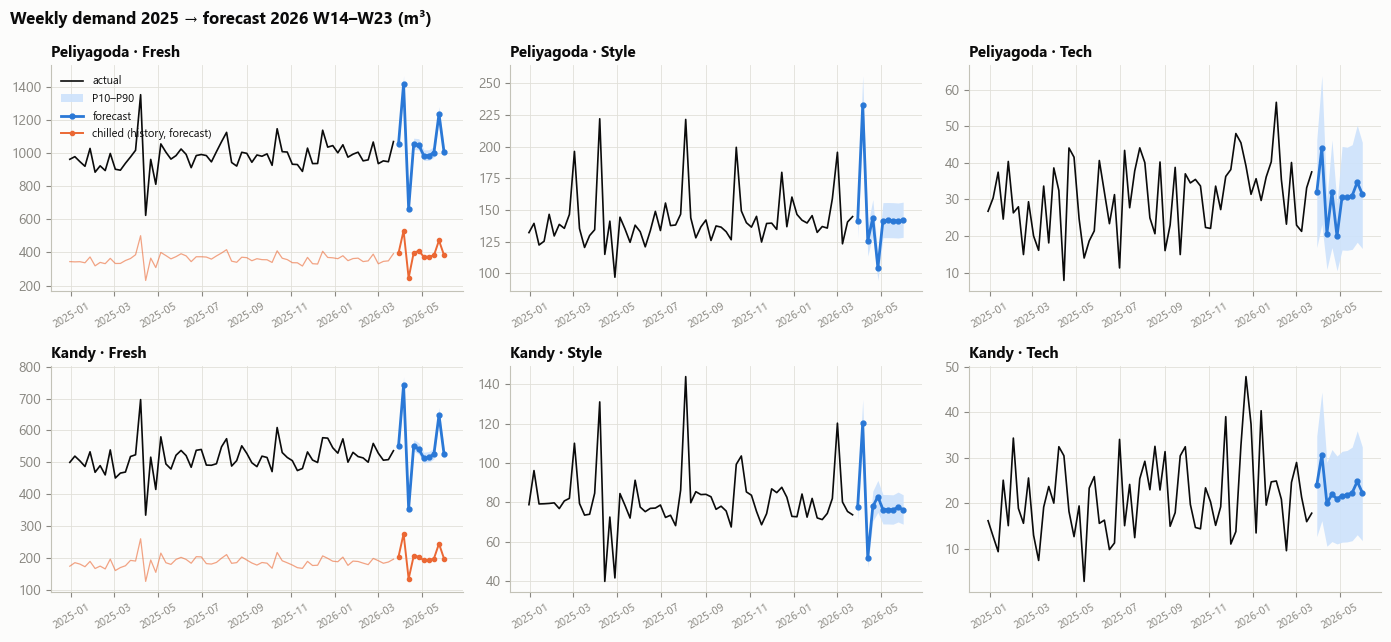

In [120]:
fc = forecast.copy()
fc["week_start"] = (fc.iso_year * 100 + fc.iso_week).map(wk_start)
hist = weekly[weekly.yw >= 202501]
fig, axes = plt.subplots(2, 3, figsize=(14, 6.5))
for ax, (dep, b) in zip(axes.ravel(), [(d, b) for d in ["Peliyagoda", "Kandy"] for b in ["Fresh", "Style", "Tech"]]):
    h_ = hist[(hist.depot == dep) & (hist.brand == b)]
    f_ = fc[(fc.depot == dep) & (fc.brand == b)]
    ax.plot(h_.week_start, h_.total_m3, color=INK, linewidth=1.2, label="actual")
    ax.fill_between(f_.week_start, f_.pred_total_volume_m3_p10, f_.pred_total_volume_m3_p90,
                    color=BLUE_LIGHT, alpha=0.9, linewidth=0, label="P10–P90")
    ax.plot(f_.week_start, f_.pred_total_volume_m3, color=BLUE, marker="o", markersize=3.5, label="forecast")
    if b == "Fresh":
        ax.plot(f_.week_start, f_.pred_chilled_volume_m3, color=ORANGE, marker="o", markersize=3, linewidth=1.4,
                label="chilled (history, forecast)")
        ax.plot(h_.week_start, h_.chilled_m3, color=ORANGE, linewidth=0.9, alpha=0.6)
    ax.set_title(f"{dep} · {b}")
    ax.tick_params(axis="x", labelrotation=30, labelsize=8)
axes[0, 0].legend(fontsize=8, loc="upper left")
fig.suptitle("Weekly demand 2025 → forecast 2026 W14–W23 (m³)", x=0.01, ha="left", fontweight="bold")
fig.tight_layout(); save(fig, "final_forecast"); plt.show()

In [121]:
tot = fc.pivot_table(index=["depot", "brand"], columns="iso_week", values="pred_total_volume_m3")
chi = fc[fc.brand == "Fresh"].pivot_table(index="depot", columns="iso_week", values="pred_chilled_volume_m3")
print("Total m³ forecast"); display(tot.round(1))
print("Chilled m³ forecast (Fresh)"); display(chi.round(1))

Total m³ forecast


iso_week                14        15      16        17        18      19      20        21        22        23
depot      brand                                                                                              
Kandy      Fresh   551.000   742.100 354.900   551.100   541.800 513.100 515.400   525.600   648.200   525.700
           Style    77.500   120.200  52.000    77.900    82.900  76.400  76.300    76.200    77.500    76.200
           Tech     24.000    30.600  20.000    21.900    21.000  21.700  21.800    22.300    24.800    22.300
Peliyagoda Fresh 1,053.700 1,414.800 664.000 1,051.100 1,048.000 983.200 983.700 1,001.800 1,234.500 1,004.700
           Style   141.100   232.700 125.500   143.700   104.300 141.600 141.700   141.600   141.300   141.900
           Tech     31.900    44.000  20.700    31.900    19.900  30.700  30.600    31.000    34.700    31.500

Chilled m³ forecast (Fresh)


iso_week,14,15,16,17,18,19,20,21,22,23
depot,,,,,,,,,,
Kandy,204.000,275.900,134.700,206.200,204.300,192.500,193.800,197.900,244.800,197.800
Peliyagoda,395.900,531.200,246.000,398.000,409.400,373.800,374.700,382.100,472.200,383.500


**Sanity check against the calendar** (Peliyagoda Fresh):
* **W15** (6–11 Apr) has the highest total: the New Year ramp climbs from 0.3 to 0.8 across all six operating days.
* **W16** is the lowest: Mon 13 and Tue 14 Apr are closed (4 operating days, 532 order slots instead of 800), and the
  post-festival dip applies.
* **W18**: Vesak falls on Fri 1 May, a closed day, but Mon–Thu carry ramp 0.6–0.9 plus the 30 Apr payday.
* **W22**: Poson's ramp (Mon–Sat) plus two paydays (25 and 30 May) make it the second-highest week.
* Chilled forecasts sit slightly above the yearly average share, in line with the Apr–Jun chilled season.

In [122]:
ly = weekly[weekly.iso_year == 2025][["depot", "brand", "iso_week", "total_m3"]].rename(columns={"total_m3": "same ISO week 2025"})
cmp = fc.merge(ly, on=["depot", "brand", "iso_week"])
cmp["vs 2025 %"] = 100 * (cmp.pred_total_volume_m3 / cmp["same ISO week 2025"] - 1)
display(cmp[(cmp.brand == "Fresh")].pivot_table(index="depot", columns="iso_week", values="vs 2025 %").round(1))
win = cmp.groupby("brand")[["pred_total_volume_m3", "same ISO week 2025"]].sum()
win.loc["All brands"] = win.sum()
win["10-week change vs 2025 %"] = 100 * (win.pred_total_volume_m3 / win["same ISO week 2025"] - 1)
display(win.round(1))

iso_week,14,15,16,17,18,19,20,21,22,23
depot,,,,,,,,,,
Kandy,5.200,6.500,6.200,6.800,30.600,-11.500,4.100,9.700,24.100,-2.200
Peliyagoda,3.700,4.700,6.500,9.400,29.200,-6.700,-2.100,4.100,25.500,-1.800


,pred_total_volume_m3,same ISO week 2025,10-week change vs 2025 %
brand,,,
Fresh,"15,908.400","14,890.500",6.800
Style,"2,248.400","2,156.800",4.200
Tech,537.500,484.800,10.900
All brands,"18,694.300","17,532.100",6.600


Week-by-week differences from 2025 are large, but they follow from the calendar shifts (Vesak W20 → W18, Poson W24 →
W22) rather than from growth. Across the whole 10-week window the forecast is about 6.6% above 2025. That is the learned
Fresh growth (about +6%/year), plus Poson's whole ramp falling inside the 2026 window when in 2025 it was mostly outside.

### 21.4 From forecast to fleet planning (daily view)
Because the model works at order level, it also gives a **daily** chilled forecast for free. Planning refrigerated
capacity depends on the busiest *day*, not the weekly total. Below, each day's forecast chilled volume is compared with
what each depot's refrigerated fleet can carry in one wave (every reefer making one trip).

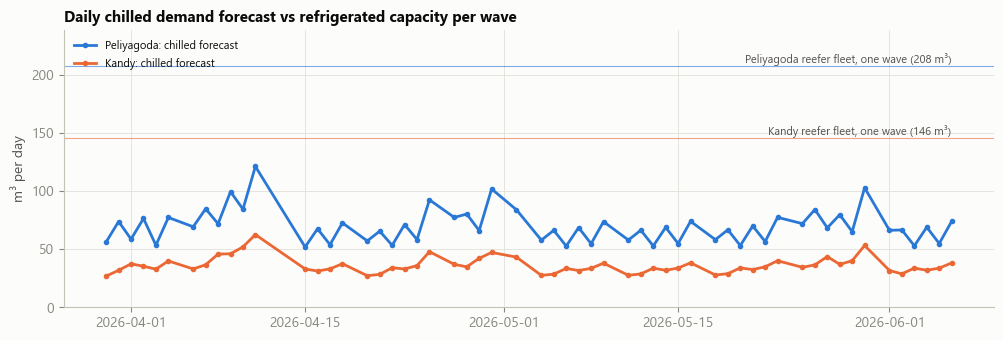

,peak day,peak chilled m³,reefer capacity per wave m³,share of one wave
depot,,,,
Kandy,Sat 11 Apr,62.600,146.000,0.430
Peliyagoda,Sat 11 Apr,121.200,207.500,0.580


In [123]:
vehicles = pd.read_csv(DATA / "General Data" / "vehicles.csv")
reefer_wave = vehicles[vehicles.temp == "reefer"].groupby("depot").volume_cap_m3.sum()
d_slots = build_slots(final_probs, cal, h_start, h_end)
d_slots["m3"] = d_slots.p_order * final_model.predict(d_slots)
daily_chilled = d_slots[d_slots.temp_requirement == "chilled"].groupby(["depot", "date"]).m3.sum().unstack(0)

fig, ax = plt.subplots(figsize=(12, 3.6))
for dep, c in DEPOT_COLORS.items():
    ax.plot(daily_chilled.index, daily_chilled[dep], color=c, marker="o", markersize=3, label=f"{dep}: chilled forecast")
    ax.axhline(reefer_wave[dep], color=c, linewidth=0.8, alpha=0.6)
    ax.text(daily_chilled.index[-1], reefer_wave[dep], f"  {dep} reefer fleet, one wave ({reefer_wave[dep]:.0f} m³)",
            va="bottom", ha="right", fontsize=8, color=INK2)
ax.set_ylim(0, reefer_wave.max() * 1.15); ax.set_ylabel("m³ per day"); ax.legend(loc="upper left", fontsize=8)
ax.set_title("Daily chilled demand forecast vs refrigerated capacity per wave")
save(fig, "daily_chilled_vs_reefer"); plt.show()
peak = daily_chilled.idxmax()
display(pd.DataFrame({"peak day": peak.dt.strftime("%a %d %b"), "peak chilled m³": daily_chilled.max().round(1),
                      "reefer capacity per wave m³": reefer_wave,
                      "share of one wave": (daily_chilled.max() / reefer_wave).round(2)}))

On the busiest pre-festival days, chilled demand uses a large share of a single reefer wave. If several refrigerated
vehicles are in the workshop (as in the Task 2B peak-day scenario), a second wave or deferrals become unavoidable. This
is the planning signal the forecast is meant to give early.

## 22. Save the models and the submission

In [124]:
with open(MODELS_DIR / "task2a_model.pkl", "wb") as fh:
    pickle.dump(bundle, fh)
(MODELS_DIR / "task2a_structural.json").write_text(json.dumps(struct_json, indent=2))
selection = {"final_model": COMPOSITE,
             "rule": {"Fresh": "hybrid", "Tech": "hybrid", "Style": "structural daily + growth",
                      "Style, ISO weeks": {"hybrid": SPIKE_WEEKS}, "chilled": "hybrid chilled order slots; Style and Tech = 0"},
             "files": {"task2a_model.pkl": "hybrid GLM + LightGBM bundle: fitted model, order schedules, P10/P90 ratios",
                       "task2a_structural.json": "structural daily model parameters + growth factors"},
             "validation": {"protocol": "49 rolling origins (2025 W07 .. 2026 W03), 10 weeks ahead each",
                            "composite": {k: round(float(v), 3) for k, v in comp_.items()},
                            "hybrid": {k: round(float(v), 3) for k, v in summary.loc["Bottom-up hybrid"].items()},
                            "structural family own pick": {k: round(float(v), 3) for k, v in summary.loc["Structural family, own per-brand pick"].items()}},
             "trained_on": bundle["meta"]["trained_on"],
             "library_versions": {"pandas": pd.__version__, "numpy": np.__version__, "lightgbm": lgb.__version__,
                                  "scikit-learn": sklearn.__version__}}
(MODELS_DIR / "task2a_selection.json").write_text(json.dumps(selection, indent=2))

template = pd.read_csv(DATA / "Submission Templates" / "submission_task2a.csv")
submission = template[["row_id"]].merge(
    forecast[["row_id", "pred_total_volume_m3", "pred_chilled_volume_m3"]], on="row_id", how="left", validate="one_to_one")
submission[["pred_total_volume_m3", "pred_chilled_volume_m3"]] = submission[
    ["pred_total_volume_m3", "pred_chilled_volume_m3"]].round(3)
submission.to_csv(SUBMISSIONS_DIR / "submission_task2a.csv", index=False)

# Extra planning file (not part of the scored submission): forecasts with P10/P90 ranges.
forecast.round(3).to_csv(SUBMISSIONS_DIR / "task2a_forecast_with_intervals.csv", index=False)

sub = pd.read_csv(SUBMISSIONS_DIR / "submission_task2a.csv").merge(t2a_inputs, on="row_id")
checks = {
    "same columns as template": list(pd.read_csv(SUBMISSIONS_DIR / "submission_task2a.csv").columns) == list(template.columns),
    "same row_ids in the same order": (pd.read_csv(SUBMISSIONS_DIR / "submission_task2a.csv").row_id == template.row_id).all(),
    "60 rows, no missing values": len(sub) == 60 and sub[["pred_total_volume_m3", "pred_chilled_volume_m3"]].notna().all().all(),
    "no negative values": (sub[["pred_total_volume_m3", "pred_chilled_volume_m3"]] >= 0).all().all(),
    "chilled = 0 for Style and Tech": (sub.loc[sub.brand != "Fresh", "pred_chilled_volume_m3"] == 0).all(),
    "chilled <= total": (sub.pred_chilled_volume_m3 <= sub.pred_total_volume_m3).all(),
    "Style rows come from the structural model (weeks outside ISO 10, 32)": (forecast.loc[(forecast.brand == "Style") & ~forecast.iso_week.isin(SPIKE_WEEKS), "source_model"] == "structural daily").all(),
}
display(pd.DataFrame({"check": checks.keys(), "result": ["PASS" if v else "FAIL" for v in checks.values()]}))
assert all(checks.values()), "a submission check failed"
print("saved:", (MODELS_DIR / "task2a_model.pkl").relative_to(ROOT), "|", (MODELS_DIR / "task2a_structural.json").relative_to(ROOT),
      "|", (MODELS_DIR / "task2a_selection.json").relative_to(ROOT), "|", (SUBMISSIONS_DIR / "submission_task2a.csv").relative_to(ROOT))

,check,result
0,same columns as template,PASS
1,same row_ids in the same order,PASS
2,"60 rows, no missing values",PASS
3,no negative values,PASS
4,chilled = 0 for Style and Tech,PASS
5,chilled <= total,PASS
6,Style rows come from the structural model (wee...,PASS


saved: models\task2a_model.pkl | models\task2a_structural.json | models\task2a_selection.json | submissions\submission_task2a.csv


# Part C · Task 2B: peak-day fleet allocation

## 23. Task 2B: peak-day fleet allocation (scenario S1, Peliyagoda)

Mark every order *served* or *deferred*, assign each served order to a vehicle and trip within the booklet's seven
feasibility rules, and explain the priorities. The written one-page policy is `docs/Task2B_Prioritization_Policy.md`;
this section holds the analysis and the code behind it.

**Approach.** An exact mixed-integer program (scipy `milp` / HiGHS) with a *lexicographic* objective: each priority is
solved to proven optimality and then locked before the next, so a lower priority can never trade away a higher one.
Operational repairs (trip order, splitting late trips, fuel balance) then improve the plan without changing who is
served. **`check_allocation.py`**, the organisers' checker, is a hard gate on every plan in this section, and a table
of alternatives (a teammate's greedy heuristic and two other MILP policies) shows why the gate cannot replace our own
scoring: it passes every feasible plan, good or bad.

### 23.1 Inputs and the feasibility rules in code

`compatible` encodes rules 2–4 (refrigeration, van-only access, home depot), plus our peak-day rule that refrigerated
vehicles carry only chilled orders, because refrigerated capacity is the binding resource and ambient trucks are plentiful.
`unservable_reason` flags orders that no plan could ever serve. `trip_minutes` is the brief's published trip-time standard.

In [125]:
FRESH_BUDGET, DAY_BUDGET, TRIPS = 270, 480, (1, 2)
EFFICIENCY_NODES = 3000      # node limit for the last tie-break stage (keeps runs reproducible)


def load_inputs():
    orders = pd.read_csv(DATA / "Test Data" / "task2b_peak_day_scenarios.csv")
    fleet = pd.read_csv(DATA / "Test Data" / "task2b_peak_day_fleet.csv")
    vehicles = pd.read_csv(DATA / "General Data" / "vehicles.csv")
    travel = pd.read_csv(DATA / "General Data" / "district_travel.csv").set_index("district")
    allowance = pd.read_csv(DATA / "General Data" / "service_allowance.csv")

    orders = orders.merge(allowance, on=["brand", "dock_type"], how="left", validate="many_to_one")
    orders["group"] = orders.brand + " | " + orders.district          # one trip = one brand + district
    orders["outbound_min"] = orders.district.map(travel.depot_to_district_freeflow_min)
    orders["inter_min"] = orders.district.map(travel.inter_stop_freeflow_min)
    orders["window"] = np.where(orders.brand == "Fresh", "fresh", "day")

    fleet = fleet.merge(vehicles, on="vehicle_id", how="left", validate="one_to_one")
    available = fleet[fleet.status == "available"].reset_index(drop=True)
    orders["unservable_reason"] = [unservable_reason(o, available, travel) for o in orders.itertuples()]
    orders["unservable"] = orders.unservable_reason.notna()
    return orders, fleet, available, travel


def compatible(order, veh, reserve_reefers=True):
    """Rules 2-4 (refrigeration, vehicle access, home depot) plus the peak-day
    policy rule that refrigerated vehicles carry only chilled orders, because
    refrigerated capacity is the binding resource and ambient trucks are plentiful."""
    if order.depot != veh.depot:
        return False
    if order.temp_requirement == "chilled" and veh.temp != "reefer":
        return False
    if order.parking_constraint == "van_only" and veh.type != "van":
        return False
    if reserve_reefers and order.temp_requirement == "ambient" and veh.temp == "reefer":
        return False
    return True


def unservable_reason(order, vehicles, travel):
    """Why no feasible plan could ever serve this order on its own (or None)."""
    fit = vehicles[[compatible(order, v, reserve_reefers=False) for v in vehicles.itertuples()]]
    if fit.empty:
        return "no available vehicle meets its temperature / access needs"
    if (fit.volume_cap_m3 < order.order_volume_m3).all():
        return (f"{order.order_volume_m3:.1f} m3 exceeds every compatible vehicle "
                f"(largest {fit.volume_cap_m3.max():.0f} m3) and orders cannot be split")
    if (fit.weight_cap_kg < order.order_weight_kg).all():
        return f"{order.order_weight_kg:.0f} kg exceeds every compatible vehicle"
    budget = FRESH_BUDGET if order.brand == "Fresh" else DAY_BUDGET
    if order.outbound_min + order.service_allowance_min > budget:
        return "a single-stop trip already exceeds the daily time budget"
    return None


def trip_minutes(n_orders, outbound, inter, allowances):
    """Published planning standard: outbound + (n-1) x inter-stop + handling."""
    return 0.0 if n_orders == 0 else outbound + (n_orders - 1) * inter + sum(allowances)

In [126]:
peak, fleet, available, travel = load_inputs()
print(f"{len(peak)} orders, {peak.order_volume_m3.sum():.1f} m3 | fleet {len(fleet)} vehicles, "
      f"{len(available)} available, {(fleet.status == 'in_workshop').sum()} in workshop")
display(peak.groupby(["brand", "temp_requirement"]).agg(orders=("order_ref", "size"),
        m3=("order_volume_m3", "sum"), kg=("order_weight_kg", "sum"),
        deferred_yesterday=("deferred_yesterday", "sum")).round(1))
display(fleet.groupby(["status", "type", "temp"]).agg(vehicles=("vehicle_id", "size"),
        m3_per_wave=("volume_cap_m3", "sum"), kg_per_wave=("weight_cap_kg", "sum")))
display(peak.loc[peak.unservable, ["order_ref", "outlet_id", "brand", "district", "order_volume_m3",
                                       "unservable_reason"]])

85 orders, 409.9 m3 | fleet 38 vehicles, 28 available, 10 in workshop


orders      m3         kg  deferred_yesterday
brand temp_requirement                                               
Fresh ambient               49 133.000 24,838.400                   3
      chilled               26 181.600 32,780.400                   3
Style ambient                5  77.200  4,878.300                   2
Tech  ambient                5  18.100  5,642.300                   2

vehicles  m3_per_wave  kg_per_wave
status      type  temp                                       
available   truck ambient        22      656.000       121600
                  reefer          3       79.200        15960
            van   ambient         2       17.000         2300
                  reefer          1        7.000         1040
in_workshop truck ambient         5      132.000        23600
                  reefer          4      114.300        23180
            van   reefer          1        7.000         1040

,order_ref,outlet_id,brand,district,order_volume_m3,unservable_reason
78,S1-078,OUT070,Style,Kurunegala,40.660,40.7 m3 exceeds every compatible vehicle (larg...


### 23.2 Where capacity runs out: chilled demand vs the refrigerated fleet and the 270-minute window

In [127]:
ch = peak[peak.temp_requirement == "chilled"]
rf = available[available.temp == "reefer"]
by_d = ch.groupby("district").agg(chilled_orders=("order_ref", "size"), m3=("order_volume_m3", "sum"),
                                  kg=("order_weight_kg", "sum"))
by_d["outbound_min"] = travel.depot_to_district_freeflow_min
by_d["one_trip_all_orders_min"] = [trip_minutes(len(g), g.outbound_min.iloc[0], g.inter_min.iloc[0],
                                                g.service_allowance_min) for _, g in ch.groupby("district")]
display(by_d.round(1))
print(f"chilled demand {ch.order_volume_m3.sum():.1f} m3 / {ch.order_weight_kg.sum():,.0f} kg vs available reefers "
      f"{rf.volume_cap_m3.sum():.1f} m3 / {rf.weight_cap_kg.sum():,.0f} kg per wave "
      f"({', '.join(rf.vehicle_id)}); each reefer has 2 trips and 270 Fresh minutes")

,chilled_orders,m3,kg,outbound_min,one_trip_all_orders_min
district,,,,,
Colombo,9,51.600,"9,313.200",24,228
Galle,2,20.300,"3,412.500",103,143
Gampaha,6,48.100,"8,734.400",37,173
Kalutara,3,16.000,"2,930.200",64,134
Kurunegala,3,25.000,"4,593.300",127,210
Matara,2,12.000,"2,208.000",137,177
Puttalam,1,8.700,"1,588.800",173,188


chilled demand 181.6 m3 / 32,780 kg vs available reefers 86.2 m3 / 17,000 kg per wave (VEH003, VEH006, VEH007, VEH036); each reefer has 2 trips and 270 Fresh minutes


### 23.3 The optimisation model
Binary `x[o,v,t]` puts order *o* on vehicle *v*, trip *t*. Binary `y[v,t,g]` says trip (v,t) serves brand-district group
*g*. Constraints:
* each order is served at most once, never split (rule 5);
* an order rides only on a trip assigned to its brand-district group, one group per trip (rule 1);
* volume and weight per trip (rule 6);
* per-vehicle Fresh ≤ 270 and Style/Tech ≤ 480 trip-minutes, with trip time = outbound + (n−1)·inter-stop + Σ
  allowances, written linearly as (outbound − inter)·y + Σ(inter + allowance)·x (rule 7);
* rules 2–4 through which variables exist at all;
* symmetry breaking (trip 2 only after trip 1; spec-identical vehicles used in id order).

With refrigerated vehicles reserved for chilled orders, the day splits into two independent problems with no shared
vehicles: chilled orders on refrigerated vehicles, and all other orders on ambient vehicles. Each is solved exactly.

In [128]:
class AllocationModel:
    """Binary x[o,v,t] (order o on vehicle v, trip t) and y[v,t,g] (trip v,t
    serves brand-district group g)."""

    def __init__(self, orders, vehicles, reserve_reefers=True, strict_clock=False):
        self.o, self.v = orders.reset_index(drop=True), vehicles.reset_index(drop=True)
        self.reserve_reefers = reserve_reefers
        self.strict_clock = strict_clock
        groups = sorted(self.o.group.unique())
        self.groups = {g: i for i, g in enumerate(groups)}
        g_info = self.o.groupby("group").agg(outbound=("outbound_min", "first"),
                                              inter=("inter_min", "first"),
                                              window=("window", "first"))
        self.g_info = g_info

        # Decision variables
        xs = [(oi, vi, t) for oi, o in self.o.iterrows() for vi, v in self.v.iterrows()
              if not o.unservable and compatible(o, v, reserve_reefers) for t in TRIPS]
        ys = sorted({(vi, t, self.o.group[oi]) for oi, vi, t in xs})
        self.xs, self.ys = xs, ys
        self.nx, self.ny = len(xs), len(ys)
        self.xi = {k: i for i, k in enumerate(xs)}
        self.yi = {k: self.nx + i for i, k in enumerate(ys)}
        self.n = self.nx + self.ny
        self._build_constraints()

    def _build_constraints(self):
        rows, A_r, A_c, A_v, lo, hi = 0, [], [], [], [], []

        def add(coefs, l, u):
            nonlocal rows
            for c, val in coefs:
                A_r.append(rows); A_c.append(c); A_v.append(val)
            lo.append(l); hi.append(u); rows += 1

        o, v = self.o, self.v
        # (5) every order at most once (whole order, one vehicle, one trip)
        by_order = {}
        for k, i in self.xi.items():
            by_order.setdefault(k[0], []).append(i)
        for oi, idx in by_order.items():
            add([(i, 1) for i in idx], 0, 1)
        # (1) x <= y : an order rides only on a trip assigned to its brand-district group
        for (oi, vi, t), i in self.xi.items():
            add([(i, 1), (self.yi[(vi, t, o.group[oi])], -1)], -np.inf, 0)
        # one group per trip; trip 2 only if trip 1 is used (symmetry breaking)
        by_trip = {}
        for (vi, t, g), i in self.yi.items():
            by_trip.setdefault((vi, t), []).append(i)
        for (vi, t), idx in by_trip.items():
            add([(i, 1) for i in idx], 0, 1)
        for vi in range(len(v)):
            t1, t2 = by_trip.get((vi, 1), []), by_trip.get((vi, 2), [])
            if t2:
                add([(i, 1) for i in t2] + [(i, -1) for i in t1], -np.inf, 0)
        # symmetry breaking: among spec-identical vehicles, use them in id order
        spec = v.type + v.temp + v.volume_cap_m3.astype(str) + v.weight_cap_kg.astype(str)
        for _, same in v.groupby(spec).groups.items():
            same = sorted(same)
            for a, b in zip(same, same[1:]):
                ua = [i for (vi, t), idx in by_trip.items() if vi == a for i in idx]
                ub = [i for (vi, t), idx in by_trip.items() if vi == b for i in idx]
                if ub:
                    add([(i, 1) for i in ua] + [(i, -1) for i in ub], 0, np.inf)
        # (6) capacity per trip: volume and weight
        by_vt = {}
        for (oi, vi, t), i in self.xi.items():
            by_vt.setdefault((vi, t), []).append((oi, i))
        for (vi, t), lst in by_vt.items():
            add([(i, o.order_volume_m3[oi]) for oi, i in lst], -np.inf, v.volume_cap_m3[vi])
            add([(i, o.order_weight_kg[oi]) for oi, i in lst], -np.inf, v.weight_cap_kg[vi])
        # (7) daily time budgets per vehicle: Fresh window and Style/Tech window
        #     trip time = (outbound - inter) * y + sum_orders (inter + allowance) * x
        for vi in range(len(v)):
            for window, budget in (("fresh", FRESH_BUDGET), ("day", DAY_BUDGET)):
                coefs = []
                for (vj, t, g), i in self.yi.items():
                    if vj == vi and self.g_info.window[g] == window:
                        coefs.append((i, self.g_info.outbound[g] - self.g_info.inter[g]))
                for (oi, vj, t), i in self.xi.items():
                    if vj == vi and o.window[oi] == window:
                        coefs.append((i, o.inter_min[oi] + o.service_allowance_min[oi]))
                if coefs:
                    add(coefs, -np.inf, budget)
                # Optional stricter variant (not in the brief): when a vehicle runs two
                # Fresh trips, the drive back to the depot after trip 1 also counts:
                # trip time + return(trip 1) - M * (1 - trip-2-used) <= budget
                if self.strict_clock and window == "fresh" and coefs:
                    big_m = float(self.g_info.outbound.max())
                    ret = [(i, self.g_info.outbound[g]) for (vj, t, g), i in self.yi.items()
                           if vj == vi and t == 1 and self.g_info.window[g] == "fresh"]
                    trip2 = [(i, big_m) for (vj, t, g), i in self.yi.items()
                             if vj == vi and t == 2 and self.g_info.window[g] == "fresh"]
                    if trip2:   # equivalent: trip time + return(trip 1) + M * trip2 <= budget + M
                        add(coefs + ret + trip2, -np.inf, budget + big_m)
        self.A = sparse.csr_matrix((A_v, (A_r, A_c)), shape=(rows, self.n))
        self.lo, self.hi = np.array(lo), np.array(hi)
        self.extra = []          # locked-in objectives from earlier stages

    # objective helpers -----------------------------------------------------
    def order_vector(self, values):
        """Objective vector giving each x[o,.,.] the per-order value."""
        c = np.zeros(self.n)
        for (oi, vi, t), i in self.xi.items():
            c[i] = values[oi]
        return c

    def trip_vector(self, per_trip=1.0, per_minute=0.0):
        c = np.zeros(self.n)
        for (vi, t, g), i in self.yi.items():
            c[i] = per_trip + per_minute * (self.g_info.outbound[g] - self.g_info.inter[g])
        for (oi, vi, t), i in self.xi.items():
            c[i] += per_minute * (self.o.inter_min[oi] + self.o.service_allowance_min[oi])
        return c

    def solve(self, c, sense="max", time_limit=120, gap=1e-6, node_limit=None):
        cons = [LinearConstraint(self.A, self.lo, self.hi)]
        for c_lock, bound in self.extra:
            cons.append(LinearConstraint(c_lock.reshape(1, -1), bound, np.inf))
        sign = -1 if sense == "max" else 1
        opts = {"time_limit": time_limit, "mip_rel_gap": gap}
        if node_limit:
            opts["node_limit"] = node_limit       # deterministic stopping rule
        res = milp(sign * c, constraints=cons, integrality=np.ones(self.n), bounds=Bounds(0, 1), options=opts)
        if res.x is None:
            raise RuntimeError(f"solver failed: {res.message}")
        return np.round(res.x).astype(int), float(c @ np.round(res.x)), res

    def lock(self, c, value, slack=1e-6):
        """Keep a stage's optimum while optimising the next stage."""
        self.extra.append((c, value - slack))

    # decoding ------------------------------------------------------------------
    def decode(self, x):
        out = self.o[["scenario", "order_ref", "outlet_id"]].copy()
        out["decision"], out["vehicle_id"], out["trip_id"] = "deferred", "", ""
        out["trip_id"] = out.trip_id.astype(object)
        for (oi, vi, t), i in self.xi.items():
            if x[i]:
                out.loc[oi, ["decision", "vehicle_id", "trip_id"]] = ["served", self.v.vehicle_id[vi], t]
        return relabel_trips(out, self.o)


def relabel_trips(alloc, orders):
    """Number each vehicle's trips in time order: pre-dawn Fresh trip first."""
    a = alloc.merge(orders[["order_ref", "brand"]], on="order_ref")
    for vid, g in a[a.decision == "served"].groupby("vehicle_id"):
        trips = (g.groupby("trip_id").brand.first()
                  .sort_values(key=lambda b: (b != "Fresh").astype(int), kind="stable"))
        mapping = {old: new for new, old in enumerate(trips.index, start=1)}
        a.loc[g.index, "trip_id"] = g.trip_id.map(mapping)
    return a.drop(columns="brand")

### 23.4 Priority policy (lexicographic)

In [129]:
POLICY = [
    # (name, sense, value function on the orders table) - solved strictly in this order
    ("1. No outlet deferred two runs in a row (serve every order deferred yesterday)",
     "max", lambda o: o.deferred_yesterday.astype(float)),
    ("2. Maximise the number of outlets receiving their chilled order",
     "max", lambda o: (o.temp_requirement == "chilled").astype(float)),
    ("3. Maximise chilled volume served (festival dairy / meat / produce)",
     "max", lambda o: np.where(o.temp_requirement == "chilled", o.order_volume_m3, 0.0)),
    ("4. Maximise total volume served",
     "max", lambda o: o.order_volume_m3.astype(float)),
    ("5. Favour outlets waiting longest (days since last served)",
     "max", lambda o: o.days_since_last_served.astype(float)),
]


def solve_policy(orders, vehicles, policy, efficiency, time_limit, verbose, reserve_reefers, label="",
                 strict_clock=False):
    """Run the lexicographic stages on one (sub)problem."""
    m = AllocationModel(orders, vehicles, reserve_reefers, strict_clock)
    log, x, seen = [], np.zeros(m.n, dtype=int), []
    for name, sense, fn in policy:
        c = m.order_vector(np.asarray(fn(m.o), dtype=float))
        if not c.any() or any(np.allclose(c, prev) for prev in seen):
            continue                                   # stage is trivial for this subproblem
        seen.append(c)
        x, val, res = m.solve(c, sense, time_limit)
        optimal = res.status == 0
        # Lock the stage: as an equality when proven optimal (a valid, tighter cut).
        m.extra.append((c, val - 1e-6))
        if optimal:
            m.extra.append((-c, -val - 1e-6))
        log.append({"subproblem": label, "stage": name, "optimum": round(val, 3),
                    "proven optimal": optimal})
        if verbose:
            print(f"[{label}] {name}: {val:.3f} ({'optimal' if optimal else res.message})")
    if efficiency and m.ny:
        c = m.trip_vector(per_trip=1000.0, per_minute=1.0)
        x, val, res = m.solve(c, "min", time_limit=3600, gap=1e-4, node_limit=EFFICIENCY_NODES)
        log.append({"subproblem": label, "stage": "6. Fewest trips, then fewest trip-minutes",
                    "optimum": round(val, 1), "proven optimal": res.status == 0})
        if verbose:
            print(f"[{label}] efficiency: {int(m.trip_vector(1, 0) @ x)} trips, "
                  f"{m.trip_vector(0, 1) @ x:.0f} trip-minutes ({'optimal' if res.status == 0 else res.message})")
    return m.decode(x), m, log


def allocate(orders, available, policy=POLICY, efficiency=True, time_limit=180, verbose=True,
             reserve_reefers=True):
    """Solve the lexicographic policy; returns (allocation, models, stage log).

    With refrigerated vehicles reserved for chilled orders, the day splits into two
    independent problems with no shared vehicles: chilled orders on refrigerated
    vehicles, and all other orders on ambient vehicles. Each is solved exactly.
    """
    if reserve_reefers:
        chilled, reefer = orders.temp_requirement == "chilled", available.temp == "reefer"
        parts = [("chilled on refrigerated fleet", orders[chilled], available[reefer]),
                 ("ambient on ambient fleet", orders[~chilled], available[~reefer])]
    else:
        parts = [("whole fleet", orders, available)]
    allocs, models, logs = [], [], []
    for label, o, v in parts:
        a, m, lg = solve_policy(o, v, policy, efficiency, time_limit, verbose, reserve_reefers, label)
        allocs.append(a); models.append(m); logs += lg
    alloc = pd.concat(allocs).set_index("order_ref").loc[orders.order_ref].reset_index()
    return alloc, models, pd.DataFrame(logs)

### 23.5 Solve

In [130]:
alloc, models, stage_log = allocate(peak, available)
display(stage_log)

[chilled on refrigerated fleet] 1. No outlet deferred two runs in a row (serve every order deferred yesterday): 3.000 (optimal)


[chilled on refrigerated fleet] 2. Maximise the number of outlets receiving their chilled order: 19.000 (optimal)


[chilled on refrigerated fleet] 3. Maximise chilled volume served (festival dairy / meat / produce): 130.960 (optimal)


[chilled on refrigerated fleet] 5. Favour outlets waiting longest (days since last served): 33.000 (optimal)


[chilled on refrigerated fleet] efficiency: 8 trips, 878 trip-minutes (The HiGHS status code was not recognized. (HiGHS Status 16: Solution limit reached))


[ambient on ambient fleet] 1. No outlet deferred two runs in a row (serve every order deferred yesterday): 7.000 (optimal)


[ambient on ambient fleet] 4. Maximise total volume served: 187.575 (optimal)


[ambient on ambient fleet] 5. Favour outlets waiting longest (days since last served): 96.000 (optimal)


[ambient on ambient fleet] efficiency: 15 trips, 3111 trip-minutes (The HiGHS status code was not recognized. (HiGHS Status 16: Solution limit reached))


,subproblem,stage,optimum,proven optimal
0,chilled on refrigerated fleet,1. No outlet deferred two runs in a row (serve...,3.000,True
1,chilled on refrigerated fleet,2. Maximise the number of outlets receiving th...,19.000,True
2,chilled on refrigerated fleet,3. Maximise chilled volume served (festival da...,130.960,True
3,chilled on refrigerated fleet,5. Favour outlets waiting longest (days since ...,33.000,True
4,chilled on refrigerated fleet,"6. Fewest trips, then fewest trip-minutes","8,878.000",False
5,ambient on ambient fleet,1. No outlet deferred two runs in a row (serve...,7.000,True
6,ambient on ambient fleet,4. Maximise total volume served,187.575,True
7,ambient on ambient fleet,5. Favour outlets waiting longest (days since ...,96.000,True
8,ambient on ambient fleet,"6. Fewest trips, then fewest trip-minutes","18,111.000",False


### 23.6 Operational repairs beyond the brief's rules
The official trip-time standard leaves out the drive back between trips and any waiting for an outlet to open. A
real-clock simulation checks every stop's arrival against its delivery window. Repairs that never change who is served:
1. run each vehicle's trips in the order with the least lateness;
2. move late stops on ambient vehicles to idle ambient trucks;
3. move a second trip off any vehicle whose diesel today exceeds one-sixth of its weekly quota.

In [131]:
def trip_table(alloc, orders, available):
    a = alloc[alloc.decision == "served"].merge(orders, on=["scenario", "order_ref", "outlet_id"])
    a = a.merge(available[["vehicle_id", "type", "temp", "volume_cap_m3", "weight_cap_kg"]], on="vehicle_id")
    rows = []
    for (vid, tid), g in a.groupby(["vehicle_id", "trip_id"]):
        rows.append({
            "vehicle_id": vid, "trip_id": int(tid), "vehicle": f"{g.type.iloc[0]} / {g.temp.iloc[0]}",
            "brand": g.brand.iloc[0], "district": g.district.iloc[0], "orders": len(g),
            "chilled_orders": int((g.temp_requirement == "chilled").sum()),
            "volume_m3": g.order_volume_m3.sum(), "volume_cap_m3": g.volume_cap_m3.iloc[0],
            "weight_kg": g.order_weight_kg.sum(), "weight_cap_kg": g.weight_cap_kg.iloc[0],
            "trip_min": trip_minutes(len(g), g.outbound_min.iloc[0], g.inter_min.iloc[0],
                                     g.service_allowance_min)})
    t = pd.DataFrame(rows)
    t["vol_util"] = t.volume_m3 / t.volume_cap_m3
    t["wt_util"] = t.weight_kg / t.weight_cap_kg
    return t.sort_values(["vehicle_id", "trip_id"]).reset_index(drop=True)


def summarise(alloc, orders):
    a = alloc.merge(orders, on=["scenario", "order_ref", "outlet_id"])
    s = a.decision == "served"
    return {
        "orders served": f"{s.sum()} / {len(a)}",
        "volume served m3": round(a.order_volume_m3[s].sum(), 1),
        "volume deferred m3": round(a.order_volume_m3[~s].sum(), 1),
        "chilled served m3": round(a.order_volume_m3[s & (a.temp_requirement == "chilled")].sum(), 1),
        "chilled deferred m3": round(a.order_volume_m3[~s & (a.temp_requirement == "chilled")].sum(), 1),
        "deferred-yesterday orders deferred again": int((~s & (a.deferred_yesterday == 1)).sum()),
        "outlets with nothing delivered": int(a.groupby("outlet_id").decision.apply(
            lambda d: (d == "deferred").all()).sum()),
    }


FRESH_START, DAY_START = "03:30", "08:00"
_hm = lambda t: int(t[:2]) * 60 + int(t[3:5])
_fmt = lambda m: f"{int(m // 60):02d}:{int(m % 60):02d}"


def _run_vehicle(trips):
    """Clock simulation of one vehicle's trips in the given order. Stops are
    sequenced by earliest window close; early arrivals wait for the window to
    open; the next trip leaves after driving back to the depot."""
    rows, free_at = [], 0
    for tid, g in trips:
        start = max(_hm(FRESH_START if g.brand.iloc[0] == "Fresh" else DAY_START), free_at)
        g = g.assign(wo=g.window_open_time.map(_hm), wc=g.window_close_time.map(_hm)).sort_values(["wc", "wo"])
        clock = start + g.outbound_min.iloc[0]
        for k, r in enumerate(g.itertuples()):
            if k:
                clock += r.inter_min
            arrive = clock
            clock = max(arrive, r.wo) + r.service_allowance_min
            rows.append({"vehicle_id": r.vehicle_id, "trip_id": tid, "stop": k + 1, "order_ref": r.order_ref,
                         "outlet_id": r.outlet_id, "brand": r.brand, "district": r.district,
                         "depart_depot": _fmt(start), "eta": _fmt(arrive),
                         "window": f"{r.window_open_time}-{r.window_close_time}",
                         "minutes_late": max(0, arrive - r.wc), "on_time": arrive <= r.wc})
        free_at = clock + g.outbound_min.iloc[0]
    return pd.DataFrame(rows)


def stop_schedule(alloc, orders):
    """Beyond the brief's rules: real-clock arrival estimates against each outlet's
    delivery window (free-flow travel + planning allowances, waiting for windows,
    return to depot between trips). Each vehicle's trips run in whichever order
    gives the least lateness; trip_id in the returned allocation follows that order."""
    a = alloc[alloc.decision == "served"].merge(orders, on=["scenario", "order_ref", "outlet_id"])
    a["trip_id"] = a.trip_id.astype(int)
    scheds, relabel = [], {}
    for vid, gv in a.groupby("vehicle_id"):
        trips = list(gv.groupby("trip_id"))
        windows = {g.brand.iloc[0] == "Fresh" for _, g in trips}
        orders_to_try = [trips] if len(trips) == 1 else [trips, trips[::-1]]
        if len(trips) == 2 and len(windows) == 2:          # Fresh (pre-dawn) always runs first
            orders_to_try = [sorted(trips, key=lambda tg: tg[1].brand.iloc[0] != "Fresh")]
        best = min((_run_vehicle(o) for o in orders_to_try),
                   key=lambda d: (d.minutes_late.sum(), d.minutes_late.max()))
        first_ids = list(dict.fromkeys(best.trip_id))
        for new_id, old_id in enumerate(first_ids, start=1):
            relabel[(vid, old_id)] = new_id
        scheds.append(best.assign(trip_id=best.trip_id.map(lambda t, v=vid: relabel[(v, t)])))
    out = alloc.copy()
    served = out.decision == "served"
    out.loc[served, "trip_id"] = [relabel[(v, int(t))] for v, t in
                                  zip(out.loc[served, "vehicle_id"], out.loc[served, "trip_id"])]
    return pd.concat(scheds, ignore_index=True), out


def split_late_ambient_trips(alloc, orders, available, max_rounds=10):
    """Repair step that never changes which orders are served: when a real-clock
    check shows late stops on an ambient vehicle, move those stops to an idle
    ambient vehicle of the same kind as a new trip. Ambient trucks are plentiful,
    so this costs only an extra trip."""
    alloc = alloc.copy()
    veh = available.set_index("vehicle_id")
    for _ in range(max_rounds):
        sched, alloc = stop_schedule(alloc, orders)
        late = sched[~sched.on_time]
        late = late[late.vehicle_id.map(veh.temp) == "ambient"]
        if late.empty:
            break
        used = set(alloc.loc[alloc.decision == "served", "vehicle_id"])
        moved = False
        for (vid, tid), g in late.groupby(["vehicle_id", "trip_id"]):
            need_van = orders.set_index("order_ref").loc[g.order_ref, "parking_constraint"].eq("van_only").any()
            vol = orders.set_index("order_ref").loc[g.order_ref, "order_volume_m3"].sum()
            wt = orders.set_index("order_ref").loc[g.order_ref, "order_weight_kg"].sum()
            idle = veh[(veh.temp == "ambient") & ~veh.index.isin(used) & (veh.volume_cap_m3 >= vol)
                       & (veh.weight_cap_kg >= wt) & ((veh.type == "van") if need_van else True)]
            if idle.empty:
                continue
            new_v = idle.sort_values(["volume_cap_m3", "weight_cap_kg"]).index[0]
            alloc.loc[alloc.order_ref.isin(g.order_ref), ["vehicle_id", "trip_id"]] = [new_v, 1]
            used.add(new_v)
            moved = True
        if not moved:
            break
    sched, alloc = stop_schedule(alloc, orders)
    return alloc, sched


def fuel_check(alloc, orders, available, travel, operating_days=6):
    """Beyond the brief's rules: today's diesel vs an even share of the weekly quota."""
    a = alloc[alloc.decision == "served"].merge(orders, on=["scenario", "order_ref", "outlet_id"])
    km = (a.groupby(["vehicle_id", "trip_id"])
           .agg(district=("district", "first"), n=("order_ref", "size"))
           .assign(km=lambda t: 2 * t.district.map(travel.depot_to_district_km)
                   + (t.n - 1) * t.district.map(travel.inter_stop_km)))
    f = km.groupby("vehicle_id").km.sum().to_frame().join(
        available.set_index("vehicle_id")[["km_per_l", "weekly_fuel_quota_l"]])
    f["litres_today"] = f.km / f.km_per_l
    f["daily_share_l"] = f.weekly_fuel_quota_l / operating_days
    f["share_of_week_quota"] = f.litres_today / f.weekly_fuel_quota_l
    return f.sort_values("share_of_week_quota", ascending=False)


def rebalance_fuel(alloc, orders, available, travel, operating_days=6):
    """Repair step that never changes which orders are served: if a vehicle's diesel
    today exceeds an even share of its weekly quota, move its second trip to the most
    fuel-efficient idle vehicle of the same kind that can carry it."""
    alloc = alloc.copy()
    veh = available.set_index("vehicle_id")
    o = orders.set_index("order_ref")
    for vid, row in fuel_check(alloc, orders, available, travel, operating_days).iterrows():
        if row.litres_today <= row.daily_share_l:
            continue
        trip2 = alloc[(alloc.vehicle_id == vid) & (alloc.trip_id.astype(str) == "2")]
        if trip2.empty:
            continue
        need = o.loc[trip2.order_ref]
        used = set(alloc.loc[alloc.decision == "served", "vehicle_id"])
        cur = veh.loc[vid]
        idle = veh[(veh.type == cur.type) & (veh.temp == cur.temp) & ~veh.index.isin(used)
                   & (veh.volume_cap_m3 >= need.order_volume_m3.sum())
                   & (veh.weight_cap_kg >= need.order_weight_kg.sum())]
        if idle.empty:
            continue
        new_v = idle.sort_values("km_per_l", ascending=False).index[0]
        alloc.loc[trip2.index, ["vehicle_id", "trip_id"]] = [new_v, 1]
    return alloc


def run_checker(alloc):
    """Run the organisers' check_allocation.py on an allocation table (or a CSV path).
    Returns (passed, report text). It proves feasibility only, never quality."""
    import contextlib, importlib.util, io, os, tempfile
    spec = importlib.util.spec_from_file_location("check_allocation", ROOT / "check_allocation.py")
    chk = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(chk)
    if isinstance(alloc, (str, os.PathLike)):
        path = str(alloc)
    else:
        path = os.path.join(tempfile.mkdtemp(), "allocation.csv")
        alloc[["scenario", "order_ref", "outlet_id", "decision", "vehicle_id", "trip_id"]].to_csv(path, index=False)
    out = io.StringIO()
    with contextlib.redirect_stdout(out):
        rc = chk.check(path)
    return rc == 0, out.getvalue().strip()


def scorecard(alloc, orders, available):
    """Comparable numbers for one allocation: volume, chilled coverage, fairness, resource use, real-clock lateness."""
    a = alloc.merge(orders, on=["scenario", "order_ref", "outlet_id"])
    s = a.decision == "served"
    ch = a.temp_requirement == "chilled"
    on_reefer = a.vehicle_id.map(available.set_index("vehicle_id").temp).eq("reefer")
    late = int((~stop_schedule(alloc, orders)[0].on_time).sum()) if s.any() else 0
    return {"orders served": int(s.sum()), "m3 served": round(a.order_volume_m3[s].sum(), 1),
            "chilled orders served": f"{int((s & ch).sum())}/{int(ch.sum())}",
            "chilled m3 served": round(a.order_volume_m3[s & ch].sum(), 1),
            "deferred yesterday, deferred again": int((~s & (a.deferred_yesterday == 1)).sum()),
            "vehicles used": int(a[s].vehicle_id.nunique()),
            "trips": int(a[s].groupby(["vehicle_id", "trip_id"]).ngroups),
            "ambient orders on reefers": int((s & ~ch & on_reefer).sum()),
            "stops late on the real clock": late}

In [132]:
alloc, sched = split_late_ambient_trips(alloc, peak, available)
alloc = rebalance_fuel(alloc, peak, available, travel)
sched, alloc = stop_schedule(alloc, peak)
alloc.loc[alloc.decision == "deferred", ["vehicle_id", "trip_id"]] = ""
print(f"real-clock check: {sched.on_time.sum()} of {len(sched)} stops arrive inside their delivery window")

real-clock check: 73 of 77 stops arrive inside their delivery window


### 23.7 The official checker as a gate
`check_allocation.py` re-implements the booklet's seven feasibility rules independently of our model. We use it two
ways: as a **hard gate** (the notebook stops if our plan fails it), and to **screen every alternative plan** in §23.8.
It is deliberately a feasibility test only: *"Passing these checks confirms that your allocation meets the feasibility
rules, not that it is optimal."* A plan that serves nothing passes it, as the last line below shows.

In [133]:
template = pd.read_csv(DATA / "Submission Templates" / "submission_task2b.csv")
sub = template[["scenario", "order_ref", "outlet_id"]].merge(
    alloc[["order_ref", "decision", "vehicle_id", "trip_id"]], on="order_ref", how="left", validate="one_to_one")
sub.to_csv(SUBMISSIONS_DIR / "submission_task2b.csv", index=False)

passed, report = run_checker(SUBMISSIONS_DIR / "submission_task2b.csv")
print("official checker on our submission file:", report)
assert passed, "the final allocation must pass check_allocation.py"

nothing = alloc.assign(decision="deferred", vehicle_id="", trip_id="")
print("official checker on a plan that defers every order:", run_checker(nothing)[1])

official checker on our submission file: FEASIBILITY: PASSED - every rule satisfied.
official checker on a plan that defers every order: FEASIBILITY: PASSED - every rule satisfied.


Beyond the checker we also audit what it does not look at: the weekly fuel quota, the mall's fixed access window, and
whether every order deferred yesterday is served today. The mall rule is the brief's "mall outlets accept deliveries only
within the mall's fixed access window".

In [134]:
mall = sched.merge(peak[["order_ref", "mall_window"]], on="order_ref").dropna(subset=["mall_window"])
mw = mall.assign(open_=mall.mall_window.str[:5].map(_hm), close_=mall.mall_window.str[6:].map(_hm),
                 arrive_=mall.eta.map(_hm))
mw["inside window"] = mw.arrive_ <= mw.close_            # an early vehicle waits until the window opens
fuel = fuel_check(alloc, peak, available, travel)
yday = alloc.merge(peak, on=["scenario", "order_ref", "outlet_id"]).query("deferred_yesterday == 1")
audit = pd.DataFrame([
    ("every order deferred yesterday is served today", bool((yday.decision == "served").all()), f"{len(yday)} orders"),
    ("mall deliveries arrive inside the mall window (waiting for it to open)", bool(mw["inside window"].all()),
     f"{len(mw)} mall orders"),
    ("no vehicle uses more than one-sixth of its weekly fuel quota today", bool((fuel.share_of_week_quota <= 1 / 6).all()),
     f"highest {fuel.share_of_week_quota.max():.1%}"),
    ("refrigerated vehicles carry only chilled orders (our rule)", bool(
        scorecard(alloc, peak, available)["ambient orders on reefers"] == 0), "reefers are the binding resource"),
], columns=["extra check", "result", "detail"])
audit["result"] = audit.result.map({True: "PASS", False: "FAIL"})
display(audit)

,extra check,result,detail
0,every order deferred yesterday is served today,PASS,10 orders
1,mall deliveries arrive inside the mall window ...,PASS,2 mall orders
2,no vehicle uses more than one-sixth of its wee...,PASS,highest 15.7%
3,refrigerated vehicles carry only chilled order...,PASS,reefers are the binding resource


### 23.8 Every candidate plan through the checker, scored on the same scorecard
A teammate built a **greedy priority-score heuristic** (rank orders by urgency, pack first-fit). We re-ran it
deterministically, added a variant that reserves refrigerated vehicles for chilled orders, and solved two other MILP
policies for comparison. All of them pass the official checker. They differ enormously in what they deliver.

In [135]:
BRAND_WEIGHT = {"Fresh": 30, "Style": 10, "Tech": 5}

def priority_score(o):
    return (100 * o.deferred_yesterday + 10 * o.days_since_last_served
            + 50 * (o.temp_requirement == "chilled") + o.brand.map(BRAND_WEIGHT))

def greedy_allocate(orders, available, reserve_reefers=False):
    o = orders.assign(score=priority_score(orders)).sort_values(
        ["score", "order_ref"], ascending=[False, True], kind="mergesort")
    veh = {v.vehicle_id: dict(v=v, trips={}) for v in available.itertuples() if v.depot == "Peliyagoda"}
    alloc = {}

    def minutes(rows):
        r = rows.iloc[0]
        return trip_minutes(len(rows), r.outbound_min, r.inter_min, rows.service_allowance_min)

    def fits(st, tid, order):
        v = st["v"]
        if order.depot != v.depot:
            return False
        if order.parking_constraint == "van_only" and v.type != "van":
            return False
        if order.temp_requirement == "chilled" and v.temp != "reefer":
            return False
        if reserve_reefers and order.temp_requirement == "ambient" and v.temp == "reefer":
            return False
        rows = (o[o.order_ref.isin(st["trips"][tid])] if tid in st["trips"] else o.iloc[0:0])
        if tid in st["trips"]:
            if rows.brand.iloc[0] != order.brand or rows.district.iloc[0] != order.district:
                return False
        elif len(st["trips"]) >= 2:
            return False
        new = pd.concat([rows, pd.DataFrame([order])])
        if new.order_volume_m3.sum() > v.volume_cap_m3 or new.order_weight_kg.sum() > v.weight_cap_kg:
            return False
        window = "fresh" if order.brand == "Fresh" else "day"
        used = sum(minutes(o[o.order_ref.isin(refs)]) for t, refs in st["trips"].items()
                   if t != tid and ((o[o.order_ref.isin(refs)].brand.iloc[0] == "Fresh") == (window == "fresh")))
        return used + minutes(new) <= (FRESH_BUDGET if window == "fresh" else DAY_BUDGET)

    for order in o.itertuples():
        placed = False
        for vid, st in veh.items():                              # 1. pack into an existing trip
            for tid, refs in st["trips"].items():
                first = o[o.order_ref == refs[0]].iloc[0]
                if first.brand == order.brand and first.district == order.district and fits(st, tid, order):
                    refs.append(order.order_ref)
                    alloc[order.order_ref] = (vid, tid)
                    placed = True
                    break
            if placed:
                break
        if not placed:                                           # 2. open a new trip
            for vid, st in veh.items():
                for tid in (1, 2):
                    if tid not in st["trips"] and fits(st, tid, order):
                        st["trips"][tid] = [order.order_ref]
                        alloc[order.order_ref] = (vid, tid)
                        placed = True
                        break
                if placed:
                    break
    out = orders[["scenario", "order_ref", "outlet_id"]].copy()
    out["decision"] = ["served" if r in alloc else "deferred" for r in out.order_ref]
    out["vehicle_id"] = [alloc[r][0] if r in alloc else "" for r in out.order_ref]
    out["trip_id"] = [alloc[r][1] if r in alloc else "" for r in out.order_ref]
    return relabel_trips(out, orders)

In [136]:
cands = {
    "Greedy priority score (teammate)": greedy_allocate(peak, available),
    "Greedy, reefers reserved for chilled": greedy_allocate(peak, available, reserve_reefers=True),
    "MILP: maximise total m3 only": allocate(peak, available, policy=[POLICY[3]], efficiency=False, verbose=False)[0],
    "MILP: chilled m3 first, then total m3 (no fairness)": allocate(peak, available, policy=[POLICY[2], POLICY[3]], efficiency=False, verbose=False)[0],
    "MILP: our policy (final)": alloc,
}
rows = {}
for name, a_ in cands.items():
    ok, _ = run_checker(a_)
    rows[name] = {"checker": "PASS" if ok else "FAIL", **scorecard(a_, peak, available)}
cand_tab = pd.DataFrame(rows).T
display(cand_tab)
assert (cand_tab.checker == "PASS").all()

,checker,orders served,m3 served,chilled orders served,chilled m3 served,"deferred yesterday, deferred again",vehicles used,trips,ambient orders on reefers,stops late on the real clock
Greedy priority score (teammate),PASS,67,241.300,9/26,53.800,0,14,27,11,13
"Greedy, reefers reserved for chilled",PASS,76,298.800,18/26,111.300,0,15,28,0,11
MILP: maximise total m3 only,PASS,77,331.300,19/26,143.800,1,19,26,0,6
"MILP: chilled m3 first, then total m3 (no fairness)",PASS,77,331.300,19/26,143.800,1,19,26,0,6
MILP: our policy (final),PASS,77,318.500,19/26,131.000,0,19,25,0,4


**What the table says**

* The checker cannot tell any of these plans apart: **all five pass**. Passing it is necessary, not sufficient, so the
  quality of a plan has to be judged on the scorecard.
* The greedy heuristic serves **67 orders and only 9 of 26 chilled orders**: it fills refrigerated vehicles with ambient
  orders (the "ambient orders on reefers" column), which is the opposite of what the scarce resource should do.
  Reserving reefers for chilled orders alone lifts it to 76 orders. That single rule is most of the gain.
* Exact optimisation then adds one more order and **19.7 m³, all of it chilled**, and cuts the late stops on the real
  clock from 11 to 4.
* The two MILP policies that ignore fairness serve **12.8 m³ more** (331.3 m³) but **re-defer one outlet that was already
  skipped yesterday** (Puttalam). Our policy puts that rule first, accepts the 12.8 m³ cost (§23.11), and is the only
  plan on the scorecard that serves every outlet deferred yesterday while also serving 19 of 26 chilled orders.

### 23.9 Result

In [137]:
trips = trip_table(alloc, peak, available)
display(trips.round(2))
print(f"{len(trips)} trips on {trips.vehicle_id.nunique()} of {len(available)} available vehicles")
mins = trips.assign(window=np.where(trips.brand == "Fresh", "Fresh (<=270)", "Style/Tech (<=480)")).pivot_table(
    index="vehicle_id", columns="window", values="trip_min", aggfunc="sum", fill_value=0)
display(mins.sort_values("Fresh (<=270)", ascending=False).head(8))
display(pd.Series(summarise(alloc, peak), name="value").to_frame())

,vehicle_id,trip_id,vehicle,brand,district,orders,chilled_orders,volume_m3,volume_cap_m3,weight_kg,weight_cap_kg,trip_min,vol_util,wt_util
0,VEH003,1,truck / reefer,Fresh,Gampaha,2,2,21.840,26.400,"4,039.700",5510,76,0.830,0.730
1,VEH003,2,truck / reefer,Fresh,Puttalam,1,1,8.660,26.400,"1,588.800",5510,188,0.330,0.290
2,VEH006,1,truck / reefer,Fresh,Colombo,4,4,32.760,33.400,"5,642.800",6840,109,0.980,0.820
3,VEH006,2,truck / reefer,Fresh,Gampaha,4,4,26.220,33.400,"4,694.700",6840,125,0.790,0.690
4,VEH007,1,truck / reefer,Fresh,Kalutara,3,3,16.030,19.400,"2,930.200",3610,134,0.830,0.810
5,VEH007,2,truck / reefer,Fresh,Galle,1,1,16.520,19.400,"2,741.800",3610,118,0.850,0.760
6,VEH008,1,truck / ambient,Fresh,Kurunegala,3,0,6.720,22.000,"1,313.900",3800,210,0.310,0.350
7,VEH009,1,truck / ambient,Fresh,Puttalam,3,0,6.860,30.000,"1,271.300",5800,266,0.230,0.220
8,VEH010,1,truck / ambient,Fresh,Galle,6,0,15.300,34.000,"2,732.800",6500,242,0.450,0.420
9,VEH011,1,truck / ambient,Style,Galle,2,0,19.680,38.000,"1,315.700",7200,217,0.520,0.180


25 trips on 19 of 28 available vehicles


window,Fresh (<=270),Style/Tech (<=480)
vehicle_id,,
VEH009,266,0
VEH003,264,0
VEH007,252,0
VEH019,243,183
VEH010,242,0
VEH006,234,0
VEH032,227,0
VEH023,222,0


,value
orders served,77 / 85
volume served m3,318.500
volume deferred m3,91.300
chilled served m3,131.000
chilled deferred m3,50.700
deferred-yesterday orders deferred again,0
outlets with nothing delivered,1


In [138]:
a = alloc.merge(peak, on=["scenario", "order_ref", "outlet_id"])
display(a.groupby(["brand", "temp_requirement"]).apply(lambda g: pd.Series({
    "orders": len(g), "served": (g.decision == "served").sum(), "m3": g.order_volume_m3.sum(),
    "m3 served": g.order_volume_m3[g.decision == "served"].sum()})).round(1))
print("Deferred orders:")
display(a[a.decision == "deferred"][["order_ref", "outlet_id", "brand", "district", "temp_requirement",
                                     "order_volume_m3", "order_weight_kg", "deferred_yesterday",
                                     "days_since_last_served", "unservable_reason"]])
print("Orders deferred yesterday (all served today):")
display(a[a.deferred_yesterday == 1][["order_ref", "district", "temp_requirement", "days_since_last_served",
                                      "decision", "vehicle_id", "trip_id"]])

orders  served      m3  m3 served
brand temp_requirement                                   
Fresh ambient           49.000  49.000 133.000    133.000
      chilled           26.000  19.000 181.600    131.000
Style ambient            5.000   4.000  77.200     36.600
Tech  ambient            5.000   5.000  18.100     18.100

Deferred orders:


,order_ref,outlet_id,brand,district,temp_requirement,order_volume_m3,order_weight_kg,deferred_yesterday,days_since_last_served,unservable_reason
21,S1-021,OUT013,Fresh,Colombo,chilled,9.898,"2,007.000",0,1,None
56,S1-056,OUT053,Fresh,Galle,chilled,3.754,670.700,0,2,None
64,S1-064,OUT060,Fresh,Matara,chilled,6.784,"1,277.800",0,1,None
67,S1-067,OUT062,Fresh,Matara,chilled,5.194,930.200,0,1,None
71,S1-071,OUT065,Fresh,Kurunegala,chilled,12.035,"2,218.900",0,1,None
73,S1-073,OUT066,Fresh,Kurunegala,chilled,5.766,"1,049.300",0,1,None
75,S1-075,OUT067,Fresh,Kurunegala,chilled,7.238,"1,325.100",0,2,None
78,S1-078,OUT070,Style,Kurunegala,ambient,40.660,"2,561.600",0,2,40.7 m3 exceeds every compatible vehicle (larg...


Orders deferred yesterday (all served today):


,order_ref,district,temp_requirement,days_since_last_served,decision,vehicle_id,trip_id
20,S1-020,Colombo,ambient,2,served,VEH031,1
23,S1-023,Colombo,ambient,5,served,VEH028,1
25,S1-025,Colombo,ambient,5,served,VEH028,1
38,S1-038,Gampaha,chilled,2,served,VEH003,1
41,S1-041,Gampaha,chilled,2,served,VEH006,2
45,S1-045,Kalutara,ambient,3,served,VEH019,1
50,S1-050,Kalutara,ambient,3,served,VEH019,1
68,S1-068,Matara,ambient,5,served,VEH019,2
79,S1-079,Kurunegala,ambient,5,served,VEH011,2
83,S1-083,Puttalam,chilled,5,served,VEH003,2


### 23.9b The plan in pictures
Volume served and deferred per segment, chilled demand per district, how full every trip is, and the five candidate plans side by side.

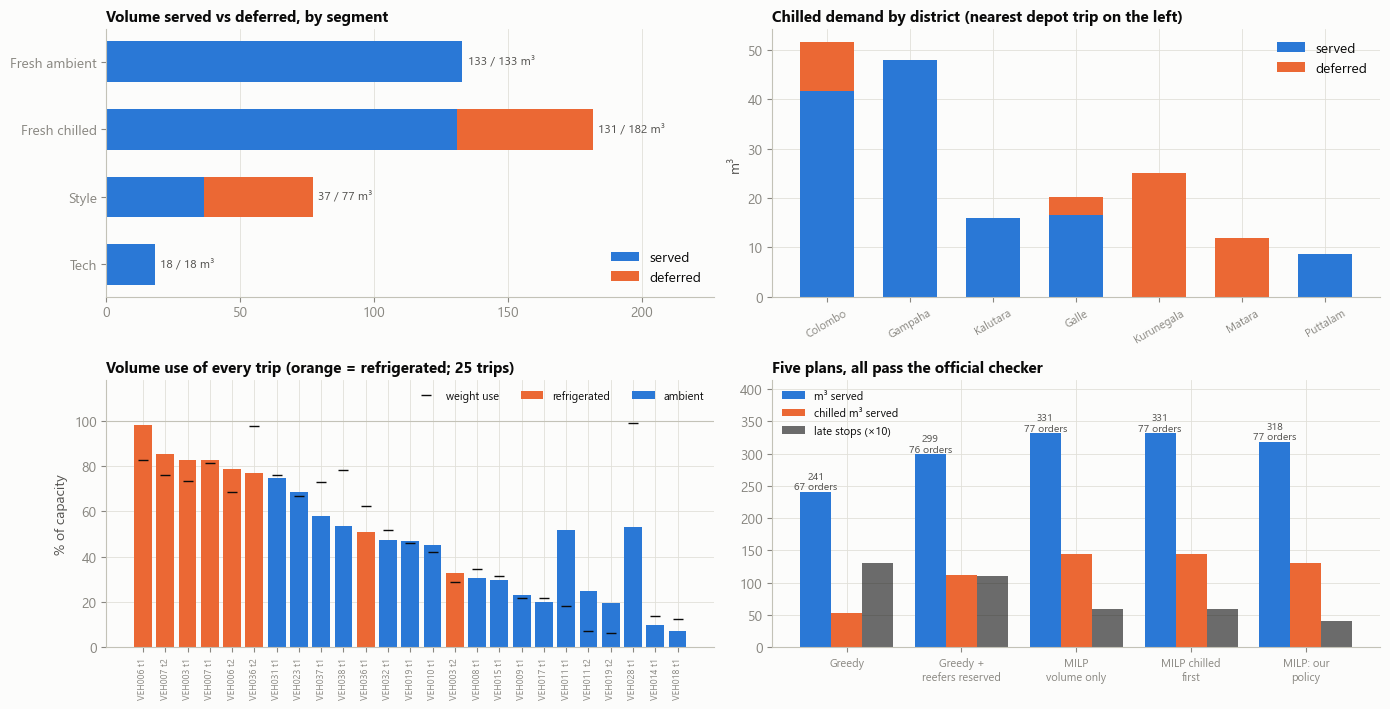

In [139]:
a2 = alloc.merge(peak, on=["scenario", "order_ref", "outlet_id"])
a2["segment"] = np.where(a2.brand == "Fresh", "Fresh " + a2.temp_requirement, a2.brand)
a2["served"] = a2.decision == "served"
seg_ord = ["Fresh ambient", "Fresh chilled", "Style", "Tech"]
fig, axes = plt.subplots(2, 2, figsize=(14, 7.2))

# (a) volume served vs deferred by segment
vv = a2.groupby(["segment", "served"]).order_volume_m3.sum().unstack(fill_value=0).reindex(seg_ord).rename(columns={True: "served", False: "deferred"})
vv = vv.reindex(columns=["served", "deferred"], fill_value=0)
axes[0, 0].barh(vv.index, vv.served, color=BLUE, height=0.6, label="served")
axes[0, 0].barh(vv.index, vv.deferred, left=vv.served, color=ORANGE, height=0.6, label="deferred")
for y_, (s_, d_) in enumerate(zip(vv.served, vv.deferred)):
    axes[0, 0].text(s_ + d_ + 2, y_, f"{s_:.0f} / {s_ + d_:.0f} m³", va="center", fontsize=8.5, color=INK2)
axes[0, 0].set_xlim(0, (vv.sum(axis=1)).max() * 1.25); axes[0, 0].invert_yaxis(); axes[0, 0].legend(loc="lower right")
axes[0, 0].set_title("Volume served vs deferred, by segment"); axes[0, 0].grid(axis="y", visible=False)

# (b) chilled demand by district
cd = a2[a2.temp_requirement == "chilled"].groupby(["district", "served"]).order_volume_m3.sum().unstack(fill_value=0)
cd = cd.reindex(columns=[True, False], fill_value=0).rename(columns={True: "served", False: "deferred"})
cd = cd.loc[travel.loc[cd.index].depot_to_district_freeflow_min.sort_values().index]
axes[0, 1].bar(cd.index, cd.served, color=BLUE, width=0.65, label="served")
axes[0, 1].bar(cd.index, cd.deferred, bottom=cd.served, color=ORANGE, width=0.65, label="deferred")
axes[0, 1].set_title("Chilled demand by district (nearest depot trip on the left)")
axes[0, 1].set_ylabel("m³"); axes[0, 1].legend(); axes[0, 1].tick_params(axis="x", labelrotation=30, labelsize=8)

# (c) utilisation of every trip
tt = trips.copy()
tt["label"] = tt.vehicle_id + " t" + tt.trip_id.astype(str)
tt = tt.sort_values(["brand", "vol_util"], ascending=[True, False])
cols_ = tt.vehicle.map(lambda v: ORANGE if "reefer" in v else BLUE)
axes[1, 0].bar(range(len(tt)), 100 * tt.vol_util, color=cols_, width=0.8)
axes[1, 0].plot(range(len(tt)), 100 * tt.wt_util, color=INK, linewidth=0, marker="_", markersize=7, label="weight use")
axes[1, 0].axhline(100, color=AXIS, linewidth=0.8)
axes[1, 0].set_xticks(range(len(tt)), tt.label, rotation=90, fontsize=6.5)
axes[1, 0].set_ylabel("% of capacity"); axes[1, 0].set_ylim(0, 118)
axes[1, 0].set_title(f"Volume use of every trip (orange = refrigerated; {len(tt)} trips)")
axes[1, 0].bar([0], [0], color=ORANGE, label="refrigerated"); axes[1, 0].bar([0], [0], color=BLUE, label="ambient"); axes[1, 0].legend(fontsize=8, ncol=3, loc="upper right")

# (d) the five plans
cmp_ = cand_tab[["orders served", "m3 served", "chilled m3 served", "stops late on the real clock"]].astype(float)
short = {"Greedy priority score (teammate)": "Greedy", "Greedy, reefers reserved for chilled": "Greedy +\nreefers reserved",
         "MILP: maximise total m3 only": "MILP\nvolume only", "MILP: chilled m3 first, then total m3 (no fairness)": "MILP chilled\nfirst",
         "MILP: our policy (final)": "MILP: our\npolicy"}
x_ = np.arange(len(cmp_)); w_ = 0.27
axes[1, 1].bar(x_ - w_, cmp_["m3 served"], w_, color=BLUE, label="m³ served")
axes[1, 1].bar(x_, cmp_["chilled m3 served"], w_, color=ORANGE, label="chilled m³ served")
axes[1, 1].bar(x_ + w_, cmp_["stops late on the real clock"] * 10, w_, color=INK, alpha=0.6, label="late stops (×10)")
for i, (a_, b_) in enumerate(zip(cmp_["m3 served"], cmp_["orders served"])):
    axes[1, 1].text(i - w_, a_ + 4, f"{a_:.0f}\n{b_:.0f} orders", ha="center", fontsize=7.5, color=INK2)
axes[1, 1].set_xticks(x_, [short[i] for i in cmp_.index], fontsize=8); axes[1, 1].set_ylim(0, cmp_["m3 served"].max() * 1.25)
axes[1, 1].set_title("Five plans, all pass the official checker"); axes[1, 1].legend(fontsize=8, loc="upper left")
fig.tight_layout(); fig.savefig(FIG_DIR / "task2b_results.png"); plt.show()

### 23.10 Real-clock arrivals and fuel

In [140]:
print(f"{sched.on_time.sum()} of {len(sched)} stops arrive inside their delivery window")
display(sched[~sched.on_time])
fuel = fuel_check(alloc, peak, available, travel)
print(f"max share of weekly fuel quota used today: {fuel.share_of_week_quota.max():.1%}; "
      f"vehicles above an even daily share: {(fuel.litres_today > fuel.daily_share_l).sum()}")
display(fuel.round(2).head(6))

73 of 77 stops arrive inside their delivery window


,vehicle_id,trip_id,stop,order_ref,outlet_id,brand,district,depart_depot,eta,window,minutes_late,on_time
2,VEH003,2,1,S1-083,OUT074,Fresh,Puttalam,05:23,08:16,05:30-08:00,16,False
9,VEH006,2,3,S1-031,OUT028,Fresh,Gampaha,06:49,08:14,03:00-08:00,14,False
10,VEH006,2,4,S1-033,OUT029,Fresh,Gampaha,06:49,08:39,05:30-08:00,39,False
14,VEH007,2,1,S1-058,OUT054,Fresh,Galle,07:14,08:57,05:00-07:30,87,False


max share of weekly fuel quota used today: 15.7%; vehicles above an even daily share: 0


,km,km_per_l,weekly_fuel_quota_l,litres_today,daily_share_l,share_of_week_quota
vehicle_id,,,,,,
VEH019,470.000,4.900,610,95.920,101.670,0.160
VEH011,440.000,4.900,600,89.800,100.000,0.150
VEH003,323.000,4.700,480,68.720,80.000,0.140
VEH009,296.000,5.200,440,56.920,73.330,0.130
VEH018,320.000,7.100,450,45.070,75.000,0.100
VEH010,290.000,5.600,540,51.790,90.000,0.100


### 23.10b Arrival against delivery window
One line per stop: the bar is the outlet's delivery window, the dot is the simulated arrival.

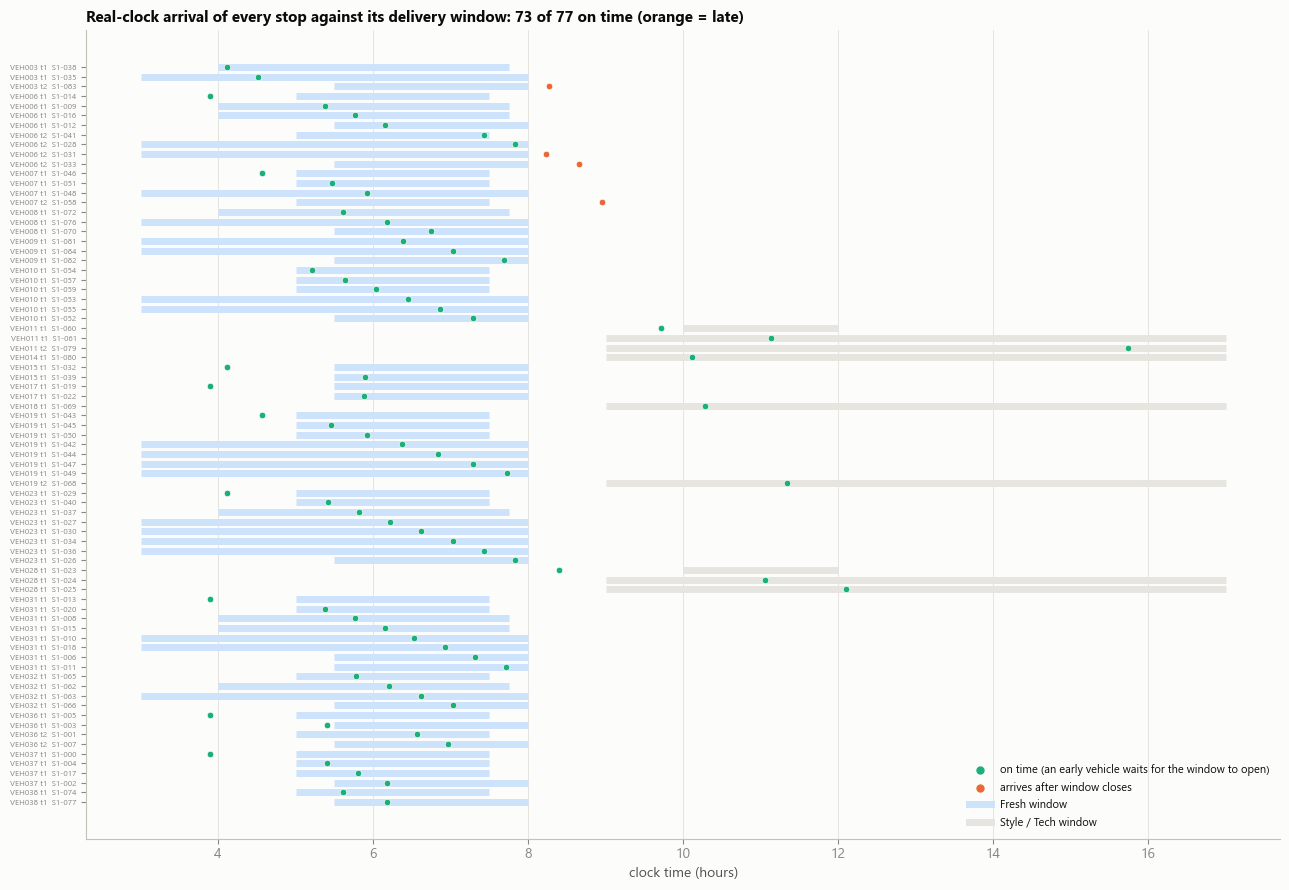

In [141]:
sc = sched.copy()
sc[["wo", "wc"]] = sc.window.str.split("-", expand=True).apply(lambda col: col.map(_hm))
sc["arr"] = sc.eta.map(_hm)
sc = sc.sort_values(["vehicle_id", "trip_id", "stop"]).reset_index(drop=True)
fig, ax = plt.subplots(figsize=(13, 9))
for i, r in sc.iterrows():
    ax.plot([r.wo / 60, r.wc / 60], [i, i], color=BLUE_LIGHT if r.brand == "Fresh" else "#e6e5df", linewidth=5, solid_capstyle="butt", zorder=1)
    ax.scatter(r.arr / 60, i, s=22, color=AQUA if r.on_time else ORANGE, zorder=3, edgecolors=SURFACE, linewidths=0.5)
ax.set_yticks(range(len(sc)), [f"{v} t{t}  {o}" for v, t, o in zip(sc.vehicle_id, sc.trip_id, sc.order_ref)], fontsize=5.8)
ax.invert_yaxis(); ax.set_xlabel("clock time (hours)"); ax.grid(axis="y", visible=False)
ax.set_title(f"Real-clock arrival of every stop against its delivery window: {int(sc.on_time.sum())} of {len(sc)} on time (orange = late)")
ax.scatter([], [], color=AQUA, label="on time (an early vehicle waits for the window to open)"); ax.scatter([], [], color=ORANGE, label="arrives after window closes")
ax.plot([], [], color=BLUE_LIGHT, linewidth=5, label="Fresh window"); ax.plot([], [], color="#e6e5df", linewidth=5, label="Style / Tech window")
ax.legend(loc="lower right", fontsize=8)
fig.tight_layout(); fig.savefig(FIG_DIR / "task2b_arrival_vs_window.png"); plt.show()

### 23.11 Which deferrals were unavoidable, which were our choice, and what they cost
The chilled sub-problem is re-solved under alternative policies:

In [142]:
alternatives = {
    "Ours: fairness -> chilled outlets -> chilled m3": POLICY,
    "Maximise chilled m3 only (no fairness)": [POLICY[2]],
    "Fairness -> chilled m3 (volume first)": [POLICY[0], POLICY[2], POLICY[4]],
    "Ours, strict clock (return legs count)": "strict",
}
rows = []
for name, pol in alternatives.items():
    strict = pol == "strict"
    a_, _, _ = solve_policy(ch, rf, POLICY if strict else pol, True, 120, False, True, name, strict_clock=strict)
    x = a_.merge(ch, on=["scenario", "order_ref", "outlet_id"]); s_ = x.decision == "served"
    sc, _ = stop_schedule(a_, peak)
    rows.append({"policy": name, "chilled outlets served": f"{s_.sum()}/26",
                 "chilled m3 served": round(x.order_volume_m3[s_].sum(), 1),
                 "deferred-yesterday re-deferred": int((~s_ & (x.deferred_yesterday == 1)).sum()),
                 "late stops (real clock)": int((~sc.on_time).sum()),
                 "deferred": ", ".join(x[~s_].order_ref)})
display(pd.DataFrame(rows).set_index("policy"))

,chilled outlets served,chilled m3 served,deferred-yesterday re-deferred,late stops (real clock),deferred
policy,,,,,
Ours: fairness -> chilled outlets -> chilled m3,19/26,131.000,0,4,"S1-021, S1-056, S1-064, S1-067, S1-071, S1-073..."
Maximise chilled m3 only (no fairness),19/26,143.800,1,4,"S1-003, S1-005, S1-021, S1-056, S1-064, S1-067..."
Fairness -> chilled m3 (volume first),17/26,132.800,0,5,"S1-001, S1-003, S1-005, S1-048, S1-051, S1-064..."
"Ours, strict clock (return legs count)",19/26,124.300,0,3,"S1-056, S1-058, S1-064, S1-067, S1-071, S1-073..."


* **Unavoidable:** S1-078 (40.7 m³ > largest truck), and **37.9 m³ of chilled demand**, since no plan can deliver more
  than 143.8 m³ of the 181.6 m³ with these four reefers.
* **Our choice:** protecting Puttalam OUT074 (deferred yesterday, 5 days without a delivery) costs **12.8 m³** of chilled
  volume elsewhere. One Puttalam stop takes 188 of a reefer's 270 minutes. Volume-first rules would also starve the
  three van-only Colombo outlets, which only the single reefer van can reach. Putting outlets first serves them at a
  cost of 1.8 m³.
* **Strict clock:** counting return legs still leaves late stops and delivers 6.7 m³ less, so we keep the published
  standard and give the late stores an ETA.

### 23.12 What-if: bring refrigerated trucks back from the workshop

In [143]:
rows = []
for extra in [[], ["VEH004"], ["VEH004", "VEH005"]]:
    fleet_ = pd.concat([rf, fleet[fleet.vehicle_id.isin(extra)]])
    a_, _, _ = solve_policy(ch, fleet_, POLICY, False, 120, False, True, "what-if")
    x = a_.merge(ch, on=["scenario", "order_ref", "outlet_id"]); s_ = x.decision == "served"
    rows.append({"extra reefers": ", ".join(extra) or "none", "chilled outlets served": f"{s_.sum()}/26",
                 "chilled m3 served": round(x.order_volume_m3[s_].sum(), 1)})
display(pd.DataFrame(rows))

,extra reefers,chilled outlets served,chilled m3 served
0,none,19/26,131.000
1,VEH004,23/26,167.900
2,"VEH004, VEH005",26/26,181.600


In [144]:
w15 = forecast[(forecast.depot == "Peliyagoda") & (forecast.brand == "Fresh") & (forecast.iso_week == 15)].iloc[0]
print(f"Task 2A forecast for Peliyagoda Fresh, ISO week 15 (New Year build-up): {w15.pred_total_volume_m3:,.0f} m3, "
      f"of which {w15.pred_chilled_volume_m3:,.0f} m3 chilled (P10-P90 {w15.pred_total_volume_m3_p10:,.0f}-{w15.pred_total_volume_m3_p90:,.0f} m3 total)")

Task 2A forecast for Peliyagoda Fresh, ISO week 15 (New Year build-up): 1,415 m3, of which 531 m3 chilled (P10-P90 1,374-1,466 m3 total)


Returning one 33.4 m³ reefer (VEH004) serves 23 of 26 chilled outlets. Returning two serves all 26. Ahead of New Year
week, where the Task 2A forecast above puts Peliyagoda chilled demand at about 530 m³, this is the highest-value repair.

### 23.13 The written policy

In [145]:
from IPython.display import Markdown
policy_path = ROOT / "docs" / "Task2B_Prioritization_Policy.md"
display(Markdown(policy_path.read_text(encoding="utf-8")))

# Task 2B: peak-day allocation policy (S1, Peliyagoda) · Team AlphaZero
**77 of 85 orders served (318.5 of 409.9 m³) on 25 trips with 19 vehicles (4 reefers: 3 trucks + 1 van; 15 ambient: 13 trucks + 2 vans).** `check_allocation.py`: **PASSED**. Files: `submissions/submission_task2b.csv`, analysis in the final notebook §23.

## What limits service
1. **Refrigerated capacity is the binding resource.** Chilled demand is **181.6 m³** (26 orders, 7 districts). Only 4 reefers are available (trucks VEH003, 006, 007 and van VEH036), **86.2 m³ per wave**, and each has 2 trips inside a 270-minute Fresh window. Distance eats that window: one Puttalam stop is 173 + 15 = **188 min**; three Kurunegala stops 127 + 2×19 + 3×15 = **210**; two Matara stops 137 + 10 + 2×15 = **177**. A reefer sent far cannot make a useful second trip. Solving for maximum chilled volume shows **no plan can deliver more than 143.8 m³**, so **37.9 m³ (21%) of chilled demand is deferred whatever the policy.**
2. **Size and access.** S1-078 (Style, Kurunegala, 40.7 m³) is larger than the biggest truck (38 m³) and orders cannot be split: **unavoidable**. The three van-only chilled Colombo orders (1,096 kg) exceed the reefer van's 1,040 kg, so they use both of its trips.
3. **Ambient capacity is ample**: 22 ambient trucks and 2 ambient vans are available, and the plan uses only 13 trucks and 2 vans (17 trips). So reefers carry **chilled orders only**. This costs nothing: every ambient order is served except S1-078.

## Priority policy
Applied strictly in this order by an exact mixed-integer program; each level is solved to proven optimality, then locked, so a lower rule never trades away a higher one:
**(1)** no outlet is deferred two runs in a row; **(2)** most outlets receive their chilled order; **(3)** most chilled m³; **(4)** most total m³; **(5)** outlets waiting longest first; **(6)** fewest trips. Repairs that never change who is served: order each vehicle's trips for least lateness, move late stops to idle trucks, keep each vehicle within one-sixth of its weekly fuel quota (highest: 15.7%).

| Segment | Served | Volume served |
|---|---|---|
| Fresh ambient | 49 / 49 | 133.0 m³ |
| Tech | 5 / 5 | 18.1 m³ |
| Style | 4 / 5 | 36.6 / 77.2 m³ |
| **Fresh chilled** | **19 / 26** | **131.0 / 181.6 m³** |

All 10 orders deferred yesterday are served, including Puttalam OUT074 (5 days without a delivery). Every Fresh outlet whose chilled order waits still receives its ambient groceries.

## Deferrals: unavoidable vs our choice, and what they cost
| Orders | District | m³ | Why | |
|---|---|---|---|---|
| S1-078 | Kurunegala | 40.7 | larger than any truck | **unavoidable** |
| S1-071, 073, 075 | Kurunegala | 25.0 | 210 reefer-min for 3 stores; the same minutes serve more stores nearer | choice |
| S1-064, 067 | Matara | 12.0 | 177 reefer-min for 2 stores | choice |
| S1-021 | Colombo | 9.9 | reefer trip 98% full; only the 7 m³ van has room | choice |
| S1-056 | Galle | 3.8 | VEH007 at 252 / 270 min; one more stop needs 25 | choice |

Of the 50.7 m³ of chilled deferrals, 37.9 m³ is unavoidable. The other **12.8 m³ is the price of rule 1**: serving Puttalam (8.7 m³) takes 188 of a reefer's 270 minutes. Maximising chilled m³ alone would deliver 143.8 m³ but leave Puttalam unserved for a 6th day; putting volume before fairness delivers 132.8 m³ and starves the three van-only outlets.

## Checks and comparison
* **Beyond the checker:** a real-clock simulation (free-flow travel, handling allowances, waiting for windows, return legs between trips) puts **73 of 77 stops inside their window**. The 4 late stops are chilled stops on second reefer trips (14, 16, 39 and 87 min); a plan that counts return legs still has 3 late stops and delivers 6.7 m³ less, so we keep the published standard, load those trips first and send the stores an ETA. Mall windows are respected.
* **Against simpler rules** (all pass the checker): a greedy priority-score heuristic serves 67 orders (241 m³, 9 of 26 chilled orders) because it fills reefers with ambient orders. Reserving reefers for chilled orders lifts it to 76 orders; exact optimisation adds one more order and 19.7 m³, all chilled.

## Recommendations
* **Tomorrow:** the 7 deferred chilled orders become rule-1 priorities; run Kurunegala and Matara first.
* **Bring workshop reefers back before the festival.** VEH004 alone (33.4 m³) serves 23 of 26 chilled outlets (167.9 m³); VEH004 and VEH005 serve all 26 (181.6 m³). Our Task 2A forecast puts New Year week (W15) chilled demand at Peliyagoda near 530 m³, so this is the priority repair.


# Part D · Results, conclusions and inference

## 24. Results

Everything the pipeline delivers, in one place: the Task 1 scores, the Task 2A scores and forecast for 2026 W14–W23, and the Task 2B peak-day plan. All
numbers and charts below are computed by the cells above.

### 24.1 Scorecard

In [146]:
from IPython.display import Markdown
c2 = summary.loc[COMPOSITE]; h2 = summary.loc["Bottom-up hybrid"]; t2 = summary.loc["Structural family, own per-brand pick"]
b2 = metrics(full[full.model == "B1_SEASONAL"])
sc_ = cand_tab.loc["MILP: our policy (final)"]; gr_ = cand_tab.loc["Greedy priority score (teammate)"]
passed_, _ = run_checker(alloc)
tbl = f"""
| | Task 2A: demand forecast | Task 2B: peak-day allocation |
|---|---|---|
| **Final solution** | per-brand composite of two model families | exact lexicographic MILP |
| **Headline score** | **{c2['total WAPE %']:.2f}% WAPE on total volume**, **{c2['chilled WAPE %']:.2f}% on chilled** | **{sc_['orders served']} of 85 orders served**, {sc_['m3 served']:.1f} m³, {sc_['chilled orders served']} chilled orders |
| **Per brand** | Fresh {c2['Fresh %']:.2f}% · Style {c2['Style %']:.2f}% · Tech {c2['Tech %']:.1f}% (random ordering) | no outlet deferred two runs in a row ({int(sc_['deferred yesterday, deferred again'])} repeat deferrals) |
| **vs a simple baseline** | seasonal naive {b2['total WAPE %']:.2f}% / {b2['chilled WAPE %']:.2f}% ({100 * (1 - c2['total WAPE %'] / b2['total WAPE %']):.0f}% / {100 * (1 - c2['chilled WAPE %'] / b2['chilled WAPE %']):.0f}% lower error) | greedy heuristic: {gr_['orders served']} orders, {gr_['m3 served']:.1f} m³, {gr_['chilled orders served']} chilled |
| **vs the best teammate model** | {t2['total WAPE %']:.2f}% / {t2['chilled WAPE %']:.2f}% (our hybrid alone: {h2['total WAPE %']:.2f}% / {h2['chilled WAPE %']:.2f}%) | – |
| **Validation** | 49 rolling origins x 10 weeks x 6 series, no leakage | official `check_allocation.py`: {'PASSED' if passed_ else 'FAILED'} |
| **Uncertainty** | P10-P90 ranges, held-out coverage {cov.loc['mean', 'total']:.0%} (total) / {cov.loc['mean', 'chilled']:.0%} (chilled) | {int((~a2.served).sum())} deferrals; 37.9 m³ of chilled demand cannot be delivered by any plan |
"""
display(Markdown(tbl))


| | Task 2A: demand forecast | Task 2B: peak-day allocation |
|---|---|---|
| **Final solution** | per-brand composite of two model families | exact lexicographic MILP |
| **Headline score** | **3.12% WAPE on total volume**, **2.07% on chilled** | **77 of 85 orders served**, 318.5 m³, 19/26 chilled orders |
| **Per brand** | Fresh 1.91% · Style 5.44% · Tech 27.4% (random ordering) | no outlet deferred two runs in a row (0 repeat deferrals) |
| **vs a simple baseline** | seasonal naive 7.72% / 6.65% (60% / 69% lower error) | greedy heuristic: 67 orders, 241.3 m³, 9/26 chilled |
| **vs the best teammate model** | 4.57% / 3.44% (our hybrid alone: 3.30% / 2.07%) | – |
| **Validation** | 49 rolling origins x 10 weeks x 6 series, no leakage | official `check_allocation.py`: PASSED |
| **Uncertainty** | P10-P90 ranges, held-out coverage 78% (total) / 80% (chilled) | 8 deferrals; 37.9 m³ of chilled demand cannot be delivered by any plan |


### 24.1b Task 1: service time and lateness (time-based folds, §6–§7)

Mean of the three validation folds F1-F3 (status quo first, final model last):


,MAE,RMSE,bias,festival-free MAE,MAE_F1,MAE_F2,MAE_F3
model,,,,,,,
Planning allowance (status quo),7.386,11.902,-2.114,6.457,6.471,8.591,7.095
Outlet x monsoon median,5.482,9.356,-2.038,4.490,4.630,6.480,5.337
"Ridge regression, log target",4.659,7.551,-0.902,3.965,4.007,5.333,4.637
"LightGBM, base parameters, log target",3.989,6.338,-0.462,3.628,3.707,4.356,3.906
"LightGBM tuned blend, 3 seeds",3.964,6.225,-0.353,3.632,3.712,4.312,3.870
"FINAL: + size history, 3 seeds",3.895,6.166,-0.459,3.566,3.625,4.266,3.793


,logloss,Brier,AUC,ECE,festival-free logloss,logloss_F1,logloss_F2,logloss_F3
model,,,,,,,,
Plan's own verdict (status quo),0.480,0.151,0.515,0.042,0.459,0.512,0.534,0.395
Logistic regression on plan features,0.252,0.078,0.930,0.016,0.239,0.278,0.275,0.205
"LightGBM, base parameters",0.147,0.046,0.978,0.009,0.140,0.161,0.148,0.131
"LightGBM tuned, 3 seeds",0.146,0.046,0.978,0.008,0.139,0.160,0.147,0.130
"FINAL: + size history and size-aware ETA, 3 seeds",0.143,0.045,0.979,0.009,0.137,0.159,0.144,0.127


Two folds that no decision used (§6.11):


,rows,service MAE,allowance MAE,service RMSE,late log loss,plan's verdict log loss,late AUC,Brier,ECE
fold,,,,,,,,,
U1_2025_JunJul,"5,002.000",3.849,6.846,5.964,0.149,0.506,0.979,0.047,0.009
U2_2025_JulAug,"5,042.000",3.918,7.583,6.301,0.130,0.405,0.977,0.040,0.006
mean,"5,022.000",3.884,7.215,6.132,0.140,0.456,0.978,0.044,0.007


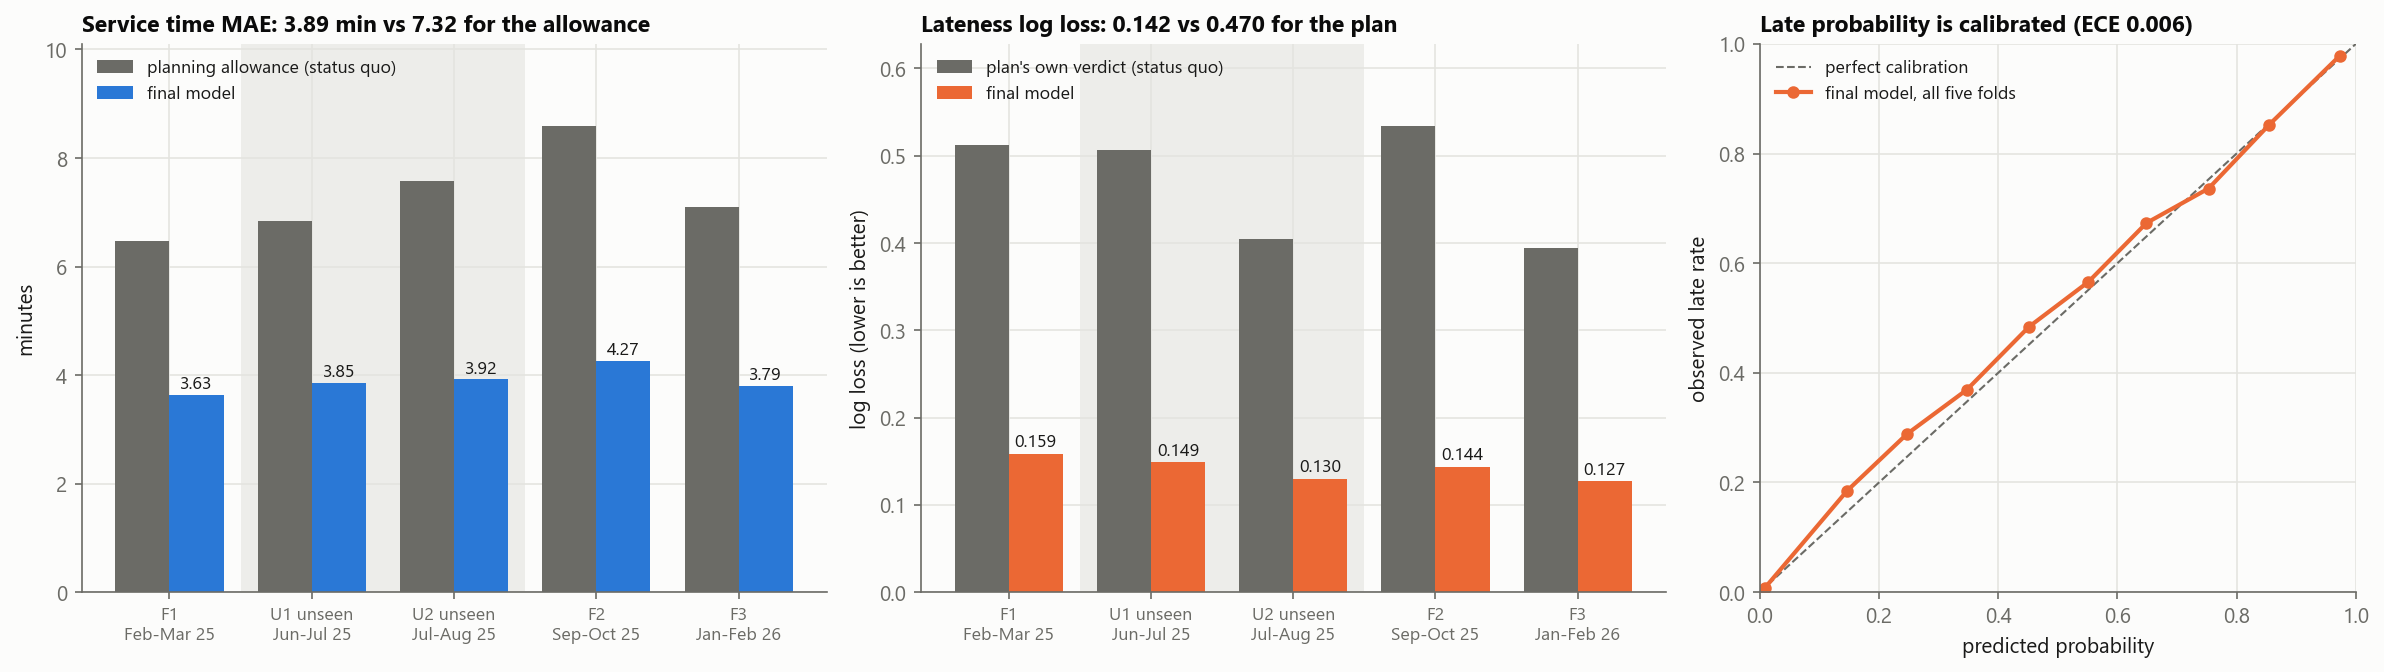

In [147]:
from IPython.display import Image
print("Mean of the three validation folds F1-F3 (status quo first, final model last):")
display(LADDER_SVC.round(3)); display(LADDER_LATE.round(4))
print("Two folds that no decision used (§6.11):")
display(UNSEEN_TBL.round(4))
display(Image(filename=str(FIG_DIR / "task1_results.png")))

* **Service time:** 3.90 min mean absolute error on the three validation folds and 3.88 on the two unseen folds,
  against 7.39 min for the dispatcher's planning allowance: about half the error, with little bias.
* **Lateness:** log loss 0.143 and AUC 0.979 (0.140 and 0.978 on the unseen folds), against 0.480 for the plan's own
  verdict. Predicted probabilities follow the observed late rate (ECE below 0.01), so `pred_late_prob` can be used as a
  real probability, for example to decide which stores get an ETA warning first.

### 24.2 Task 2A: how accurate is the forecast?
Four views of the same backtest: error by brand against the alternatives, the forecast for the same festival season one year earlier, the chilled volume the refrigerated fleet must carry, and error by forecast horizon.

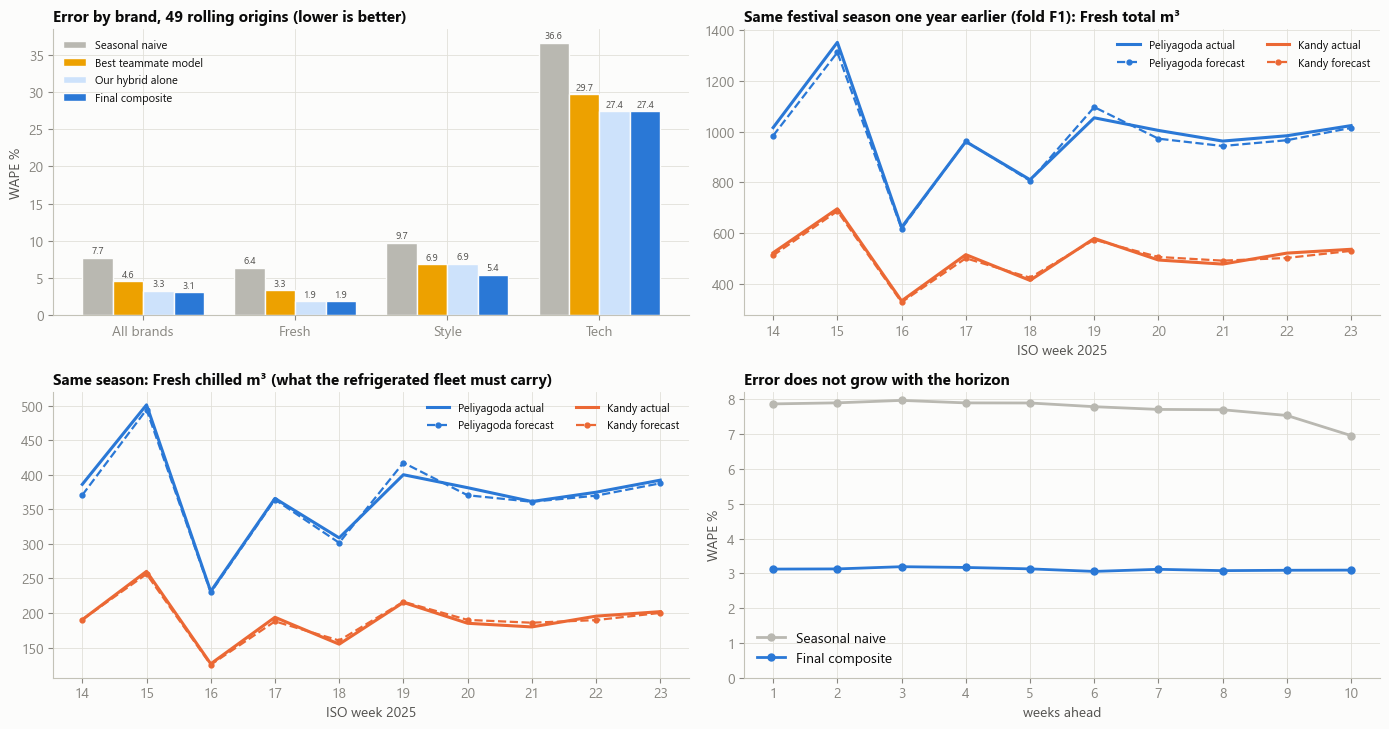

In [148]:
yws_ = week_ids(cal)
bm = bench[bench.model.isin([COMPOSITE, "B1_SEASONAL", "TEAM_FINAL", "Hybrid"])].copy()
bm["h"] = [yws_.index(y * 100 + w) - o for y, w, o in zip(bm.iso_year, bm.iso_week, bm.origin_idx)]
fig, axes = plt.subplots(2, 2, figsize=(14, 7.4))

# (a) WAPE by brand
names_ = {"B1_SEASONAL": "Seasonal naive", "TEAM_FINAL": "Best teammate model", "Hybrid": "Our hybrid alone", COMPOSITE: "Final composite"}
cols4 = ["total WAPE %", "Fresh %", "Style %", "Tech %"]
tab_ = pd.DataFrame({names_[m]: metrics(bm[bm.model == m])[cols4] for m in names_}).T
x_ = np.arange(len(cols4)); w_ = 0.2
for i, (m, c) in enumerate(zip(tab_.index, ["#b9b8b1", "#eda100", BLUE_LIGHT, BLUE])):
    axes[0, 0].bar(x_ + (i - 1.5) * w_, tab_.loc[m], w_, color=c, label=m, edgecolor=SURFACE)
    for xi, v in zip(x_ + (i - 1.5) * w_, tab_.loc[m]):
        axes[0, 0].text(xi, v + 0.6, f"{v:.1f}", ha="center", fontsize=7, color=INK2)
axes[0, 0].set_xticks(x_, ["All brands", "Fresh", "Style", "Tech"]); axes[0, 0].set_ylabel("WAPE %"); axes[0, 0].legend(fontsize=8)
axes[0, 0].set_title("Error by brand, 49 rolling origins (lower is better)")

# (b) fold F1: actual vs forecast, Fresh by depot
f1 = bm[(bm.model == COMPOSITE) & (bm.origin_idx == 64) & (bm.brand == "Fresh")]
for dep, c in DEPOT_COLORS.items():
    g = f1[f1.depot == dep].sort_values("iso_week")
    axes[0, 1].plot(g.iso_week, g.y_total, color=c, linewidth=2.2, label=f"{dep} actual")
    axes[0, 1].plot(g.iso_week, g.pred_total, color=c, linewidth=1.6, linestyle="--", marker="o", markersize=3.5, label=f"{dep} forecast")
axes[0, 1].set_xticks(range(14, 24)); axes[0, 1].set_xlabel("ISO week 2025"); axes[0, 1].legend(fontsize=8, ncol=2)
axes[0, 1].set_title("Same festival season one year earlier (fold F1): Fresh total m³")

# (c) chilled actual vs forecast
for dep, c in DEPOT_COLORS.items():
    g = f1[f1.depot == dep].sort_values("iso_week")
    axes[1, 0].plot(g.iso_week, g.y_chilled, color=c, linewidth=2.2, label=f"{dep} actual")
    axes[1, 0].plot(g.iso_week, g.pred_chilled, color=c, linewidth=1.6, linestyle="--", marker="o", markersize=3.5, label=f"{dep} forecast")
axes[1, 0].set_xticks(range(14, 24)); axes[1, 0].set_xlabel("ISO week 2025"); axes[1, 0].legend(fontsize=8, ncol=2)
axes[1, 0].set_title("Same season: Fresh chilled m³ (what the refrigerated fleet must carry)")

# (d) error by horizon
cm_ = bm[bm.model == COMPOSITE].groupby("h").apply(lambda g: 100 * (g.pred_total - g.y_total).abs().sum() / g.y_total.sum())
sn_ = bm[bm.model == "B1_SEASONAL"].groupby("h").apply(lambda g: 100 * (g.pred_total - g.y_total).abs().sum() / g.y_total.sum())
axes[1, 1].plot(sn_.index, sn_.values, color="#b9b8b1", marker="o", label="Seasonal naive")
axes[1, 1].plot(cm_.index, cm_.values, color=BLUE, marker="o", label="Final composite")
axes[1, 1].set_xticks(range(1, 11)); axes[1, 1].set_xlabel("weeks ahead"); axes[1, 1].set_ylabel("WAPE %"); axes[1, 1].set_ylim(0, None); axes[1, 1].legend()
axes[1, 1].set_title("Error does not grow with the horizon")
fig.tight_layout(); save(fig, "results_task2a_dashboard"); plt.show()

* The final composite is the lowest-error model overall and in every brand where it differs from the others, and
  roughly **60% below a naive baseline**.
* The festival season one year earlier, which looks like the real task (New Year, Vesak, Poson), is tracked closely for
  both depots, including the New Year build-up and trough, for total and chilled volume.
* The error stays flat from one to ten weeks ahead: the forecast is driven by the calendar, not by recent values.

### 24.3 Task 2A: the forecast for 2026 W14–W23

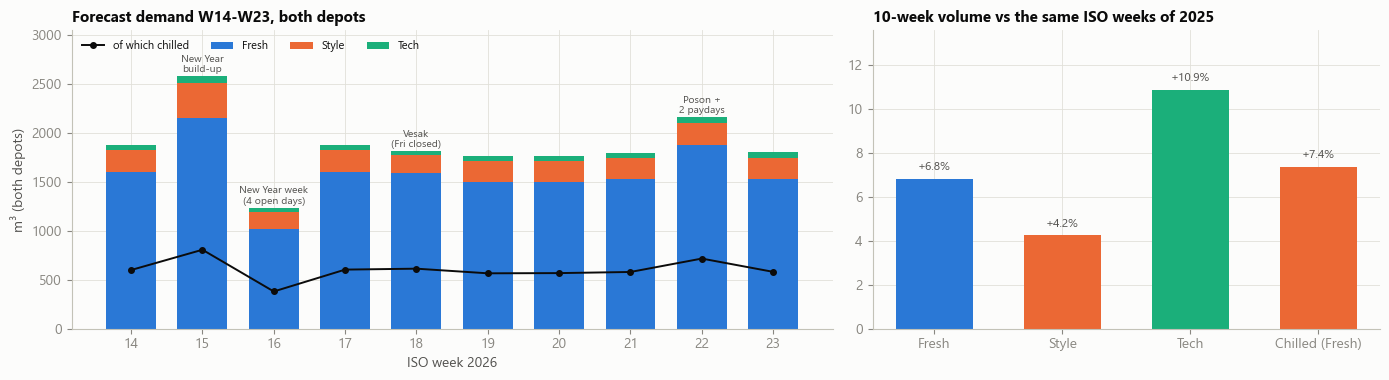

In [149]:
fc = forecast.copy()
fc["week_start"] = (fc.iso_year * 100 + fc.iso_week).map(wk_start)
fig, axes = plt.subplots(1, 2, figsize=(14, 3.9), gridspec_kw={"width_ratios": [1.5, 1]})
wk_tot = fc.pivot_table(index="iso_week", columns="brand", values="pred_total_volume_m3", aggfunc="sum")
wk_chi = fc.groupby("iso_week").pred_chilled_volume_m3.sum()
bottom = np.zeros(len(wk_tot))
for b, c in BRAND_COLORS.items():
    axes[0].bar(wk_tot.index, wk_tot[b], bottom=bottom, color=c, width=0.7, label=b); bottom += wk_tot[b].values
axes[0].plot(wk_chi.index, wk_chi.values, color=INK, marker="o", markersize=4, linewidth=1.4, label="of which chilled")
for w_, note in {15: "New Year\nbuild-up", 16: "New Year week\n(4 open days)", 18: "Vesak\n(Fri closed)", 22: "Poson +\n2 paydays"}.items():
    axes[0].text(w_, bottom[list(wk_tot.index).index(w_)] + 40, note, ha="center", fontsize=7.5, color=INK2)
axes[0].set_xticks(wk_tot.index); axes[0].set_xlabel("ISO week 2026"); axes[0].set_ylabel("m³ (both depots)")
axes[0].set_ylim(0, bottom.max() * 1.18); axes[0].legend(ncol=4, fontsize=8, loc="upper left")
axes[0].set_title("Forecast demand W14-W23, both depots")
ly_ = weekly[(weekly.iso_year == 2025) & weekly.iso_week.between(14, 23)].groupby("brand").total_m3.sum()
chg = (fc.groupby("brand").pred_total_volume_m3.sum() / ly_ - 1) * 100
chg["Chilled (Fresh)"] = (fc.pred_chilled_volume_m3.sum() / weekly[(weekly.iso_year == 2025) & weekly.iso_week.between(14, 23)].chilled_m3.sum() - 1) * 100
axes[1].bar(chg.index, chg.values, color=[BRAND_COLORS.get(i, ORANGE) for i in chg.index], width=0.6)
for i, v in enumerate(chg.values):
    axes[1].text(i, v + 0.4, f"{v:+.1f}%", ha="center", fontsize=8.5, color=INK2)
axes[1].set_ylim(0, chg.max() * 1.25); axes[1].set_title("10-week volume vs the same ISO weeks of 2025")
fig.tight_layout(); save(fig, "results_task2a_forecast"); plt.show()
tab = fc.pivot_table(index=["depot", "brand"], columns="iso_week", values="pred_total_volume_m3").round(0)
tab["10-week total"] = tab.sum(axis=1)
display(tab.style.format("{:,.0f}").background_gradient(cmap="Blues", axis=1, subset=list(range(14, 24))))

The demand peak is the week before New Year (W15), the trough is New Year week (W16, four open days), Vesak week (W18)
has only five open days, and Poson plus two paydays lifts W22. Over the ten weeks the forecast is a few percent above
the same weeks of 2025 for every brand, in line with each brand's own year-on-year growth. P10–P90 planning ranges
for every row are in §20 (the notebook also writes them to `submissions/task2a_forecast_with_intervals.csv` for planners; that
file is not part of the submission).

### 24.4 Task 2B: the peak-day plan

**Task 2B in one paragraph.** The day carries 409.9 m³ of orders against 28 available vehicles, but only four refrigerated
vehicles can carry the 181.6 m³ of chilled demand, and far trips use up their 270-minute pre-dawn window. The plan serves
77 of 85 orders, reaches 19 of 26 chilled outlets, serves every outlet that was deferred yesterday, and defers 8 orders:
one that is simply too big for any truck (S1-078) and seven chilled orders whose delivery would cost more reefer minutes
than they are worth. The full reasoning is in §23.11 and in `docs/Task2B_Prioritization_Policy.md`.

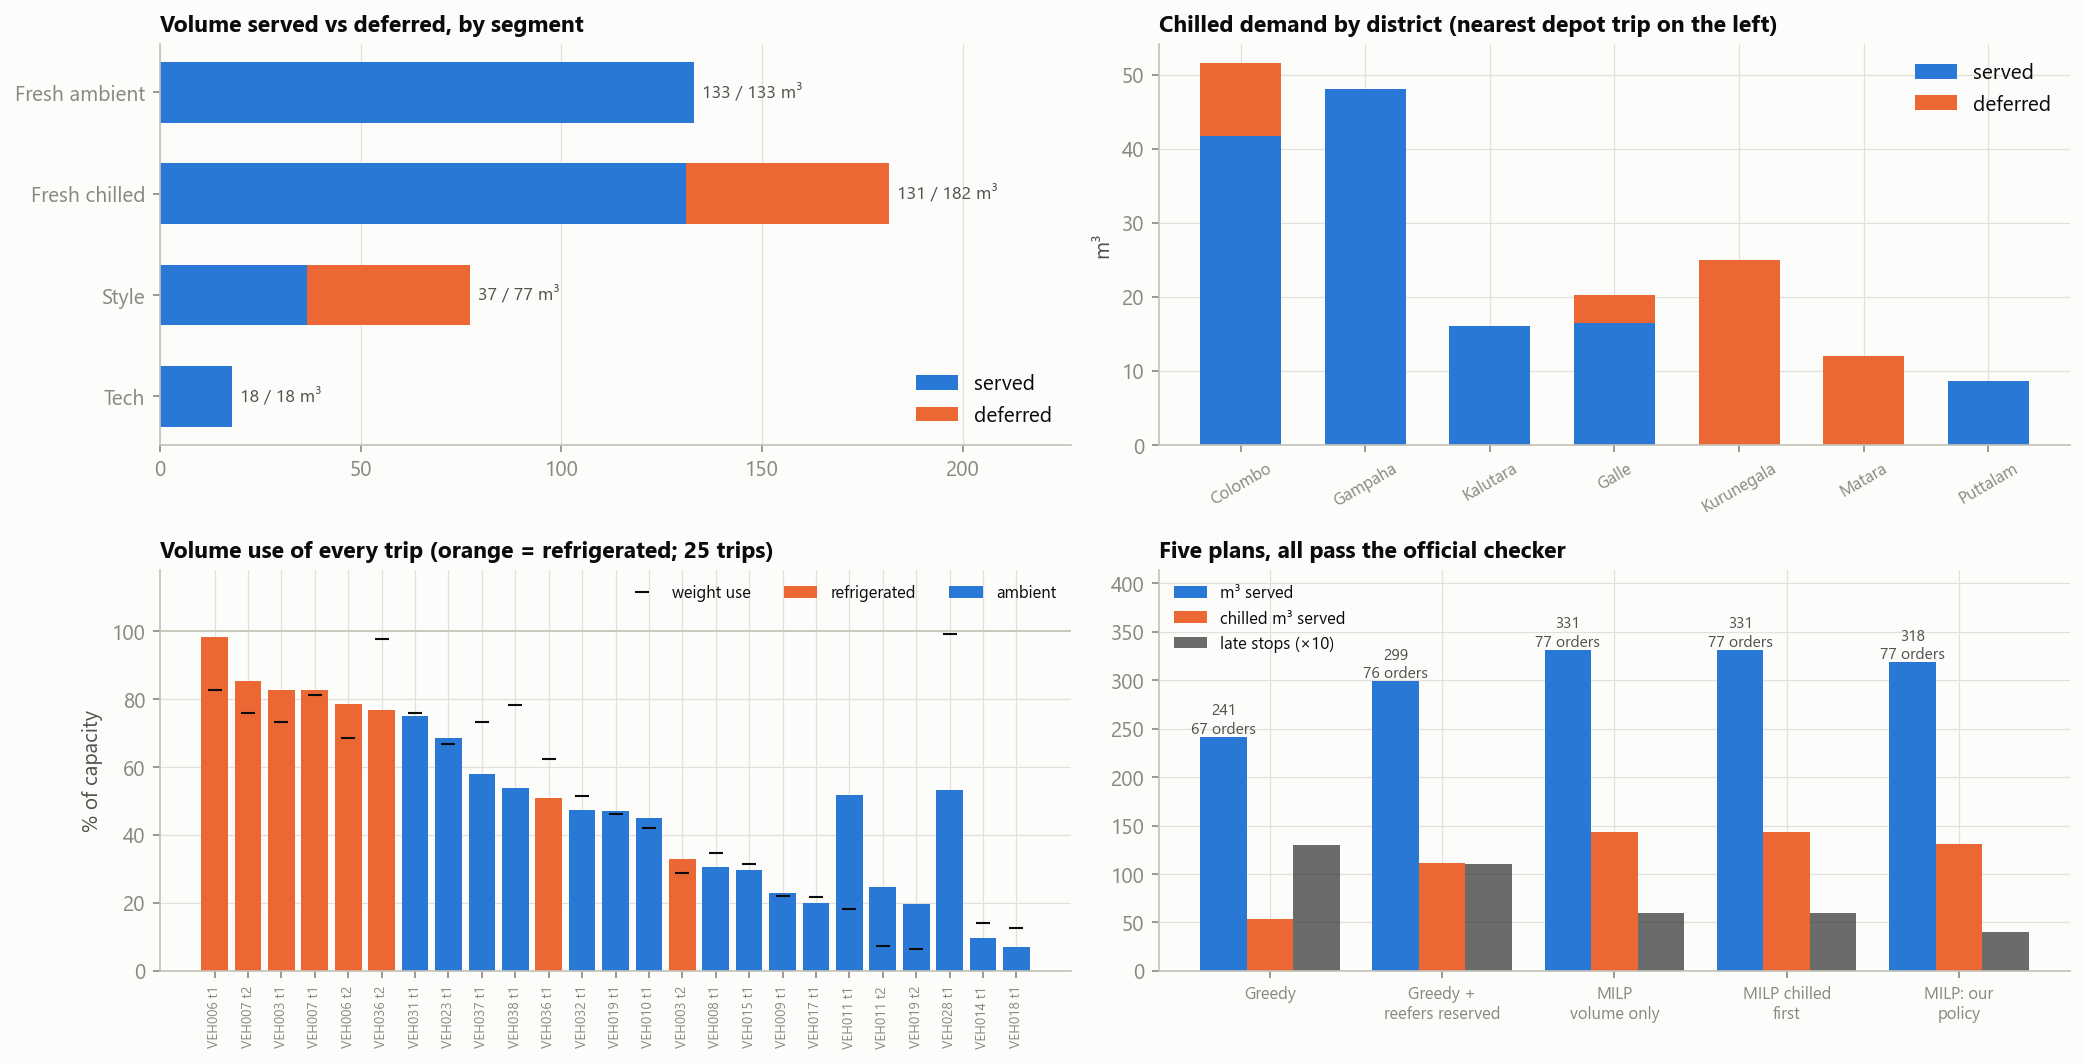

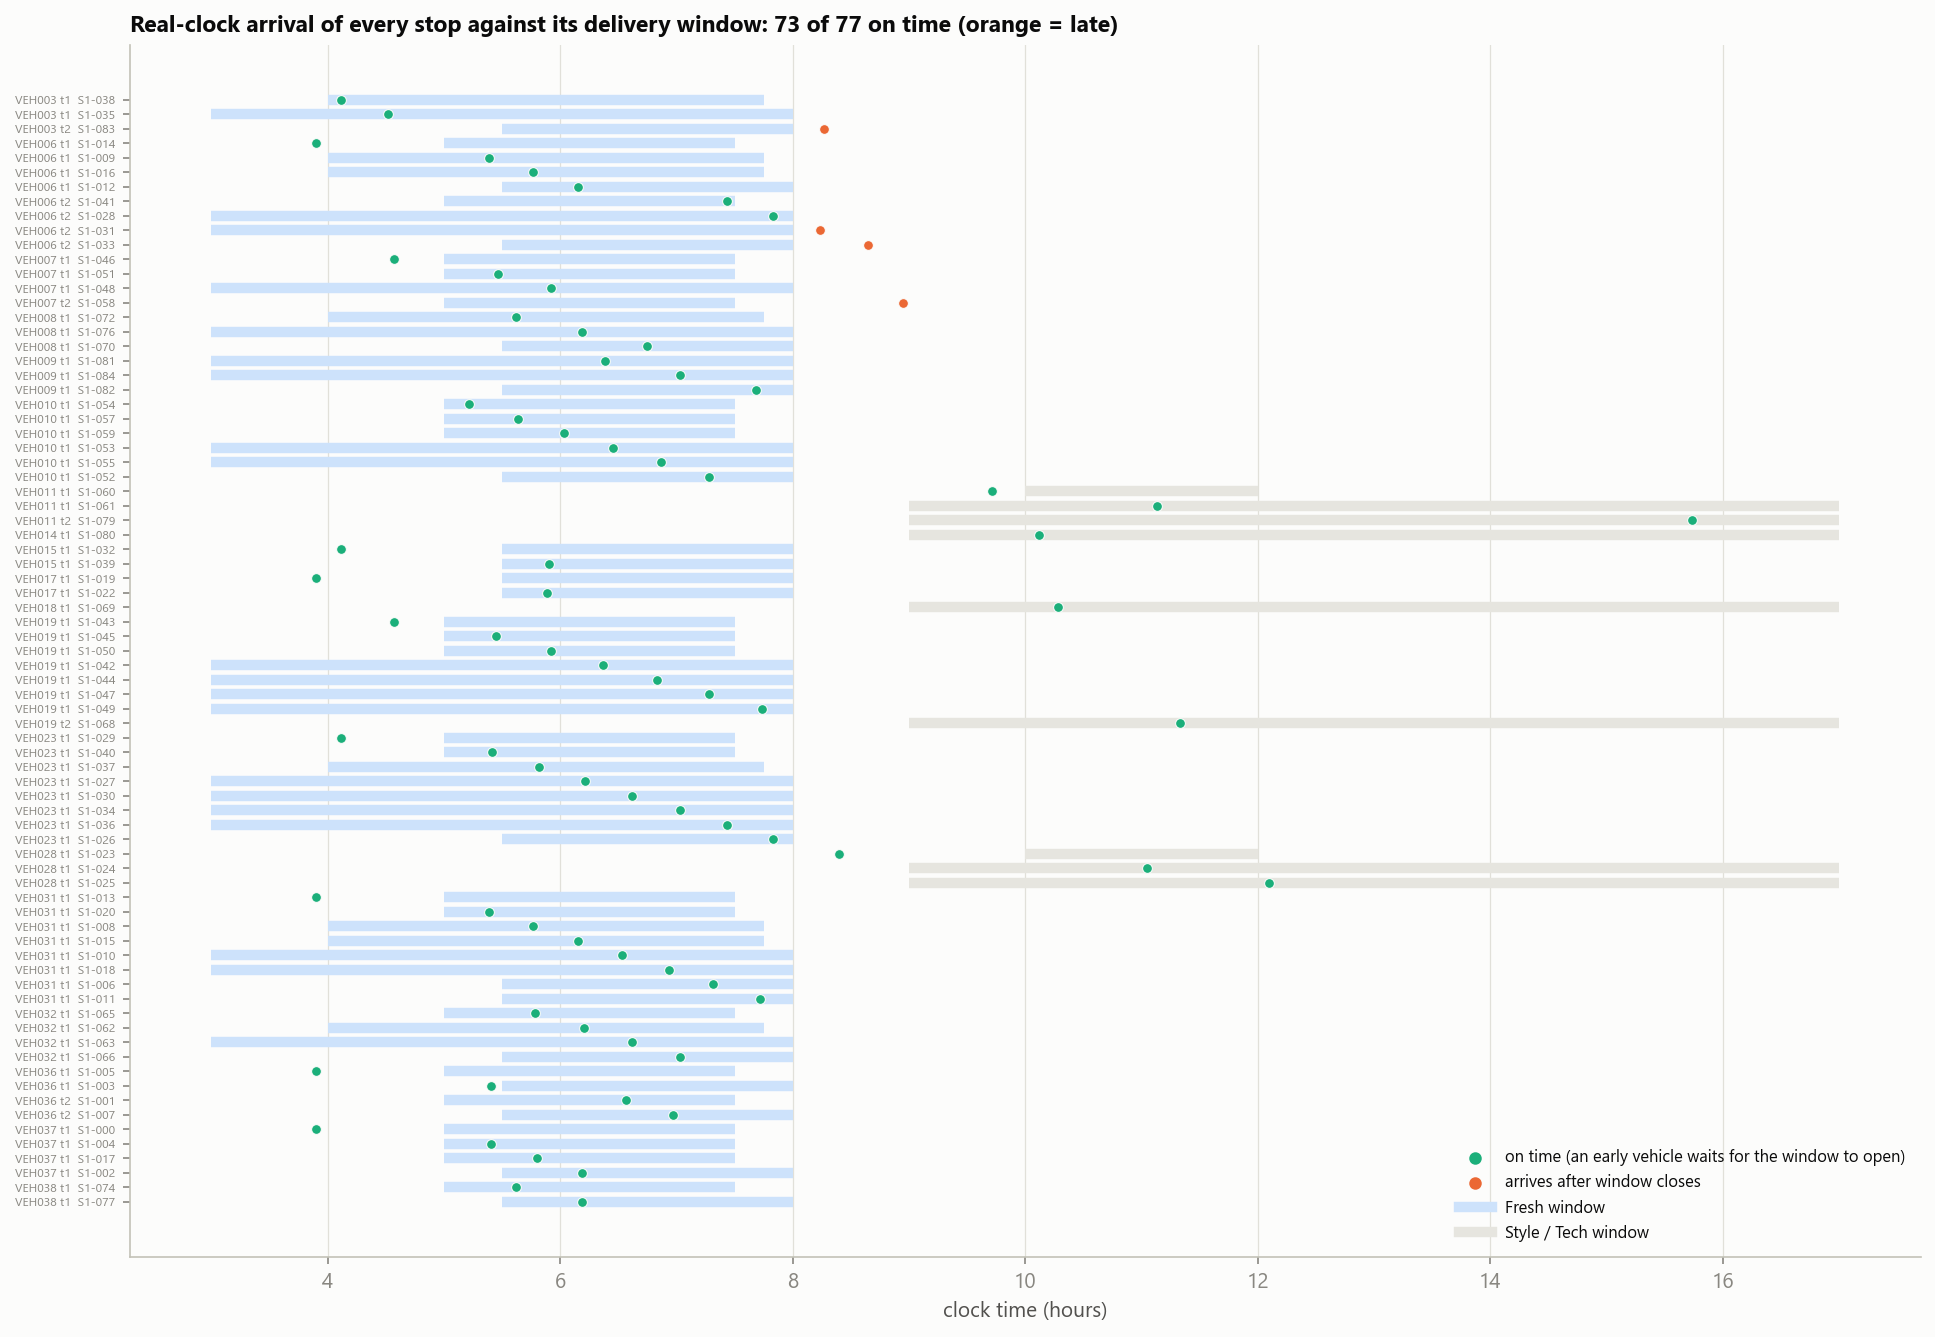

In [150]:
from IPython.display import Image
display(Image(filename=str(FIG_DIR / "task2b_results.png")))
display(Image(filename=str(FIG_DIR / "task2b_arrival_vs_window.png")))

### What this means for Waypoint
* **Plan for W15, not W16.** The demand peak is the week *before* New Year (W15: Peliyagoda Fresh about 1,415 m³, of
  which about 531 m³ chilled); the festival week itself is the trough because two weekdays are closed.
* **Refrigerated capacity is the constraint.** The busiest chilled day (Sat 11 Apr) uses about 58% of one Peliyagoda
  reefer wave, so with vehicles in the workshop a second wave or deferrals become unavoidable.
* **Bring workshop reefers back first.** Returning VEH004 serves 23 of 26 chilled outlets on the peak day; VEH004 and
  VEH005 serve all 26.
* **Protect outlets that were already skipped.** Our rule 1 costs 12.8 m³ of chilled volume that day and removes every
  repeat deferral.
* **Use the ranges, not only the point forecast.** Fresh is forecast within about ±3%, Style ±10%, Tech about ±45%.

## 25. Conclusions and limitations

### Task 1
* Both labels are built from the actual route times: service = leave − max(arrival, window open), because early
  vehicles wait for the window (4.4% of stops, about 20 minutes); late = arrival strictly after the window closes
  (arrivals exactly at closing time are on time).
* Features are known before departure: the plan, as-of history from labelled rows strictly before each cutoff (outlet,
  vehicle, district, depot), and an ETA replay of every planned route. Every family earns its place in the ablations
  (§6.3); road disruption matters most for lateness, outlet history for service time.
* Seed-averaged LightGBM: service MAE 3.90 min (allowance 7.39); lateness log loss 0.143, AUC 0.979, calibrated. Two
  folds that no decision used give the same picture (3.88 min, 0.140), so the tuning on F1–F3 did not overfit.

### Task 2A
* The weekly target is built exactly as the brief defines it (every order, bucketed by `order_date`, ISO weeks from the
  calendar, chilled for Fresh only) and §10.1 shows what each rule protects against.
* Demand = **fixed outlet ordering schedules × calendar-driven order size**. Closed days are skipped, not moved.
* Two independently built model families were compared on 49 rolling origins. The final forecast takes the best per
  brand: the **bottom-up hybrid** for Fresh, Tech and all chilled volume, and the **structural daily model** for Style
  (the hybrid in Style's two recurring spike weeks).
* Ablations show every engineered component of the hybrid helps. Error is flat across the 10-week horizon.
* Style and Tech errors are near their noise floor. The remaining Fresh error is short random demand episodes that no
  calendar or road feature explains.

### Task 2B
* Refrigerated capacity is the binding constraint: 181.6 m³ of chilled demand against four available reefers. At most
  143.8 m³ of it can be delivered by any plan, so 37.9 m³ is deferred whatever the policy.
* Priority policy: no repeat deferral → most chilled outlets → most chilled m³ → most total m³ → longest-waiting →
  fewest trips, solved exactly in that order. The result passes `check_allocation.py` and beats a heuristic and two
  alternative MILP policies on the scorecard (§23.8).
* The official checker is used as a gate and screen, not as a measure of quality: it cannot distinguish a 67-order plan
  from a 77-order plan.

**Limitations**
* Task 1: service-time errors are largest for Style and Tech (few, long stops); the largest Tech orders are
  under-predicted by about 12 minutes (§6.10). Lateness relies on the day's road disruption index, which the plan must
  have before dispatch, and the history features need the latest route records at scoring time.
* Random multi-day demand episodes (about ±5% for 3–5 days) are unpredictable 10 weeks ahead; they are most of the
  remaining Fresh error. Tech ordering is close to random, hence its wide intervals.
* Each festival appears only twice in the history. Its strength was consistent across both years.
* Vesak 2026 falls on a closed day, which never happened in the history. Following the observed holiday rule, that
  day's orders are treated as skipped.
* The Style rule uses ISO weeks 10 and 32 as the recurring spike weeks, as observed in both depots in every year.
* The 2B plan uses the booklet's planning standard for trip time (no return leg). A real-clock check shows a few late
  second reefer trips; they are kept, loaded first, and flagged for an ETA message to the stores.

**Next steps for production:** retrain weekly after the order cutoff, monitor WAPE and interval coverage, and feed the
daily chilled forecast into reefer planning for festival weeks. Allocation re-runs daily after the 16:00 cutoff.

### 25.1 Decision log: what we chose, the evidence, and what we rejected

| # | Decision | Evidence | Rejected alternative |
|---|---|---|---|
| 1 | Bucket every order by `order_date` and keep `deferred` and `not_run` orders; append `task1_test_inputs` | §10.1: ignoring the rules changes up to 138 of 702 weekly rows and misplaces up to 3,700 m³, mostly chilled | `dispatch_date` bucketing; dropping undispatched orders |
| 2 | Rebuild each expected order slot, then predict the size of one order | §12.2: the slot reconstruction reproduces all 117 historical weeks for Fresh ambient and Style; weekly volume = count × size | forecasting weekly totals directly (top-down GLM 3.93% vs 3.20%) |
| 3 | Poisson GLM with a log link plus a regularised LightGBM correction | §15: hybrid 3.20% vs GLM 3.22% vs LightGBM alone 3.70%; best on the festival fold (3.39%) | pure LightGBM (cannot extrapolate growth). The hybrid's edge over the GLM is small and we say so |
| 4 | Keep every engineered component | §16 ablation: removing the trend costs +3.34 pp, festival-specific ramps +1.30, payday window +0.81, seasonality +0.48 | one shared festival curve; payday day only |
| 5 | One-year recency half-life, 300 trees, 15 leaves | §17: every setting is within about 0.03 pp; recency weighting helps consistently | picking the 180-day half-life on four folds' luck |
| 6 | Exclude monsoon and road disruption | §11.6: no effect on order volume (they affect travel, which is Task 1) | adding them as features |
| 7 | Chilled volume from the hybrid's own chilled order slots | §18.3: 2.07% vs 2.40% for total × last year's share | chilled share × total |
| 8 | Style from the structural daily model, except ISO weeks 10 and 32 | §18.2: 5.43% vs 6.96% outside spike weeks, better in 44 of 49 origins, both depots; the hybrid wins only in the spike weeks (5.6% vs 32%) | the hybrid for Style; a blend (worse at every weight outside spike weeks) |
| 9 | Fresh and Tech from the hybrid | §18.1–12.3: Fresh 1.91% vs 3.34%; Tech lowest error and bias in both depots; blending raises the error | structural model or recursive lag GBM (7.28%, no better than naive) |
| 10 | No growth correction on the hybrid | §18.3: 3.30% with none, 3.26% at half strength, 3.37% at full | copying the structural model's correction |
| 11 | Empirical P10–P90 intervals from 49 origins | §20: held-out coverage about 78–80% against an 80% target | Gaussian intervals |
| 12 | 2B: exact lexicographic MILP, rule 1 = no repeat deferral | §23.8: 77 orders / 318.5 m³ vs 67 / 241.3 for the greedy heuristic; §23.11: rule 1 costs 12.8 m³ and we say so | volume-only objective (+12.8 m³ but re-defers Puttalam, skipped 5 days) |
| 13 | 2B: refrigerated vehicles carry chilled orders only | §23.8: reserving reefers lifts the greedy plan from 67 to 76 orders; costs nothing here (all ambient orders served) | letting ambient orders use reefers |
| 14 | `check_allocation.py` is a gate, not a score | §23.7: a plan that defers every order passes it | treating "passes the checker" as quality |
| 15 | Task 1: service = leave − max(arrival, window open); late strictly after close | §2.6: raw dwell would count the wait of early vehicles as handling; `>=` would add the arrivals exactly at closing time to the late class | raw dwell time; `>=` |
| 16 | Task 1: validate on six-week time folds that mirror the test period, plus two folds no decision used | §4, §6.11: every fold trains only on earlier data; the unseen folds score as well as the tuning folds (MAE 3.88 vs 3.90) | a single random split; tuning and reporting on the same block only |
| 17 | Task 1: as-of history and an ETA replay of every planned route as features | §6.3 ablations: removing road disruption, the ETA replay or history all worsen the models; §5.3: the replayed slack ranks late stops far better than the planned slack (AUC 0.96 vs 0.86) | plan-only features (the earlier 38-feature pipeline: MAE 4.14, log loss 0.153 on the same five folds, worse on every fold) |
| 18 | Task 1: seed-averaged LightGBM, service blend 0.75 log-target + 0.25 squared error, no post-hoc calibration | §6.4–§6.10: search, blend weight and feature gates on F1–F3; calibration made log loss worse because the raw probabilities are already calibrated | a single seed; calibration; monotone constraints (no gain) |

**Honest weak spots (and the answer):** the hybrid beats the plain GLM by only 0.02 pp (the structure does the work, the
LightGBM adds a small correction); Fresh error is 2–3× the order-level noise floor (§19.1) because of short random
demand episodes that no calendar or road feature explains; Tech is dominated by random "as needed" ordering.

## 26. Inference from the saved models: Task 1 and Task 2A

This final cell is self-contained apart from the library definitions above. It loads the saved models from disk:
* **Task 1**: the nine LightGBM boosters and their manifest (`models/task1_model.pkl`, checked against the text files in
  `models/task1/`), rebuilds the plan, history and
  ETA-replay features of the 5,014 test deliveries from the raw files (history as of 16 Feb 2026, exactly as in
  training), and prints the inputs and the predictions;
* **Task 2A**: the hybrid bundle and the structural model (`models/task2a_*`), and prints the 60 test rows and their
  forecasts.

It confirms that the reloaded models reproduce `submission_task1.csv` and `submission_task2a.csv` exactly, and re-runs
the official checker on the saved Task 2B file.

*Run it after the cells above (Restart & Run All): the hybrid model was pickled from classes defined in §13, so those
definitions must exist in the session.*

In [151]:
# ============================== TASK 1: service time and lateness ==============================
with open(MODELS_DIR / "task1_model.pkl", "rb") as fh:            # 9 LightGBM boosters + manifest (§7.3)
    t1_bundle = pickle.load(fh)
manifest1, models1 = t1_bundle["manifest"], t1_bundle["models"]
_, models_txt = load_bundle(MODELS_DIR / "task1")                  # the same models as LightGBM text files
read1 = lambda f: pd.read_csv(find_file(f), dtype={c: str for c in T1_ID_COLS + TIME_COLS})
ref1 = {"calendar": read1("calendar.csv"), "traffic": read1("traffic_speed.csv"), "road": read1("road_conditions.csv"),
        "outlets": read1("outlets.csv"), "vehicles": read1("vehicles.csv")}
allow1 = read1("service_allowance.csv")
history1 = add_task1_labels(build_base(read1("deliveries_train.csv"), read1("route_legs_train.csv"), "inference-history",
                                       ref1["outlets"], allow1))
rows1 = add_static_features(build_base(read1("task1_test_inputs.csv"), read1("route_legs_test.csv"), "inference-test",
                                       ref1["outlets"], allow1), ref1)
feats1 = t1_build_features(rows1, add_label_side_columns(add_static_features(history1, ref1)),
                           pd.Series(pd.Timestamp(manifest1["history_cutoff"]), index=rows1.index),
                           use_disruption=manifest1["use_disruption"])
cats1 = manifest1["categories"]
p_late1 = np.mean([m.predict(to_model_frame(feats1, manifest1["features"]["late"], cats1)) for m in models1["late"]], axis=0)
X_late1 = to_model_frame(feats1, manifest1["features"]["late"], cats1)
assert all(np.array_equal(m.predict(X_late1), t.predict(X_late1)) for m, t in zip(models1["late"], models_txt["late"]))
X_svc1 = to_model_frame(feats1, manifest1["features"]["service"], cats1)
p_log1 = np.mean([np.expm1(m.predict(X_svc1)) for m in models1["svc_l2log"]], axis=0)
p_l21 = np.mean([m.predict(X_svc1) for m in models1["svc_l2"]], axis=0)
assert all(np.array_equal(m.predict(X_svc1), t.predict(X_svc1)) for k in ["svc_l2log", "svc_l2"]
           for m, t in zip(models1[k], models_txt[k]))
print("task1_model.pkl and the text files in models/task1/ give identical predictions")
w1 = manifest1["blend_weight_log_model"]
pred1 = pd.DataFrame({"delivery_id": feats1.delivery_id.to_numpy(),
                      "pred_service_min": np.clip(w1 * p_log1 + (1 - w1) * p_l21, 0.5, None).round(3),
                      "pred_late_prob": np.clip(p_late1, 0, 1).round(5)})
template1 = pd.read_csv(DATA / "Submission Templates" / "submission_task1.csv")
pred1 = template1[["delivery_id"]].merge(pred1, on="delivery_id", how="left", validate="one_to_one")
inputs1 = template1[["delivery_id"]].merge(feats1.rename(columns={"service_allowance_min": "allowance", "planned_slack_min": "slack_min"}),
                                           on="delivery_id", how="left")
show1 = ["delivery_id", "brand", "district", "dock_type", "order_units", "order_volume_m3", "seq", "n_stops",
         "planned_arrival_time", "window_close_time", "slack_min", "eta_slack_min", "h_outm_svc_mean_sm", "allowance"]
with pd.option_context("display.width", 250, "display.max_columns", 30):
    print(f"TASK 1 | {sum(len(v) for v in models1.values())} LightGBM boosters (3 models x 3 seeds) | {len(pred1):,} planned deliveries, "
          f"{len(manifest1['features']['late'])} lateness / {len(manifest1['features']['service'])} service features | "
          f"history as of {manifest1['history_cutoff']}\n")
    print("TASK 1 INPUTS (first 15 rows; main features shown):")
    print(inputs1[show1].head(15).to_string(index=False, float_format="{:.1f}".format))
    print("\nTASK 1 PREDICTIONS (first 15 rows):")
    print(inputs1[["delivery_id", "brand", "allowance", "slack_min"]].merge(pred1, on="delivery_id").head(15).to_string(
        index=False, formatters={"pred_service_min": "{:.2f}".format, "pred_late_prob": "{:.4f}".format}))
    print("\nTASK 1 PREDICTIONS, all 5,014 rows:")
    print(pred1.describe().loc[["mean", "min", "50%", "max"]].round(3).to_string())
saved1 = pd.read_csv(SUBMISSIONS_DIR / "submission_task1.csv")
chk1 = saved1.merge(pred1, on="delivery_id", suffixes=("_saved", ""))
assert len(chk1) == len(saved1) == 5014
assert np.allclose(chk1.pred_service_min, chk1.pred_service_min_saved) and np.allclose(chk1.pred_late_prob, chk1.pred_late_prob_saved)
print("\nTask 1: the reloaded models reproduce submission_task1.csv exactly.\n")

# ============================== TASK 2A: weekly depot demand ==============================
with open(MODELS_DIR / "task2a_model.pkl", "rb") as fh:
    bundle_loaded = pickle.load(fh)
struct_loaded = json.loads((MODELS_DIR / "task2a_structural.json").read_text())
selection_loaded = json.loads((MODELS_DIR / "task2a_selection.json").read_text())
print("Loaded:", selection_loaded["final_model"], "|", bundle_loaded["meta"]["rule"])
print("Trained on:", bundle_loaded["meta"]["trained_on"], "|", bundle_loaded["meta"]["n_orders"], "orders")

inputs = pd.read_csv(DATA / "Test Data" / "task2a_test_inputs.csv")
pred = final_forecast(bundle_loaded, struct_loaded, inputs, load_calendar())

print("\nTASK 2A INPUTS (task2a_test_inputs.csv):")
print(inputs.to_string(index=False))
print("\nTASK 2A PREDICTIONS (submission columns + model used + P10/P90 planning range):")
print(pred[["row_id", "depot", "brand", "iso_year", "iso_week", "source_model", "pred_total_volume_m3",
            "pred_chilled_volume_m3", "pred_total_volume_m3_p10", "pred_total_volume_m3_p90"]].round(2).to_string(index=False))

saved = pd.read_csv(SUBMISSIONS_DIR / "submission_task2a.csv").set_index("row_id")
assert np.allclose(pred.set_index("row_id").pred_total_volume_m3.round(3), saved.pred_total_volume_m3.reindex(pred.row_id).values)
assert np.allclose(pred.set_index("row_id").pred_chilled_volume_m3.round(3), saved.pred_chilled_volume_m3.reindex(pred.row_id).values)
print("\nTask 2A: the reloaded models reproduce submission_task2a.csv exactly.")
print("Task 2B:", run_checker(SUBMISSIONS_DIR / "submission_task2b.csv")[1])

task1_model.pkl and the text files in models/task1/ give identical predictions
TASK 1 | 9 LightGBM boosters (3 models x 3 seeds) | 5,014 planned deliveries, 96 lateness / 91 service features | history as of 2026-02-16

TASK 1 INPUTS (first 15 rows; main features shown):
delivery_id brand district dock_type  order_units  order_volume_m3  seq  n_stops planned_arrival_time window_close_time  slack_min  eta_slack_min  h_outm_svc_mean_sm  allowance
 ORD0092308 Fresh  Colombo    street           11              0.5    0        3                05:21             07:30      129.0          109.6                 9.9         16
 ORD0092309 Fresh  Colombo    street           12              0.5    2        3                06:10             08:00      110.0           84.1                 9.9         16
 ORD0092310 Fresh  Colombo    street           13              0.5    1        3                05:46             07:30      104.0           84.4                14.4         16
 ORD0092311 Fresh  Co

Task 2B: FEASIBILITY: PASSED - every rule satisfied.
